In [2]:
import os
from google.colab import userdata

# 코랩 Secrets에 등록된 값을 가져와 환경 변수로 설정
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 인증 확인
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [3]:
!kaggle competitions download -c aiffel-d-lthon-dktc-online-17

100% 906k/906k [00:00<00:00, 58.1MB/s]



In [4]:
!unzip -q aiffel-d-lthon-dktc-online-17.zip -d ./data

## 데이터 확인 및 분석

In [5]:
import pandas as pd

train_data = pd.read_csv('/content/data/train.csv')
test_data = pd.read_csv('/content/data/test.csv')

In [2]:
set(train_data['class'])

{'갈취 대화', '기타 괴롭힘 대화', '직장 내 괴롭힘 대화', '협박 대화'}

In [29]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idx           3950 non-null   int64 
 1   class         3950 non-null   object
 2   conversation  3950 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.7+ KB


In [30]:
train_data['class'].value_counts()

,count
class,
기타 괴롭힘 대화,1094
갈취 대화,981
직장 내 괴롭힘 대화,979
협박 대화,896


In [31]:
pd.set_option('display.max_colwidth', None)
train_data.sample(10)

,idx,class,conversation
306,306,기타 괴롭힘 대화,고객님 계산하고 드셔야해요\n지금 나를 도둑 취급한거에요?\n아니요 그게 아니라 계산하고 드셔야하는데\n누가 계산안한대요? 나갈때 계산하려고했는데\n네. 그렇긴한데\n아니 끝까지 도둑취급이네? 내가 돈 안내고 갔어?\n그건아닌데\n아휴 여기는 직원 교육을 어떻게 시키길래 고객은 도둑취급하는지\n죄송합니다.그럴 의도는 아니었습니다\n아니긴 정말 정떨어지네 사람을 모욕해도 정도가 있지 살다살다 도둑취급은 내가 기분이 나빠서 명예훼손으로 고소라도 해얄까봐
2637,2637,직장 내 괴롭힘 대화,이것좀 처리하고 가게\n네 언제까지 하면 될까요\n오늘까지 해주고 가\n지금 다섯시 반인데요\n그런데?\n오늘까지는 못하고 갈것같아요\n그래? 그럼 몇시간이면 되겠어?\n한 넉넉히 4시간은 잡아서요\n그럼 내가 4시간 기다릴테니까 해줘\n네??\n나같은 상사가 어딨냐 일 끝날때까지 기다려주고그렇지??\n.아 네.
2002,2002,직장 내 괴롭힘 대화,너 일로 와봐.\n네.\n너희 아까 손님들 앞에서 너희끼리 떠들면서 웃었니?\n네??.아니요 아까 손님께서 말 거셔서 그냥 웃은 거에요.\n여기가 어디라고 웃어 너희 일하러 왔지 놀러왔니?\n죄송합니다.\n하여튼 가봐.일이나 제대로 하면 말도 안해\n네 그럼 가 보겠습니다.\n아참가서 식빵 4개 모닝롤 3개 단호박빵 3개 가져와.\n매니저님 죄송한데 다시 한번만 말씀해 주실 수 있으실까요?\n하.됐어 내가 할라니까\n죄송합니다.
101,101,직장 내 괴롭힘 대화,김사원 이리 와보게\n네 팀장님 무슨 일이신가요?\n도대체 옷이 그게 무슨 일이야?\n제 옷이 왜.\n아니 회사에 출근할 때에는 이런 옷 못 입는 거 모르나?\n네? 오늘 캐주얼 데이라서 이렇게 입었는데요.\n캐주얼 데이라고 하더라도 회사 출근인데 너무 심하게 편한 거 아닌가?\n죄송합니다. 바꾸겠습니다.\n정신차려 여기는 회사야!\n네.
2599,2599,기타 괴롭힘 대화,원숭이 엉덩이는 빨개 빨가면 사과 사과는 맛있어 맛있으면 바나나 야 홍당무 사과는 맛있는데 왜 바나나냐?\n그걸 내가 어떻게 알어.\n그니까 홍당무 홍당무는 빨간색이지. 여러분 여기 홍당무가 지나가요.\n그러지마. 홍당무라고 부르는 거 싫어.\n머래. 한번 홍당무는 영원한 홍당무야. 홍당무 홍당무 홍당무 홍당무는 사과래요. 바나나가 아니랍니다.\n하지마.\n하지마 싫은데 할건데.\n아니. 하지마. 듣기 싫어. 무시하는 거 같단말이야.\n이건 무시가 아니라 팩트야 꼬우면 너도 내 약점 잡아서 놀리던가 그러지도 못하는게 나대긴\n하지마. 정말 싫어.
388,388,기타 괴롭힘 대화,여행 누구랑 다녀왔어요?\n아 친구랑요\n친구 누구? 남자친구?\n아니요 대학 동창이요\n아 대학교에서 만난 남자친구?\n아니요 그냥 친구요\n아 요즘에는 흠도 아니야 솔직히 말해도 되지\n진짜 그냥 친구요\n아 그래그래 남자인 진짜 그냥 친구\n하
2200,2200,기타 괴롭힘 대화,왜 살아?\n 알바야?\n 아니 나보다 공부도 못하고 잘하는 것도 없잖아\n 내가 알아서 할게\n 걍 불쌍하다. 나였음 바로 자살했어\n 겁나 웃기네\n 내가 틀린 말은 안했잖아\n 왜 지랄이야?\n 찔리니까 흥분하는 거 보소\n 웃기지마
3442,3442,협박 대화,저기요 집 앞에 담배꽁초 버리지 마세요 저번에도 쓰레기 봉투에 옮겨 붙어서 불날 뻔했잖아요\n아줌마 그래서 뭐가 어쨋다고 불나면 니가 뛰어 나와서 불을 끄세요\n다같이 사는 주거지역인데 불나면 위험하죠 모두가 조심하자는 차원에서 말한거예요 오해 없으시면 좋겠네요 \n니가 나 담배 피는데 뭐 보태줬어? 야 너 딱 기다려 내가 올라갈게\n저기요 문 그만두드리세요 신고할겁니다\n문열어 그럼 그냥좋게 넘어갈게 문열라고 문열어\n지금 그렇게 화나셨는데 문을 어떻게 열어요 이상태로도 잘 들리니 이렇게 대화해요\n문 안 열면 후회할텐데 내가 뭔 짓 할 줄 알고\n문 열기에 너무 무서워요 집에 아이랑 저 밖에 없어서 더 겁나구요\n근데 왜 그렇게 까불었어 마침 잘 됐네 애랑 너랑 뜨겁게 죽어봐 남편 오면 아주 신나하겠네\n이웃에 문제 안가게 딱 너네집만 태우고 내가 알아서끌게 그러니까 남에 일에 관심 껏어야지
2396,2396,갈취 대화,내가 조금 돈이 필요해서 그래\n갑자기 이게 무슨?\n그냥 갑자기 소나기좀 맞았다고 생각하면 돼지\n하지만.\n그냥 날벼락 맞았다고 생각하면 편하다니까?\n네?\n그 손잡고 있는 딸은 이쁘네? 몇살이야?\n우리 딸에게 상처하나 입히면 안됩니다!\n그래 그렇게 딸 귀하면 소나기 맞았다고 생각하고 돈좀 줘봐\n드리겠습니다.
1229,1229,갈취 대화,민주야 그거 입술에 바른거뭐야?\n아 이번에 로드샵에서 신상인데 세일할때 삿어\n근데 너는 쿨톤인데 좀 안어울리는거같은데?\n아그래?\n응 내거는 조금 남긴했는데 이게 더 잘어울리겠다 내거랑 바꿔줄게\n어??? 내건 새거고 한번밖에 안발랐는데 너껀 텅텅 비었는데.???'\n아니 친구가 생각코 더 어울리는 색깔 골라주는데성의를 무시하는거야?\n아니. 그게 아니라 너무 차이가 많이 나서\n야 그거 너랑 안어울린다니까? 존나 말귀못알아먹네\n왜왜그래.\n 이거랑 바꾸라고 이게 더 낫다니까? 진짜 찐따가 말귀도 못알아쳐먹고 진짜\n아알았어.


In [32]:
train_data[train_data['class'] == '직장 내 괴롭힘 대화'].sample(10)

,idx,class,conversation
2898,2898,직장 내 괴롭힘 대화,은영씨 남자친구 있어?\n아니요 없는데요\n그래 잘됐다 내 은사님 아들이 정말 잘생겼어\n아 그래요 근데 전 연애 생각 없어요\n좋은 나이에 왜 이러고 있어 연애를 해야지\n아니요 정말 괜찮습니다\n상사가 말하면 감사합니다 하고 듣는거야\n정말 연애할 생각이 없어서 그래요\n은영씨 버릇없게 굴지 말고 이번 주 주말 약속 잡지 알았지\n선배님 불편합니다
2440,2440,직장 내 괴롭힘 대화,하 진짜 윤진씨\n네?\n지금 나랑 가방 똑같은거 매고 온거니?\n네?? 이거원래 있던건데요\n뭐가 그래 내가 저번주에 매고 오니까 똑같은거 산거아니야? 윤진씨 왜 이렇게 나 따라해? 좀 부담스럽다\n오해해요 차장님.\n오해는 무슨 저번에 보고서도 내거 참고해서 썼다고 하시던데? 부장님이?\n아 그거는 한눈에 보기도 편하고 잘쓰셔서\n봐봐 내말 맞지? 자기 지금 다 나따라하잖아 이러면 나 불편해서 자기랑 근무못해\n. 보고서만 그런거에요\n또또 입만 열면 거짓말하네
1883,1883,직장 내 괴롭힘 대화,김과장 옷이 그게 머고\n왜요?\n좀더 이쁘게 입고 다녀야지\n저는 이정도면된다고 생각합니다.\n손님도오고 그러니까 더 이쁘게 입어\n너무합니다.\n뭘 너무해. 김과장 때문에 회사분위기 엉망이네\n네. 신경쓰겠습니다\n진작 그랬어야지 내일은 기대할게.\n네.
2637,2637,직장 내 괴롭힘 대화,이것좀 처리하고 가게\n네 언제까지 하면 될까요\n오늘까지 해주고 가\n지금 다섯시 반인데요\n그런데?\n오늘까지는 못하고 갈것같아요\n그래? 그럼 몇시간이면 되겠어?\n한 넉넉히 4시간은 잡아서요\n그럼 내가 4시간 기다릴테니까 해줘\n네??\n나같은 상사가 어딨냐 일 끝날때까지 기다려주고그렇지??\n.아 네.
909,909,직장 내 괴롭힘 대화,야 팀장이 유독 너한테만 되게 까칠하게 괴롭히는 것 같애 똑같은 일 하는데 계속 너만 혼내잖아\n 흑흑 정말 힘들어요 왜 절 싫어하는지 모르겠어요\n 너 지금 일 안하고 왜 옆사람이랑 떠들고 놀아? 너 당장 내 자리로 와\n 으이구 또 시작이네\n 너 지금 나 엿먹이려고 본사 직원들 왔다갔다하니까 일부러 우는거지?\n 아니에요 저한테 왜 이러세요\n 아니긴 뭐가 아니야 누가 보면 내가 너 괴롭히는줄 알거 아냐 그만 뚝 그치지 못해? 안되겠다 니 잘못 반성하고 그칠 때까지 여기서 계속 서있어
2825,2825,직장 내 괴롭힘 대화,과장님 말씀하신대로 총무과에 넘기는 것으로 처리 했습니다.\n 뭐? 내가 그런 지시를 했다고?\n 네 지난 회의때 말씀 하셨었는데요.\n 아니 내가 언제 그런 이야기를 했나!!\n 분명 그렇게 말씀 하셨고 지난 회의록에도 기록이 되어있는데요\n 어디 눈 동그랗게 뜨고 따박따박 말대꾸야! 너 지금 회사가 우스워? 말도안돼는 소리를 하고있어. 너 이새끼 가만안둔다. 일을 이따위로 벌리면 누가 책임 질거야?\n 무슨 말씀이신지 잘.\n 하. 큰일이다. 저걸 어떻게 하면 좋지? 너 짤리고 싶은거야?\n 아닙니다\n 다음 인사고과 올릴 때 어디 기대해둬라. 너 한 번 내가 끝까지 조져버릴거야. 회사생활 아주 재밌어질거다.
3025,3025,직장 내 괴롭힘 대화,저 자식 식판에 밥 푸는 거 봐라. 무식한 거 봐.\n옛날에 태어났으면 딱 머슴할 놈이라니까.\n뭐야? 저 자식 여기로 오는 거야?\n아 씨 밥 맛 떨어지게.\n맛있게 드세요.\n뭐래. 다 먹었어?\n좀 남았는데.\n그만 먹고 나가자. 누구처럼 일도 더럽게 못 하면서 밥이나 축내는 사람처럼 보이겠다.\n회사에 그런 법 있었으면 좋겠다. 일 못하면 밥도 못 먹게 하는 그런 거.\n근데 그런 놈은 눈치가 없어서 그런 법이 있어도 무식하게 밥 엄청 퍼서 먹을걸.\n맞아. 앞에서 지 욕하는데도 눈치가 없어서 지 얘기 아닌 줄 알거야.
1724,1724,직장 내 괴롭힘 대화,나씨 이번 기획보고서 작성 아직인가요?\n그건 제 업무가 아닌데요.\n여러 업무 해보면서 실력을 늘리라고 제가 기회를 드리는 거잖아요.\n제 업무와 연관이 없을 뿐더러 제가 한다고 제 이름을 넣어주시는 것도 아니잖아요.\n아니 남들은 제발 일시켜달라고 경험이라도 쌓게 해달라고 하는데 배가 불렀군요?\n그건 인턴때나 그런거고 전 엄연한 이 회사 대리입니다\n그러니까 앞으로 더 승진하고 하려면 여러 경험 쌓는게 중요하지 않겠어요?\n제가 한 거라고 이름이 올라가는 것도 아니고 일은 제가 하고 팀장님께서 가로채시려는 거 아니고요?\n나씨! 지금 상사한테 무슨 말버릇이에요? 인사 점수 걱정되지 않아요?\n.하.
1658,1658,직장 내 괴롭힘 대화,로미씨 나 커피 좀 타줘요.\n네 잠깐만 기다리세요.\n로미씨 나 근데 로미씨한테 궁금한게 있는데 물어봐도 될까?\n네. 부장님 물어보세요. 커피 여기 있습니다.\n로미씨 저번주 금요일에 회사 끝나고 회사 앞에서 만난사람 혹시 로미씨 언니야? 로미씨랑 엄청 느낌이 비슷하던데.\n네. 저희 언니에요. 저보다 3살 많아요\n와 그럼 나 로미씨 언니 소개시켜주라. 로미씨 언니 남자친구 없다며.\n네?\n아니 로미씨 언니분은 뭐 나이도 나랑 띠동갑이고 외모도 출중하시니까 내가 너무 맘에 드는데 한 번 자리 좀 만들어줘. 왜? 싫어?\n아.아니 그런건 아니고.\n그럼 한 번 뵙는 걸로 알고있는다. 로미씨가 내 얘기 잘 해줘야 해.\n.네.
1137,1137,직장 내 괴롭힘 대화,아니 왜 아무잘못없는 저를 신고하신건가요?\n내가 언제 ? 누가그래\n이미 다 들었어요 왜 그러셨어요?\n나 아니라니까 왜 나한테 화를내\n제가 일을 안하고 지각도 하고 선배를 무시한다고요?\n뭐 틀린말이야?\n네?? 제가 언제 그랬는데요?\n지금도 봐 선배가 무섭지도 않지?\n아니 이건 말도 안되잖아요\n내가 하는 말에 하나부터 열까지 말대꾸에 일 안하고 사실인데 뭐\n하 제가 그렇게 맘에 안드세요?\n무슨소리니 내가 너를 얼마나 아끼는데


In [33]:
train_data[train_data['class'] == '협박 대화'].sample(10)

,idx,class,conversation
1693,1693,협박 대화,반도체 핵심기술이 담긴 를 빨리 넘겨라\n안된다 이걸 넘기는것은 범죄다 \n어서빨리 를 넘기라고!\n안된다 우리 기업이 10년동안 개발한 기술이란말이다\n빨리 넘기지않으면 널 죽여버리겠다\n날 죽인다해도 넘길수 없다\n그렇다면 너의 가족 소중한 딸을 죽여버리겠다\n제발 딸아이만은 건들이지마라\n후후 딸은 내 손안에 있다. 살리고싶으면 넘겨라\n알았다. 딸을 풀어준다면 넘기겠다
3037,3037,협박 대화,도저히 상황이 안돼서 말씀하신 기간까지 마련하지 못한 점 죄송하게 생각합니다.\n그래서? 내가 무조건 이번달까지라고 했잖아. 니 입으로 내뱉은 말 잊었어? 니 목숨바쳐서 일하겠다고 했잖아?\n죄송합니다. 면목이 없습니다.\n죄송합니다가 다야? 니 말은 지켜야지. 입함부로 놀리면 어떻게 되는지 보여줄게.\n네? 그게 무슨.\n씨발 말귀를 못알아 쳐먹어? 좋은 말할 때 따라오라고.\n정말 죄송합니다.\n자꾸 비굴하게 굴면 내가 봐드릴줄 알았어? 형씨 어차피 죽을 건데 말 잘듣고 빨리 갑시다.\n살려만 주시면 다음주까지는 무슨일이 있더라도 꼭 가져오겠습니다. \n다음주가 아니라 당장 내일까지 준비안돼면 니 손가락먼저 잘릴줄알아.
1869,1869,협박 대화,넌 진짜 겁대가리를 상실했구나? 그러고도 그렇게 행동할 수 있니?\n 지랄. 네가 뭐라고?\n 너 진짜 내가 가만 안 둔다. 나 건들이지마.\n 네가 뭘 할 수 있는데? 한 번 해보시든가. 웃기고 있어.\n 그래. 그렇게 날 더 자극해봐. 본 때를 보여줄게.\n 와 진짜 너무 기대된다. 무서워서 오줌 쌀듯.\n 나 배신하면 나만 죽게 안 나둬.\n 그건 어떤 상황이냐에 따라 달라.\n 너만 무사한 게 아닐 줄 알아.\n 알겠어. 이제 적당히 해. 나도 선 지킬테니까.
220,220,협박 대화,이걸로 좀 맞자.\n아니요 제발 살려주세요.\n갈비뼈 좀 나가봐야 정신차리지?\n안돼요! 망치 좀 제발 버리세요.\n망치로 너를 죽일거야.\n제발 살려주세요.\n갈비뼈 부런진다고 죽지않아.\n제발 살려주세요.\n상해를 입는거지!\n살려주세요!
2722,2722,협박 대화,그게 사실이야?\n 죄송합니다 그게.\n 솔직히 너가 그랬을 거라고 생각하지 않아.\n .아닙니다\n 한테 상황 들었어. 괘씸한 가 아픈 아이 가지고 협박을 했다던데.\n 그건.!\n 나 믿지? 말해봐.\n 제가 그 일을 하지 않으면 제 아이 병원비를 끊을 것이며 최대한 고통스럽게 질식시킬거라고.\n 이런 그 돈은 걱정말아. 내가 대신 내줄게.\n 네 회장님.
1231,1231,협박 대화,오빠 나랑 헤어질거야?\n우리 이제 그만 만기로 했잖아\n나는 정리가 안되는데 너는 참 쉽다\n미안하다\n왜? 이번에 회사에서 새로 들어온 신입이 그렇게 이쁘디?\n무슨소리야?\n내가 어제 너 기다리는데 둘이 아주 껴안고 퇴근하더라? 거기가 길바닥인지 모텔인지\n미안하게 됐다.\n아니 미안할 필요 없어 내가 쫓아가서그년 집어딘지 알았으니까 그년 가만안둘거야\n혜주야 미안하다 제발 그러지마라 다 내가 잘못했다
3523,3523,협박 대화,너 내가 너네 가족 어디에 살고 있는지 알지?\n네 그건 왜요\n난 잃을 것 없는 사람이야 너희 집에 불지른다?\n그러지마세요\n그럼 너희 가족 집 불지를까?\n아니요 하지마세요\n진짜 열받게 좀 하지마 불질러버리고 싶으니까\n죄송합니다.\n죄송하면 모든게 다 끝나?\n어떻게 하면 될까요?
2024,2024,협박 대화,너가 내는 소음때문에 잠을 못자겠어 다리를 문질러버릴까?\n 무슨소리에요\n 몰라서 하는 소리야? 죽고 싶어서 환장했어?\n 전 모르는 일이에요\n 내가 칼을 들고 물어봐도 모르겠다고 대답할거야?\n 진짜 모르는걸 어떻게 해요\n 너 계속 발뺌하다간 밤 길 조심하는게 좋을거야\n 왜그러시는거에요\n 너 각오해 너희 가족들도 내 손안에 있으니까\n 그러지마세요
3091,3091,협박 대화,남자친구를 사겨? 너 학생이 공부는 안하고\n아 뭐가\n야 그 새끼 어디살어 다리를 확 분질러버릴까보다\n뭔소리야 내가 먼저 사귀자고 했어\n뭐? 너 이리와 너 니가 어떻게 그럴 수가 있어 이리와 머리를 다 밀어버리게\n아 머리를 왜 밀어 그만 좀 해\n머리를 빡빡 깎아놔야 정신차리고 공부를 하지 내가 너를 어떻게 키웠는데\n그만좀해 지겨워 죽겠어\n너 자꾸 이러면 엄마 약먹고 너 보는데 서 확 죽어버릴거야 알겠어?\n하 그만 좀 해
1778,1778,협박 대화,이봐 범강! 장달!\n예!\n예 장군님!\n내일까지 관우형님의 복수전을 위한 흰색 갑옷을 10만벌 준비하라!\n예???\n내일까지요??? 그건 어렵습니다.\n못하겠다고??? 내일까지 못한다면 목을 치겠다!!!\n아.하지만.\n못하겠다고 ? 그럼 죽이는 수밖에\n하겠습니다!\n하겠습니다!!!!


데이터 형식
- 여러 사람의 대화
- 각 발화자가 바뀔 때마다 \n로 구분
- 특정 금칙어 사용보다는 존칭을 쓰면서 정중한 위협을 하는 경우가 많음 -> 금칙어 위주로 분류하는 모델을 이용하면 오분류 가능성이 있다
- `306` 고소라도 해얄까봐 -> 음성 데이터 기반이다보니 오타나 띄어쓰기처럼 노이즈가 존재
- `2200` 두 화자 모두 비속어를 사용하여 누가 피해자이고 가해자인지 파악하기 어려울 수 있음 -> 단어를 기준으로 판단하기엔 무리. 문맥을 잘 파악해야 함 (누가 먼저 시비를 걸었는지, 화자들의 관계 등)
- 직장 내 괴롭힘 대화의 경우 권력 관계가 뚜렷함 (화자A는 반말, 화자B는 존칭 사용)
- 대화 전체의 흐름이 주로 뒤로 갈수록 심화됨 -> max_length 길이를 짧게해서 뒷 내용이 잘리면 분류가 잘못될 수 있음

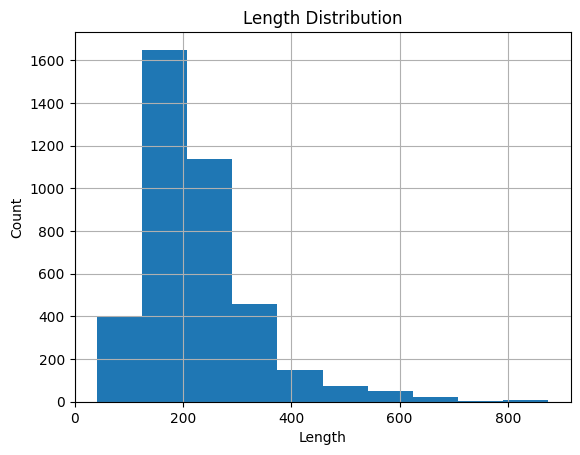

In [36]:
import matplotlib.pyplot as plt

# 길이 분포 히스토그램 시각화
train_data['conversation'].str.len().hist()
plt.title('Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()


In [37]:
max(train_data['conversation'].str.len())

874

In [45]:
train_data[train_data['conversation'].str.len()>600].count()

,0
idx,48
class,48
conversation,48


In [15]:
import pandas as pd
import re

# 대표적인 비속어/거친 표현 키워드 리스트 (필요시 추가)
slang_keywords = ['새끼', '미친', '존나', '씨발', '죽여', '병신', '지랄', '꺼져']

# 비속어가 포함된 데이터 개수 카운트
def count_slang(text):
    for word in slang_keywords:
        if word in str(text):
            return True
    return False

# 원본 훈련 데이터(train_df) 기준
train_data['has_slang'] = train_data['conversation'].apply(count_slang)
slang_ratio = train_data['has_slang'].mean() * 100

print(f"전체 데이터 중 비속어 포함 비율: {slang_ratio:.2f}%")

전체 데이터 중 비속어 포함 비율: 21.72%


## 데이터 수집
- 기존 데이터: augmentation (베이스라인 모델 실험 후 추가 진행)
- 일반대화 데이터: 합성데이터

### 일반대화 데이터 수집 : 합성 데이터 프롬프트

```
당신은 실제 사람들의 음성 대화 녹취록을 텍스트로 변환하는 전문가입니다.
자연스러운 **'일반 대화'** 텍스트를 **한 번에 50개** 생성해주세요.
단, 아래의 [포맷 및 스타일 조건]을 반드시 엄격하게 지켜야 합니다.

[포맷 및 스타일 조건]
1. 화자 구분: 화자가 바뀔 때마다 줄바꿈(\n)으로 구분합니다.
"A:", "B:", "선생님:" 같은 지시어나 라벨을 절대 텍스트에 포함하지 말고, 오직 대화 내용만 출력해야 합니다.
2. 음성 기반 노이즈: 실제 말하는 것처럼 문어체를 지양합니다.  
   - "음", "그치" 등 추임새를 섞고, 띄어쓰기 오류를 허용합니다.
   - 소리 나는 대로 적힌 약간의 오타나 줄임말 ("해얄까봐")도 1~2개 정도 포함합니다.
   - '.,!?' 특수기호를 포함합니다.
3. 길이 및 개수 조건 (총 50개):
   - 40개: 공백 포함 약 [150~300자] 내외
   - 7개: 공백 포함 약 [300~500자] 내외
   - 3개: 공백 포함 약 [600~800자] 내외

[출력 형식]
나중에 데이터를 분리할 수 있도록, 각각의 대화(1~50번) 사이에 반드시 `==========` (구분선)을 넣어주세요.
다른 부가 설명(인사말 등) 없이 오직 생성된 대화 텍스트만 출력합니다.
```

In [5]:
import google.generativeai as genai
import pandas as pd
import random
import time
from tqdm import tqdm

# 1. API 키 및 모델 설정
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-2.5-flash-lite')

# 2. 클로드에서 뽑아온 140개의 시드 데이터
raw_seed_text = """
어제 마트 갔다 왔는데 진짜 사람이 너무 많더라고.
그치, 주말이잖아. 나도 오전에 잠깐 나갔다가 그냥 돌아왔어.
그냥 평일에 가야겠다 싶었어. 계산대 줄이 진짜...
맞아 맞아, 셀프계산대도 다 차 있으면 진짜 답답하잖아.
==========
이거 어떻게 하는 거야 진짜 모르겠어.
어디 부분? 설정 들어가서 위에 보면 있잖아.
아 여기? 근데 이게 눌러도 반응이 없는데.
음, 그럼 앱 껐다 켜봐. 그래도 안 되면 재설치해야 할 수도 있어.
==========
오늘 점심 뭐 먹었어?
회사 근처 새로 생긴 데 갔는데 별로였어. 돈까스였는데 튀김이 눅눅하더라고.
아 그래? 거기 생긴 지 얼마 안 됐잖아.
처음이라 기대했는데. 음, 그냥 그 옆에 김치찌개 집 갈걸.
==========
야 나 오늘 지각할 뻔 했잖아.
또? 왜 이번엔.
버스를 잘못 탔어. 반대 방향으로.
어휴, 제대로 확인하고 타야지.
==========
이 영화 봤어? 요즘 되게 핫하던데.
아직. 보려고 했는데 시간이 없어서.
나 어제 봤는데 진짜 재밌더라. 결말이 좀 충격적이긴 했어.
스포는 하지 마 나도 볼 거야!
==========
오늘 날씨 진짜 덥지 않아?
응, 벌써 이렇게 더우면 여름엔 어쩌려고.
나 출근하다가 땀 엄청 흘렸어.
그러게, 나도 오늘부터 그냥 반팔 입고 나왔어.
==========
택배 왔대? 나 기다리는 거 있는데.
아까 초인종 울렸는데 내가 못 받았어.
아 진짜? 경비실에 맡겼으려나.
아마 그랬을 거야. 내려가봐.
==========
내일 회의 몇 시야?
오전 열 시. 근데 자료 준비됐어?
아직 좀 남아서 오늘 밤에 마무리 해얄까봐.
너무 늦게까지 하진 마. 내일 발표 있잖아.
==========
요즘 운동 다니고 있어?
한 달 됐는데 벌써 지치는 것 같아. 음.
그래도 꾸준히 해야지, 처음엔 다 힘들어.
알긴 아는데... 퇴근하고 나면 진짜 가기 싫더라고.
==========
커피 한 잔 마시러 갈까?
좋아, 나 지금 좀 졸리기도 하고.
아래 새로 생긴 카페 한번 가보자.
오케이, 5분만 기다려.
==========
야 저 배우 이름이 뭐더라. 그 드라마 나왔던.
어떤 드라마?
음, 작년에 엄청 인기 있었던 거. 형사 나오는.
아 그거? 잠깐만, 기억이 잘 안 나네.
==========
청소 언제 할 거야?
오늘 하려고 했는데 좀 피곤해서.
또 미루는 거야? 진짜.
알아, 내일은 진짜로 할게. 약속.
==========
밥 먹었어?
아직. 뭐 시켜 먹을까 고민 중이야.
나는 찜닭 먹고 싶은데 같이 시킬래?
어, 좋아. 그럼 양 좀 크게 시키자.
==========
이거 계약서 내가 프린트해야 해?
응, 두 부 뽑아서 서명란 확인하고.
뒷면도 있어?
응 있어, 두 장이야 총.
==========
저번에 빌려준 책 다 읽었어?
아직 절반 정도. 생각보다 어렵더라고.
그치, 나도 처음엔 좀 힘들었어. 중간 지나면 재밌어져.
조금만 더 읽어볼게.
==========
주말에 뭐 할 거야?
딱히 계획 없어. 그냥 집에 있을 것 같아.
나랑 드라이브 갈래? 날씨 좋으면.
어, 좋아. 연락 줘.
==========
아 진짜 배고파.
밥 먹은 지 얼마나 됐어?
두 시간? 근데 자꾸 생각나.
간식이라도 먹어, 뭔가 좀 있을 거야.
==========
이 노래 뭐야? 너 틀어놓은 거?
응, 요즘 계속 듣고 있어. 좋지 않아?
어, 나쁘진 않은데 약간 몽환적이네.
그게 매력이지.
==========
오늘 왜 이렇게 피곤하지.
어젯밤에 잠 못 잤어?
응, 세 시 넘어서 잔 것 같아.
그러면 피곤하지. 오늘 좀 일찍 자.
==========
이거 내가 사야 해 아니면 공용으로 쓰는 거야?
공용이야, 그냥 필요하면 가져다 써.
아 그래? 몰랐어.
응, 거기 선반에 있어.
==========
요즘 뭐 보고 있어? 드라마나.
음, 요즘 넷플릭스 다큐 많이 보고 있어. 드라마는 딱히.
나는 요즘 드라마를 너무 많이 봐서 탈이야.
어떤 거 봐?
요즘은 의학 드라마 빠져서 보고 있어. 근데 자꾸 밤새게 되더라.
그거 진짜 위험한데, 나도 그래서 안 봐.
==========
저 사람 우리 팀에 새로 온 거야?
응, 이번 달에 입사했어. 인사 못 했어?
아직. 뭔가 말 걸기 어색해서.
그냥 편하게 인사하면 돼, 좋은 사람이야.
==========
아 진짜 이 와이파이 왜 이러지.
어디서 끊겨?
아까부터 계속 연결됐다가 끊겼다 해.
공유기 껐다 켜봐. 그러면 보통 해결돼.
==========
점심 뭐 먹을지 정했어?
아직. 뭐 먹고 싶어?
나는 뭐든 괜찮은데, 너무 무겁지 않은 거로.
그럼 샐러드 파는 데 어때?
음, 좋아. 배는 부를지 모르겠지만.
==========
야 이거 어떻게 보내는 거야?
카톡으로? 파일 길게 눌러서 전달 누르면 돼.
아 이게 전달이구나.
응, 아니면 공유 버튼 눌러도 되고.
==========
오늘 퇴근 언제 해?
일 좀 남아서 여섯 시는 넘을 것 같아.
나도 비슷할 것 같아. 같이 나갈까?
그래, 되면 문자 줘.
==========
요즘 잠을 너무 못 자는 것 같아. 스트레스인지 아니면 그냥 습관이 된 건지.
나도 한동안 그랬어. 핸드폰을 너무 늦게까지 보다 보면 그렇게 돼.
맞아, 자려고 누우면 자꾸 뭔가 보게 되더라고.
나는 취침 모드 설정해 놓으니까 좀 나아졌어. 강제로 화면이 꺼지니까.
그거 한번 해봐야겠다. 그냥 의지로 하려니까 매번 실패해서.
그치, 그냥 환경 자체를 바꿔야 해.
==========
오늘 발표 잘 됐어?
음, 생각보다는 괜찮았어. 처음엔 좀 떨었는데.
그래도 다들 잘 들어줬던 것 같던데.
응, 질문도 몇 개 나왔는데 당황하지 않고 답했어. 근데 끝나고 나서 아, 이걸 더 말할걸 싶은 게 있더라고.
그건 다들 그래. 끝나야 생각나잖아.
맞아, 그냥 넘어가자.
==========
너 그 친구랑 요즘 잘 연락해?
가끔. 바쁜지 자주 연락은 못 하는데.
그렇구나. 나는 걔가 요즘 어떻게 지내나 궁금했어.
잘 지내고 있는 것 같아. 얼마 전에 이사했다고 하던데.
아 그래? 어디로?
그건 나도 자세히 모르겠어.
==========
이번 주 내내 비 온다던데.
진짜? 우산 계속 들고 다녀야겠네.
어, 내일 특히 많이 온다고 했어.
출퇴근 때 불편하겠다. 음.
버스 대기 줄 엄청 길어지겠지.
그러게. 그냥 좀 일찍 나가야 할 것 같아.
==========
아 배터리가 진짜 너무 빨리 닳아. 이 폰.
얼마나 됐어?
한 2년 됐나. 요즘 부쩍 심해진 것 같아.
배터리 교체 한번 해봐. 그게 훨씬 나아.
얼마나 해?
그냥 공식 서비스 가면 몇만 원 선에서 돼.
==========
나 요즘 요리 공부하고 있어.
오, 진짜? 뭐 배우고 있어?
파스타부터 시작했는데 생각보다 어렵더라. 면 삶는 것도 타이밍이 있고.
맞아, 알덴테 맞추는 게 생각보다 감이 있어야 해.
직접 먹어봐야 알겠더라고. 근데 재밌어.
잘 되면 나도 초대해줘!
==========
아까 그 회의에서 부장님이 한 말 이해했어?
솔직히 중간에 좀 흐릿해서. 요점이 뭐였어?
음, 기한 당기자는 거였던 것 같아. 다음 주까지.
아 진짜? 그럼 나 오늘부터 바빠지겠네.
나도. 일단 오늘 범위 정리해 놓자.
==========
여기 주차 어디에 하면 돼?
저기 건물 뒤쪽에 지하 있어. 그쪽으로 내려가.
유료야?
두 시간은 무료인데 그 이상이면 돈 내야 해.
아 그럼 두 시간 안에 끝내야겠다.
==========
요즘 뭐가 제일 힘들어?
음... 딱히 뭐라 말하기 어려운데, 그냥 다 좀 버거운 느낌?
그냥 쌓인 피로 같은 거?
그런 것 같아. 딱히 큰 일이 있는 건 아닌데.
그럴 때 있어. 그냥 좀 쉬는 게 나을 때.
==========
이 식당 전에 와본 적 있어?
한 번 왔는데 꽤 됐어. 그때는 메뉴가 달랐던 것 같아.
맛있었어?
응, 기억에는 괜찮았어. 오늘도 기대되는데.
나는 여기 처음이라 설레.
==========
야 나 오늘 지갑 집에 놓고 왔어.
진짜? 어떡해.
일단 핸드폰 페이로 버티고 있어.
다행이다. 그래도 요즘은 그게 있어서.
맞아, 없었으면 진짜 큰일 날 뻔했다.
==========
저 신발 어디서 샀어? 되게 예쁘다.
아, 온라인에서. 얼마 전에 세일할 때.
얼마였어?
반값 정도? 근데 요즘 품절이더라고.
아 아쉽다. 나도 사려고 했는데.
==========
오늘 왜 이렇게 사람이 많지.
공휴일이라 그렇지 않을까.
아 맞다, 오늘 그렇구나. 완전 잊고 있었어.
나도 그냥 나오다가 생각났어.
여기 이렇게 붐비는 건 오랜만에 보는 것 같아.
==========
너 그 카페 알아? 역 근처에 새로 생긴.
음, 어떤 거? 요즘 거기 새로 생긴 게 많아서.
갈색 외관에 이름이 영어로 된 데.
아 거기? 나 지난주에 갔는데 커피가 꽤 괜찮더라고. 분위기도 좀 아늑하고.
오래 있을 수 있어?
응, 콘센트도 있고 조용한 편이야. 공부하기 좋을 것 같았어.
==========
나 이번에 이직 고민 중이야.
오, 진짜? 요즘 힘들었어?
힘들다기보다 좀 더 해보고 싶은 게 생긴 것 같아서. 지금 회사가 나쁜 건 아닌데.
그럼 이직이 맞을 수도 있겠다. 불만 때문이 아니라 성장 때문이면.
응, 그래서 더 고민이 되는 것 같아. 딱 떠나야겠다는 이유가 없으니까.
그래도 한 번쯤 알아보는 건 나쁘지 않지. 지금 당장 결정하는 게 아니잖아.
맞아, 그냥 어떤 게 있나 보는 것부터 시작해볼게.
==========
저번에 네가 추천해준 책 읽기 시작했어.
오 진짜? 어때?
처음엔 좀 낯설었는데 지금은 빠져들고 있어. 주인공 캐릭터가 되게 입체적이더라고.
맞지? 그게 이 작가 특기야. 처음엔 좀 평면적으로 느껴지다가 중반부터 확 달라져.
나 어젯밤에 자려고 했는데 손을 못 놓겠더라고.
그 느낌이야! 나도 그랬어. 끝까지 한 번에 읽었잖아.
결말 어때? 스포는 말고.
음, 생각할 거리를 많이 남겨줘. 딱 떨어지는 결말이 아니라서 호불호는 있을 수 있어.
==========
요즘 살이 좀 찐 것 같아서 식단 조절 시작했어.
얼마나 됐어?
이번 주 시작했어. 아직 사흘 됐나.
처음 며칠이 제일 힘들다고 하더라.
진짜. 어제 야식 참느라 진짜 고생했어. 음.
나는 그게 제일 힘들더라. 저녁 이후가 문제야.
맞아, 낮에는 괜찮은데 밤에 배고픔이 달라.
나는 그럴 때 따뜻한 물 마시는 게 좀 도움이 됐어.
==========
나 최근에 번아웃 온 것 같아. 뭘 해도 재미가 없고 그냥 다 하기 싫어.
언제부터 그랬어?
한 달? 두 달? 잘 모르겠는데 어느 순간부터 그냥 무기력해진 것 같아.
그거 진짜 힘들겠다. 쉬고 싶어도 쉬는 게 충전이 안 되는 느낌이지?
맞아, 주말에 쉬어도 월요일에 다시 똑같이 지치는 거야. 뭔가 근본적으로 문제가 있는 것 같아.
일이 문제야 아니면 다른 것도 좀 겹쳐 있어?
음, 일도 있고 개인적으로 신경 쓰이는 것도 좀 있고. 그냥 다 맞물려 있는 것 같아.
그러면 진짜 잠깐이라도 멈추는 게 필요할 것 같아. 그냥 쉬는 게 아니라 진짜 아무것도 안 하는 시간.
그게 말은 쉬운데 막상 그러면 더 불안해지는 것 같아서.
그 불안감 자체가 이미 좀 지쳐있다는 신호일 수도 있어. 전문가 얘기 듣는 것도 고려해봐. 진짜로.
==========
나 요즘 자취 시작했거든. 처음엔 막 설레고 좋았는데 막상 해보니까 생각보다 할 게 너무 많아.
맞아, 자취 처음엔 다들 그렇게 말하더라. 밥 해 먹는 것부터 시작해서 청소, 빨래, 분리수거까지.
분리수거가 이렇게 복잡한 줄 몰랐어. 진짜. 뭘 어떻게 버려야 하는지도 헷갈리고.
그거 처음엔 다들 어려워해. 나도 처음에 그냥 다 섞어서 버렸다가 경고 받았어.
음, 나도 뭔가 잘못 버린 게 있을 것 같아서 찜찜하더라.
주민센터 가면 분리수거 가이드 종이 줘. 아니면 구청 홈페이지에도 나와 있어.
그런 게 있었구나. 진짜 필요한 정보다.
처음 몇 달이 제일 힘들어. 근데 어느 순간 다 루틴이 돼.
그 말 듣고 좀 위안이 된다. 지금은 진짜 하루하루가 허덕이는 느낌이라서.
그래도 혼자 사는 거 익숙해지면 진짜 편해. 시간 쓰는 게 완전 자유로워지니까.
==========
야 근데 오늘 점심 뭐 먹었어?
나? 그냥 편의점에서 삼각김밥 두 개 먹었는데, 진짜 배고파 죽는 줄 알았잖아.
ㅋㅋ 그거 먹고 어떻게 버텨, 진짜. 나는 그나마 구내식당 갔는데 오늘 메뉴가 너무 별로였어.
뭐였는데?
청국장이었거든. 냄새가 너무 심해서 그냥 비빔밥으로 바꿨어.
==========
음, 저 이번에 프로젝트 발표 있잖아요.
아, 그거 언제예요?
다음 주 금요일인데요, 근데 자료를 아직 반도 못 만들었어요.
에이, 아직 시간 있잖아요. 뭐가 제일 막혀요?
그게... 결론 부분을 어떻게 써야 할지 모르겠어요. 시작이랑 중간은 됐는데.
==========
엄마, 나 오늘 학원 빠지면 안 돼?
왜? 어디 아파?
아니 그게... 친구들이랑 약속이 있어서요.
무슨 약속? 학원은 돈 내고 다니는 건데.
그냥 밥 먹기로 했는데, 오늘만요.
안 돼. 끝나고 먹어.
==========
야 너 요즘 헬스 다닌다고 했지?
어, 두 달째 다니는 중인데 진짜 힘들다.
그래도 몸 좋아지는 거 보이잖아.
뭐가, 아직도 배 나왔는걸. 근데 확실히 체력은 좋아진 것 같기는 해.
얼마나 다녀?
주 삼 회? 근데 요즘은 바빠서 두 번 겨우 가.
==========
저기요, 혹시 이 근처에 카페 있나요?
음, 저도 잘 모르는데... 저기 골목 안쪽에 하나 있는 것 같던데요.
아 거기요? 근데 문 닫지 않나요?
아, 맞아요 거기 요즘 공사 중이라고 봤어요.
그렇구나, 감사합니다. 좀 더 찾아봐야겠네요.
==========
오늘 회의 몇 시야?
세 시. 아, 맞다 오늘 자료 프린트했어?
아 진짜 깜빡했다. 지금 해도 되려나.
빨리 해. 십 분 남았어.
야 왜 이제 말해줘!
나도 방금 생각났거든!
==========
이거 주문하려고 하는데요, 혹시 포장 되나요?
네, 포장 가능합니다. 몇 인분이세요?
두 인분이요. 음... 여기 뭐가 제일 잘 나가요?
저희는 갈비찜이랑 된장찌개가 많이 나가요.
그럼 갈비찜으로 할게요.
==========
너 지금 어디야?
나? 지금 버스 안. 왜?
아 그냥, 집 가는 길이야?
응, 한 이십 분 남은 것 같은데. 왜, 무슨 일 있어?
아니 그냥 심심해서. 같이 뭐 할 생각 있나 해서.
오늘은 좀 피곤해서 그냥 집에 갈게. 미안.
==========
아 진짜 오늘 너무 힘들었다.
왜, 무슨 일 있었어?
손님이 진짜 진상이었어. 환불해달라는데 영수증도 없고.
어떻게 됐어?
그냥 내가 죄송하다고 계속 말하다가 넘어갔어. 진짜 멘탈 나가는 줄.
ㅠㅠ 수고했다 진짜.
==========
선생님, 이번 시험 범위가 어디까지예요?
교과서 3단원까지고 프린트물은 다 봐야 해요.
아... 프린트도 다요?
네. 근데 핵심만 추려놨으니까 그렇게 많지 않아요.
그거라도 다행이다, 감사합니다.
==========
음, 저 여기 처음 오는데요. 메뉴 추천해주실 수 있어요?
어떤 거 좋아하세요? 달달한 거요, 아니면 진한 커피요?
음... 달달한 거 좋아해요.
그럼 바닐라라떼나 흑당밀크티 어떠세요?
흑당밀크티로 할게요!
==========
야 오늘 치킨 시킬까?
나는 좋은데, 몇 마리?
두 마리면 되겠지?
우리 둘이서? 좀 많지 않아?
어차피 남으면 내일 먹으면 되지 뭐.
그럼 한 마리 반 시키자. 양 조절해서.
==========
과장님, 보고서 오늘까지 제출해야 하는 거 맞죠?
네, 오늘 6시까지요. 다 됐어요?
거의 다 됐는데, 데이터 하나 확인 중이에요.
늦지 않게 해줘요. 검토 시간 필요하니까.
네, 5시 전에 드릴게요.
==========
야 너 그 드라마 봤어? 어제 방영된 거.
어, 봤는데! 진짜 반전 대박 아니었어?
나 진짜 충격받았어. 그 사람이 그럴 줄 몰랐잖아.
그치? 처음부터 복선이 있었던 거 같기도 하고.
맞아, 2화에서 이미 힌트 줬던 것 같더라고.
==========
엄마 나 배고파.
밥 해놨잖아, 냉장고에.
그거 언제 해놓은 거야?
오늘 점심에. 데워서 먹어.
반찬은?
어젯밤 남은 거 있어. 먹을 만해.
==========
아 지갑을 어디다 뒀지, 진짜.
또 잃어버린 거야?
잃어버린 건 아닌데, 못 찾겠어. 소파 밑은 봤어?
응, 없던데. 현관은?
잠깐만... 아 여기 있었다. 신발장 위에.
거기 두면 자꾸 그러지.
==========
저 오늘 면접 있는데요.
그래요? 어디요?
음... 마케팅 쪽 회사인데요. 솔직히 좀 떨려요.
당연하죠. 근데 잘 준비했으면 괜찮을 거예요.
그렇긴 한데, 자꾸 말 실수할까봐 걱정돼요.
심호흡하고 천천히 말하면 돼요.
==========
야 나 오늘 진짜 이상한 꿈 꿨어.
뭔 꿈?
갑자기 학교를 다시 다니는 건데, 시험 공부를 하나도 못 했잖아.
아 그 꿈 나도 가끔 꿔. 진짜 식은땀 나는 꿈이지.
맞아! 너무 리얼해서 일어나고도 한참 멍했어.
==========
이거 환불 가능한가요? 며칠 전에 산 건데요.
영수증 있으세요?
네, 여기요.
음, 개봉은 하셨나요?
아 이건 안 했는데, 이거는 뜯었어요.
뜯은 건 교환만 가능하세요. 안 뜯은 건 환불 돼요.
==========
오빠 나 오늘 되게 속상한 일 있었어.
왜? 무슨 일인데?
친구가 나한테 좀 심한 말 한 것 같아서. 그게 계속 생각나.
뭐라고 했는데?
그냥... 내가 좀 예민하다고. 근데 말하는 방식이 좀 상처였어.
에이, 그 친구가 그냥 말을 잘 못 하는 거일 수도 있어.
==========
근데 요즘 물가가 너무 오르지 않았어?
진짜. 마트 갔다가 깜짝 놀랐잖아.
뭐가 제일 심하더라?
계란이랑 채소가 특히 심하던데. 상추가 한 봉에 얼마인지 알아?
얼마야?
사천원 넘더라. 진짜 황당해서.
==========
야 그 영화 어때? 볼 만해?
음, 솔직히 좀 지루한 부분이 있긴 한데 후반부는 괜찮아.
몇 시간짜리야?
두 시간 반. 그래서 좀 길게 느껴지기도 해.
그럼 OTT에서 나올 때 보는 게 낫겠다.
==========
저기, 혹시 지금 자리 있나요?
잠깐만요... 저쪽 2인 테이블은 가능해요.
감사합니다. 메뉴판 주실 수 있나요?
네, 여기요. 주문 준비되시면 불러주세요.
==========
너 오늘 왜 이렇게 늦었어?
아, 지하철이 갑자기 지연됐어. 15분이나 기다렸잖아.
그럼 문자 좀 보내주지.
보내려고 했는데 폰 배터리 나갔거든.
아 진짜? 다음엔 보조배터리 챙겨.
==========
엄마 이거 입어도 돼?
그게 뭔데?
여동생 원피스인데 잠깐만 빌리려고.
여동생한테는 물어봤어?
아 아직요. 물어볼게요.
==========
요즘 유튜브에 시간을 너무 쏟는 것 같아.
나도. 눕자마자 핸드폰 보다가 새벽 두 시야.
중독이지 진짜. 근데 안 보면 또 뭔가 허전하잖아.
그치, 그냥 습관이 돼버린 거지. 나는 요즘 타이머 맞춰놓고 보려고.
그게 효과 있어?
조금은? 그래도 타이머 끄고 더 보긴 해 ㅋㅋ.
==========
주임님, 이 서류 여기다 두면 될까요?
아, 거기 말고 이쪽 파일에 넣어줘요.
아 이 파일이요?
네, 날짜 순으로 정리해서요.
네, 알겠습니다.
==========
야 나 오늘 소개팅 어땠는지 궁금하지?
어, 맞다! 어떻게 됐어?
음... 나쁘지는 않았어. 근데 딱히 설레지가 않아.
조건은 어때?
괜찮더라고. 근데 대화가 좀 어색했어.
원래 처음엔 어색한 거 아니야?
==========
여기 주차 몇 시간까지 무료예요?
2시간까지 무료고요, 이후로는 10분당 500원이에요.
영수증 찍어야 하나요?
네, 1층 안내 데스크에서 확인해드려요.
감사합니다.
==========
야 이번 주말에 뭐 해?
딱히 계획은 없는데, 왜?
같이 등산이나 갈까 해서.
음... 등산은 좀 힘들지 않아?
그 높은 데 말고 그냥 가볍게 산책 코스로.
그러면 괜찮겠다. 어디 생각해 둔 데 있어?
==========
아 요즘 잠을 통 못 자겠어.
왜, 스트레스야?
그것도 있는데, 그냥 눕자마자 생각이 너무 많아.
나도 그런 시기 있었어. 폰이라도 내려놓고 자?
그게 제일 어렵잖아.
==========
선배님, 오늘 회식 참여하시는 거죠?
아, 저 오늘은 좀 일이 있어서.
아 그렇구나요, 아쉽네요.
다음엔 꼭 함께할게요.
네! 알겠습니다.
==========
야 그 애 연락 왔어?
어, 카톡 왔는데 뭐라고 해야 할지 모르겠어.
뭐라고 보냈는데?
그냥 밥 먹었냐고.
ㅋㅋ 그냥 응 먹었어 하면 되지.
그게 너무 단답 아니야? 이어질 말이 없잖아.
==========
저 지금 택시 탔는데요, 한강 쪽으로 가주세요.
어느 입구로 갈까요?
음, 잠실 쪽이요.
네, 지금 막히는 구간 있어서 조금 돌아갈 수도 있어요.
그래도 괜찮아요.
==========
야 너 지금 집이야?
응, 왜?
아 나 근처 왔는데 잠깐 들러도 돼?
갑자기? 집이 좀 지저분한데.
괜찮아 나 상관없어, 잠깐만 있다 갈게.
==========
이번에 새로 나온 폰 살까 고민 중이야.
얼마야?
백오십은 되더라고.
그거면 그냥 쓰던 거 더 쓰는 게 낫지 않아?
근데 배터리가 너무 빨리 닳아서.
그럼 배터리만 교체하면 안 돼?
==========
오늘 수업 어땠어?
그냥 그랬어. 교수님이 또 ppt만 읽으셨어.
진짜? 나 오늘 결석했는데 잘했다.
ㅋㅋ 맞아, 크게 놓친 건 없을 거야.
==========
아 참, 내일 택배 오는 거 받을 수 있어?
나? 몇 시?
낮 사이라고 하던데, 정확히는 모르겠어.
음, 나 오전엔 외출인데 오후에는 있어.
그럼 오후로 바꿔달라고 해볼게.
==========
저 머리 자르러 왔는데요.
네, 예약하셨어요?
아니요, 혹시 지금 바로 가능한가요?
잠깐만요... 한 20분 기다리시면 될 것 같아요.
네, 기다릴게요.
==========
오늘 날씨 진짜 덥지 않아?
완전. 나 나오는데 땀 벌써 났잖아.
여름도 아닌데 이게 뭐야.
이상기후야 진짜. 그치?
맞아, 요즘 봄인지 여름인지 모르겠어.
==========
야 나 지금 술 한 잔 생각 나는데 너도 그렇지 않아?
맞아, 오늘 같은 날 딱 맥주 한 캔인데.
퇴근하고 편의점에서 마실까?
나 오늘 차 끌고 왔는데.
그럼 너 제로 음료 마시고 나 혼자 마셔야겠네 ㅋㅋ.
그러든지, 같이 앉아 있어줄게.
==========
팀장님, 저 이번 프로젝트에서 담당 범위가 정확히 어떻게 되는지 좀 여쭤봐도 될까요? 제가 지난 회의 때 말씀하신 거 메모를 했는데, 디자인 검수 부분이 제 담당인지 아닌지 헷갈려서요.
아, 그 부분은 원래 디자인팀이 하기로 했는데 일정이 겹쳐서 일단 이번엔 네가 맡아줘야 할 것 같아. 추가 업무인 건 알고 있으니까 이번 달 업무 배분에서 다른 거 좀 줄여줄게.
아 그렇군요, 감사합니다. 그럼 검수 기준이나 체크리스트 같은 게 있으면 공유 부탁드려도 될까요?
응, 이따 메일로 보내줄게. 모르는 거 있으면 언제든지 물어봐.
네, 알겠습니다. 감사합니다.
==========
야 너 요즘 그 친구랑은 잘 지내? 저번에 좀 어색하다고 했잖아.
어, 그게... 솔직히 아직도 좀 그래. 딱히 싸운 것도 아닌데 왜 이렇게 어색한지 모르겠어.
그냥 오래 못 만나서 그런 거 아닐까? 한번 밥이라도 먹으면 풀리지 않아?
그럴 수도 있긴 한데, 먼저 연락하는 게 좀 어색하기도 하고. 먼저 연락했다가 반응이 별로면 더 상처받을 것 같아서.
아 그 마음 이해해. 근데 그 친구도 비슷하게 생각하고 있으면 어떡해. 둘 다 기다리다가 그냥 멀어지는 거잖아.
맞긴 한데... 어떻게 먼저 연락해야 할지 모르겠어. 그냥 자연스럽게 "요즘 어때?" 같은 거 보내도 이상하지 않아?
전혀 안 이상해. 오히려 반가워하지 않을까?
==========
음, 어디서부터 말해야 하지. 저 요즘 직장 때문에 고민이 되게 많아요. 딱히 직장이 힘들다기보다는, 제가 이 일이 맞는 건지를 모르겠어요. 벌써 3년째 다니고 있는데, 익숙해지는 건지 무뎌지는 건지 구분이 안 가거든요.
그 부분이 많이 힘드시겠다. 처음에는 어떤 마음으로 시작하셨어요?
처음에는 그냥 취업이 급했고, 이 정도면 괜찮다 싶어서 들어갔어요. 근데 막상 하다 보니까 뭔가 저랑은 좀 다른 방향인 것 같기도 하고. 그렇다고 당장 나올 수도 없는 상황이고요.
지금 제일 걸리는 게 경제적인 부분인가요, 아니면 다른 걸 할 수 있을까 하는 막연한 두려움인가요?
둘 다인 것 같아요. 다른 걸 해보고 싶다는 생각은 있는데, 뭘 하고 싶은지도 모르겠고. 그냥 지금 하기 싫다는 감정이 먼저인 것 같아서 그게 더 무서워요.
그 감정 자체가 나쁜 건 아니에요. 지금 뭔가 변화가 필요하다는 신호일 수도 있으니까. 급하게 결정하기보다는 하고 싶은 것들을 조금씩 찾아보는 것도 방법이에요.
==========
야 나 요즘 진짜 이상한 것 같아. 아무 이유도 없는데 갑자기 눈물이 나거나, 그냥 아무것도 하기 싫을 때가 많아. 밥도 먹기 귀찮고, 친구 만나는 것도 좀 부담스럽고. 나 이상한 거야?
아니, 이상한 거 아니야. 근데 그게 얼마나 됐어?
한... 한 달? 됐나. 처음엔 그냥 피곤한 건가 했는데 계속되니까 나도 좀 무서워.
그거 진짜 힘들겠다. 혼자 그걸 한 달이나 버텼어?
뭐, 그렇다고 어떻게 할 수 있는 것도 아니잖아. 그냥 하루하루 보내는 거지.
근데 있잖아, 그 정도 오래됐으면 그냥 넘기기보다는 한 번쯤 상담이나 진료를 받아보는 게 어떨까. 부담스럽게 들릴 수 있는데, 이런 거 혼자 끌고 가는 게 더 힘들 수 있거든.
상담이라고 하면 솔직히 좀 겁나긴 해. 근데... 이렇게 계속되면 나도 뭔가 해야 할 것 같긴 해.
같이 알아봐줄까? 처음 한 번만 가보는 거야. 억지로 계속 가야 하는 거 아니니까.
==========
저 이번에 이사를 해야 할 것 같아요. 집이 재계약 시기인데 집주인이 갑자기 금액을 많이 올려서요.
얼마나 올렸는데요?
음, 이천만 원 가까이요. 너무 갑작스러워서 당황스러웠어요.
그거 진짜 갑자기네요. 협상은 해보셨어요?
네, 좀 낮춰달라고 했는데 여기서 더는 못 내리겠다고 하더라고요. 그래서 결국 다른 집을 알아봐야 할 것 같아요.
그럼 부동산 여러 곳 다녀보셔야 하겠네요. 어느 동네 생각하고 계세요?
아직 딱히는 없어요. 지금 동네가 편하긴 한데, 이 근처는 가격이 다 비슷하게 올라서. 좀 더 외곽으로 나갈까도 생각하고 있어요.
출퇴근 괜찮으세요?
그게 좀 걸리긴 하는데, 월세 차이가 크면 그냥 좀 더 이동하는 걸 감수해야죠 뭐.
==========
야 너 어제 유튜브에 올라온 거 봤어? 그 요리 채널.
어, 봤는데 진짜 따라해보고 싶더라.
근데 재료가 좀 특이하지 않아? 구하기 어려울 것 같던데.
맞아, 나도 그거 생각했어. 마트 몇 군데 찾아봐야 할 듯.
==========
저기요, 영수증 좀 다시 받을 수 있을까요?
아, 방금 결제하신 거요?
네, 방금요. 빠뜨리고 그냥 나온 것 같아서요.
잠깐만요... 네, 여기 있어요.
감사합니다!
==========
오늘 왜 이렇게 졸리지 진짜.
어제 늦게 잔 거야?
아니, 열두 시에는 잤는데 자꾸 중간에 깨더라고.
그거 숙면을 못 한 거잖아. 나도 요즘 그래.
뭔가 스트레스 받는 게 있나봐 우리 둘 다.
==========
언니, 이 립 색 어때요? 너무 진한가요?
음, 오히려 피부 톤이랑 잘 맞는데요?
진짜요? 제가 보기엔 좀 튀는 것 같아서.
아니에요, 자연스러워요. 그냥 쓰세요.
그렇게 말해주니 다행이다!
==========
지금 어디야? 나 다 왔는데.
나 지금 지하 1층에 있어, 엘리베이터 앞.
어, 나 거기 지나쳤다. 잠깐만, 돌아갈게.
그냥 내가 올라갈게. 몇 층이야?
3층 스벅.
==========
아 진짜 이번 달 카드값 보고 놀랐잖아.
얼마나 나왔어?
칠십 넘었어. 진짜 내가 뭘 이렇게 썼나.
뭐에 많이 썼어?
외식이 좀 많았던 것 같아. 요즘 집밥을 통 안 해먹어서.
==========
저 지금 인턴 지원하려는데요, 자기소개서 좀 봐주실 수 있어요?
어, 그럼 보내봐요.
진짜요? 감사해요. 근데 너무 길면 좀 잘라줘도 돼요.
일단 봐야 알죠. 언제까지 마감이에요?
이번 주 금요일이에요.
==========
엄마 나 오늘 좀 일찍 와도 돼?
그래, 왜? 일찍 끝나?
응, 오늘 수업이 한 개 취소됐어.
그래? 오면 저녁 같이 먹자.
뭐 먹어?
된장찌개 끓여놓을게.
==========
야 운동화 새로 샀어?
어, 한정판이었는데 어떻게 구했지.
어디서?
앱으로 추첨 들어갔는데 됐어. 진짜 처음 당첨된 거야.
대박, 나는 맨날 떨어지더라.
==========
저 여기 처음인데요, 가입 어떻게 해요?
신분증 있으세요?
네, 여기요.
이 서류에 기본 정보 적어주시면 되는데요, 이메일이랑 연락처도요.
혹시 멤버십 카드 바로 발급되나요?
네, 오늘 바로 받아가실 수 있어요.
==========
아 나 오늘 버스에서 신발 밟혔어.
에이, 심했어?
새로 산 흰 운동화인데. 자국이 남아버렸어.
세탁기 돌리면 되지 않아?
운동화를 세탁기에 넣어도 돼?
전용 세탁망 넣고 하면 돼, 나 해봤어.
==========
팀장님, 다음 주 월요일 오전에 외근이 있는데 오후 회의 참석이 가능할지 여쭤봐도 될까요?
몇 시 회의인데요?
오후 두 시요.
외근 얼마나 걸려요?
점심 전에는 끝날 것 같아요.
그럼 가능할 것 같네요. 혹시 늦어지면 미리 연락 줘요.
==========
야 너 요즘 독서 한다고 했잖아, 뭐 읽어?
음, 요즘은 에세이 위주로 읽고 있어. 소설은 집중이 잘 안 되더라고.
에세이 추천해줄 수 있어?
있지. 그냥 일상 글인데 읽기 편해서 좋아.
제목이 뭔데?
나중에 카톡으로 보내줄게, 지금 생각이 안 나.
==========
저기, 이 옷 다른 사이즈 있나요?
지금 어떤 사이즈 찾으세요?
M 있나요?
잠깐 창고 확인해볼게요... 죄송한데 M은 지금 없어요.
L은요?
L은 있어요.
==========
아 진짜 요즘 배달 음식 너무 자주 시키는 것 같아.
나도. 일주일에 몇 번이야?
거의 매일인 것 같아. 집밥 해먹는 게 귀찮아서.
그러면 식비가 엄청 나오지 않아?
맞아, 이번 달 배달 앱 결제 내역 보고 소름 돋았어.
==========
어 선배, 여기 계셨어요?
응, 밥 먹으러 내려왔다가. 너는?
저도 점심 먹으러요. 같이 가도 될까요?
그럼요, 같이 가요.
==========
야 나 요즘 피부가 왜 이러지.
어떤데?
갑자기 뭐가 올라왔어. 턱 쪽에.
스트레스 아니야? 나 스트레스 받으면 꼭 거기서 나더라.
그럴 수도 있겠다. 요즘 좀 무리하긴 했어.
==========
아저씨, 이 생선 오늘 들어온 거 맞죠?
네, 오늘 아침에 들어온 거예요.
그럼 이거 두 마리 주세요.
손질해드릴까요?
네, 부탁드려요.
==========
언제까지 기다려야 해? 나 배고파 죽겠어.
조금만, 십 분만 더.
십 분 전에도 십 분이라고 했잖아.
미안, 진짜 거의 다 됐어. 국만 끓이면 돼.
빨리해줘.
==========
야 너 내일 시간 돼?
오후는 돼. 오전은 좀 애매해.
오후 두 시쯤 어때?
괜찮아. 뭐 할 건데?
같이 시청 근처 팝업스토어 가볼까 해서.
거기 줄 엄청 길지 않아?
==========
실장님, 저 오늘 반차 쓰려고 하는데요.
오전이요, 오후요?
오후요. 병원 예약이 있어서요.
몇 시?
두 시 반이요.
그럼 한 시 이후로 쓰면 되겠네요. 결재 올려줘요.
==========
야 나 진짜 어제 황당한 일 있었어.
뭔데?
카페에서 공부하고 있는데 옆 사람이 전화를 엄청 크게 하는 거야.
에이, 그냥 이어폰 끼지.
끼고 있었는데도 다 들려. 목소리가 너무 커서.
그 카페 방음이 별론가봐.
==========
이거 어떻게 조립하는 거야, 설명서가 너무 어렵네.
어디 봐봐.
여기 이 부분. 화살표가 어디로 가는 건지 모르겠어.
음... 이거 이렇게 끼우는 거 아니야?
아 진짜네, 됐다!
설명서 그림이 너무 작아서 그래.
==========
강아지가 요즘 밥을 잘 안 먹어서 걱정돼요.
얼마나 됐는데요?
한 삼 일? 좀 됐어요.
체중이 빠진다든가 하는 건 없어요?
딱히 그런 건 없는데 원래 잘 먹던 애라서.
일단 사료 바꿔보시고, 그래도 계속 이러면 내원 한번 해보세요.
==========
오늘 회의 자료 언제까지 공유해줄 수 있어?
오전 중으로는 보낼게.
혹시 PPT로 만들어줄 수 있어?
응, PPT로 할게. 표지 템플릿 있어?
이전에 쓰던 거 폴더에 있어. 거기서 찾아봐.
알겠어.
==========
야 나 요즘 커피 줄이려는데 쉽지 않다.
하루에 몇 잔이야?
세 잔은 마시는 것 같아.
세 잔이면 좀 많긴 하다.
그치, 근데 안 마시면 두통이 와서.
그게 이미 카페인 의존인 거야.
==========
죄송한데요, 화장실이 어디 있나요?
저쪽 복도 끝에 있어요.
감사합니다.
==========
야 저번에 빌려준 돈 혹시 기억해?
어, 기억하지. 삼만 원이잖아.
맞아. 이번 주 안으로 줄 수 있어?
응, 내일 카카오페이로 보낼게.
고마워, 미안해.
==========
저 혈압이 좀 높게 나왔거든요, 걱정해야 하나요?
얼마나 나왔어요?
145에 90이요.
약간 높은 편이긴 해요. 최근에 스트레스 받는 일 있었어요?
좀 있었어요.
일단 생활습관 조절해보시고 한 달 후에 다시 재봐요.
==========
엄마 나 이번에 용돈 좀 올려주면 안 돼?
얼마?
한 오만 원?
지금도 충분하지 않아?
요즘 물가가 너무 올라서요.
뭐에 쓰려고?
==========
야 고등학교 동창 모임 다음 달에 있대.
어, 나한테도 연락 왔어. 갈 거야?
글쎄, 좀 귀찮기도 하고.
그렇긴 해. 근데 오래간만에 보는 것도 좋지 않을까.
어, 맞아. 생각해볼게.
==========
저기요, 지금 대기 얼마나 돼요?
지금 한 30분에서 40분 정도 기다리실 것 같아요.
그렇군요. 번호표 뽑으면 되나요?
네, 저기서 뽑아서 기다리시면 문자 드려요.
네, 감사합니다.
==========
요즘 뉴스 보면 진짜 답답하다.
뭐 때문에?
그냥 전반적으로 다. 좋은 소식이 하나도 없어.
나는 그래서 뉴스 의도적으로 안 봐.
그게 낫겠다 싶기도 해. 근데 모르면 또 불안하고.
그 딜레마가 있지.
==========
과제 다 했어?
아직, 두 개 남았어.
언제까지야?
내일 자정까지. 근데 하나가 그룹 과제라 혼자 할 수가 없어.
조원들은 뭐래?
연락이 잘 안 돼서 좀 답답해.
==========
아, 저 예약한 사람인데요.
이름이 어떻게 되세요?
김수연이요.
네, 확인됩니다. 2인이시죠?
네.
안쪽 창가 자리로 안내해드릴게요.
==========
야 나 요즘 자기 전에 명상 해보려는데 어때?
나도 해봤는데, 처음엔 좀 어색해.
어떻게 하면 돼?
그냥 눈 감고 호흡에 집중하는 건데, 앱 쓰면 편해.
무슨 앱?
유튜브에도 많던데, 그냥 '수면 명상' 검색해봐.
==========
저 이번에 자격증 공부 시작하려고 하는데요. 뭐부터 해야 할지 모르겠어서요.
어떤 분야 자격증이에요?
사무 쪽이요. 컴활 같은 거요.
그럼 시험 일정 먼저 확인하고 역산해서 계획 세우는 게 좋아요.
아, 그렇게 하면 되겠네요. 독학해도 될까요?
컴활 1급은 좀 어렵고, 2급은 독학으로도 충분해요. 기출문제 위주로 하면 돼요.
==========
야 우리 동네에 새로 생긴 식당 가봤어?
어디?
버스 정류장 옆에 생긴 거 있잖아, 한식집.
아 거기? 아직 못 가봤는데.
나 어제 갔다 왔는데 생각보다 맛있더라고.
진짜? 다음에 같이 가자.
==========
야 솔직히 요즘 의욕이 별로 없어. 하고 싶은 것도 없고, 뭘 해야 할지도 모르겠고. 딱히 힘든 건 없는데 그냥 매일 똑같은 것 같아. 이런 게 번아웃인가?
그럴 수 있어. 근데 딱히 힘든 것도 없는데 무기력한 게 오히려 더 답답하지 않아?
맞아, 그게 더 이상해. 힘들면 원인이라도 있는데, 그냥 아무 이유 없이 이런 거잖아.
나도 비슷한 시기가 있었어. 그땐 그냥 작은 거 하나씩 해봤어. 산책이든, 좋아하는 거 먹든.
근데 그것조차 귀찮을 때는 어떻게 해?
그때는 그냥 쉬는 게 맞는 것 같아. 억지로 뭔가 하려고 하면 더 지치더라고.
==========
저 오늘 처음으로 혼자 해외 여행을 가려고 하는데요, 준비할 게 너무 많아서 뭐부터 해야 할지 모르겠어요.
어디 가려고요?
일본이요. 오사카.
그럼 일단 항공권이랑 숙소가 제일 먼저죠. 요즘 성수기라 미리 잡는 게 좋아요.
숙소는 호텔이 낫나요, 호스텔이 낫나요?
혼자라면 호스텔이 가성비 좋긴 한데, 처음이면 호텔이 편할 수 있어요. 로케이션이 제일 중요해요.
그렇군요. 환전은 얼마 정도 해야 해요?
3박 기준으로는 한 30만 원에서 40만 원 정도면 충분한 편이에요. 카드 쓸 수 있는 데도 많고요.
==========
저 요즘 부모님이 자꾸 결혼 얘기를 꺼내셔서 좀 힘들어요. 제 나이가 이제 서른이라고, 슬슬 생각해봐야 하지 않냐고 하시는데, 저는 아직 거기까지 생각할 여유가 없거든요.
부모님 입장에서는 걱정이 되시는 거겠죠. 근데 본인 입장에서는 지금 당장 결혼보다 다른 게 우선인 거잖아요.
맞아요. 직장도 이제 좀 자리 잡힌 것 같고, 하고 싶은 것들도 있는데, 자꾸 그 얘기가 나오면 압박감이 느껴지거든요.
그 얘기 나올 때 부모님한테 직접 말씀드린 적은 있어요?
솔직히 말했다가 싸울까봐 그냥 얼버무리게 되더라고요. 근데 그러면 또 계속 반복되는 것 같고.
그게 더 지치죠. 한 번쯤은 차분하게, 싸우는 게 아니라 내 생각을 그냥 설명하는 방식으로 얘기해보는 게 어떨까요?
==========
나 어제 낮에 카페 가서 혼자 세 시간 있었는데 진짜 행복하더라.
ㅋㅋ 혼자 뭐 했어?
책 좀 읽다가 그냥 멍도 때리고. 음악 듣고.
그거 요즘 사람들이 말하는 혼자만의 충전 시간이네.
맞아. 나 원래 혼자 있는 거 별로였는데 요즘은 그게 필요한 것 같더라고.
==========
야 나 오늘 회사에서 진짜 황당한 말 들었어.
뭔데?
내가 한 작업을 팀장이 자기가 한 것처럼 위에 보고한 거야.
진짜? 그거 너무 한 거 아니야.
나도 황당해서 말이 안 나왔어. 근데 따지기도 좀 그렇고.
그건 진짜 그냥 넘기면 안 될 것 같은데.
==========
할머니, 여기 아파요?
응, 여기 이렇게 하면 좀 찌릿찌릿해.
언제부터요?
한 이삼 일 됐나. 처음엔 좀 있다 말겠지 했는데 계속 그러네.
그럼 병원 가봐야 해요. 제가 모셔다드릴게요.
에이, 괜찮아.
==========
야 우리 내년에 여행 한 번 제대로 가자.
어디?
유럽 어때? 이탈리아나 스페인.
ㅋㅋ 그거 돈이 얼마야.
그래서 지금부터 모으자는 거지. 내년이면 일 년이잖아.
음, 그러면 가능할 수도 있겠는데?
==========
저기요, 지금 자리 두 개 붙여서 앉을 수 있나요?
지금 붙어있는 자리가 없어서요. 저쪽에 두 자리가 바로 옆인데 거기는 괜찮으세요?
어, 그 자리 괜찮아요.
안내해드릴게요.
==========
오빠 나 오늘 시험 망친 것 같아.
얼마나?
선택지를 두 개 사이에서 맨날 틀리는 거야. 알 것 같은데 막상 찍으면 틀리고.
그거 진짜 제일 억울하지.
맞아, 근데 사실 제대로 공부를 못 하긴 했어. 이번엔 할 수 없다.
다음엔 더 일찍 시작하면 되지.
==========
야 나 아까 편의점에서 이상한 거 봤어.
뭔데?
어떤 아저씨가 도시락 세 개를 계산하고 나서 다시 들어와서 하나 더 가져가시는 거야.
계산했어?
응, 그것도 하셨어. 네 개를 먹으시려는 거였나봐.
ㅋㅋ 그냥 배고프신 거 아니야?
==========
아 요즘 연락도 잘 안 되고, 만나기도 어렵고, 솔직히 이 관계를 유지하는 게 맞는 건지 모르겠어. 오래 사귄 건 맞는데, 그게 이유가 되는 건지도 헷갈려. 내가 너무 많이 참는 것 같기도 하고, 아니면 내가 예민한 건지도 모르겠고.
그 두 가지가 동시에 느껴지면 진짜 혼란스럽지. 구체적으로 어떤 부분이 제일 힘들어?
연락인데, 그냥 바쁜 거랑 연락을 안 하는 게 다르잖아. 근데 그걸 말하면 또 예민하다고 할까봐 말도 못 해.
그게 쌓이면 진짜 지치지. 말 못 하고 있는 게 언제부터야?
한... 두 달? 됐나. 처음엔 이해하려고 했는데, 그게 반복되니까.
솔직히 말 안 하면 상대방은 모를 수 있어. 한 번은 얘기해봐야 할 것 같아, 결론이 어떻든.
"""

# '==========' 기준으로 잘라서 시드 리스트 만들기
seed_conversations = [text.strip() for text in raw_seed_text.split('==========') if text.strip()]
print(f"✅ 준비된 시드 데이터 개수: {len(seed_conversations)}개")


✅ 준비된 시드 데이터 개수: 140개


In [6]:
# 3. 데이터 생성 세팅
total_to_generate = 860
generated_data = []

# seed data도 최종 데이터에 포함
for i, conv in enumerate(seed_conversations):
    generated_data.append({"id": f"normal_{i+1}", "text": conv, "label": "일반 대화"})

# 4. API 반복 호출
print("🚀 API를 통해 추가 일반 대화 합성을 시작합니다...")
start_idx = len(seed_conversations) + 1
generated_count = 0  # 실제로 생성에 성공한 개수 카운트

with tqdm(total=total_to_generate) as pbar:
    while generated_count < total_to_generate:
        sampled_seeds = random.sample(seed_conversations, 2)
        examples_text = "\n\n[예시]\n" + "\n\n".join(sampled_seeds)
        length_condition = random.choices(["150~300자", "300~500자", "600~800자"], weights=[0.8, 0.15, 0.05], k=1)[0]

        prompt = f"""당신은 실제 사람들의 음성 대화 녹취록을 텍스트로 변환하는 전문가입니다.
아래 제공된 [예시]들과 완벽하게 동일한 톤앤매너, 문체, 노이즈 수준을 유지하면서 내용이 전혀 다른 새로운 일반 대화 1개를 생성해주세요.

[조건]
1. A:, B: 같은 라벨 없이 줄바꿈(\\n)으로만 화자를 구분하세요.
2. 예시들처럼 음, 그치 같은 자연스러운 추임새와 약간의 띄어쓰기 오류를 허용하세요.
3. 길이는 공백 포함 약 {length_condition} 내외로 맞춰주세요.

{examples_text}

[결과 출력]
오직 새로 생성된 1개의 대화 텍스트만 출력하세요. (추가 설명 금지)"""

        try:
            response = model.generate_content(prompt)
            result_text = response.text.strip()

            # 데이터 저장
            generated_data.append({
                "id": f"normal_{start_idx + generated_count}",
                "text": result_text,
                "label": "일반 대화"
            })

            generated_count += 1  # 성공했을 때만 카운트 증가
            pbar.update(1)        # 진행 바 업데이트
            time.sleep(15)         # 정상 처리 시 휴식

        # 중간 저장 (10개마다)
            if generated_count % 10 == 0:
                pd.DataFrame(generated_data).to_csv("temp_backup.csv", index=False, encoding="utf-8-sig")

        except Exception as e:
            if "429" in str(e):
                print(f"\n🛑 할당량 초과! 90초 휴식... (에러: {e})")
                time.sleep(90)
            else:
                print(f"\n⚠️ 에러 발생! 10초 휴식... (에러: {e})")
                time.sleep(10)

# 5. 루프가 완전히 다 끝나면 최종적으로 CSV 저장
df = pd.DataFrame(generated_data)
df.to_csv("final_normal_conversations_1000.csv", index=False, encoding="utf-8-sig")
print(f"\n총 {len(df)}개의 데이터 수집 및 저장 완료! 파일(final_normal_conversations_1000.csv)을 확인하세요.")

🚀 API를 통해 추가 일반 대화 합성을 시작합니다...


  3%|▎         | 22/860 [05:55<3:53:28, 16.72s/it]WARNING:tornado.access:429 POST /v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 330.03ms



🛑 할당량 초과! 90초 휴식... (에러: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 45.395930996s.)



🛑 할당량 초과! 90초 휴식... (에러: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite
Please retry in 14.837853883s.)


  3%|▎         | 22/860 [09:11<5:49:53, 25.05s/it]


KeyboardInterrupt: 

In [41]:
len(generated_data)

162

In [14]:
df.tail(22)

,id,text,label
140,normal_141,"오늘 점심 뭐 먹을까.\n글쎄, 뭘 먹어도 다 똑같은 것 같아 요즘.\n아 너무 무...",일반 대화
141,normal_142,"어제 점심 뭐 먹었어?\n음, 그냥 회사 근처에서 김치찌개 먹었지.\n헐, 나도 김...",일반 대화
142,normal_143,"오늘 날씨 진짜 좋지 않아?\n응, 완전 봄 날씨야. 어디 놀러 가고 싶다.\n나도...",일반 대화
143,normal_144,오늘 점심 뭐 먹을까? 진짜 고민되네.\n너도 똑같구나. 나도 방금까지 메뉴판만 보...,일반 대화
144,normal_145,"어제 그 영화 봤어?\n어, 봤지. 솔직히 좀 지루하더라. 스토리가 너무 뻔한 느낌...",일반 대화
145,normal_146,"오늘 점심 뭐 먹을지 정했어?\n음, 아직. 뭘 먹어야 할지 고민이야.\n난 오늘 ...",일반 대화
146,normal_147,"오늘 날씨 진짜 좋지 않아?\n응, 진짜 오랜만에 이렇게 맑은 거 같아.\n어디 나...",일반 대화
147,normal_148,"이번 주말에 뭐 할 거야?\n음, 딱히 계획은 없는데. 집에서 쉬려고.\n아, 그래...",일반 대화
148,normal_149,"오늘 점심 뭐 먹을까?\n글쎄, 딱히 생각나는 거 없는데.\n음, 저번에 갔던 파스...",일반 대화
149,normal_150,"어제 그 영화 봤어?\n아, 아직 못 봤지. 재밌더라?\n응, 엄청 재밌어. 근데 ...",일반 대화


In [40]:
texts = """
이번 주말에 뭐해? 약속 있어?
아니 아직. 별일 없으면 그냥 집에서 쉴까 생각 중인데. 요새 너무 피곤해서.
그럼 토요일 오전에 나랑 영화 보러 갈래? 조조로 보면 사람도 없고 좋잖아.
무슨 영화? 뭐 재밌는 거 개봉했어? 음, 나 영화관 간 지 꽤 됐는데.
그 액션 영화 있잖아. 저번 주에 개봉한 거. 평점 엄청 좋던데 예매해얄까봐.
아, 그거. 나도 예고편 봤어. 그래 가자. 보고 나서 점심 먹으면 딱 맞겠네.
==========
오늘 점심 뭐 먹을까?
글쎄, 딱히 땡기는 게 없네. 넌 뭐 먹고 싶은 거 있어?
어제 술 마셔서 그런지 국물 있는 거 먹고 싶다. 짬뽕 어때?
오, 짬뽕 괜찮다. 저번에 갔던 그 회사 앞 중국집 갈까?
응, 거기 국물 진짜 진하잖아. 근데 점심시간이라 사람 많을지도.
조금 일찍 나가자. 11시 반쯤에 슬쩍 나갈 수 있지?
==========
밖 좀 봐. 비 엄청 오는데?
헐, 아침엔 일기예보에 비 온단 얘기 없었잖아.
그러니까. 나 우산 안 챙겨왔는데 어떡하지.
나도 안 가져왔어. 이따 퇴근할 땐 그치려나?
음, 하늘 보니까 쉽게 그칠 비가 아닌 거 같아.
아씨, 어쩔 수 없지. 이따 편의점 가서 우산 하나 사얄까봐.
==========
야 너 보조배터리 있어?
어 있어. 왜, 배터리 없어?
응, 지금 10퍼센트밖에 안 남았어. 충전기 선은 있는데 콘센트가 없네.
자, 여기. 근데 나도 배터리 꽉 차있진 않아서 얼마나 될지 모르겠다.
아 진짜 고마워. 한 30퍼센트만 충전해도 집 갈 때까진 버틸 듯.
ㅋㅋ 유튜브 그만 보고 아껴 써라.
==========
요즘 주식 시장 진짜 왜 이러냐.
너도 물렸어? 나 파란불 뜬 거 보면 한숨만 나와.
말도 마. 저번에 산 거 지금 마이너스 20퍼야.
헐, 꽤 많이 떨어졌네. 손절할 거야?
음, 지금 팔기엔 너무 늦은 것 같아서 그냥 존버하려고.
그치, 주식은 엉덩이 무거운 사람이 이기는 거라더라. 잊고 살아.
==========
머리 자를 때 되지 않았어?
어, 그래서 내일 미용실 예약해놨어.
이번엔 좀 짧게 자르게?
아니, 기장만 살짝 다듬고 파마 다시 하려고. 다 풀려서 지저분해.
근데 너 다니던 데 말고 역 앞에 새로 생긴 데 가본다며.
응, 첫 방문 할인 엄청 하길래 한 번 가보려고. 망치진 않겠지.
==========
택배 올 거 있는데 아직 안 오네.
언제 시킨 건데?
그저께 밤에. 원래 오늘 도착 예정이라고 카톡 왔었거든.
요즘 택배 물량 많아서 늦어지는 경우 많더라. 저녁 늦게 올 수도 있어.
아, 오늘 꼭 필요한 건데. 기사님한테 전화해볼까?
너무 재촉하지 말고 좀만 더 기다려봐. 음, 밤 9시에도 오시던데.
==========
야 갑자기 치킨 땡기지 않냐.
아 지금 밤 열한 시야. 참아.
아니 배민 보는데 리뷰 사진이 너무 맛있어 보여서.
너 어제부터 다이어트 한다며. 벌써 포기하게?
아 그치... 근데 맛있게 먹으면 0칼로리라고 하잖아.
ㅋㅋ 헛소리 말고 그냥 물 마시고 빨리 자.
==========
넷플릭스에 볼 만한 거 뭐 없어?
너 스릴러 좋아해? 최근에 나온 시리즈 하나 있는데 진짜 재밌어.
제목이 뭔데? 무서운 거야?
무서운 건 아니고 추리하는 건데 몰입감 장난 아니야.
오, 나 그런 거 완전 좋아해. 오늘 밤에 정주행 해얄까봐.
ㅋㅋ 내일 출근해야 하니까 적당히 끊어서 봐.
==========
나 진짜 내일부터 다이어트 한다.
너 그 말만 벌써 백 번째인 거 알지?
이번엔 진짜야. 헬스장도 벌써 결제했어.
몇 달 끊었는데?
석 달. 이벤트 하길래 싸게 했지.
그래, 이번엔 제발 일주일이라도 꾸준히 가봐라.
==========
아침에 알람 소리 못 들었어?
어, 완전 뻗어서 하나도 못 들었어. 지각할 뻔.
내가 깨워도 안 일어나길래 진짜 놀랐잖아.
어제 밤에 잠을 설쳤더니 아침에 정신을 못 차리겠더라고.
알람 소리를 다른 걸로 좀 바꿔봐. 적응돼서 못 듣는 걸 수도 있어.
음, 그럴 수도 있겠다. 엄청 시끄러운 걸로 바꿔야겠어.
==========
우리 강아지 요새 밥을 잘 안 먹어서 걱정이야.
어디 아픈 거 아니야? 병원 가봤어?
아니, 간식 주면 잘 먹는 거 보니까 아픈 건 아닌 것 같고.
사료가 맛이 없어서 그런가? 사료를 좀 바꿔봐.
그럴까? 원래 먹던 건데 갑자기 질렸나.
강아지들도 입맛 변한대. 샘플 사서 한 번 먹여봐.
==========
아씨, 버스 방금 지나갔어.
배차 간격 얼마나 되는데?
어플 보니까 다음 버스 15분 뒤에 온대.
그럼 그냥 지하철 타고 갈까? 여기서 역까지 걸어가면 5분이니까.
그게 낫겠다. 아침부터 뛰었더니 진짜 땀 나네.
천천히 걸어가자. 아직 시간 여유는 좀 있어.
==========
나 요새 퇴근하고 할 게 없어서 테니스 배워볼까 하는데.
테니스? 오, 운동도 되고 좋지. 근데 좀 비싸지 않나?
레슨비 알아보니까 생각보다 비싸긴 하더라. 장비도 사야 하고.
처음부터 장비 사지 말고 라켓 대여해주는 데로 알아봐.
아, 그런 곳도 있어? 한 번 찾아봐야겠다.
응, 해보고 안 맞을 수도 있으니까 처음엔 대여로 해.
==========
당근마켓에 안 입는 옷들 좀 팔려고.
잘 팔려? 나도 버리긴 아까운 옷 많은데.
음, 브랜드 있는 건 금방 팔리는데 보세는 잘 안 나가더라고.
가격 책정하는 것도 일이겠다.
맞아. 시세 검색해보고 올려야 해서 은근 귀찮아.
그래도 쏠쏠하잖아. 나도 주말에 옷장 정리 좀 해얄까봐.
==========
너 다음 달에 이사 간다고 했지?
응, 계약 다 끝났고 이제 짐만 싸면 돼.
포장이사로 하는 거야?
원룸이라 짐이 별로 없어서 그냥 반포장으로 하려고.
그래도 혼자 정리하려면 힘들 텐데. 내가 그날 가서 좀 도와줄까?
진짜? 와주면 완전 고맙지. 끝나고 내가 고기 쏠게.
==========
아, 오늘 진짜 피곤하다.
어제 늦게 잤어?
응, 넷플릭스 보다가 새벽 세 시에 잤어.
그럴 줄 알았다. 일찍 좀 자라니까.
보다 보니까 끊을 수가 없더라고. 음, 오늘 점심시간에 좀 자야겠어.
회의실 비어있으면 거기서 좀 눈 붙여.
==========
너 목소리가 왜 그래? 감기 걸렸어?
어, 주말 내내 에어컨 빵빵하게 틀고 잤더니 냉방병 왔나봐.
약은 먹었고?
약국에서 종합감기약 사 먹었는데 아직도 콧물이 계속 나.
따뜻한 물 좀 많이 마셔. 요새 감기 독하대.
그러게. 머리도 띵하고 컨디션 최악이야.
==========
어제 거기 식당 어땠어?
아, 별로였어. 블로그 후기 좋아서 갔는데 완전 실망.
맛이 없었어?
맛도 그냥 평범하고, 무엇보다 직원이 너무 불친절해.
아, 불친절하면 진짜 밥맛 떨어지는데.
다신 안 가려고. 돈 아까웠어.
==========
이 신발 사이즈 240 있나요?
잠시만요, 재고 확인해볼게요. ...아, 지금 240은 다 나갔고 245만 있어요.
제가 평소에 240 신는데 45는 좀 크겠죠?
이게 약간 작게 나온 모델이라 245 신으시면 편하게 맞으실 수도 있어요. 한번 신어보실래요?
네, 그럼 한번 신어볼게요.
==========
이번 주말에 전시회 보러 갈래?
무슨 전시회?
미술관에서 인상파 화가 특별전 하는데 평이 좋더라.
오, 나 미술관 가는 거 좋아. 표는 미리 예매해야 해?
응, 현장 발권은 대기 길다고 해서 내가 미리 해두려고.
알았어. 내 표 값은 이따 계좌로 보내줄게.
==========
야, 나 어제 로또 샀다.
ㅋㅋ 맨날 꽝이면서 또 샀어?
이번엔 왠지 꿈 자리가 좋았어. 1등 당첨되면 너 차 한 대 사준다.
말이라도 고맙다. 근데 몇 번이나 맞았는지 확인은 해봤어?
아직. 떨려서 토요일 저녁까지 안 보려고.
꼭 당첨돼라. 나 진짜 차 기대한다.
==========
오늘 저녁에 회식 있는 거 알지?
아 맞다. 오늘이었지? 어디서 한대?
회사 앞 삼겹살집. 6시 반부터래.
아, 오늘 야근해야 할 거 같은데 중간에 빠져도 되려나.
팀장님도 일 있으면 밥만 먹고 가라고 하셨어. 걱정 마.
다행이다. 고기나 왕창 먹고 와야지.
==========
유튜브 알고리즘 진짜 무섭지 않냐.
왜? 또 이상한 거 떴어?
내가 어제 강아지 영상 하나 봤는데, 오늘 홈 화면이 다 강아지로 도배됐어.
ㅋㅋ 원래 그래. 나도 저번에 캠핑 검색했다가 캠핑 용품 영상만 엄청 떠.
근데 은근히 재밌어서 계속 보게 되더라고. 시간 순삭이야.
맞아, 숏츠는 한 번 보면 진짜 한 시간은 훅 가지.
==========
나 드디어 운전면허 딴다.
진짜? 학원 등록했어?
응, 다음 주부터 주말마다 필기랑 기능 수업 들으려고.
와, 면허 따면 나 드라이브 시켜줘.
음, 내가 운전하는 차 탈 수 있겠어? 목숨 걸어야 할 텐데.
ㅋㅋ 쫄리긴 하는데 렌트해서 같이 놀러 가자.
==========
영어 회화 학원 다닌다며, 어때?
이제 한 달 됐는데 아직 입이 잘 안 떨어져.
원어민 강사야?
어, 근데 반에 사람도 많아서 말할 기회가 생각보다 별로 없어.
차라리 일대일 전화 영어가 낫지 않아?
그래서 이번 달까지만 다니고 전화 영어로 바꿔보려고.
==========
야 편의점에 새로 나온 그 과자 먹어봤어?
아니, 그거 구하기 힘들다며. 다 품절이던데.
나 아까 점심때 갔다가 딱 하나 남은 거 운 좋게 샀어.
오, 맛 어때? 진짜 그렇게 맛있어?
음, 기대가 커서 그런지 난 그냥 그렇던데. 너무 달아.
그래? 그래도 한 번쯤은 먹어보고 싶네.
==========
나 어제 파스타 만들었는데 완전 망했어.
왜? 면이 덜 익었어?
아니, 소스를 너무 많이 졸여서 짜서 먹을 수가 없더라고.
요리 똥손 어디 안 가네. 물 좀 더 붓고 끓이지.
물 부었더니 맛이 맹맹해져서 결국 다 버렸어.
ㅋㅋ 그냥 다음부터는 밀키트 사서 해.
==========
여기 배경 예쁘다. 사진 좀 찍어줘.
어떻게 찍어줄까? 전신 나오게?
어, 발끝 화면 아래에 맞추고 다리 길어 보이게 찍어줘.
오케이. 하나 둘 셋. (찰칵) 확인해봐.
음... 야 나 눈 감았잖아. 다시 찍어.
네가 타이밍을 못 맞춘 거잖아. 다시 서봐.
==========
이 코트 어때? 나한테 어울려?
색깔은 괜찮은데 품이 좀 너무 큰 거 아니야?
오버핏으로 입는 거야. 이게 요새 유행이거든.
그렇긴 한데 어깨가 너무 넓어 보여. 한 사이즈 작은 건 없어?
작은 건 길이가 너무 짧더라고. 그냥 이거 살까?
네가 마음에 들면 사는 거지 뭐. 나쁘진 않아.
==========
나 내일 치과 가서 사랑니 뽑아야 돼.
헐, 매복이야?
어, 잇몸 째고 부숴서 빼야 한대. 너무 무서워.
나도 예전에 매복 뽑았는데 마취해서 뽑을 땐 안 아파. 마취 풀리면 지옥이지.
아씨 겁주지 마. 내일 연차 내길 잘했다.
약 꼬박꼬박 챙겨 먹고 얼음찜질 계속 해. 안 그럼 엄청 부어.
==========
저녁 먹고 배부른데 동네 산책이나 한 바퀴 할까?
좋지. 공원 쪽으로 크게 돌고 오자.
날씨도 선선하고 걷기 딱 좋네.
그러게. 근데 저쪽에 사람들 왜 이렇게 모여 있지?
무슨 촬영하나 봐. 카메라 엄청 많네.
오 진짜? 누구 연예인 왔나. 한 번 가볼까?
==========
나 오늘부터 커피 끊으려고.
네가? 하루에 아아 세 잔씩 마시면서 어떻게 끊어.
요새 밤에 잠도 잘 안 오고 위도 안 좋아진 거 같아서.
그래도 갑자기 아예 끊으면 두통 엄청 올 텐데.
그래서 일단은 디카페인으로 바꾸거나 차 마시려고.
작심삼일 예상해봅니다. 내일 당장 피곤하다고 커피 찾을 듯.
==========
제주도 가는 비행기 표 예약했어?
아니 아직. 주말이라 그런지 표가 별로 안 남았네.
빨리 해야겠다. 가격은 얼마 정도 해?
저가 항공인데도 편도 십만 원이 넘어. 너무 비싸.
와, 성수기라 진짜 장난 아니네. 그래도 어쩔 수 없지 뭐.
응, 이따 저녁에 집 가서 바로 결제해얄까봐.
==========
주말에 새로 나온 게임 해봤어?
어, 밤새서 했어. 진짜 시간 가는 줄 모르겠더라.
그래픽 어때? 예고편 보니까 장난 아니던데.
그래픽은 진짜 미쳤어. 근데 최적화가 좀 덜 됐는지 렉이 살짝 걸려.
아, 내 컴퓨터 똥컴인데 안 돌아가는 거 아니야?
옵션 타협하면 괜찮을 거야. 이따 접속하면 파티 맺자.
==========
아 우리 집 에어컨 고장 난 거 같아.
이 더위에? 찬바람이 안 나와?
어, 미지근한 바람만 계속 나와. 필터 청소도 했는데.
그거 실외기 문제일 수도 있어. AS 불렀어?
전화했는데 기사님 오려면 일주일 기다려야 한대.
헐, 당장 오늘 밤부터 어떡하냐. 선풍기로 버틸 수 있겠어?
==========
너 오늘 향수 뭐 뿌렸어? 냄새 되게 좋다.
아 이거? 지난달에 생일 선물로 받은 건데 비누향 나는 거.
브랜드가 어딘데? 나도 하나 사고 싶네.
음, 이름이 뭐였더라. 이따 집에 가서 사진 찍어서 보내줄게.
어, 고마워. 향이 너무 세지도 않고 딱 내 취향이야.
그치, 나도 데일리로 매일 뿌리고 있어.
==========
야 나 지갑 잃어버린 거 같아.
뭐? 어디서? 언제 마지막으로 봤는데?
아까 카페에서 결제할 때 꺼내고 못 본 거 같아.
빨리 카페에 전화해봐. 누가 주워서 카운터에 맡겼을 수도 있잖아.
어어, 지금 바로 해봐야겠다. 신분증이랑 카드 다 들어있는데 미치겠네.
일단 진정하고 카드 정지부터 시키는 게 낫지 않아?
==========
밖에 비 오는데 너 우산 있어?
아니, 아까 아침엔 안 와서 그냥 나왔지.
나 큰 우산 있으니까 역까지 같이 쓰고 가자.
오, 다행이다. 진짜 고마워.
근데 비가 너무 많이 와서 바지 다 젖겠다.
그러게. 장마 언제 끝나냐 진짜. 찝찝해 죽겠네.
==========
이번 주말에는 대청소 좀 해야겠다.
방 많이 더러워?
옷 무덤 생기기 직전이야. 바닥에 머리카락도 엄청 많고.
나도 로봇청소기 사고 나서 청소 진짜 편해졌어. 하나 사.
돈이 없지. 일단 내 손으로 쓸고 닦아야지 뭐.
ㅋㅋ 파이팅. 청소하면서 안 입는 옷도 좀 버리고.
==========
야 나 진짜 이직할까 진지하게 고민 중이야.
왜 또? 요새 회사에서 무슨 일 있어?
아니 뭐 특별한 일이 있는 건 아닌데, 그냥 비전이 없는 것 같아. 매일 똑같은 일만 반복하고.
근데 어딜 가나 다 비슷하지 않아? 연봉 올려서 가는 거 아니면 굳이 싶기도 한데.
그치... 알긴 아는데. 뭔가 배우는 것도 없고 여기서 계속 이러다간 물경력 될 것 같아서 쫄려.
음, 그럼 일단 공고부터 슬쩍 찾아봐. 당장 그만두지 말고. 환승 이직이 답이잖아.
맞아. 근데 퇴근하고 포폴 정리하고 이력서 쓰는 게 진짜 쉽지가 않네. 너무 피곤해서.
원래 그게 제일 힘들지. 주말에 카페 가서 조금씩 해봐. 나도 저번에 그렇게 했잖아.
그래야겠다. 이번 주말에는 진짜 노트북 들고 무조건 나가야지.
==========
나 이번 주 토요일에 대학 동기 결혼식 가야 되는데, 축의금 얼마 해야 할지 너무 고민돼.
친한 친구야?
음... 학교 다닐 때는 꽤 친했는데, 졸업하고 나서는 연락 거의 안 하다가 이번에 모바일 청첩장 받았거든.
아, 그런 애매한 관계가 제일 어렵지. 밥 먹고 올 거야?
아마 혼자 가는 거라 밥은 안 먹고 식만 보고 인사만 할 것 같아.
그럼 5만 원만 해도 되지 않을까? 요새 밥값이 비싸서 밥 먹으면 무조건 10만 원은 해야 되지만.
그치? 나도 5만 원 생각하긴 했는데, 너무 적어 보일까봐 신경 쓰였어.
밥 안 먹고 얼굴 비추는 것만으로도 고마워할 거야. 그냥 5만 원 해.
알겠어. 네 말대로 그래야겠다. 고민 해결됐네.
==========
어제 소개팅한 거 어떻게 됐어?
아... 솔직히 말하면 그냥 그랬어. 애프터는 안 받을 것 같아.
왜? 사진으로 봤을 땐 완전 네 스타일이라며.
외모는 괜찮았는데, 대화가 너무 안 통했어. 계속 자기 회사 일 얘기만 하고 내 얘기는 묻지도 않더라고.
아, 그런 사람 진짜 피곤한데. 질문을 안 하는 스타일이구나.
응, 그래서 나 혼자 계속 인터뷰하는 기분이었어. "주말엔 뭐 하세요?", "취미가 뭐예요?" 이러면서.
고생했네. 티키타카 안 되면 만나기 힘들지.
맞아. 한 시간 반 정도 있다가 그냥 피곤하다고 하고 일찍 일어났어.
잘했어. 인연이 아닌가 보다. 다음에 더 좋은 사람 나타나겠지.
==========
이번 여름 휴가 때 가족들이랑 어디 갈까 고민 중인데, 국내로 갈지 해외로 갈지 모르겠네.
부모님 모시고 가는 거야?
응. 아빠 칠순이라 좀 제대로 다녀오고 싶은데, 비행기 오래 타는 건 좀 힘들어하실 것 같아서.
그럼 동남아나 일본 쪽이 무난하지 않아? 휴양지 가서 리조트 푹 쉬다 오면 좋잖아.
다낭이나 코타키나발루 쪽 알아보고 있긴 한데, 날씨가 너무 더울까봐 걱정이야.
그쪽은 여름에 가면 에어컨 빵빵한 실내 위주로 다녀야지. 아니면 아예 국내에서 풀빌라 좋은 데 잡아서 가는 것도 괜찮고.
국내 풀빌라도 요새 성수기라 가격이 해외여행 뺨치더라고.
맞아. 비싸긴 해. 부모님은 어디 가고 싶다고 하셔?
두 분 다 내가 정하는 대로 가겠다고만 하셔서 더 부담돼.
일단 여행사 패키지 상품부터 몇 개 뽑아서 보여드려봐.
==========
오늘 건강 검진 결과 나왔는데 나 충격 받았잖아.
왜? 어디 안 좋게 나왔어?
콜레스테롤 수치가 너무 높게 나왔어. 당뇨 주의 단계라고 뜨고.
헐, 너 아직 젊은데 벌써? 요새 단 거 너무 많이 먹은 거 아니야?
그런가 봐. 퇴근하고 매일 맥주 마시고 배달 음식 시켜 먹어서 그런 거 같아.
야, 그거 진짜 식습관 당장 고쳐야겠다. 운동도 좀 하고.
음, 의사 선생님도 당장 체중 감량하고 식단 관리 안 하면 약 먹어야 할 수도 있대.
장난 아니네. 오늘부터 당장 술 끊어. 나랑 같이 헬스장 다닐래?
그래얄까봐. 혼자서는 절대 안 할 거 같으니까 네가 좀 끌고 가라.
진짜 독하게 마음먹어. 건강 잃으면 다 끝이야.
==========
나 다음 달에 전세 만기라서 방 구해야 되는데, 요새 전세 사기 무서워서 월세로 갈까 고민이야.
맞아, 요즘 뉴스 보면 진짜 무섭더라. 근데 월세는 다달이 나가는 돈이 너무 아깝지 않아?
그치, 월세랑 관리비 합치면 한 달에 거의 백만 원 돈 훅 나가니까. 근데 보증금 날리는 것보단 낫잖아.
음, 전세 보증 보험 무조건 가입되는 집으로 안전하게 알아보는 건 어때?
부동산 몇 군데 돌아다녀 봤는데, 역세권에 깨끗한 원룸은 전세가 씨가 말랐어. 다 반전세나 월세야.
진짜 집 구하는 게 보통 스트레스가 아니네. 대출은 연장되는 거야?
전세 대출 연장하려면 어차피 새로운 계약서 있어야 해서, 이번 주말에 방 엄청 보러 다녀야 돼.
고생이 많네. 계약하기 전에 등기부등본 꼭 꼼꼼하게 확인하고.
어, 유튜브로 특약 사항 넣는 법 엄청 찾아보고 있어. 좋은 방 구해야 할 텐데.
==========
나 차 새로 살까 하는데, suv가 나을까 세단이 나을까?
오, 드디어 차 바꾸게? 예산은 어느 정도 잡았는데?
한 4천만 원 정도? 지금 타는 차 중고로 팔면 그 정도 될 거 같아서.
주로 출퇴근용으로 타는 거야, 아니면 주말에 놀러 갈 때 많이 타?
출퇴근은 지하철이 편해서 거의 안 하고, 주말에 캠핑 가거나 드라이브할 때 주로 쓰지.
그럼 무조건 suv지. 캠핑 짐 싣기도 편하고, 차박도 할 수 있잖아.
근데 내가 키가 좀 작아서 suv 운전하기 부담스럽지 않을까 해서. 시야가 높아서 좋긴 한데.
요새 소형이나 준중형 suv는 운전하기 엄청 편하게 나와. 대리점 가서 시승 한번 해봐.
그럴까? 주말에 시간 내서 현차 대리점 한번 가봐야겠다.
응, 차는 무조건 직접 타보고 결정해야 돼.
==========
요새 진짜 머릿속이 너무 복잡해. 내가 지금 하고 있는 일이 나랑 맞는 건지 하루에도 열 번씩 고민하게 돼.
어떤 부분에서 그런 생각이 드는데? 일 자체가 재미가 없는 거야, 아니면 사람이나 환경 문제야?
솔직히 둘 다인 것 같아. 처음 입사했을 때는 그래도 배우는 맛이 있었는데, 지금은 그냥 기계 부품이 된 기분이랄까. 음, 그리고 팀장님 스타일도 나랑 너무 안 맞고.
팀장님이 어떻게 하시는데? 저번에도 한 번 얘기했던 그 간섭 심하다는 그거 때문이야?
어, 맞아. 마이크로 매니징이 진짜 사람 미치게 하더라고. 메일 하나 보낼 때도 참조에 누구 넣었는지, 단어 선택은 왜 이렇게 했는지 다 따지니까 진짜 숨이 막혀. 내가 초딩도 아니고.
와, 그거 진짜 스트레스 엄청 받겠다. 나 같아도 일할 맛 뚝 떨어질 것 같은데. 계속 그렇게 일하면 자존감도 깎이잖아.
내 말이 그거야. 처음엔 내가 진짜 일을 못해서 그런가 자책도 많이 했는데, 다른 팀원들한테도 다 그러는 거 보니까 그냥 그 사람 스타일인 거더라고. 근데 그걸 매일 겪어야 하니까 진짜 번아웃이 씨게 온 것 같아.
그 정도면 진짜 진지하게 부서 이동이나 이직을 알아봐야 하는 거 아니야? 정신 건강이 제일 중요하지.
부서 이동은 티오가 안 나서 당장 힘들고... 이직을 하려니까 또 요즘 시장이 너무 안 좋대서 선뜻 용기가 안 나. 준비할 것도 산더미고.
그치, 이직도 에너지 꽤 많이 드니까. 근데 지금 상태로 계속 버티면 나중에 몸까지 상할까봐 걱정이다. 일단 주말에 아무 생각 말고 푹 쉬면서 한 걸음 떨어져서 생각해봐.
그래야얄까봐. 진짜 이러다 병날 것 같아서 이번 주말엔 핸드폰 꺼두고 그냥 잠만 자려고.
==========
나 지연이랑 크게 싸웠어. 이번엔 진짜 당분간 안 볼 거 같아.
무슨 일인데? 너네 중학교 때부터 엄청 친했잖아.
그러니까. 친해서 내가 다 이해해 주고 넘어갔던 게 문제였어. 걔 자꾸 나 만날 때마다 약속 시간 30분씩 늦는 거, 내가 여러 번 얘기했거든.
아, 지연이 지각하는 버릇 아직도 못 고쳤어? 옛날부터 그랬잖아.
어. 근데 어제는 진짜 중요한 약속이었단 말이야. 뮤지컬 예매해 놓은 거라 시간 딱 맞춰 가야 되는데 1시간이나 늦게 와서 결국 앞부분 다 날렸어.
와, 1시간은 진짜 심했다. 미안하다고는 해?
미안하다고 하긴 하는데, 변명이 너무 성의 없는 거야. 차가 밀렸다느니, 알람을 못 들었다느니. 심지어 나한테 화를 내는 거 있지. 너 왜 이렇게 예민하게 구냐고.
적반하장이네. 자기가 잘못해 놓고 왜 너한테 예민하다고 해?
내 말이! 내가 화내는 게 당연한 상황인데 나만 쪼잔한 사람 만들더라. 그래서 나도 폭발해서 길거리에서 엄청 소리지르고 싸웠어.
그럴 만하다. 약속 시간 안 지키는 건 상대방 시간 무시하는 거랑 똑같은 건데.
음, 이번엔 내가 먼저 연락 절대 안 하려고. 걔가 진심으로 사과하기 전까지는.
그래, 이번 기회에 확실히 짚고 넘어가는 게 맞아. 안 그러면 앞으로도 계속 그럴 거니까. 너도 마음 잘 추스르고. 너무 스트레스 받지 마.
==========
나 다음 주부터 영업팀으로 부서 이동하게 됐어.
뭐? 갑자기? 너 원래 기획팀 아니었어?
어, 인사고과 면담할 때 부서장이 슬쩍 찌르긴 했는데 이렇게 갑자기 발령 날 줄은 몰랐지. 나 영업은 한 번도 안 해봤는데 멘붕이야.
아니 본인 동의도 없이 그렇게 막 보내도 되는 거야?
회사 방침이 그렇다니까 힘없는 직원이 어쩌겠어. 까라면 까야지. 근데 진짜 걱정되는 건 업무보다 사람 문제야.
영업팀에 누구 아는 사람 있어? 소문 안 좋은 사람이라도 있나 보네.
박 차장 알지? 그 성질 괴팍하기로 유명한 분. 그분이 내 직속 사수가 된대.
헐, 그분 진짜 깐깐하고 소리도 잘 지른다고 들었는데. 너 괜찮겠냐?
그래서 지금 미치겠어. 업무도 새로 다 배워야 하는데, 그분 비위까지 맞춰야 한다고 생각하니까 벌써부터 출근하기가 싫다.
진짜 산 넘어 산이네. 그래도 네가 성격이 둥글둥글하니까 잘 적응할 수도 있지 않을까? 일단 부딪혀 봐.
음, 며칠 같이 일해보고 정 아니다 싶으면 그냥 퇴사해야얄까봐. 스트레스 받으면서 다니긴 싫어.
에이, 벌써부터 퇴사 생각하지 말고. 막상 가보면 또 다를 수도 있잖아. 첫 출근하고 분위기 어떤지 나한테 꼭 말해줘.
응, 알겠어. 당장 이번 주말에 영업 관련된 책이라도 좀 읽어봐야겠다. 우울하네 진짜. 오늘 끝나고 소주나 한잔 하자. 네가 사.
ㅋㅋ 알았어. 내가 맛있는 거 사줄 테니까 기운 내라.
==========
오늘 점심 뭐 먹지? 구내식당 메뉴 혹시 봤어?
어 봤는데 오늘 제육볶음이더라.
아 제육은 어제 저녁에도 먹었는데. 우리 그냥 나가서 먹을까?
근데 지금 비 와서 나가기 좀 귀찮지 않아? 음, 그냥 배달 시킬까 고민 중.
오 배달 좋지. 간만에 마라탕 어때? 오늘은 내가 쏠게.
진짜? 그럼 무조건 마라탕이지. 내가 앱으로 바로 시킬게.
==========
야 나 에어팟 오른쪽 잃어버린 거 같아.
헐 어디서? 출근할 땐 있었어?
응 지하철 내릴 때까지는 노래 듣고 있었는데. 주머니에 없네.
가방 안쪽 주머니 잘 찾아봤어? 거기 은근 잘 빠지잖아.
다 뒤집어봤는데 없어. 아씨 하나 새로 사얄까봐. 당근에 오른쪽만 파나.
일단 퇴근할 때 분실물 센터 가봐. 혹시 누가 주웠을지도 모르니까.
==========
주말 알바 구했어?
아니, 집 근처 카페 면접 봤는데 떨어졌나봐. 연락이 없네.
카페 알바가 요새 경쟁률 엄청 세다더라.
음, 그냥 편의점 야간이나 할까. 시급은 센데 좀 무서워서.
야간은 취객 오면 답 없지. 차라리 물류센터 단기가 낫지 않아?
그건 너무 힘들 거 같고. 조금 더 찾아봐얄까봐.
==========
저기요, 당근에서 노트북 보러 오셨죠?
아 네 맞아요. 역 출구 앞에서 뵙기로 한 분.
네, 이거 한 번 확인해 보세요. 기스 거의 없고 깨끗해요.
전원 한 번만 켜봐도 될까요?
네 배터리 빵빵하게 충전해 왔어요. 천천히 보세요.
음 화면도 잘 나오고 괜찮네요. 계좌로 바로 쏴드릴게요.
==========
요새 얼굴에 트러블 너무 많이 나서 스트레스야.
너 요새 잠 못 자서 그런 거 아니야? 피곤하면 확 올라오던데.
그런가. 마스크 팩 매일 하는데도 안 가라앉네.
피부과 가서 압출 한 번 받아봐. 염증 주사 맞으면 금방 들어가.
피부과 너무 비싸서 좀 망설여지는데. 그냥 연고 바르고 버텨얄까봐.
그러다 흉져. 그냥 눈 딱 감고 한 번 갔다 와.
==========
시력 좀 안 좋아진 거 같아서 안경 새로 맞추려고.
원래 쓰던 안경 도수가 안 맞아?
응, 멀리 있는 글씨가 요새 좀 흐릿하게 보여서.
블루라이트 차단 렌즈로 해. 하루 종일 모니터 보니까 눈 뻑뻑하잖아.
그치, 안 그래도 그 옵션 넣으려고. 테는 가벼운 티타늄으로 하고.
역 앞에 새로 생긴 안경점 할인 많이 하더라. 거기 가봐.
==========
아 배고프다. 야식으로 치킨 콜?
지금 밤 열두 시야. 미쳤어? 살 찐다며.
아니 유튜브 보는데 먹방 유튜버가 너무 맛있게 먹잖아.
참아라. 내일 아침에 일어나서 후회하지 말고.
음, 딱 반 마리만 먹으면 안 될까? 맥주 한 캔이랑.
ㅋㅋ 맘대로 해. 난 내일 아침에 얼굴 부은 네 모습 놀려줄 거니까.
==========
너 유튜브 프리미엄 써?
어 난 쓴 지 오래됐지. 왜? 가격 올랐다고 취소하게?
응 이번에 또 올랐대서 그냥 해지할까 고민 중이야.
근데 한 번 쓰면 광고 있는 거 못 보지 않아? 역체감 장난 아닌데.
그치... 중간에 광고 나오면 흐름 다 끊기고.
그냥 눈 딱 감고 써. 요새 커피 한 잔 값인데 뭐.
==========
야 나 어제 꾼 꿈이 너무 생생해서 아침에 로또 샀어.
무슨 꿈인데? 돼지라도 나왔어?
아니 똥 밟고 넘어지는 꿈. 이거 완전 길몽 아니냐?
ㅋㅋ 똥꿈이 좋긴 하다더라. 1등 당첨되면 나 모른 척하지 마라.
당연하지. 당첨되면 내가 빚 갚고 남은 걸로 너 소고기 사준다.
말만 들어도 배부르네. 토요일 저녁에 결과 꼭 알려줘.
==========
이거 270 사이즈 재고 있나요?
잠시만요, 창고 확인해 보고 올게요. ...고객님 270은 지금 품절이네요.
아 그래요? 그럼 275는 있어요?
네 275는 하나 남았어요. 근데 이 모델이 발볼이 좁게 나와서 반 업 하셔도 괜찮으실 거예요.
그럼 275로 한 번 신어볼게요.
네 여기 앉아서 신어보세요.
==========
아 미치겠어. 방에 또 벌레 나왔어.
헐 무슨 벌레? 돈벌레?
아니 바퀴벌레. 진짜 손바닥만 해. 나 어떡해.
야 빨리 에프킬라 뿌려! 도망가기 전에!
나 무서워서 가까이 못 가겠어. 멀리서 뿌렸는데도 계속 꿈틀거려.
아오 내가 갈 수도 없고. 일단 휴지 뭉쳐서 꽉 눌러서 잡아!
==========
수진이 생일 선물 뭐 해주지?
걔 요새 향수 꽂혔던데. 조말론이나 딥티크 어때?
향수는 취향 너무 타지 않아? 맘에 안 들면 어떡해.
그럼 그냥 카카오톡 선물하기로 백화점 상품권 보내. 그게 제일 실용적이야.
음 성의 없어 보일까봐 좀 그랬는데, 그게 낫겠다.
어차피 본인이 사고 싶은 거 사는 게 최고야.
==========
아 짜증나. 눈앞에서 버스 놓쳤어.
뛰지 그랬어. 다음 버스 언제 오는데?
20분 뒤. 배차 간격 왜 이렇게 길어 진짜.
그냥 택시 타. 너 오늘 지각하면 팀장님한테 한소리 듣는다며.
택시비 아까워서 구상 중이었는데, 그냥 타야얄까봐. 카카오택시 부를게.
어 빨리 불러. 출근 시간이라 잘 안 잡힐 수도 있어.
==========
저기요, 혹시 이 의자 쓰시는 건가요?
아뇨, 안 써요. 가져가셔도 돼요.
감사합니다.
야 우리 자리 여기 창가 쪽으로 옮길까? 저기 방금 자리 났어.
어 좋다. 거기가 에어컨 바람도 덜 오고 뷰도 좋네.
내가 짐 챙겨서 먼저 가 있을게. 음료 나오면 가져와.
==========
나 오늘부터 저녁에 샐러드만 먹으려고.
오 진짜? 다이어트 빡세게 하네.
응 다낭 놀러 가기 전까지 3키로는 빼야 수영복 입지.
근데 샐러드만 먹으면 밤에 배고파서 잠 안 오지 않아?
그래서 닭가슴살도 같이 먹으려고. 닭가슴살 쟁여놨어.
그래, 작심삼일 안 되게 파이팅해라. 주말에 약속 잡지 말고.
==========
헬스장 피티 끊을까 고민 중인데 가격이 너무 비싸.
회당 얼만데? 보통 5만 원 넘지 않아?
응, 10회에 60만 원이래. 내 월급에 좀 무리인가 싶어서.
근데 혼자 하면 기구 쓸 줄도 모르고 맨날 런닝머신만 타잖아.
그건 그래. 제대로 자세 안 배우면 다친다고도 하고.
처음에 딱 10회만 끊어서 자세 배우고 그 다음부터 혼자 해.
==========
내일 제주도 가는데 짐을 하나도 안 쌌어.
야 낼 아침 비행기라며. 빨리 싸.
옷을 뭐 가져가야 할지 모르겠어. 낮엔 덥고 밤엔 춥대.
그럼 반팔 위주로 챙기고 걸칠 수 있는 가디건이나 얇은 자켓 챙겨.
음, 캐리어가 너무 꽉 차는데 큰 걸로 바꿀까?
기내수하물로 가져갈 거면 20인치 넘으면 안 되잖아. 그냥 짐을 줄여.
==========
너 넷플릭스 파티장 누구야? 이번 달 요금 아직 안 들어왔대.
아 맞다. 내가 파티장인데 까먹고 있었네.
빨리 보내. 이러다 우리 다 계정 짤리는 거 아니야?
지금 바로 보낼게. 요새 볼 것도 없는데 구독 끊을까.
안 돼. 나 오징어게임 시즌2 나올 때까지는 무조건 유지해야 돼.
알았어 ㅋㅋ 방금 이체했으니까 확인해 보라고 해.
==========
주말에 소개팅한 거 어땠어?
사진이랑 너무 다르게 생겨서 처음엔 못 알아봤어.
헐 보정을 얼마나 떡칠했길래. 성격은 괜찮았고?
말투도 좀 오타쿠 같고, 나랑 티키타카가 하나도 안 되더라.
아이고 고생했네. 애프터 신청 오면 그냥 씹어라.
응 어차피 연락 안 올 거 같아. 밥 먹고 바로 헤어졌거든.
==========
야 내 머리 어떡하냐. 앞머리 완전 망했어.
어디 봐봐. 헐... 처피뱅이 됐네? 미용사가 너무 짧게 잘랐어?
눈썹 밑으로 잘라달라고 했는데 고데기 하니까 확 올라가 버렸어.
ㅋㅋ 귀엽긴 한데 네가 원한 스타일은 아니구나.
출근 어떻게 해 진짜. 모자 쓰고 갈 수도 없고.
빨리 길러야지 뭐. 요새 앞머리 기르는 약도 팔던데 그거 발라봐.
==========
오늘 부장님이 점심 사주신다는데 어디로 예약할까?
부장님 요새 속 안 좋으시다며. 자극적인 거 피해야 하지 않을까?
그럼 근처에 있는 한정식집 어때? 룸도 있어서 조용하고.
오 거기 깔끔하고 괜찮지. 근데 당일 예약 되려나?
일단 전화해볼게. 4명이니까 자리 하나쯤은 있겠지.
음, 예약 꽉 찼으면 차선책으로 곰탕집도 생각해 둬.
==========
아 마우스 휠이 갑자기 안 먹히네.
건전지 다 닳은 거 아니야?
유선 마우스야. 휠 내리면 화면이 위로 올라가고 난리도 아니네.
그거 안에 먼지 끼거나 단선돼서 그런 걸걸. 고치기 힘들어.
그냥 다이소 가서 오천 원짜리 하나 급하게 사얄까봐.
어차피 소모품인데 이번 기회에 좋은 걸로 하나 장만해.
==========
요새 아침에 일어나는 게 너무 힘들어서 영양제 좀 챙겨 먹으려고.
너 원래 아무것도 안 먹었어? 비타민 B군 꼭 먹어.
그게 피로회복에 직빵이야?
어, 나도 그거 먹고 나서부터 아침에 눈 뜨는 게 달라졌어.
브랜드는 어디 게 좋아? 너무 종류가 많아서 고르기 힘드네.
내가 먹는 거 링크 카톡으로 보내줄게. 알약도 작아서 먹기 편해.
==========
이번 주말에 쏘카 빌려서 드라이브 갈까?
좋지. 어디로 갈 건데? 대부도?
응, 바다도 보고 조개구이도 먹고 오자. 차는 아반떼면 충분하겠지?
어차피 둘이 타는 건데 뭐. 렌트비는 내가 반 낼게.
오케이. 그럼 내가 미리 예약해 둘게. 토요일 아침 10시쯤 만날까?
그래. 내가 집 앞으로 갈 테니까 늦잠 자지 말고 나와라.
==========
캠핑 장비 다 챙겼어? 텐트는 차에 실었지?
어, 텐트랑 의자랑 버너 다 실었어. 먹을 것만 마트에서 사면 돼.
고기는 삼겹살이랑 목살 섞어서 살까?
응 그리고 소세지랑 버섯도 잊지 말고. 불멍할 때 구워 먹을 마시멜로도!
알았어. 날씨 보니까 밤에 좀 쌀쌀할 거 같은데 침낭도 챙겼지?
두꺼운 걸로 두 개 챙겼어. 전기장판도 가져가니까 걱정 마.
==========
운전면허증 갱신 기간 지났다고 문자 왔네.
헐 그거 기한 내에 안 하면 벌금 나오잖아.
그니까. 증명사진도 새로 찍어야 하는데 너무 귀찮아.
요새 인터넷으로도 갱신 신청 되지 않아?
사진 스캔본이 없어서 어차피 사진관 가야 돼. 내일 반차 쓰고 다녀올까.
어 빨리 다녀와. 미루다가 진짜 벌금 낸다.
==========
야 편의점에 두바이 초콜릿 들어왔대.
진짜? 그거 맨날 품절이라 구하기 엄청 힘들다며.
방금 알바생이 매대 채우는 거 보고 두 개 샀어. 하나 줄까?
완전 땡큐지. 나 진짜 먹어보고 싶었거든. 안에 피스타치오 들어있지?
어 식감 완전 바삭바삭하고 달달해. 커피랑 먹으면 딱이야.
이따 점심 먹고 아아 사서 같이 먹자.
==========
와 택시 기본요금 진짜 많이 올랐네.
그러니까. 옛날에는 웬만한 거리는 그냥 택시 탔는데.
이제 심야 할증 붙으면 미터기 올라가는 거 무서워서 못 타겠어.
어제 술 먹고 택시 탔는데 이만 원 훌쩍 넘게 나오더라.
미쳤네. 우리 이제 회식해도 막차 끊기기 전에 무조건 도망치자.
음, 따릉이나 타고 다녀얄까봐. 교통비 감당이 안 돼.
==========
보조배터리 선 혹시 C타입이야?
어, 갤럭시는 다 C타입 쓰잖아. 아이폰 충전해야 돼?
응 나 배터리 5퍼 남았어. 혹시 젠더 같은 거 없어?
아 내 가방에 아이폰 케이블 있을 텐데 잠깐만. ...여기 있다.
와 살았다. 나 이거 지도 안 켜지면 집 못 찾아가.
ㅋㅋ 다행이네. 한 30분만 꽂아 놔도 금방 찰 거야.
==========
이 티셔츠 환불하려고 하는데, 영수증 잃어버렸거든.
결제할 때 카드 썼어? 그럼 카드 앱에서 승인 내역 보여주면 돼.
아 그렇게 해도 환불해 줘? 텍은 안 뗐어.
응 매장에서 카드 번호로 조회해서 취소해 주더라고.
다행이다. 사이즈가 너무 작아서 숨을 못 쉬겠더라.
빨리 가서 환불하고 밥이나 먹으러 가자.
==========
나 오늘 스케일링 예약했는데 너무 가기 싫다.
스케일링이 뭐가 무서워. 그냥 좀 시린 정도잖아.
나 잇몸이 약해서 저번에 할 때 피 엄청 났거든. 소리도 극혐이고.
그래도 1년에 한 번은 보험 적용되니까 꼭 받아야 돼. 안 그럼 치석 쌓여.
알지... 근데 마취 크림 발라달라고 하면 발라주려나.
해달라고 하면 해주겠지. 눈 꽉 감고 10분만 버텨.
==========
은행 대기인수 왜 이렇게 많아? 30명이나 있네.
점심시간이라 직장인들 다 몰려서 그래.
아 나 카드 재발급 받아야 되는데 오늘 안에 할 수 있을까?
앱으로 번호표 미리 안 뽑았어? 요새 폰으로 다 되는데.
헐 그런 것도 있어? 나 그냥 무작정 와서 뽑았는데.
어휴 아재 다 됐네. 일단 근처 카페 가서 커피나 마시면서 기다리자.
==========
주말에 파묘 볼래? 평론가들 평점 좋던데.
나 무서운 거 잘 못 보는데 많이 무서워? 귀신 나와?
귀신이 막 튀어나오는 깜툭튀는 없고 그냥 분위기가 으스스하대.
음... 그럼 낮에 보자. 밤에 보면 집에 갈 때 무서울 거 같아.
알았어. 토요일 2시쯤으로 예매할게. 팝콘은 네가 사.
오케이 카라멜 팝콘 큰 걸로 사줄게.
==========
아이폰 소프트웨어 업데이트 알림 자꾸 뜨는데 귀찮아.
그냥 자기 전에 와이파이 연결해놓고 자동 업데이트 켜 놔.
근데 업데이트하면 배터리 빨리 닳는다는 소문 있지 않아?
처음 며칠만 그렇고 최적화되면 괜찮아져. 보안 때문이라도 해야 돼.
그래? 맨날 '나중에 알림' 누르기도 지치네. 오늘 밤에 해얄까봐.
응 그리고 새로운 이모티콘도 많이 생겼더라.
==========
아 머리 깨질 거 같아. 어제 우리 소주 몇 병 마셨냐.
둘이서 다섯 병 깠지. 네가 마지막에 한 병 더 시켰잖아.
미쳤네. 나 어떻게 집 들어갔는지 기억도 안 나.
내가 택시 태워서 보냈잖아. 너 중간에 길에서 토할 뻔했어.
진짜 미안하다. 나 오늘 해장국 좀 시켜줘. 속 쓰려 죽겠어.
ㅋㅋ 뼈해장국 시켜줄 테니까 국물 먹고 푹 자라.
==========
비 계속 와서 그런지 빨래에서 쉰내 나는 거 같아.
건조기 안 돌렸어?
건조기 돌리면 옷 줄어들까봐 그냥 건조대에 널었거든.
여름엔 습해서 실내 건조하면 무조건 냄새 나. 제습기라도 틀어 놨어야지.
아 이미 냄새 배서 다시 빨아야 될 거 같아. 섬유유연제 왕창 넣고.
실내건조용 세제 따로 파는 거 있어. 다음엔 그거 써봐.
==========
블루투스 이어폰 왼쪽이 갑자기 소리가 안 나와.
페어링 끊겼다가 다시 연결해 봐. 가끔 오류 나던데.
폰 껐다 켜보고 초기화도 해봤는데 안 돼. 고장 났나 봐.
산 지 얼마나 됐어? 1년 안 넘었으면 무상 리퍼 될 텐데.
영수증 찾아보니까 딱 1년하고 일주일 지났네. 운도 지지리 없지.
그냥 당근에서 왼쪽만 중고로 하나 업어와. 그게 싸게 먹혀.
==========
이번 주말에 할머니 생신이라 친척들 다 모인대.
너네 집 큰집이라 음식 준비 엄청 해야겠다.
어 엄마가 벌써 전 부칠 준비하느라 스트레스 받아 하셔.
요새는 그냥 식당 예약해서 먹거나 출장 뷔페 부르지 않나?
우리 할아버지가 무조건 집에서 해 먹어야 된다고 고집하셔서.
아이고... 가서 설거지라도 열심히 하고 눈치껏 빠져라.
==========
나 어제 게임에 10만 원 현질했어.
미쳤냐? 저번 달에도 5만 원 쓰지 않았어?
이번에 한정판 스킨 나왔는데 옵션이 너무 좋아서 안 살 수가 없었어.
너 그러다 진짜 과금의 늪에 빠진다. 나중에 계정 팔 때 회수도 못 해.
알아... 근데 당장 내 캐릭터가 너무 약해서 파티에 안 껴주니까 짜증 나서.
어휴, 이번 달은 밥값 아껴서 편의점 도시락만 먹어라.
==========
성수동에서 팝업 스토어 열렸던데 같이 갈래?
무슨 팝업인데? 캐릭터 굿즈 파는 거야?
어, 요새 인기 많은 이모티콘 캐릭터인데 포토존도 엄청 예쁘대.
사람 엄청 많을 거 같은데 웨이팅 길지 않아?
주말엔 2시간 기다려야 된대서, 금요일 연차 쓰고 오전에 가려고.
금요일 오전이면 괜찮겠다. 나도 반차 내고 같이 갈게.
==========
요새 코인 장난 아니더라. 너 저번에 샀다는 건 어떻게 됐어?
말도 마. 꼭대기에서 물려서 지금 마이너스 40퍼야. 앱 지웠어 그냥.
헐, 손절 타이밍도 놓쳤구나. 물타기라도 좀 하지 그랬어.
물 탈 돈도 없어. 영끌해서 들어간 거라 지금 월급 받으면 이자 내기도 빠듯해.
어떡하냐. 당분간은 회복하기 힘들다던데.
그냥 없는 돈 셈 치고 강제 장기투자 가얄까봐. 스트레스 받아서 일도 손에 안 잡혀.
너무 차트만 보지 말고 주말에 등산이라도 다녀와. 멘탈 관리 해야지.
==========
야 수진이 다음 달에 결혼한대. 청첩장 모임 한다고 단톡방에 올렸더라.
진짜? 걔 남친이랑 헤어졌다고 한 게 엊그제 같은데 언제 또 새로운 사람 만나서 결혼까지 한대.
그러게, 완전 초고속이네. 식장이 신라호텔이라던데 대박이지.
와, 남편 직업이 뭔데? 돈 엄청 많나 보다.
의사래. 부모님도 병원 원장님이시고. 인생 역전했네.
우리 축의금 얼마 해야 되냐. 식대 엄청 비쌀 텐데. 10만 원 하면 욕먹으려나.
그래도 친군데 15나 20은 해야 되지 않을까? 음, 근데 좀 부담되긴 한다.
==========
나 어제 1차 면접 본 거 합격 연락 왔어! 다음 주에 임원 면접이래.
대박! 진짜 축하해. 거기 연봉도 엄청 세고 복지도 좋잖아.
어 근데 임원 면접은 처음이라 너무 떨려. 무슨 질문 나올지도 모르겠고.
보통 임원 면접은 인성 위주로 보지 않아? 조직에 잘 융화될 수 있는지 그런 거.
그렇긴 한데, 압박 면접 들어올까 봐 겁나. 유튜브로 예상 질문 계속 찾아보고 있어.
너무 긴장하지 말고 평소 너처럼 자신감 있게 말해. 정장 깔끔하게 입고 가고.
응 이번 주말에 면접 스터디 한 번 구해서 모의 면접이라도 해얄까봐.
==========
자취방 계약 만료 다가와서 직방 보고 있는데 진짜 방 구하기 하늘의 별 따기네.
요새 월세 엄청 올랐지? 역세권은 기본 60 넘지 않아?
60이 뭐야, 좀 깨끗하다 싶으면 관리비 포함 80은 줘야 돼. 내 월급에 방세 내면 남는 게 없어.
그럼 조금 외곽으로 빠지거나 빌라 쪽으로 알아보는 건 어때? 오피스텔은 너무 비싸잖아.
근데 빌라는 보안이 좀 취약해서 여자 혼자 살기 무섭단 말이지. 저층은 벌레도 꼬이고.
그치... 안전이 제일 중요하지. 중기청 전세 대출 되는 매물은 아예 없어?
부동산에 물어보니까 전세 씨가 말랐대. 발품 더 팔아봐야 할 거 같아. 주말에 같이 좀 가줄래?
그래, 나 저번에 방 구할 때 꼼꼼하게 보는 법 배웠어. 수압이랑 곰팡이 싹 체크해줄게.
==========
나 팀장님한테 퇴사한다고 면담 신청했어.
헐 진짜? 당장 이직할 곳 정해진 것도 아니잖아.
응 근데 매일 야근에 주말 출근까지 하니까 몸이 버티질 못하겠어. 어제도 링거 맞고 왔잖아.
팀장님이 뭐래? 잡지는 않으셔?
조금만 더 버텨보라고, 연봉 협상 때 신경 써주겠다고 하시는데 그냥 다 핑계 같아.
그치, 사람 쉽게 안 변해. 건강 잃으면 진짜 아무 소용 없어. 잘 생각했어.
당분간 실업급여 받으면서 좀 쉬려고. 한 세 달 정도는 아무것도 안 하고 늦잠만 잘 거야.
그래 고생 많았다. 퇴사 날짜 정해지면 팀원들이랑 송별회 진하게 하자.
==========
우리 몽이 내일 슬개골 수술해. 너무 걱정돼서 잠도 안 와.
아고, 결국 수술하기로 했구나. 몇 기래?
오른쪽은 3기, 왼쪽은 2기래. 산책할 때 계속 다리를 절더라고.
전신마취 해야 할 텐데 몽이 나이가 있어서 더 걱정이겠다. 수술비도 엄청 깨지지?
양쪽 다 해서 200만 원 넘게 나왔어. 그래도 돈이 문제가 아니라 안 아프게 잘 끝났으면 좋겠어.
너무 걱정 마. 요즘 슬개골 수술은 워낙 많이 해서 의사 선생님들 실력 좋으셔.
응 수술 끝나고 한 달은 무조건 케이지 안에서 요양시켜야 한대서 연차도 다 끌어 쓰려고.
네가 옆에서 지극정성으로 간호해주면 금방 뛰어다닐 거야.
==========
친구들이랑 다음 달에 제주도 가기로 했는데 일정 짜다가 엎어질 판이야.
왜? 의견이 안 맞아?
한 명은 무조건 인스타 감성 카페랑 맛집만 가야 된대고, 다른 한 명은 한라산 등반하자고 난리야.
완전 극과 극이네. 너는 중간에서 어떤데?
나는 그냥 렌트카 빌려서 해안도로 드라이브하고 바다 보고 쉬고 싶거든.
세 명 다 원하는 게 다르면 진짜 골치 아프지. 그냥 하루씩 돌아가면서 원하는 일정 맞추는 건 어때?
그러기엔 2박 3일이라 너무 짧아. 음, 그냥 각자 따로 다니다가 저녁에만 만날까 봐.
그게 안 싸우는 지름길일 수도 있어. 괜히 억지로 맞춰주다 여행 내내 기분 상하는 것보단 낫지.
==========
아 진짜 미치겠어. 위층 애들 뛰는 소리 때문에 노이즈 캔슬링 헤드폰 껴도 쿵쿵거려.
아직도 그래? 저번에 올라가서 정중하게 얘기했다며.
어, 한 일주일 조용하더니 주말부터 다시 시작됐어. 애들이 소파에서 맨바닥으로 뛰어내리는 거 같아.
매트 안 깔았대? 관리실에 인터폰 해봤어?
관리실 통해서 매트 좀 깔아달라고 두 번이나 전달했는데, 깐 거라고 우기더라고. 근데 깔았는데 소리가 이럴 리가 없잖아. 천장 무너지는 줄 알았어.
와, 진짜 이기적이네. 지들 새끼만 중요하고 밑에 사람 고통받는 건 안중에도 없나. 나 같으면 고무망치 사서 천장 쳤다.
진짜 그러고 싶은 심정이야. 층간소음 우퍼 사서 틀어놓을까 심각하게 고민 중인데, 그거 불법이라며. 괜히 역고소 당할까봐 쫄려서 못 하겠어.
그치, 보복 소음 내면 오히려 네가 불리해질 수도 있어. 쪽지라도 문 앞에 붙여놔 볼래? '새벽이랑 밤 10시 이후만이라도 자제 부탁드린다'고.
저번에 쪽지 붙였는데, 그 다음 날 내 문 앞에 '애들이 그럴 수도 있지 예민하시네요'라고 답장 붙여놨더라. 진짜 혈압 올라서 쓰러질 뻔했어.
헐, 완전 적반하장이네. 대화가 안 통하는 사람들이구나. 이사 가는 거 말고는 답이 없나.
계약 기간이 1년 반이나 남아서 이사도 못 가. 진짜 집에 들어가는 게 너무 스트레스야. 퇴근하고 집에서 쉬지를 못하니까 매일 카페 전전하고 있어.
아이고... 진짜 고생이다. 당분간은 귀마개 좋은 거 사서 끼고 자. 내가 천장에 붙이는 방음재라도 좀 찾아봐 줄까?
그거라도 해얄까봐. 진짜 뉴스에 나오는 층간소음 사건들이 왜 일어나는지 요새 뼈저리게 이해하고 있어.
==========
나 오빠랑 진짜 진지하게 헤어질까 고민 중이야.
왜? 저번 주말에 기념일이라고 좋은 데 가서 데이트 잘 하고 왔다며.
데이트할 땐 좋지. 근데 미래를 생각하면 답이 안 보여. 경제 관념이 나랑 너무 안 맞아.
돈 문제? 씀씀이가 좀 커?
큰 정도가 아니야. 버는 돈은 나랑 비슷한데 명품에 차에... 매달 할부금 내느라 저축을 아예 안 해. 서른이 넘었는데 모은 돈이 천만 원도 안 된대.
헐, 진짜? 겉보기엔 엄청 깔끔하고 번듯해 보였는데. 카푸어였구나.
어, 나는 20대 때부터 악착같이 모아서 전세금 마련하고 대출 갚고 있는데, 오빠는 '현재를 즐겨야 한다'는 주의야. 나중에 결혼 얘기 나오면 어떻게 하려고 그러는지 답답해.
네가 한 번 진지하게 경제권이나 저축 얘기 꺼내본 적 있어?
어제 각 잡고 얘기했지. 우리 나이도 있으니까 데이트 비용 좀 줄이고 적금 들자고. 근데 자기를 숨 막히게 하지 말래. 자기는 이렇게 사는 게 행복하다면서.
아... 그건 가치관의 차이라서 진짜 좁히기 힘들겠다. 결혼하면 네가 다 부담하거나 독박 써야 될 수도 있어.
내 말이 그거야. 연애만 할 거면 상관없지만, 평생 같이 살 사람으로는 너무 불안정해. 사랑만으로 결혼할 수 있는 건 아니잖아.
맞아. 결혼은 현실이야. 네가 아무리 아껴 써도 밑빠진 독에 물 붓기 될 게 뻔해. 마음 아프겠지만 지금이라도 정리하는 게 나을 수도 있어.
음... 아직 좋아하는 마음이 커서 당장 헤어지자고 말이 안 나올 거 같긴 한데, 서서히 마음의 준비를 해야얄까봐. 진짜 너무 우울하다.
네가 현명하니까 잘 결정할 거야. 이번 주말에 만나서 맛있는 거 먹고 바람 좀 쐬자. 생각 너무 많이 하지 말고.
==========
솔직히 나 요즘 내가 뭘 위해 이렇게 아등바등 사는지 모르겠어. 아침에 눈 뜨면 출근하기 지옥 같고, 퇴근하면 아무것도 하기 싫어서 그냥 누워만 있어.
전형적인 번아웃 증상인데. 요즘 프로젝트 때문에 야근 계속했잖아. 육체적으로 너무 지쳐서 그래.
몸이 힘든 것도 맞는데, 정신적으로 더 텅 빈 느낌이야. 이 회사에서 5년이나 일했는데 남은 게 하나도 없는 거 같아. 내 커리어가 이게 맞나 싶고, 나보다 늦게 입사한 애들이 더 앞서가는 거 같고.
누구나 그런 시기가 와. 열심히 달리다 보면 갑자기 현타 오면서 모든 게 부질없어 보이는 때가 있더라고. 나도 작년에 딱 그랬잖아.
너는 그때 어떻게 극복했어? 이직했어, 아니면 취미를 만들었어?
나는 일단 한 달 동안 병가 내고 무작정 제주도로 내려갔어. 폰도 꺼두고 바다만 보면서 진짜 아무 생각도 안 했지. 그러고 나니까 조금 살 것 같더라. 너도 지금 절대적으로 휴식이 필요한 상태야.
나도 쉬고 싶지. 근데 대출 이자에 당장 나가야 할 돈이 한두 푼이 아닌데 어떻게 일을 쉬어. 그게 현실이잖아. 그만두면 당장 내일이 막막한데.
그놈의 돈이 문제지. 근데 네가 쓰러지면 돈이고 뭐고 다 끝이야. 정 퇴사가 무서우면 팀장님한테 말해서 한 일주일이라도 장기 휴가를 좀 내봐.
음... 휴가 내도 가시방석일 거 같긴 한데. 어제는 진짜 지하철 스크린도어 보면서 이상한 생각까지 들더라. 내가 진짜 미쳐가나 봐.
야, 혼자서 그런 생각까지 했어? 진짜 심각하네. 이대로 두면 안 되겠다. 일단 내일 당장 연차 내. 나랑 같이 근교로 드라이브라도 가자. 사무실 밖으로 벗어나야 돼.
그래도 될까? 팀에 민폐 끼치는 거 같아서 마음이 편치 않아.
지금 팀원들 눈치 볼 때가 아니야. 네가 살아야지. 내일 무조건 쉬어, 내가 아침에 집 앞으로 데리러 갈게. 아무 걱정 말고 오늘은 일찍 자.
고마워 진짜... 네 말 들으니까 갑자기 눈물 날 거 같아. 내일 연락할게.
==========
오늘 점심 뭐 먹지?
음… 어제도 고민하다 늦었잖아.
그러니까, 오늘은 빨리 정해야지.
김치찌개 어때?
괜찮은데, 또 먹는 느낌이긴 하다.
그럼 그냥 아무데나 들어갈까?
==========
야 너 이어폰 어디 거 써?
나? 그냥 인터넷에서 싼 거 샀어.
음질 괜찮아?
생각보다 괜찮아. 기대 안 해서 그런가.
나도 하나 살까 고민중인데.
==========
어제 밤에 잠 잘 잤어?
아니 계속 뒤척였어.
왜, 뭐 생각 많았어?
그런 건 아닌데 그냥 잠이 안 오더라.
요즘 좀 피곤한 거 아니야?
==========
야 너 그 영화 봤어?
아니 아직.
재밌어?
음… 기대보단 그냥 그래.
그럼 굳이 안 봐도 되겠다.
==========
요즘 날씨 왜 이래 진짜.
아침엔 춥고 낮엔 덥고.
옷 입기 너무 애매해.
나 오늘 반팔 입고 나왔다가 후회함.
==========
아 나 휴대폰 배터리 또 없네.
충전기 안 들고 나왔어?
응 깜빡함.
근처에 빌릴 데 없나.
카페 가면 있을지도.
==========
오늘 약속 몇 시였지?
여섯 시 아니었어?
아 맞다 맞다.
지금 나가야겠네.
좀 늦는 거 아냐?
==========
야 나 요즘 커피 줄이려고.
왜 갑자기?
잠을 너무 못 자서.
그럼 차 같은 거 마셔봐.
==========
이거 어떻게 쓰는지 알아?
나도 처음 보는데.
설명서 없나?
아 귀찮은데 그냥 대충 해볼까.
==========
오늘 뭐 할 거야?
집에서 쉴까 생각중.
약속 없으면 나도 그냥 쉴래.
요즘 너무 돌아다녔어.
==========
야 어제 그거 들었어?
뭐?
그 사람 이직한대.
진짜?
==========
오늘 버스 왜 이렇게 늦어.
그러게 평소엔 금방 오는데.
시간 잘못 본 거 아니야?
아냐 맞게 봤어.
==========
너 주말에 뭐 했어?
그냥 집에 있었어.
아무것도 안 했어?
넷플릭스만 봤지 뭐.
==========
야 너 머리 잘랐네?
어? 티 나?
응 좀 짧아진 느낌.
괜찮아?
==========
오늘 좀 피곤해 보인다.
어제 늦게 잤어.
또 게임했지.
아니… 좀 했지.
==========
이거 맛있다.
진짜?
한 입 먹어볼래?
음 생각보다 괜찮네.
==========
너 요즘 운동해?
아니 전혀.
해야 되는데 계속 미루는 중.
나도… 맨날 생각만 함.
==========
야 그거 어디서 샀어?
인터넷으로.
얼마였어?
생각보다 싸게 샀어.
==========
오늘 날씨 좋다.
그러게 햇빛 딱 좋네.
이럴 때 나가야 되는데.
==========
야 나 지금 길 잃은 듯.
어디야?
지도 켜봤어?
응 근데 더 헷갈려.
==========
이거 언제까지야?
내일까지.
헐 그럼 오늘 해야겠네.
이미 늦은 느낌인데.
==========
요즘 왜 이렇게 바빠?
일이 몰렸어.
좀 쉬어야 되는 거 아냐?
쉴 틈이 없어.
==========
야 배고프다.
나도.
뭐라도 먹을까?
간단하게 먹자.
==========
너 그거 아직도 안 했어?
응 미루고 있음.
언제 할 거야.
몰라… 곧 하겠지.
==========
어제 비 많이 왔지?
응 완전 쏟아졌어.
우산 없어서 젖었어.
아 나도 비슷함.
==========
이거 고장난 거 같아.
진짜?
아까부터 이상해.
수리 맡겨야 되나.
==========
야 나 요즘 일찍 일어나.
진짜?
응 알람 없이도 깨.
와 신기하다.
==========
오늘따라 시간이 안 간다.
맞아 진짜 느림.
시계 몇 번 본지 모르겠어.
퇴근 언제냐.
==========
너 그거 할 줄 알아?
아니 전혀.
나도 몰라서 그냥 두는 중.
같이 찾아볼까?
==========
야 나 돈 좀 아껴야겠다.
왜 또 뭐 샀어?
그냥 이것저것 쓰다보니.
나도 요즘 비슷함.
==========
이거 좀 이상하지 않아?
뭐가?
색이 좀 다른데.
아 그러네.
==========
오늘 약간 기분 좋다.
왜?
그냥 날씨 때문인가.
그럴 때 있지.
==========
야 너 지금 어디야?
나 집 가는 중.
벌써?
오늘 일찍 끝났어.
==========
이거 다시 해봐야 될 듯.
왜 오류야?
응 계속 틀려.
다시 처음부터?
==========
요즘 뭐 재밌는 거 있어?
글쎄 딱히.
나도 볼 거 없더라.
심심하다.
==========
야 너 그 말 들었어?
어떤 거?
아니 그냥 소문.
뭔데 궁금한데.
==========
오늘따라 졸리다.
커피 마셔.
이미 두 잔 마셨어.
그럼 답 없네.
==========
이거 어디에 둔 거지.
아까 거기 있지 않았어?
없어졌어.
이상하네.
==========
야 나 오늘 운동 갔다 왔어.
진짜?
응 오랜만에.
좀 힘들었겠다.
==========
요즘 왜 이렇게 지출이 많지? 나름 아끼려고 하는데도 카드 내역 보면 깜짝 놀라.
나도 비슷해. 특히 배달비랑 커피가 은근 많이 나가더라.
맞아, 작은 거라 생각했는데 쌓이니까 꽤 크더라고. 그래서 요즘은 일부러 집에서 먹으려고 하는데 또 귀찮아서 시켜 먹게 돼.
그게 습관이라 그런 듯. 나도 처음엔 힘들었는데 한 번 끊으니까 좀 줄긴 하더라.
음… 나도 한 번 진짜 줄여봐야겠다.
==========
어제 친구랑 오랜만에 통화했는데, 예전 얘기 나오니까 시간 가는 줄 모르겠더라. 진짜 고등학교 때 얘기까지 다 꺼내면서 웃었어.
그런 거 하면 시간 순삭이지. 근데 막상 끊고 나면 약간 허무하지 않아?
맞아, 갑자기 현실로 돌아온 느낌. 그래도 그 시간 자체는 좋았어.
그치, 가끔 그렇게 옛날 얘기하는 것도 필요한 것 같아.
==========
나 요즘 이상하게 집중이 잘 안 돼. 공부하려고 앉아도 자꾸 다른 생각 나고 폰 보게 되고.
그거 나도 그래. 특히 폰이 문제야. 알림 없어도 괜히 확인하게 되잖아.
맞아, 그래서 아예 멀리 두려고 해도 또 찾게 되고. 의지가 약한 건가 싶기도 하고.
환경을 바꿔보는 건 어때? 카페 가서 한다든지.
음 그것도 방법이긴 하네. 집에 있으면 더 안 되는 느낌이라.
==========
야 나 요즘 잠드는 시간이 점점 늦어지는 것 같아. 원래는 그래도 12시쯤엔 잤는데, 요즘은 기본이 2시 넘고 심하면 3시까지 가.
왜 그렇게 늦어져?
딱히 하는 건 없는데 그냥 유튜브 보다가 시간 가고, 또 누우면 바로 잠이 안 와서 계속 뒤척이다가 더 늦어지고.
그럼 완전 악순환인데. 아침에 일어나기 힘들지 않아?
완전 힘들지. 알람 여러 번 맞춰놔도 못 일어나서 결국 급하게 나가고, 하루 종일 피곤하고.
그거 고치려면 하루라도 일찍 자보는 게 중요하긴 한데 그게 또 쉽지 않지.
==========
나 요즘 뭔가 계속 같은 루틴으로만 사는 느낌이야. 아침에 일어나서 출근하고, 일하고, 집 와서 밥 먹고 폰 보다가 자고. 반복이야 그냥.
그게 대부분 그렇긴 한데, 그렇게 느끼면 좀 지루하긴 하지.
맞아, 딱히 힘든 건 아닌데 재미가 없는 느낌? 그래서 가끔은 일부러라도 다른 걸 해볼까 생각하는데 또 막상 하려면 귀찮고.
그럴 땐 진짜 작은 거라도 바꿔보는 게 나은 것 같아. 퇴근하고 산책을 한다든지, 새로운 카페 가본다든지.
음… 너무 거창하게 생각해서 더 못 했던 걸 수도 있겠다.
==========
아이스 아메리카노 두 잔 포장할 건데, 하나는 연하게 해주세요.
네, 결제 도와드릴게요. 드시고 가시는 거 아니시죠?
네 포장이요. 음, 영수증은 버려주세요.
포인트 적립 하시나요?
아니요, 괜찮아요.
옆에서 잠시 대기해주세요. 금방 준비해드릴게요.
==========
오늘 미세먼지 진짜 최악이다. 하늘 누런 거 봐.
그러니까. 아침에 목 칼칼해서 깼잖아. 마스크 꼈어?
응, kf94로 꽉 끼고 나왔지. 안 끼면 병 날 거 같아.
나도. 요새 공기청정기 하루 종일 돌려도 빨간불이더라.
주말에 등산 가기로 했는데 취소해얄까봐.
이런 날씨에 산에 가면 명줄 줄어들어. 그냥 실내에 있자.
==========
너 폰 바꿨어? 이거 이번에 새로 나온 그거 아니야?
어, 어제 사전예약한 거 도착했어. 영롱하지 않냐.
헐 완전 가볍다. 나도 지금 폰 약정 다 끝나가는데 바꿀까.
카메라가 진짜 미쳤어. 야간에 찍어도 엄청 선명해.
근데 색깔은 화이트가 더 낫지 않아?
블랙이 진리라고 생각해서 샀는데, 지문이 좀 묻긴 하네.
==========
우리 집 고양이 사고 쳤어.
왜? 또 화분 엎었어?
아니, 내 노트북 키보드에 물 쏟아서 지금 전원이 안 켜져.
대박... 수리비 엄청 깨지겠는데. 백업은 해놨어?
최근에 한 적 없는데 미치겠다 진짜. 안에 과제 다 들어있어.
야 빨리 AS 센터부터 달려가. 드라이기로 말리지 말고.
==========
너 오늘 저녁에 스피닝 간다며.
아 가기 싫어 죽겠어. 어제 하체 했더니 다리에 알 배겨서 못 걷겠어.
그래도 가야지. 돈 아깝잖아.
음, 그냥 오늘 하루만 쉴까. 비 오니까 삭신이 더 쑤셔.
그렇게 하루이틀 빠지다가 기부천사 되는 거야. 당장 옷 갈아입어.
아씨... 알았어 가얄까봐. 진짜 가기 싫다.
==========
나 이 치마 너무 짧은가?
어디 봐봐. 음, 좀 짧긴 한데 오늘 놀러 가는 거니까 괜찮지 않아?
계단 올라갈 때 신경 쓰일 거 같아서. 다른 거 입을까?
안에 속바지 입었으면 그냥 입어. 그게 제일 예뻐.
그래? 그럼 그냥 이거 입어야겠다. 신발은 뭐 신지.
그 하얀색 스니커즈 신으면 딱 맞을 듯.
==========
여기 대기 명단 적어야 돼?
어, 앞에 세 팀 있대. 이름 적고 와.
아 배고픈데 그냥 다른 데 갈까. 웨이팅 딱 질색이야.
근데 이 근처에 이 시간대면 다 줄 서있을 걸.
그치... 그럼 그냥 기다리자. 십 분이면 빠지겠지.
미리 메뉴나 골라 놔. 난 무조건 돈까스.
==========
내 우산 어디 갔지. 분명히 아까 문 앞에 뒀는데.
누가 가져간 거 아니야? 여기 사람 엄청 왔다 갔다 하잖아.
헐 내 거 투명 우산도 아니고 새까만 장우산인데 그걸 왜 가져가.
원래 비 오는 날엔 남의 우산 막 집어가는 사람 은근 많아.
아 킹받네. 비 엄청 오는데 집까지 어떻게 가라고.
내 거 우산 크니까 역까지 같이 쓰고 가자.
==========
야 속 쓰려 죽겠다. 초코우유 하나만 사다 주라.
ㅋㅋ 어제 혼자 소주 세 병 마실 때부터 알아봤다.
나 진짜 죽을 거 같아. 머리 깨질 듯.
일어나서 해장국이나 먹으러 가자. 내가 쏜다.
지금 도저히 못 일어나겠어. 배달 시켜 먹어얄까봐.
으휴 진상아. 알았어, 짬뽕 시킬 테니까 국물이라도 먹어.
==========
치과 가는 길인데 너무 떨려. 나 신경치료 해야 된대.
헐 신경치료 엄청 아프다던데. 마취 주사가 진짜 헬이래.
아 왜 더 겁을 줘! 가뜩이나 무서워서 미루고 미루다 가는 건데.
치과는 미룰수록 돈이랑 고통이 배가 되는 거 알지?
알아... 이따 끝나고 마취 풀리면 진짜 앓아누울 거 같아.
끝나고 진통제 바로 먹어. 파이팅해라.
==========
공유기 전원 껐다 켜봤는데도 와이파이가 안 잡혀.
통신사에 전화해봤어? 그 지역 통신 장애일 수도 있잖아.
지금 고객센터 점심시간이라 연결이 안 돼.
아 나 이따 줌 회의 있는데 어떡하냐. 데이터로 켜야 되나.
데이터로 하면 엄청 끊길 텐데. 폰으로 테더링 해봐.
그거라도 해얄까봐. 노트북 배터리도 없는데 총체적 난국이네.
==========
어제 세차했는데 오늘 비 오는 거 실화냐.
ㅋㅋ 일기예보 안 봤어? 오늘 오후부터 비 온다고 했잖아.
아침엔 쨍쨍하길래 구라청인 줄 알았지. 내 이만 원.
원래 세차하면 비 오는 게 국룰이야. 맘 편히 먹어.
차가 다시 흙탕물 범벅 됐어. 쳐다보기도 싫다.
다음부턴 무조건 일주일치 날씨 보고 세차장 가라.
==========
도쿄 가는 비행기 표 끊었어?
어 방금 결제했어. 왕복으로 삼십만 원 정도 하더라.
오 생각보다 안 비싸네? 주말 껴서 가는 거 아니야?
목요일 밤에 출발해서 월요일 새벽에 오는 거야. 연차 하루만 내려고.
시간대 괜찮다. 나도 가고 싶은데 이번 달 적자라 참아야지.
다음에 돈 모아서 같이 가자. 이번엔 나 혼자 힐링하고 올게.
==========
요새 목이 너무 뻐근해. 거북목 된 거 같아.
모니터 높이가 너무 낮아서 그런 거 아니야? 받침대 하나 사.
받침대 쓰는데도 그래. 그냥 자세가 안 좋은가 봐.
스트레칭 자주 해줘. 안 그러면 나중에 디스크 와.
음, 유튜브 보고 거북목 교정 운동이라도 좀 해얄까봐.
나도 요새 어깨 뭉쳐서 마사지 건 하나 샀는데 진짜 시원해.
==========
그 웹툰 최신 화 봤어? 진짜 전개 미쳤어.
아 나 아직 안 봤는데 스포하지 마! 결제해서 볼까 고민 중이야.
이건 무조건 소장각이야. 쿠키 구운 거 하나도 안 아깝더라.
진짜? 주인공 각성해? 아 궁금해서 못 참겠다.
빨리 보고 와. 나 지금 입 근질거려서 미칠 거 같으니까.
알았어. 지금 당장 쿠키 충전해서 보고 온다.
==========
우리 밥값 어떻게 계산할까? n빵 할래?
어차피 내가 총무니까 내 카드로 먼저 긁을게. 이따 정산해서 단톡방에 올릴게.
오케이. 나 술 안 마셨으니까 술값은 빼고 계산해 줘.
알았어. 안주 값이랑 음료수만 해서 영수증 찍어 올릴게.
그래 고마워. 계좌번호도 같이 남겨 놔.
응 바로 송금 안 하면 연체료 이자 붙는다~
==========
야 이 밤에 라면 냄새 맡으니까 진짜 미치겠다.
너도 한 젓가락 할래? 두 개 끓였는데.
아 진짜 참으려고 했는데... 한 입만 먹을게.
ㅋㅋ 한 입만 충이 제일 얄미운 거 알지? 그냥 하나 더 끓여.
아니야, 딱 한 젓가락만 먹을게. 김치 어딨어?
냉장고에 있어. 먹고 내일 아침에 후회나 하지 마라.
==========
어버이날 선물 뭐 해드릴 거야?
그냥 용돈 봉투 예쁜 거 사서 현금 드리려고. 그게 최고잖아.
그렇긴 한데, 작년에도 현금 드려서 이번엔 건강식품 사볼까 하고.
홍삼 같은 거? 우리 부모님은 사드려도 잘 안 드시더라.
그럼 안마기 같은 건 어때? 요새 소형 마사지기 잘 나오던데.
오 그거 괜찮다. 가격도 적당하고. 나도 그거 알아봐얄까봐.
==========
나 어제 진짜 이상한 꿈 꿨어. 내가 좀비한테 쫓기는 꿈.
너 자기 전에 좀비 영화 봤냐?
아니 안 봤어. 근데 너무 리얼해서 막 식은땀 흘리면서 깼어.
요새 스트레스 받는 일 있어? 그런 꿈 꾸면 피곤한데.
그냥 일렉 기타 배우고 싶어서 그런가. 뭔 상관인지 모르겠네.
그냥 개꿈이네. 오늘 일찍 자면 괜찮아질 거야.
==========
나 발목에 작게 타투 하나 할까 생각 중인데 어때?
타투? 나중에 후회하지 않을까? 지우는 게 더 아프대.
그냥 아주 작게 레터링으로 할 거라 괜찮지 않을까.
회사 다닐 때 반바지나 치마 입으면 보일 텐데 신경 안 쓰여?
음, 그런가. 밴드 같은 걸로 가리고 다녀얄까봐.
너무 충동적으로 하지 말고 몇 달 더 고민해 봐.
==========
노트북 부팅하는 데만 5분이 넘어. 진짜 갖다 버리고 싶다.
야 그거 포맷 한 번 해. 안에 쓸데없는 프로그램 꽉 찬 거 아니야?
파일 다 백업하기 귀찮아서 미루고 있었는데 진짜 한계야.
SSD 용량 꽉 차면 더 느려져. 안 쓰는 거 빨리 지워.
주말에 날 잡고 파일 싹 밀어버려야얄까봐. 너무 답답해.
내가 포맷 USB 만들어줄까? 밥 한 번 사면 해줄게.
==========
이번 주말에 약속 있어? 없으면 나랑 방탈출 하러 갈래?
오 방탈출 좋지. 근데 나 한 번도 안 해봤는데 민폐 아니야?
어차피 내가 다 캐리할 거니까 넌 그냥 옆에서 구경만 해.
ㅋㅋ 알았어. 무슨 테마인데? 공포는 절대 안 돼.
공포 아니고 그냥 추리물. 난이도 중간짜리라 초보자도 괜찮아.
그래 가자. 끝나고 마라탕 먹으러 가는 코스 어때.
==========
저번 달 전기세 나왔는데 대박이야. 십만 원 넘게 나왔어.
헐 너 혼자 사는데 십만 원이 넘었다고? 에어컨을 얼마나 튼 거야.
집에 있을 때는 한 번도 안 끄고 계속 틀어놨더니 폭탄 맞았네.
인버터 에어컨 아니야? 정속형이면 껐다 켰다 하면 요금 더 나와.
그게 뭔지도 몰라. 걍 원룸 옵션에 있던 구형 에어컨이야.
음, 남은 여름은 선풍기랑 같이 틀면서 좀 아껴 써얄까봐.
==========
당근에 가방 올렸는데 자꾸 네고 해달라고 채팅 오네.
얼마에 올렸는데? 만 원만 깎아 달래?
아니 오만 원짜리를 삼만 원에 달라고 막무가내야.
그런 진상들 은근 많아. 그냥 안 된다고 하고 차단해.
어, 나도 쿨거래 아니면 안 판다고 못 박아뒀어.
잘했어. 진짜 살 사람은 가격 안 깎고 바로 계좌 물어봐.
==========
요새 입맛이 너무 돌아서 미치겠어. 돌아서면 배고파.
천고마비의 계절이잖아. 가을엔 원래 다 살쪄.
아니 그래도 너무 먹어. 방금 밥 먹었는데 또 빵 먹고 싶어.
탄수화물 중독 아니야? 그거 혈당 스파이크 튀어서 그런 거야.
단백질 위주로 먹으라고 하던데 진짜 식단 좀 해야얄까봐.
응 입 심심할 때 과자 대신 아몬드나 방울토마토 먹어.
==========
앞머리 기를까 자를까 맨날 고민 돼.
너 지금 앞머리 없는 게 훨씬 성숙해 보이고 예뻐.
근데 요새 다시 풀뱅 유행하니까 자르고 싶어 죽겠어.
자르면 또 아침마다 고데기 해야 하고 엄청 귀찮아지잖아.
그치... 여름엔 떡지기도 하고. 그냥 지금 거지존 버텨얄까봐.
어, 내가 볼 땐 없는 게 베스트야. 참아.
==========
이 신발 세탁 맡기면 얼마나 걸릴까?
크린토피아 같은 데 맡기면 보통 3~4일이면 나오지 않아?
주말에 신어야 되는데 지금 맡기면 아슬아슬하네.
그냥 집에서 안 쓰는 칫솔에 치약 묻혀서 대충 닦아 신어.
근데 이게 스웨이드 재질이라 물 닿으면 망가진대서.
아 그럼 무조건 세탁소 가야지. 오늘 퇴근하자마자 맡겨.
==========
야 나 소개팅 앱 깔아볼까 하는데 어때.
소개팅 앱? 거기 이상한 사람 많다던데 괜찮겠어?
주변에 만날 사람도 없고 지인 소개도 다 끊겨서 그래.
그래도 사진 도용도 많고 목적이 불순한 사람도 있잖아.
그냥 동네 친구 구하는 느낌으로 가볍게 해보려고.
음, 뭐 해보는 건 자유인데 나갈 때 조심해서 만나.
==========
비타민 c 직구로 샀는데 알약이 너무 커서 목에 걸려.
외국 영양제들이 원래 무식하게 크잖아. 반으로 쪼개 먹어.
알약 커터기 다이소에 팔아? 이빨로 깨물어 먹기 진짜 쓴데.
어 다이소 약통 파는 코너 가면 천 원에 팔아.
내일 당장 사얄까봐. 아침마다 약 삼키는 게 곤욕이야.
그거 쪼개도 단면 날카로워서 물 엄청 많이 마셔야 돼.
==========
아 진짜 운전면허 필기시험 떨어질 뻔했어.
필기를 떨어질 뻔했다고? 그거 상식으로 푸는 거 아니었어?
요새 문제 은행 바뀌어서 표지판이랑 벌금 문제 엄청 어렵게 나와.
헐 턱걸이로 붙은 거야? 몇 점인데?
62점. 60점 커트라인인데 진짜 식은땀 났어.
ㅋㅋ 그래도 붙었으면 됐지 뭐. 이제 기능 연습이나 빡세게 해라.
==========
이번 명절에 고향 내려가?
어, ktx 예매 실패해서 그냥 고속버스 타고 가려고.
와 명절에 버스 타면 도로에 갇혀서 6시간은 걸릴 텐데.
어쩔 수 없지 뭐. 휴게소에서 알감자나 사 먹으면서 버텨얄까봐.
미리 패드에 넷플릭스 영상 꽉꽉 채워서 다운로드 받아가.
응 보조배터리도 제일 큰 걸로 두 개 챙겼어.
==========
아 나 넷플릭스 아이디 해킹당한 거 같아.
왜? 갑자기 비밀번호가 틀리대?
아니 시청 기록에 내가 본 적도 없는 아랍어 영화들이 쫙 깔려 있어.
대박. 그거 해외에서 접속해서 그런 걸걸? 빨리 비번 바꿔.
모든 기기에서 로그아웃 누르고 비번 엄청 복잡하게 바꿨어.
2단계 인증도 무조건 설정해 놔. 요새 털리는 사람 많더라.
==========
너네 회사 연차 자유롭게 쓸 수 있어?
어 우리 팀은 그냥 결재 올리면 웬만하면 다 승인해 줘. 왜?
우리 회사는 연차 쓰려면 사유를 엄청 구체적으로 적어야 돼서 스트레스야.
요새 사유 적는 데가 어딨어. 그냥 '개인 사정'이라고 적으면 안 돼?
그러면 반려당해. 진짜 치사해서 못 다니겠다.
와 꼰대 회사네. 쉴 권리도 맘대로 못 쓰게 하고.
==========
오늘 회식인데 나 술 안 마신다고 핑계 댈 만한 거 없을까.
한약 먹는다고 해. 그게 제일 잘 먹히는 핑계잖아.
저번 회식 때 이미 그 핑계 써서 또 쓰면 안 믿을 거 같아.
그럼 어제 장염 걸려서 약 먹고 있다고 해. 화장실 자주 가는 척하고.
오 그거 괜찮다. 오늘은 고기만 쏙쏙 주워 먹고 빠져얄까봐.
응 술잔 받기만 하고 밑에 물컵에 슬쩍 버려.
==========
야 이 노래 제목 뭐더라. 엄청 익숙한데.
어디? 아 이거 그 아이돌 데뷔곡이잖아. 띠링띠링 하는 거.
제목이 안 떠올라서 미치겠네. 가사도 잘 안 들리고.
음, 네이버 앱 켜서 음악 검색 해봐. 들려주면 바로 찾아줘.
아 맞다 그런 기능이 있었지. 해보니까 바로 나오네. 속 시원하다.
그치, 나도 길 가다 노래 좋으면 맨날 그렇게 찾아.
==========
자취방에 정수기 렌탈할까? 생수 사 먹기 너무 귀찮아.
원룸이면 자리 차지해서 별로지 않아? 렌탈비도 은근 비싸고.
근데 여름에 플라스틱 쓰레기 엄청 나오고 분리수거 극혐이야.
그럼 브리타 같은 간이 정수기 써봐. 나도 쓰는데 완전 편해.
그냥 필터만 갈아주면 되는 거야? 물맛은 괜찮고?
어 수돗물 냄새 하나도 안 나. 가성비 최고야.
==========
나 이번 주말에 혼자 캠핑 가려고.
솔캠? 오 용기 쩌네. 밤에 산속 혼자 있으면 안 무서워?
오토캠핑장이라 주변에 사람 많아서 괜찮을 거 같아.
그래도 텐트 치고 요리하고 혼자 다 하려면 엄청 빡세겠다.
유튜브로 솔캠 영상 맨날 봤더니 나도 너무 해보고 싶어졌어.
그래 조심히 잘 다녀와. 벌레 많으니까 모기향 꼭 챙기고.
==========
마라탕 맵기 몇 단계로 할까?
나 맵찔이라서 무조건 1단계. 신라면보다 매우면 못 먹어.
아 난 마라탕은 무조건 얼얼하게 먹어야 된다고 생각하는데. 2.5단계 어때.
미쳤냐. 그거 먹으면 내일 화장실에서 못 나와.
알았어 쫌. 그럼 1.5단계로 합의 보자. 고기 추가는 필수지?
응 소고기 두 번 추가하고 옥수수면 많이 넣어 줘.
==========
요새 주식 시장 왜 이러냐. 내 계좌 파란비 내린다.
나스닥 떨어지니까 국장도 다 박살 나고 있어. 존버가 답일까.
손절할 타이밍도 이미 지났어. 강제 장기투자 가얄까봐.
어플 지우고 한 달 뒤에 켜봐. 매일 보면 정신병 걸려.
그치... 물 탈 돈도 없어서 그냥 기도만 하고 있다.
언젠간 오르겠지 뭐. 일단 밥이나 먹자.
==========
나 당근에서 사기 당한 거 같아.
헐 무슨 일인데? 돈 먼저 보냈어?
어 택배 거래로 콘서트 티켓 산다고 십만 원 보냈는데 잠수 탔어.
미친 거 아니야? 더치트 조회 안 해봤어?
조회했을 땐 깨끗했단 말이야. 아씨 내 돈 어떡해.
일단 채팅 내역이랑 계좌 캡처해서 경찰서 가서 진정서 넣어.
==========
저번 주부터 계속 남편이랑 가사 분담 때문에 싸우고 있어.
맞벌이인데 분담이 잘 안 돼?
응, 나는 퇴근하고 오면 바로 밥 차리고 치우는데 남편은 소파에 누워서 폰만 봐. 자기가 쓰레기 버린다고 유세 떨면서.
야 쓰레기 버리는 건 일주일에 두 번 띡 버리면 끝인데 밥 차리는 건 매일이잖아. 진짜 열받겠다.
그치? 내가 폭발해서 어제 막 따졌더니 자기도 회사 일 힘들어서 그런대. 나도 힘든 건 똑같은데.
안 되겠다. 그냥 역할 분담표를 냉장고에 딱 붙여놔. 청소기, 빨래, 설거지 이렇게 딱딱 나눠서.
그래도 안 지킬까봐 걱정이야. 안 하면 결국 답답한 내가 하게 되니까 그걸 노리는 거 같기도 하고.
절대 해주지 마. 옷 더러워져도 그냥 둬봐. 지가 입을 옷 없으면 빨겠지.
음, 이번 주말에 진짜 각 잡고 담판을 지어얄까봐. 계속 이렇게는 못 살아.
==========
나 차 뽑으려고 하는데 신차랑 중고차 중에 고민돼.
첫 차면 무조건 중고차로 시작하는 게 낫지. 긁어먹어도 마음 덜 아프고.
근데 중고차는 딜러한테 눈탱이 맞거나 잔고장 나서 수리비가 더 든다며.
요새는 엔카 진단이나 k카 직영으로 사면 속을 일 별로 없어. 보증도 다 되고.
그렇긴 한데 찝찝해서. 아반떼 신차로 견적 뽑아보니까 한 달에 할부금 40만 원 정도 나오더라고.
할부금만 생각하면 안 돼. 보험료에 기름값, 세금 다 합치면 한 달에 숨만 쉬어도 70은 나갈 걸.
헐 70? 내 월급에 70이 차 유지비로 빠지면 적금은 아예 못 하겠네.
차는 진짜 필요할 때 사는 게 답이야. 당장 출퇴근용으로 꼭 필요한 거 아니면 좀 더 참아봐.
==========
야 다음 주 지훈이 생일인데 깜짝 파티 해줄까?
오 좋지. 요새 걔 취업 준비하느라 엄청 우울해 보이던데.
그러니까. 어디 파티룸 빌려서 맛있는 거 시켜 먹고 놀자.
근데 어떻게 속이고 데려오지? 눈치 엄청 빠르잖아.
내가 그냥 밥이나 한 끼 하자고 꼬셔서 그쪽으로 데려갈게. 너는 미리 가서 케이크 세팅해 놔.
오케이. 케이크는 레터링 케이크로 내가 주문할게. 선물은 각자 준비하는 걸로 할까?
응 선물은 각자 예산에 맞게 알아서 사 오고 파티룸 대관비만 n빵 하자.
좋아. 지훈이 진짜 감동받아서 우는 거 아니냐 ㅋㅋ 기대된다.
==========
나 결혼 준비하는데 진짜 파혼하고 싶은 순간이 한두 번이 아니야.
왜 그래, 스드메 예약할 때부터 엄청 삐걱대더니 또 무슨 일 있어?
신혼집 인테리어 때문에 싸웠어. 나는 화이트 앤 우드로 깔끔하게 하고 싶은데 오빠는 무조건 블랙 앤 그레이로 하겠다고 고집을 꺾질 않네.
인테리어 취향 안 맞으면 진짜 답답하겠다. 집에 있는 시간은 네가 더 많지 않아?
맞아, 재택근무라 내가 집에서 생활하는 시간이 훨씬 긴데도 자기 로망이라고 우겨. 그리고 어제는 예단 문제로 어머님이랑도 트러블 있었어.
와 산 넘어 산이네. 보통 결혼 준비하면서 엄청 싸우고 바닥까지 본다더라.
진짜 돈 나갈 데는 한두 군데가 아닌데, 선택할 건 너무 많고. 매일 밤마다 스트레스 받아서 원형 탈모 올 지경이야.
너무 스트레스 받지 말고 오빠랑 차분하게 다시 얘기해 봐. 이건 혼자 짊어질 문제가 아니야.
==========
오늘 회사에서 진짜 진상 클라이언트 만나서 멘탈 털렸어.
왜, 또 디자인 시안 가지고 시비 걸어?
어, 자기들이 처음부터 '알아서 심플하고 화려하게 해주세요'라고 개소리하길래 진짜 꾹 참고 시안 세 개나 뽑아 갔거든.
심플하고 화려하게는 대체 무슨 혼종이야. 따뜻한 아이스 아메리카노 같은 건가.
내 말이! 근데 시안 보더니 '느낌이 안 산다'면서 폰트를 굴림체로 바꿔 달라는 거야. 진짜 쌍욕 나올 뻔했어.
미친 거 아니야? 디자이너 앞에서 굴림체를 입에 올려? 줘 패지 그랬어.
진짜 속으로는 모니터로 머리 찍고 싶었는데, 팀장님이 옆에서 눈치 줘서 억지로 웃으면서 '수정해보겠습니다' 했지.
아휴 고생했다. 그런 새끼들은 디자인 감각이 1도 없는 거니까 너무 자책하지 마. 이따 퇴근하고 매운 엽떡이나 먹자 내가 살게.
응 진짜 스트레스 풀러 가얄까봐. 오늘 엽떡 제일 매운맛으로 달릴 거야.
==========
나 지금 사는 동네 계약 끝나면 어디로 이사 갈지 너무 고민이야.
지금 사는 데 직장이랑 가깝고 좋잖아. 왜 다른 데로 가려고?
가깝긴 한데 동네가 너무 조용해서 편의 시설이 하나도 없어. 마트 가려면 버스 타고 20분은 나가야 되고.
그건 좀 불편하겠다. 그럼 아예 번화가 쪽으로 나가고 싶어?
어 홍대나 합정 쪽으로 나가면 퇴근하고 문화생활도 좀 하고 사람 사는 느낌 날 거 같아서.
근데 그쪽은 월세도 엄청 비싸고 밤에 술 취한 사람들 때문에 엄청 시끄러워. 치안도 무시 못 해.
그치... 월세 예산 맞추려면 좁고 낡은 집으로 가야 하는 것도 좀 걸려. 지금 집은 그래도 신축이라 깔끔하긴 하거든.
교통, 치안, 집 컨디션 세 개를 다 만족하는 곳은 비싼 데밖에 없어. 네가 제일 포기 못 하는 게 뭔지 우선순위를 정해봐.
음, 생각해보니까 잠잘 땐 조용한 게 최고인 거 같기도 하고. 좀 더 고민해봐얄까봐.
==========
나 라식 수술 할까 고민 중인데 너 옛날에 하지 않았어?
어 나 스마일 라식 한 지 3년 됐는데 완전 신세계야. 무조건 추천.
근데 나 안구건조증이 원래 좀 심해서 부작용 올까봐 쫄려. 빛 번짐도 엄청 심하다며.
초반 한 달 정도는 인공눈물 달고 살았는데 6개월 지나니까 싹 없어지더라. 빛 번짐도 야간 운전할 때 빼고는 괜찮아.
수술할 때 아파? 눈 뜨고 있는 상태로 기계가 눈동자 건드리는 거 상상만 해도 너무 무서워.
마취 안약 넣어서 하나도 안 아파. 그냥 초록색 불빛만 한 10초 쳐다보고 있으면 끝이라니까. 겁먹을 거 없어.
진짜? 회복은 빨라? 나 연차 길게 못 쓰는데.
스마일 라식은 다음 날 바로 세수하고 일상생활 가능해. 금요일 오후에 반차 내고 수술받고 주말에 쉬면 딱이야.
오 솔깃하다. 이번 주에 안과 가서 검사부터 받아봐얄까봐. 안경 진짜 지긋지긋해.
==========
나 요새 다은이 때문에 너무 고민이야. 걔 남자친구 진짜 가스라이팅 심한 거 같거든.
어떤데? 저번에도 다은이가 옷차림 좀 노출 있다고 남친한테 엄청 혼났다고 한 그거?
어, 그것도 그렇고 이젠 아예 친구들 만나는 것까지 통제하려고 들어. 단톡방에 답장 조금만 늦어도 남친이랑 영통 중이라고 하고, 우리가 저녁에 만나자고 하면 남친이 밤에 나가는 거 싫어한다고 다 거절해.
헐, 완전 심각한데? 그건 사랑이 아니라 집착이야. 다은이는 그걸 로맨스라고 착각하고 있는 거고.
맞아. 내가 조심스럽게 '그거 좀 아닌 거 같다'라고 얘기했는데, 오히려 나한테 화를 내더라. 자기를 제일 챙겨주는 건 오빠뿐이라면서 우리 보고 질투하냐고 그러는 거 있지.
와, 단단히 세뇌당했네. 그 상황에서 제3자가 아무리 말려봤자 둘 사이만 더 돈독해지고 우리만 나쁜 년 돼.
그치. 나도 그래서 당분간은 그냥 모른 척 냅둘까 생각 중인데, 걔가 점점 고립되는 거 같아서 마음이 너무 안 좋아. 나중에 크게 상처받을까봐 걱정돼.
친구로서 걱정되는 건 당연한데, 본인이 깨닫기 전까지는 백날 말해봤자 소용없어. 나중에 헤어지고 엉엉 울면서 연락 오면 그때나 곁에서 위로해 줘. 지금 개입하면 너만 스트레스 받아.
그럴까? 하긴, 내가 엄마도 아니고 걔 인생 대신 살아줄 수도 없으니까. 그냥 걔가 부를 때나 가끔 나가얄까봐. 진짜 답답하다.
==========
어제 또 엄마랑 전화하다가 대판 싸웠어. 진짜 이 집구석 인연을 끊던가 해야지.
또 오빠 얘기 때문에 그래?
어. 오빠 이번에 사업한다고 또 돈 까먹었는데, 엄마가 나보고 대출 받아서 천만 원만 빌려주면 안 되냐는 거야. 진짜 어이가 없어서.
와... 진짜 선 세게 넘으시네. 네가 무슨 호구도 아니고 어떻게 그런 부탁을 해? 저번에도 오빠 차 바꿀 때 네가 돈 보태줬다며.
그러니까! 아들한테는 간 쓸개 다 내주면서 나한텐 맨날 희생만 강요해. 내가 화내면서 '엄마는 오빠밖에 없냐, 나는 딸도 아니냐'고 소리 질렀더니 나보고 피도 눈물도 없는 독한 년이래.
진짜 너무 상처받았겠다. 그건 부모가 할 소리가 아니지. 그동안 네가 꾹 참고 다 해준 게 당연한 권리인 줄 아시나 봐.
솔직히 어제 전화 끊고 밤새 울었어. 나는 평생 착한 딸 콤플렉스에 갇혀서 엄마 눈치만 보고 살았는데, 결국 돌아오는 건 이거구나 싶어서 현타가 찐하게 오더라.
이번 기회에 확실하게 선 그어. 돈은 절대 빌려주지 말고 당분간 연락도 받지 마. 네가 단호하게 나가야 부모님도 태도를 바꾸시지.
응, 진짜 독하게 맘 먹으려고. 가족이 내 인생을 갉아먹는 느낌이야. 당분간 내 생활에만 집중하면서 나를 좀 챙겨얄까봐.
그래, 제발 너 자신부터 1순위로 둬. 가족이라도 무조건 끊어내야 할 때가 있는 거야. 주말에 맛있는 거 먹으면서 기분 전환하자.
==========
요새 진짜 이직 고민 때문에 잠이 안 와. 내 나이가 벌써 서른둘인데 지금 하던 일 다 접고 아예 새로운 분야로 가는 게 맞을까?
새로운 분야면 아예 경력 인정 안 되고 신입으로 들어가는 거야?
어, 나 원래 영업 쪽이었는데 적성에 너무 안 맞아서 마케팅 쪽으로 아예 틀고 싶거든. 근데 주변 친구들은 다들 대리, 과장 달고 자리 잡아가는데 나만 쌩초보로 돌아가려니까 너무 뒤처지는 거 같아서 겁나.
서른둘이면 솔직히 적은 나이는 아니지. 근데 백세 시대에 앞으로 일할 날이 30년은 더 남았는데, 안 맞는 일 억지로 하면서 버티는 게 더 지옥 아닐까?
알지. 근데 막상 이력서 쓰려고 보니까 마케팅 관련 스펙은 하나도 없고 자격증도 없어서 서류에서 다 떨어질 거 같아. 국비 지원 학원이라도 몇 달 다녀얄까 고민 중이야.
학원 다니면서 포트폴리오 차근차근 준비하면 되지. 늦었다고 생각할 때가 진짜 제일 빠른 거야. 지금 망설이다가 서른다섯 되면 그때 못 한 걸 더 후회할걸.
그건 그래. 근데 부모님은 꼬박꼬박 월급 나오는 멀쩡한 직장 왜 그만두냐고 엄청 반대하셔서 눈치도 보이고... 나 혼자만 유난 떠는 건가 싶기도 하고 복잡하네.
네 인생 네가 사는 거지 부모님이 대신 살아주냐. 다른 사람 속도에 널 맞출 필요 없어. 늦게 출발해도 네가 즐겁게 일할 수 있으면 결국엔 더 멀리 갈 수 있어.
너랑 얘기하니까 좀 위안이 된다. 일단 회사 다니면서 주말에 마케팅 관련 자격증 공부부터 조금씩 시작해봐얄까봐. 무작정 퇴사하는 건 리스크가 크니까.
맞아, 환승 이직이 제일 안전해. 조급해하지 말고 네 페이스대로 천천히 준비해. 내가 옆에서 응원할게.
==========
요새 유튜브 알고리즘 왜 이러지. 맨날 똑같은 영상만 띄워줘.
너가 매일 보는 채널만 봐서 그런 거 아니야? 시청 기록 한 번 지워봐.
기록 지우면 내가 좋아하던 영상들도 다 날아가는 거 아니야?
어차피 구독해 놓은 채널은 그대로 남잖아. 메인 화면만 리셋되는 거야.
진짜 볼 거 너무 없어서 심심했는데, 한 번 지워봐얄까봐.
응 그리고 평소에 안 보던 다큐나 여행 영상 몇 개 검색해서 봐. 금방 바뀌어.
==========
아 미치겠다. 오늘 처음 입은 흰 셔츠인데 커피 쏟았어.
헐 완전 크게 얼룩졌네. 빨리 화장실 가서 물로 씻어내!
아메리카노도 아니고 라떼라서 비누로 박박 문질러도 안 지워져.
일단 휴지에 물 묻혀서 꾹꾹 눌러봐. 문지르면 더 번져.
아씨 오늘 오후에 중요한 미팅 있는데 어떡하지. 근처에서 하나 사 입을까.
유니클로 근처에 있잖아. 빨리 가서 대충 싼 거 하나 사 입고 와.
==========
어제 밤에 모기 때문에 한숨도 못 잤어.
벌써 모기가 있어? 창문 안 닫고 잤어?
방충망 다 닫았는데 어디서 들어왔는지 귓가에서 계속 웽웽거리더라.
불 켜면 또 귀신같이 사라지지?
어, 잡으려고 불 켜면 안 보이고 불 끄면 다시 와서 물어. 결국 세 방이나 물렸어.
오늘 퇴근길에 다이소 가서 전자 모기향 하나 무조건 사가라.
==========
나 방에 작은 어항 하나 놓고 물고기 키울까?
갑자기 무슨 물고기? 물 관리하는 거 은근 엄청 귀찮아.
유튜브에서 구피 키우는 거 봤는데 멍때리면서 보기 좋더라고.
여과기도 사야 하고 밥도 매일 줘야 돼. 며칠 여행 가면 어떡하려고?
음, 그런가... 그냥 식물이나 하나 키우는 게 낫겠지?
어 선인장 같은 거 사. 넌 물고기 한 달도 못 가서 다 죽일 듯.
==========
우리 식후에 아이스크림 먹으러 갈래? 내가 살게.
오 좋아. 배스킨라빈스 가자. 나 무조건 민트초코.
아 나 민초 완전 극혐하는데. 치약 맛 나는 걸 왜 돈 주고 사 먹어?
민초가 얼마나 상쾌하고 맛있는데! 입가심으로 최고라고.
진짜 이해할 수 없는 미각이네. 파인트 시킬 거니까 네 거랑 내 거 절대 섞이지 않게 담아달라고 해.
ㅋㅋ 알았어. 난 민초 두 스쿱 넣을 거니까 넌 엄마는외계인이나 먹어.
==========
스트레스 받는데 퇴근하고 코노 갈래?
좋지. 나 오늘 목청 터지게 고음 좀 질러야겠어.
만 원짜리 지폐 있어? 나 카드밖에 없는데.
요새 코노 다 카드 결제 돼. 계좌이체도 되고.
아 진짜? 나 너무 옛날 사람인가 봐.
가서 딱 만 원어치만 부르고 치맥 하러 가자.
==========
택배 왜 이렇게 안 오지? 오늘 도착 보장이라고 떴는데.
배송 조회해 봤어? 지금 어디래?
아까 아침부터 계속 우리 동네 터미널에서 멈춰 있어. 기사님 배정도 안 됐고.
그럼 오늘 안 올 확률이 높아. 물량 밀렸나 보네.
주말에 입고 갈 옷인데 내일도 안 오면 진짜 망하는데.
내일 아침에 고객센터에 전화 한번 해봐. 가끔 분실되는 경우도 있더라.
==========
나 내일부터 아침에 일찍 일어나서 러닝 하려고.
네가? 아침 7시에도 못 일어나면서 무슨 러닝이야.
아니야 이번엔 진짜 맘먹었어. 러닝화도 새로 샀단 말이야.
작심삼일이라도 하면 다행이지. 알람이나 열 개 맞춰 놔라.
내일 아침에 뛰고 와서 인증샷 보낼 테니까 딱 기다려.
그래ㅋㅋ 내일 늦잠 자서 허둥지둥 출근이나 하지 마.
==========
밥 먹을 때 볼 유튜브 영상 추천 좀 해줘.
너 원래 밥 먹을 때 뭐 보는데? 먹방?
어 먹방이나 예능 짧은 거 위주로 보는데 요새 볼 게 다 떨어졌어.
그럼 '무한도전' 레전드 편 정주행해. 밥 친구로 그만한 게 없지.
아 무도는 이미 다 외울 정도로 봤지. 좀 새로운 거 없어?
그럼 요새 유행하는 사건 파일이나 미스터리 채널은 어때?
==========
와 요새 마트 가면 과일 집어 들기가 무서워. 사과 하나에 삼천 원이 넘어.
내 말이. 과일이 금값이라니까. 옛날엔 박스째로 사다 먹었는데.
이제 비타민 섭취하려면 그냥 영양제 먹는 게 훨씬 싸게 쳐.
그치. 나도 딸기 먹고 싶은데 너무 비싸서 그냥 딸기 우유 사 먹었어.
언제쯤 물가 좀 떨어질까. 월급 빼고 다 오르네 진짜.
그냥 냉동 과일 대용량으로 사서 갈아 먹어. 그게 제일 가성비 좋아.
==========
나 인스타그램 계정 비활성화할까 봐.
왜? 맨날 스토리 올리더니 갑자기 무슨 일 있어?
그냥 남들 잘 사는 거 보니까 내 현실이랑 너무 비교돼서 우울해져.
sns는 원래 다 과장해서 올리는 거야. 너무 의미 부여하지 마.
알면서도 계속 폰 들여다보면서 시간 낭비하는 내가 한심해서.
그럼 폰에서 앱만 지워봐. 며칠 안 보면 또 금방 익숙해져서 괜찮아.
==========
주말에 친구랑 타로 사주 보러 갔는데 소름 돋았어.
왜? 네 성격이나 과거나 뭐 다 맞췄어?
어 내가 요새 이직 고민하는 거 콕 집어내더니 올해 이동수 있다고 하더라.
오 진짜? 그럼 좋은 데로 이직한대?
가을쯤에 기회 온다고 그때 무조건 잡으래. 복채 오만 원 낸 보람이 있었어.
재미로 보는 거라지만 그런 좋은 얘기 들으면 기분 좋지. 나도 한 번 가보고 싶네.
==========
아 교양 조별과제 진짜 짜증 나. 잠수 타는 애 한 명 생겼어.
대학 생활의 꽃은 조별과제 잔혹사지. 카톡 읽씹해?
어 단톡방에서 자기 파트 맡은 거 언제까지 주냐고 세 번이나 물어봤는데 아예 안 읽어.
그냥 이름 빼버린다고 해. 그런 애들 달고 가봤자 너만 피곤해.
교수님한테 찌르고 싶어도 내가 조장이라서 내 리더십 탓할까봐 참는 중.
마감 전날까지 안 나타나면 그냥 네가 대충 채워 넣고 이름 무조건 빼.
==========
다음 주에 옆 팀 대리님 결혼하시는데 축의금 얼마 해야 돼?
업무 겹쳐서 자주 봐? 밥은 같이 먹은 적 있고?
인사만 하고 가끔 메신저로 일 얘기만 하는 정돈데, 모바일 청첩장 띡 보내셨어.
그럼 안 가고 5만 원만 해. 굳이 식장까지 갈 필요 없을 거 같은데.
나도 안 가고 5만 원이 맞다고 생각했는데, 괜히 뒤에서 말 나올까 봐.
전혀. 요새 물가 비싸서 안 가고 5만 원 하는 게 서로 깔끔하고 좋아.
==========
오늘 출근길 지하철 진짜 찜통이었어. 에어컨을 안 트는 건가.
아침엔 사람 많아서 열기 장난 아니잖아. 민원 넣지 그랬어.
앱으로 '더워요' 민원 넣었는데도 내릴 때까지 미지근한 바람만 나오더라.
약냉방 칸 탄 거 아니야? 잘 보고 타야 돼.
아니야, 일반 칸이었는데도 그래. 진짜 땀 뻘뻘 흘리면서 왔어.
손풍기 무조건 들고 다녀. 아직 한여름도 아닌데 벌써부터 이러면 어떡하냐.
==========
헐 나 미치겠어. 방에 에어컨 켜두고 나온 거 같아!
진짜? 아침에 안 끄고 그냥 나왔어? 언제 퇴근하는데?
오늘 야근이라 밤 9시나 돼야 집 가는데... 내 전기세 어떡해.
야 원룸이면 그냥 하루 종일 틀어놔도 만 원도 안 나와. 너무 걱정 마.
그래도 아깝잖아. 스마트 플러그 같은 거 사서 밖에서도 끌 수 있게 해얄까봐.
어 그거 완전 편해. 나도 폰으로 다 끄고 켜. 오늘 퇴근하면 집 완전 시원하겠다 긍정적으로 생각해.
==========
아 진짜 티켓팅 개망했어. 대기 번호 5만 번 실화냐.
임영웅 콘서트야? 그거 원래 하늘의 별 따기잖아.
아이유 콘서트. 피씨방 가서 정각에 딱 눌렀는데도 이래.
취켓팅 노려봐. 새벽 2시쯤에 결제 안 된 표 풀린다던데.
매크로 돌리는 업자들 때문에 일반인은 표 구하기 너무 힘들어. 플미도 엄청 붙었더라.
플미충들 진짜 다 잡혀가야 돼. 너무 상심하지 말고 취소표 계속 새로고침 해봐.
==========
요새 아이패드병 걸렸어. 계속 당근마켓만 들여다보네.
너 아이패드 사서 뭐하게? 그림 그리게?
아니 그냥 넷플릭스 큰 화면으로 보고, 가계부도 좀 쓰고...
100퍼센트 유튜브 머신 된다에 내 손모가지를 건다.
그래도 있으면 삶의 질이 달라진다잖아. 제일 싼 모델로 하나 살까?
사고 싶으면 사야 낫는 병이야 그거. 그냥 카드 할부로 시원하게 긁어.
==========
야 나 오늘 저녁 약속 파토났어.
친구한테 무슨 일 생겼대? 당일 파토는 선 넘었는데.
갑자기 몸살 기운 있다고 미안하다는데, 걔 저번에도 당일에 약속 미뤘거든.
상습범이네. 솔직히 그냥 나오기 귀찮아서 핑계 대는 거 아냐?
내 말이. 준비 다 하고 나가려던 참이었는데 진짜 기분 확 상해.
그런 친구는 손절이 답이야. 너 혼자 맛있는 거 시켜 먹고 훌훌 털어.
==========
이번 주말에 한강에 피크닉 가기로 했는데 도시락 싸갈까?
도시락? 김밥 같은 거 직접 싸게? 귀찮지 않아?
유튜브 보니까 유부초밥 예쁘게 싸서 돗자리 펴고 먹는 게 로망이더라고.
야 밖에서 먹으면 바람 불고 흙먼지 날려서 배달 시켜 먹는 게 최고야.
음, 엽떡에 허니콤보 시키는 게 낫겠지? 내가 너무 낭만만 좇았네.
그치, 배달존에서 픽업해서 맥주랑 마시는 게 진짜 한강 피크닉이지.
==========
나 어제 폰 떨어뜨려서 액정 박살 났어.
헐 필름 안 붙였어? 케이스는?
얇은 투명 케이스 끼고 있었는데 모서리로 떨어지니까 답 없더라. 화면 반이 안 보여.
보험은 들었어? 액정 수리비 꽤 나올 텐데.
보험 안 들었지... 사설 수리점 가면 좀 싸려나?
사설 가면 나중에 공식 AS 못 받아. 그냥 눈 딱 감고 공식 센터 가.
==========
나 출퇴근할 때 탈 자전거 하나 살까 해. 당근에 괜찮은 거 많던데.
회사까지 얼마나 걸리는데? 자전거로 갈 만한 거리야?
어, 하천 길 따라서 쭉 가면 20분이면 가. 운동도 되고 교통비도 아끼고 좋잖아.
여름엔 땀 뻘뻘 흘리면서 회사 가면 냄새나. 샤워실 있어?
아 샤워실은 없는데. 천천히 가면 땀 별로 안 나지 않을까?
전기자전거 아니면 무조건 땀 나. 차라리 따릉이 한 달 끊어서 타보고 결정해.
==========
나 스페인어 인강 결제했어. 올해 안에 기초는 마스터하려고.
갑자기 스페인어? 뭐 여행 갈 계획이라도 있어?
아니 그냥 취미로. 영어는 좀 지겹고 스페인어가 발음이 멋있어 보여서.
오 멋진데? 근데 언어는 꾸준히 안 하면 다 까먹더라.
그래서 매일 퇴근하고 30분씩 무조건 들으려고. 단어장도 샀어.
그래 한 달 뒤에 나한테 스페인어로 자기소개 해봐. 기대할게.
==========
우리 팀 옆자리 대리님 기계식 키보드 치는 소리 때문에 돌아버리겠어.
타건감 좋다고 청축 쓰는 사람인가 보네. 타닥타닥 소리 엄청 크잖아.
어, 타이핑할 때마다 엔터키를 무슨 부수듯이 치는데 귀에 피 날 거 같아.
소음 캔슬링 이어폰 껴. 대놓고 조용히 해달라고 하긴 좀 껄끄럽잖아.
이어폰 껴도 소리가 뚫고 들어와. 키스킨이라도 하나 사서 책상에 조용히 올려둘까.
ㅋㅋ 차라리 팀장님한테 슬쩍 찌르는 게 나을 수도 있어.
==========
다음 달에 워터밤 한다는데 같이 갈래? 라인업 엄청 좋던데.
티켓 얼만데? 요새 페스티벌 티켓값 미쳤잖아.
하루에 15만 원 정도 해. 근데 물총 쏘고 놀면 진짜 스트레스 싹 풀려.
재밌긴 하겠는데 나 이번 달 적금 늘려서 생활비 쪼들려.
아 아쉽다. 그럼 나 그냥 다른 친구 꼬셔서 가얄까봐.
응 돈 모아서 내년에 같이 가자. 재밌게 놀다 와.
==========
나 이번 주말 동안 스마트폰 끄고 디지털 디톡스 하려고.
진짜? 폰 없이 하루 종일 뭐 하려고?
그냥 책도 읽고, 산책도 하고, 멍도 때리고. 도파민 중독에서 벗어나고 싶어.
나는 폰 안 보면 불안해서 1시간도 못 버티는데. 대단하다.
카톡 안 되니까 급한 일 있으면 전화하라고 단톡방에 말해놓게.
알았어. 주말에 너한테 연락할 일 있으면 무조건 전화할게. 성공하길 빈다.
==========
야 나 지갑 잃어버린 거 같아. 신용카드 다 들어있는데 어떡해.
헐 언제 마지막으로 썼는데? 식당에 두고 온 거 아니야?
방금 점심 먹고 결제한 기억은 나는데 주머니에 없어.
빨리 카드사 앱 들어가서 분실 신고부터 해! 누가 긁으면 어떡해.
어 다 정지시켰어. 신분증도 재발급받아야 하는데 진짜 귀찮아 죽겠네.
일단 점심 먹었던 식당에 전화해 봐. 카운터에 누가 맡겨놨을지도 모르잖아.
==========
요새 로봇청소기 이모님 들이는 게 대세라던데 살까 말까.
너네 집 바닥에 짐 많아? 짐 많으면 로청이 다 걸려서 못 돌아다녀.
그래서 로청 사면 강제로 바닥 청소하게 돼서 집이 깨끗해진대.
가격이 100만 원 훌쩍 넘지 않아? 먼지 비움 기능 있는 건 엄청 비싸던데.
그치, 근데 퇴근하고 오면 뽀송한 바닥 밟는 기분이 최고래서 무리해볼까 해.
그래 네 시간 아껴주는 거면 투자할 가치 있지. 홈쇼핑 할 때 노려봐.
==========
아 머리 파마했는데 완전 아줌마 뽀글머리 됐어 짜증나.
헐 사진 좀 보내봐. 굵은 웨이브 해달라고 한 거 아니야?
사진 보여줬는데 미용사가 '손님 이건 고데기예요' 하면서 자기 맘대로 엄청 얇게 말아놨어.
ㅋㅋ 미안한데 진짜 푸들 같아. 머리 감고 나면 좀 풀리지 않을까?
내일 출근 어떻게 하냐 진짜. 고데기로 다시 펴야 되나 봐.
머릿결 다 상하겠다. 며칠 묶고 다니면서 자연스럽게 풀리길 기다려.
==========
나 요새 밤에 잠을 잘 못 자서 커피 디카페인으로 바꿨어.
디카페인은 뭔가 맛이 밍밍하지 않아?
산미 조금 더 있는 느낌이긴 한데 그래도 먹다 보니까 적응되더라.
효과는 좀 있어? 잠은 잘 와?
확실히 오후에 심장 두근거리는 건 덜해. 플라시보 효과일 수도 있지만.
오 나도 요새 커피 마시면 속 쓰린데 디카페인으로 갈아타얄까봐.
==========
자취하니까 분리수거랑 음쓰 버리는 게 제일 곤욕이야.
그치, 특히 여름에 음쓰 조금만 둬도 초파리 엄청 꼬이잖아.
그래서 난 음쓰 그냥 냉동실에 얼려버리는데, 이것도 좀 찝찝하긴 해.
음쓰 건조기 하나 사. 냄새도 안 나고 부피도 확 줄어서 완전 신세계야.
비싸서 고민 중이었는데 삶의 질을 위해 하나 장만해얄까봐.
당근에 중고로 가끔 싸게 올라오니까 알림 설정해 놔.
==========
이번 주말에 고등학교 동창회 한다는데 너 갈 거야?
나는 안 가려고. 졸업하고 한 번도 안 본 애들을 굳이 왜 만나.
그치, 가면 맨날 누구 취업했네, 누구 결혼하네 하면서 비교만 할 거 뻔해.
가서 어색하게 웃고 있는 것도 기 빨리고. 회비도 5만 원이나 내라더라.
그 돈으로 우리끼리 소고기나 사 먹자. 동창회 단톡방 그냥 나갈래.
어 나도 방금 조용히 나가기 눌렀어. 주말에 우리 단골집이나 가자.
==========
주변에 하나둘씩 결혼하니까 브라이덜 샤워 비용도 은근 부담된다.
맞아, 드레스 대여에 스튜디오 빌리고 파티 풍선까지 하면 몇십 금방이잖아.
이번에 수진이 결혼할 때도 우리가 돈 모아서 다 해줬는데, 솔직히 내 결혼식 땐 받을 수 있을지 모르겠어.
그게 품앗이 개념이긴 한데, 비혼주의자들은 진짜 손해 보는 느낌일 거 같아.
그래서 요새는 그냥 다 생략하고 축의금만 두둑하게 주는 추세로 바뀐대.
그게 훨씬 실용적이지. 사진 몇 장 찍자고 그 돈 쓰는 건 좀 아까워.
==========
우리 부서에 말 진짜 많은 대리님 있거든. 퇴근을 안 시켜줘.
아 투머치토커? 일할 때 계속 말 걸어?
어, 자리에 와서 자기 주말에 뭐 했는지, 강아지가 뭐 했는지 30분씩 떠들다 가.
바쁜 척하면서 모니터만 뚫어져라 쳐다봐. 눈 마주치면 안 돼.
단답으로 네, 네, 해도 안 통하는 사람이야. 혼자 신나서 얘기해.
ㅋㅋ 진짜 기 빨리겠다. 화장실 가는 척하면서 자리 피해버려.
==========
주말에 성수동 차 끌고 갔다가 주차 못 해서 빙빙 돌다 그냥 돌아왔어.
성수에 차를 왜 끌고 가. 거긴 대중교통이 국룰이지.
여자친구가 차 타고 가자고 해서 끌고 갔는데, 공영 주차장 만차고 민영은 1시간에 만 원이더라.
주차비로 밥값 나오겠네. 결국 데이트 망쳤어?
어 차 안에서 예민해져서 말싸움하고 그냥 집 근처 와서 국밥 먹었어.
진짜 서울 핫플 갈 때는 차 두고 가는 게 정신 건강에 좋아.
==========
요새 날씨 갑자기 너무 추워져서 롱패딩 하나 사려고.
작년에 입던 거 없어? 유행 안 타는 검은색이잖아 보통.
너무 낡아서 솜이 다 죽었어. 이번엔 노스페이스 눕시 숏패딩 살까?
그거 요새 클론템이라 길거리에 3초에 한 명씩 똑같은 거 입고 다닐걸.
그건 또 싫은데. 좀 안 흔하면서 예쁜 브랜드 없을까?
아웃도어 브랜드 말고 디자이너 브랜드 쪽으로 찾아봐. 무신사 랭킹 한번 쭉 보고.
==========
나 어제 면접 본 곳에서 불합격 메일 왔어.
헐 분위기 좋았다며. 면접관이 칭찬도 엄청 해줬다며.
어 그래서 김칫국 엄청 마시고 있었는데, '뛰어난 역량에도 불구하고 제한된 인원' 어쩌고 멘트 보니까 멘탈 나가네.
면접에서 웃으면서 떨어뜨리는 게 제일 나쁜 놈들이야. 너랑 안 맞는 회사였을 거야.
다시 자소서 쓸 생각 하니까 막막하다. 나 진짜 취업할 수 있을까.
당연하지. 아직 너의 진가를 알아보는 회사를 못 만난 것뿐이야. 오늘 맛있는 거 먹고 털어버려.
==========
나이 먹을수록 친구 만나기 진짜 힘든 거 같아. 다들 바쁘고.
그치, 20대 때는 연락 안 하고 그냥 동네에서 슬리퍼 끌고 만났는데.
이제는 약속 잡으려면 한 달 전부터 캘린더 맞춰야 하고, 막상 만나도 대화 주제가 다 달라져서 어색해.
누구는 육아 얘기, 누구는 주식 얘기, 누구는 이직 얘기 하니까 공감대가 안 맞아.
그래서 요새는 그냥 혼자 노는 게 제일 편하기도 해. 인간관계 권태기인가 봐.
자연스러운 현상이야. 억지로 인연 이어가려고 애쓰지 마. 남을 사람만 남더라.
==========
나 내일 사랑니 뽑으러 가는데 진짜 죽고 싶다.
매복 사랑니야? 그거 잇몸 째고 뼈 깎아서 부숴야 된다던데.
어 완전 누워 있어서 수술해야 된대. 마취 풀리면 지옥이라며.
나도 옛날에 뽑고 3일 동안 볼 퉁퉁 부어서 죽만 먹었어. 피 계속 나고.
제발 겁 좀 그만 줘! 이따 약국 가서 진통제 제일 독한 걸로 미리 사 놔얄까봐.
수술 끝나고 바로 얼음찜질 미친 듯이 해. 그래야 덜 부어.
==========
아씨 또 화장실 환풍기로 담배 냄새 올라와. 미치겠네.
헐 아파트 화장실에서 담배를 핀다고? 완전 민폐다.
관리실에 방송해달라고 매일 말하는데도 안 고쳐져. 누군지 잡아서 욕해주고 싶어.
환풍기 댐퍼 설치해 봐. 냄새 역류하는 거 막아주는 거 있어.
그런 게 있어? 내 돈 들여서 달아야 하는 게 억울하긴 한데, 냄새 때문에 머리 아파서 달아얄까봐.
응 그거 달면 훨씬 나을 거야. 층간 흡연 진짜 이기적인 인간들 너무 많아.
==========
오늘 점심 뭐 시켜 먹을래? 내가 배민 켤게.
음, 넌 뭐 땡기는데? 나는 아무거나 다 좋아.
나도 딱히 땡기는 거 없는데... 돈까스? 아니면 중식?
중식은 어제 먹어서 좀 헤비하고, 초밥 어때?
초밥은 배가 안 차서 금방 배고파지던데. 그냥 무난하게 햄버거 시킬까?
아 메뉴 고르는 게 세상에서 제일 어려워. 룰렛 돌려서 나오는 거 그냥 먹자.
==========
나 기분 전환 겸 탈색하고 애쉬 그레이로 염색할까?
네 머릿결에 탈색하면 머리카락 녹아서 다 끊어질걸.
근데 여름이니까 좀 밝은색으로 해보고 싶어서. 맨날 갈색만 하니까 지겨워.
애쉬 색깔은 일주일이면 다 빠져서 노란 양아치 머리 되는 거 알지?
보색 샴푸 쓰면 좀 오래 간다던데. 한 번쯤은 질러봐얄까봐.
나중에 뿌리염색 귀찮아서 검은색으로 덮고 후회하지나 마라.
==========
나 어제 길 가다가 스피또 하나 샀는데 오만 원 당첨됐어!
대박! 스피또 오만 원 진짜 잘 안 나오는데 운 좋네.
그치! 이거 오만 원어치 다시 스피또로 다 바꿀까, 아니면 치킨 사 먹을까?
바보야 무조건 치킨이지. 그거 다시 스크래치 긁어봤자 오천 원짜리 두 개 나오고 끝이야.
아 근데 왠지 이번엔 일등 당첨될 거 같은 느낌적인 느낌이 든단 말이지.
그런 생각 하다가 오만 원 다 날리는 거야. 오늘 저녁은 네가 치킨 쏜다?
==========
너 짜파게티에 파김치 말고 마요네즈 비벼 먹어봤어?
으악 짜파게티에 마요네즈를 왜 비벼. 완전 느끼할 거 같은데.
아니야 감칠맛 미쳤어. 거기다 고춧가루 살짝 팍팍 뿌리면 진짜 환상이야.
전형적인 쩝쩝박사 괴식이네. 칼로리 폭탄 아니야?
칼로리가 맛있음을 증명하는 거지. 이따 밤에 야식으로 같이 도전해 볼래?
절대 싫어. 난 그냥 근본 있게 계란후라이 반숙 올려서 먹을래.
==========
아 겨울 패딩 꺼냈는데 지퍼가 고장 나서 안 올라가.
지퍼 이빨이 나간 거야, 아니면 손잡이가 빠진 거야?
손잡이는 있는데 올리면 중간에서 쩍쩍 갈라져. 이거 수선집 가면 고쳐주나?
응 지퍼 통째로 갈아야 되면 이만 원 정도 달라고 할걸?
생각보다 비싸네. 그냥 이참에 패딩 새로 하나 사얄까봐 합리화 중.
ㅋㅋ 수선비 핑계 대고 새 옷 사려는 속셈 다 보인다.
==========
데이트 통장 쓰는 거 어떻게 생각해? 요새 여친이랑 돈 문제로 은근 눈치 보여서.
나는 완전 추천. 매달 일정한 금액 모아서 쓰니까 데이트할 때 돈 아깝다는 생각도 덜 들고 편해.
근데 헤어지면 남은 돈 어떻게 나누냐고 치사해진다고 반대하는 사람도 많더라.
그냥 정확히 반반 나누면 되지 뭐. 밥값 누가 낼지 매번 눈치 게임 하는 것보단 낫잖아.
그치, 이번 주말에 만나서 데이트 통장 하나 만들자고 슬쩍 얘기해봐얄까봐.
응 카카오뱅크 모임 통장 만들면 카드도 두 개 발급돼서 엄청 편해.
==========
너 환승연애 이번 시즌 봤어? 진짜 도파민 대폭발이야.
나 아직 안 봤는데 재밌어? 전남친 전여친 모아놓는 거 너무 자극적이라 안 봤거든.
처음엔 나도 욕하면서 봤는데, 서사 풀리는 거 보니까 완전 과몰입하게 돼. 나 지금 X의 마음으로 울고 있어.
ㅋㅋ 대박이네. 남의 연애사 훔쳐보는 게 제일 재밌긴 하지.
오늘 퇴근하고 1화부터 정주행 시작해. 내일 나랑 무조건 토론해야 돼.
알았어. 주말에 약속도 없는데 맥주 까놓고 정주행 달린다.
==========
내일 소개팅인데 코 옆에 엄청 큰 뾰루지 났어. 나 미치겠어.
헐 짰어? 건드리면 더 빨개지는데.
아직 안 짰어. 아파서 건드리지도 못하겠어. 완전 루돌프 사슴 코 같아.
빨리 약국 가서 큐어반이나 여드름 패치 사서 붙여 놔. 염증 가라앉게.
컨실러로 떡칠하면 더 티 나겠지? 첫인상 망했어 진짜.
솔직히 코 옆이면 눈에 띄긴 하겠다. 그냥 '뾰루지 나서 속상해요' 하고 솔직하게 웃어넘겨.
==========
아침에 비 와서 우산 챙겨 나갔는데 퇴근할 때 보니까 버스에 두고 내렸어.
꼭 비 그치면 우산 놓고 내리더라. 비싼 우산이야?
아니 그냥 편의점에서 급하게 산 투명 우산이긴 한데, 벌써 이번 달에만 두 개째 잃어버렸어.
건망증 진짜 어떡하냐. 이제 비 오는 날엔 손목에 우산 끈 묶고 다녀라.
다음부턴 무조건 접이식 우산 사서 가방에 바로 쑤셔 넣어야얄까봐.
그래 그게 낫겠다. 길바닥에 버린 우산값만 모았어도 치킨이 몇 마리야.
==========
나 요새 진짜 아무것도 하기 싫고, 그냥 다 때려치우고 어디로 도망가고 싶어.
무슨 일 있어? 요새 회사에서 프로젝트 때문에 스트레스 많이 받았잖아.
일도 일인데, 그냥 내 인생이 너무 정체된 느낌이야. 인스타 보면 다들 해외여행 가고, 명품 사고, 좋은 차 타고 다니는데, 나는 매일 만원 지하철에 껴서 출퇴근하고 주말엔 피곤해서 잠만 자고. 진짜 나만 뒤처지는 거 같아서 우울해.
야, 인스타는 인생의 하이라이트만 편집해서 올리는 곳이잖아. 그거랑 너의 평범한 일상을 비교하면 당연히 비참해지지. 그 사람들도 뒤에서는 다 너처럼 아등바등 살아.
머리로는 아는데, 막상 보면 부러운 건 어쩔 수 없더라. 나도 20대 땐 꿈도 많았는데, 현실에 치여서 그냥 월급루팡으로 늙어가는 거 같아서 서글퍼.
너 진짜 많이 지쳤구나. 넌 누구보다 성실하게 잘 살아왔어. 남들 시선 신경 쓰지 말고, 당분간 sns 다 지우고 너한테만 집중해 보는 거 어때?
그래얄까봐. 퇴근하고 혼자 캔맥주 마시면서 폰만 보니까 우울증이 더 심해지는 거 같아.
이번 주말에 무조건 나 만나. 내가 진짜 맛있는 오마카세 쏠 테니까, 맛있는 거 먹고 수다나 왕창 떨자. 너 지금 리프레시가 절대적으로 필요해.
고마워 진짜... 네 말 들으니까 좀 숨통이 트이는 거 같다. 토요일에 내가 너네 동네로 갈게.
그래, 너무 딥하게 생각하지 말고 오늘은 뜨거운 물로 샤워하고 푹 자. 내일 일찍 일어날 생각 말고.
어 알겠어. 주말에 봐, 고마워 진짜.
==========
나 요새 판타지 웹소설에 완전 빠졌어. 밤새서 읽느라 출근해서 졸아.
ㅋㅋ 무슨 내용인데 그렇게 재밌어? 회빙환이야?
어, 평범한 직장인이 재벌집 막내아들로 빙의해서 복수하는 내용. 완전 사이다야.
아, 전형적인 도파민 폭발 스토리네. 몇 화까지 나왔는데?
지금 300화 넘었는데 내가 주말 내내 200화까지 달렸어. 쿠키 엄청 구웠다.
그렇게 재밌어? 나도 제목 좀 알려줘 봐. 출퇴근길에 읽게.
==========
어제 유튜브 보고 계란말이 처음 도전했는데 완전 망했어.
계란말이를 어떻게 망해? 그냥 돌돌 말면 되는 거 아니야?
프라이팬 코팅이 다 벗겨졌는지 계란이 다 눌어붙어서 결국 스크램블 에그 됐어.
ㅋㅋ 불 조절 못 한 거 아니야? 약불에서 천천히 말아야지.
성격이 급해서 센 불에 했더니 겉은 타고 속은 안 익었더라.
그냥 다음부턴 맘 편하게 배달 시켜 먹어. 그게 너한테 이득이야.
==========
나 내일부터 헬스장 피티 시작해. 큰맘 먹고 30회 끊었다.
오 진짜? 30회면 백만 원 훌쩍 넘지 않아?
어, 할부로 시원하게 긁었지. 이번 여름엔 기필코 바디프로필 찍을 거야.
너 맨날 말로만 다이어트한다고 하더니 이번엔 진심인가 보네.
피티쌤이 식단도 빡세게 관리해준대. 내일부터 닭가슴살만 먹어야 돼.
술도 안 마실 거야? 이번 주 금요일에 회식 있는데 어떡하려고.
==========
인터넷으로 운동화 샀는데 사이즈가 너무 딱 맞아. 교환할까?
발볼이 좁게 나온 모델인가 보네. 신다 보면 좀 늘어나지 않을까?
근데 걸을 때마다 새끼발가락이 아파서 물집 잡힐 거 같아.
그럼 무조건 반 사이즈 업해서 교환해. 발 아프면 결국 안 신게 돼.
왕복 배송비 6천 원 내기 너무 아까운데... 그냥 당근에 팔까?
새 상품이니까 당근에 올리면 바로 팔릴걸. 사이즈 맞는 거 새로 사.
==========
아 미치겠어. 인스타 보다가 스크롤 잘못 내려서 이번에 개봉한 영화 결말 스포 당했어.
헐 그거 반전이 핵심인 영화잖아. 범인 누군지 알았어?
어, 진짜 상상도 못 한 인물이더라. 알고 나니까 영화 볼 맛이 뚝 떨어졌어.
나 내일 보러 가기로 했는데! 내 앞에서 절대 입 뻥긋하지 마.
진짜 입 간질간질하다. 내일 너 보고 오면 바로 단톡방에서 토론하자.
알았어. 귀 막고 눈 가리고 어떻게든 스포 피해서 보고 올게.
==========
우리 집 냉장고 고장 났나 봐. 냉동실 아이스크림이 다 녹았어.
대박, 안에 냉동식품 엄청 많지 않아? 고기 같은 건 다 상하겠는데.
어떡해. AS 센터 전화했더니 내일모레나 기사님 방문 가능하대.
일단 안 상하는 건 냅두고, 고기나 생선은 오늘 다 구워 먹어야겠네.
강제 파티 열게 생겼다. 이따 퇴근하고 우리 집 와서 삼겹살이나 먹어.
오 개이득. 맥주 사 들고 갈 테니까 고기 세팅해 놔.
==========
아침에 출근할 때 동생이랑 대판 싸웠어.
왜? 또 네 옷 말도 없이 입고 나갔어?
어! 내가 주말에 입으려고 새로 산 셔츠인데, 지가 먼저 입고 나간 거 있지.
동성 형제자매면 옷 때문에 진짜 매일 싸우더라.
근데 웃긴 건 지 옷은 절대 못 입게 하면서 내 옷만 훔쳐 입어. 뻔뻔하게.
다음에 동생 아끼는 옷에 똑같이 복수해 줘. 그래야 정신 차리지.
==========
나 향수 하나 새로 사고 싶은데, 좀 우디하고 중성적인 향 없을까?
이솝 휠이나 테싯 맡아봤어? 딱 네가 찾는 숲 냄새, 나무 냄새인데.
오 휠은 들어본 거 같아. 절간 냄새 난다는 그거 맞지?
어 호불호가 좀 갈리긴 하는데, 잔향이 엄청 매력적이야.
이따 백화점 가서 시향해봐얄까봐. 지속력은 괜찮아?
우디 계열이라 생각보다 오래가. 옷소매에 살짝 뿌리면 저녁까지 나더라.
==========
요새 렌즈 끼면 눈이 너무 뻑뻑하고 이물감 들어.
원데이 렌즈 껴? 아니면 한 달용?
한 달용 끼는데 매일 세척하기 귀찮아서 가끔 대충 헹구고 잤거든.
야 그러다 각막염 걸려! 눈 아프면 당분간 무조건 안경 써.
근데 안경 쓰면 눈 엄청 작아 보여서 쓰기 싫단 말이야.
눈 건강 잃고 후회하지 말고 일단 오늘 안과부터 가.
==========
나 주말에 차 몰고 마트 갔다가 주차하는 데만 30분 걸렸어.
ㅋㅋ 평행주차 못 해서 땀 뻘뻘 흘린 거 아니야?
아니 칸은 널널했는데, 양옆에 대형차가 떡하니 있어서 긁을까 봐 못 들어가겠더라.
초보 운전의 비애지. 그럴 땐 그냥 제일 구석진 자리에 대는 게 맘 편해.
어 그래서 결국 지하 5층까지 내려가서 텅텅 빈 곳에 대고 한참 걸어 올라왔어.
잘했어. 괜히 무리하다가 남의 차 긁으면 보험료 할증 붙고 머리 아파.
==========
동네에 소금빵 맛집 생겼대서 갔는데 내 앞에서 딱 품절됐어.
헐 빵 나오는 시간 안 맞춰서 갔어? 거긴 웨이팅 필수라던데.
점심 먹고 천천히 갔더니 이미 매대 텅텅 비어있더라.
소금빵이 요새 워낙 유행이라 웬만한 빵집은 다 오픈런 해야 돼.
진짜 빵 하나 먹겠다고 이렇게 줄을 서야 하나 현타 와.
내일 아침에 내가 일찍 가서 두 개 사 올 테니까 내 커피 네가 쏴.
==========
이번 달 카드값 명세서 날아왔는데 진짜 기절할 뻔했어.
왜? 저번 달에 뭐 큰 거 샀어? 가방 질렀어?
아니 가방은 무슨. 찔끔찔끔 배달 시켜 먹고 택시 탄 게 모여서 이백만 원이 넘었어.
가랑비에 옷 젖는 줄 모른다더니 택시비가 진짜 무섭지.
하... 당분간 점심엔 도시락 싸 다니고 퇴근도 무조건 버스 타얄까봐.
앱테크도 좀 시작해 봐. 요새 걷기만 해도 포인트 주는 앱 많잖아.
==========
나 요새 테니스 배우기 시작했는데 너무 재밌어.
오 테니스? 귀족 스포츠 시작했네. 레슨비 비싸지 않아?
주 2회 받는데 한 달에 25만 원 정도 해. 근데 땀 쫙 빼니까 스트레스 다 풀려.
근데 밖에서 치면 요새 얼굴 엄청 타지 않아?
실내 테니스장이라 에어컨 빵빵해서 괜찮아. 나중에 나랑 같이 랠리 치자.
나는 공기놀이도 못 하는 똥손이라 테니스 라켓으로 헛스윙만 할걸.
==========
방에 둔 몬스테라 잎이 다 누렇게 변했어. 죽어가나 봐.
물 너무 많이 준 거 아니야? 식물 초보들이 과습으로 제일 많이 죽인대.
일주일에 한 번씩 꼬박꼬박 줬는데, 흙이 안 마른 상태에서 또 줬나 봐.
빨리 화분 엎어서 썩은 뿌리 잘라내고 분갈이 해줘.
식물 키우는 것도 보통 일이 아니네. 그냥 조화나 사서 꽂아둘걸 그랬어.
ㅋㅋ 똥손은 그냥 선인장이나 스투키 같은 거 키워야 돼.
==========
무선 이어폰 한쪽 잃어버렸어. 출근길에 지하철에서 빠졌나 봐.
헐 케이스는 있고 오른쪽인지 왼쪽인지만 없는 거야?
어 오른쪽 알맹이만 감쪽같이 사라졌어. 음악을 한쪽으로만 들으니까 너무 어지러워.
당근마켓에 오른쪽 유닛만 파는 사람 은근 많아. 검색해 봐.
오 진짜? 중고로 한쪽만 사서 페어링 하면 똑같이 쓸 수 있나 보네.
응 나도 예전에 그렇게 해서 구했어. 새 거 통째로 사는 것보단 훨씬 싸지.
==========
나 뿌리염색 하기 너무 귀찮아서 그냥 흑발로 다 덮어버릴까?
흑발? 너 피부톤엔 갈색이 훨씬 부드러워 보이고 예쁜데.
근데 한 달마다 미용실 가는 거 돈도 아깝고 귀찮아 죽겠어.
블랙으로 한 번 덮으면 나중에 톤업 하고 싶을 때 탈색 무조건 해야 돼. 감당 가능?
아 맞다. 블랙 빼기 엄청 힘들다더라. 머릿결 다 상하겠지?
어, 나중에 백퍼 후회하니까 그냥 다크 브라운 정도로만 톤다운 해.
==========
해외여행 가려고 여권 꺼냈는데 유효기간 만료됐어.
대박, 비행기 표는 이미 다 끊어놨지? 언제 출발인데?
다음 주 금요일 출국이야. 당장 내일 구청 가서 재발급 신청해야 돼.
요새 여권 신청자 많아서 일주일 넘게 걸릴 수도 있다던데 빨리 가!
사진도 새로 찍어야 되네. 아 진짜 미리미리 확인 좀 할걸.
온라인으로도 재발급 신청되니까 일단 사진관부터 뛰어 가.
==========
나 이번에 뮤지컬 티켓팅 성공했어! 그것도 VIP석 한가운데!
와 피켓팅으로 유명한 극인데 어떻게 잡았어? 취소표 주웠어?
아니 정각에 딱 들어갔는데 내 앞에 대기 10명밖에 없더라. 내 손가락 칭찬해.
진짜 금손이네. 누구 캐스팅인데?
내가 제일 좋아하는 뮤지컬 배우 나오는 회차야. 망원경도 새로 샀어.
재밌게 보고 와. 나도 나중에 꿀팁 좀 전수해 줘.
==========
당근마켓에서 물건 팔기로 했는데 약속 시간 다 돼서 파토 났어.
헐 직거래인데? 출발 다 했는데 파토 냈다고?
어 나보고 지하철역 앞까지 와달래서 갔더니, 갑자기 일 생겼다고 죄송하대.
진짜 비매너 쩐다. 차비랑 시간은 누가 보상해 줘?
너무 열받아서 비매너 평가 남기고 차단해 버렸어.
잘했어. 진짜 거래할 때 노쇼하는 인간들이 제일 싫어.
==========
나 내일부터 간헐적 단식 해보려고. 16시간 공복 유지하는 거.
저녁 8시부터 다음날 낮 12시까지 굶는 거? 너 아침 안 먹으면 쓰러지잖아.
그래서 아침에 아메리카노 한 잔으로 버텨보려고. 요새 배살이 너무 나와서.
근데 점심에 보상 심리로 폭식하면 아무 소용없는 거 알지?
알지. 점심엔 샐러드 먹고 저녁을 든든하게 먹을 거야.
며칠이나 가나 보자. 내일 점심에 돈까스 먹자고 꼬셔봐야지.
==========
스트레스 받는데 오늘 저녁에 불닭볶음면 먹을까?
불닭? 너 맵찔이면서 그거 먹고 위경련 온 적 있잖아.
근데 이상하게 스트레스 받으면 매운 게 엄청 땡겨. 치즈장 두 장 올리면 괜찮을 거야.
치즈 올려도 맵지. 차라리 까르보불닭을 먹어.
오 그것도 괜찮다. 편의점 가서 스트링 치즈랑 소시지도 사얄까봐.
응 우유도 꼭 같이 사서 마셔. 내일 화장실에서 후회하지 말고.
==========
수건에서 자꾸 꿉꿉한 냄새가 나. 빨래 널 때 비 와서 그런가.
실내 건조했어? 습할 때 안 마르면 세균 번식해서 냄새 엄청 나.
섬유유연제 듬뿍 넣었는데도 물 닦을 때마다 걸레 냄새가 올라와.
그럴 땐 과탄산소다 넣고 뜨거운 물에 팍팍 삶아야 돼.
수건 30장을 언제 다 삶아. 귀찮아서 그냥 버리고 새로 살까 고민 중.
건조기 없으면 제습기라도 빨래 밑에 빵빵하게 틀어 놔.
==========
요새 비트코인 떡상하길래 십만 원만 넣어봤는데 벌써 이만 원 벌었어.
헐 수익률 20%? 대박이다. 지금이 불장인가 봐.
이럴 줄 알았으면 영끌해서 천만 원 넣는 건데 너무 아쉬워.
야 주식이나 코인이나 '더 넣을걸' 할 때가 제일 위험한 거야. 욕심부리지 마.
그치, 그냥 치킨값 벌었다고 생각하고 여기서 딱 빼얄까봐.
잘 생각했어. 뺐다가 나중에 떨어지면 그때 다시 줍줍해.
==========
주말에 친구들이랑 글램핑장 가기로 했어.
오 캠핑 장비 하나도 없어도 다 구비되어 있어서 편하겠다.
어 텐트 안에 침대랑 에어컨도 다 있대. 바베큐 고기만 사 가면 돼.
벌레는 좀 많을 텐데 모기향이랑 기피제 엄청 챙겨 가.
다이소 가서 모기 퇴치 팔찌도 종류별로 다 샀지. 불멍도 할 거야.
마시멜로 구워 먹는 거 잊지 마. 사진 예쁘게 찍어 와.
==========
오랜만에 보드게임 카페 갔는데 할리갈리 하다가 손바닥 멍들었어.
ㅋㅋ 할리갈리는 눈치싸움이 아니라 피지컬 게임이잖아.
종 치려는데 친구가 내 손등을 내리쳐서 진짜 뼈 부러지는 줄 알았어.
보드게임하다가 의 상하는 애들 많아. 다른 건 뭐 했어?
루미큐브 했는데 머리 너무 써서 당 떨어지더라.
루미큐브 존잼이지. 다음에 나랑도 한 판 뜨자.
==========
사무실에서 마우스 계속 쓰니까 손목이 너무 시큰거려.
터널증후군 초기 증상 아니야? 버티컬 마우스 하나 장만해.
그 옆으로 세워져 있는 마우스? 그거 쓰면 좀 나아?
처음엔 적응 안 돼서 커서 헛도는데, 익숙해지면 손목 하나도 안 아파. 완전 강추.
오늘 당장 쿠팡으로 로켓배송 시켜얄까봐. 내 손목은 소중하니까.
마우스 패드도 손목 받침대 있는 푹신한 걸로 같이 사.
==========
배달비 아까워서 요새 웬만하면 포장해서 가져와.
맞아, 치킨 한 마리에 배달비 4천 원 붙으니까 2만 5천 원이 훌쩍 넘더라.
진짜 배보다 배꼽이 더 커. 집 앞 5분 거리인데 배달비 받는 건 너무해.
배달 앱 무료 배달 구독 서비스 가입하는 건 어때?
그거 가입비 내야 되잖아. 한 달에 배달 몇 번 안 시켜서 손해일 거 같아.
그럼 그냥 산책 겸 네가 직접 걸어가서 포장해 오는 게 최고지 뭐.
==========
너 mbti 뭐야? 너 완전 t 아니야?
어 나 intp인데 어떻게 알았어? 나 팩폭 좀 하는 편이긴 하지.
내가 어제 '나 우울해서 미용실 갔어' 했는데 네가 '머리 어떻게 잘랐어?' 했잖아.
아니 우울한 거랑 미용실 간 거랑 인과관계가 없으니까 결과가 궁금했지.
f들은 거기서 '왜 우울했어? 무슨 일 있어?'라고 먼저 물어본다고.
진짜 피곤하게 사네. 머리가 예쁘게 나오면 우울한 게 풀리는 거 아니야?
==========
퇴근하고 피시방 가서 오버워치나 할래?
오 웬일로 피시방을 다 가자고 해? 요금 내가 낼게.
스트레스 받아서 적들 다 쏴 죽여야 직성이 풀릴 거 같아.
ㅋㅋ 피시방에서 소떡소떡이랑 라면 먹으면서 겜하면 천국이지.
음료수는 무조건 아이스티 샷 추가. 이따 저녁 먹지 말고 바로 피시방 가자.
콜. 내가 자리 좋은 데로 먼저 가서 컴퓨터 켜 놓을게.
==========
스마트워치 줄질에 맛 들여서 스트랩만 열 개 넘게 샀어.
애플워치야? 메탈, 가죽, 실리콘 종류별로 다 샀나 보네.
어 날씨나 옷차림에 따라서 매일매일 바꿔 끼는 재미가 있어.
근데 정품은 비싸서 알리나 쿠팡에서 싼 거 여러 개 사는 게 낫다더라.
맞아, 어제도 투명 스트랩 여름용으로 하나 샀어. 배송만 기다리는 중.
배보다 배꼽이 더 크겠다. 시계값만큼 스트랩 값 쓴 거 아니야?
==========
치과 가서 스케일링 받았는데 이가 너무 시려.
치석 꽉 차 있던 거 떼어내서 그런 거야. 원래 며칠 시려.
찬물 마실 때마다 찌릿찌릿해서 미치겠어. 양치질도 살살 해야 돼.
그래도 1년에 한 번 보험 처리 돼서 만 원대면 받잖아. 가성비 좋지.
의사 선생님이 나보고 치실 꼭 쓰라고 잔소리 엄청 하셨어.
치간 칫솔이나 치실 안 쓰면 충치 직빵이야. 오늘부터 꼭 써라.
==========
이제 슬슬 여름 이불 꺼내야 할까 봐. 밤에 극세사 덮으니까 땀 나.
벌써? 나는 아직 추워서 전기장판 약하게 틀고 자는데.
너 진짜 추위 많이 타는구나. 난 어제 밤에 더워서 창문 열고 잤어.
인견 이불이나 시어서커 소재로 사. 몸에 안 달라붙어서 엄청 시원해.
오 시어서커 엠보싱 있는 거 쾌적하더라. 주말에 이마트 가서 하나 사얄까봐.
응 사서 한 번 세탁하고 덮어. 요새 모기도 슬슬 나오더라.
==========
여름휴가 때 쓸 선글라스 하나 사려고 하는데 젠틀몬스터 어때?
오 젠몬 힙하고 예쁘지. 근데 가격대가 좀 있지 않아?
이삼십만 원 하던데, 그래도 여행 가서 인생샷 건지려면 필수템이잖아.
맞아, 테 두꺼운 뿔테가 요새 유행이더라. 직접 가서 써보고 사.
얼굴형에 맞는 걸로 골라얄까봐. 너무 까만 렌즈보단 틴트 렌즈가 낫겠지?
어 틴트 렌즈가 훨씬 시원해 보이고 트렌디해. 같이 쇼핑하러 가자.
==========
증명사진 새로 찍었는데 완전 딴 사람처럼 보정해 놨어.
ㅋㅋ 인스타 여신 만들어놨어? 턱 다 깎고 눈 엄청 키웠나 보네.
이걸로 민증 발급받으면 동사무소 직원이 빠꾸 먹일 거 같은데 어떡하지.
요새는 AI 프로필로도 신분증 만든다는데 그 정도는 괜찮지 않을까?
진짜 양심에 찔려서 꺼내기도 민망해. 그냥 원본 달라고 해서 다시 보정할까.
에이 그냥 써. 남들은 네 신분증 사진 그렇게 자세히 안 봐.
==========
나 이번 주말에 소개팅하는데 뭐 입고 나가지?
날씨 좋으니까 셔츠에 슬랙스 깔끔하게 입어. 그게 제일 무난해.
소개팅에 청바지는 좀 예의 없어 보이려나? 슬랙스 다림질하기 귀찮은데.
핏 예쁜 생지 데님이면 괜찮은데, 무릎 튀어나온 청바지는 절대 안 돼.
그냥 저번에 산 남색 가디건에 깔끔한 바지 입어얄까봐.
어 그게 딱 남친룩의 정석이지. 향수 과하게 뿌리지 말고 단정하게 가.
==========
주말에 외곽으로 드라이브 가려고 쏘카 빌렸어.
오 쏘카 편하지. 몇 시간 빌렸는데?
반나절 빌렸는데 대여료에 보험료, 주행 요금 합치니까 십만 원 금방이네.
원래 렌터카가 차 샀을 때 유지비 체험판이라고 하잖아.
가끔 타는 건 괜찮은데 자주 타면 그냥 중고차 하나 사는 게 낫겠어.
그래도 세금 안 내고 관리 안 해도 되니까 편하긴 하지. 조심히 다녀와.
==========
식기세척기 샀는데 왜 진작 안 샀나 후회 중이야.
오 식세기 이모님 들이셨어? 설거지옥에서 해방됐네.
밥 먹고 찌꺼기만 대충 헹궈서 툭 던져 넣으면 뽀송하게 다 말려서 나와.
나도 사고 싶은데 우리 집 주방이 좁아서 놓을 데가 없어.
요새는 싱크대 위에 올려놓는 소형 6인용 식세기도 엄청 잘 나와.
진짜? 수도 공사 안 해도 돼? 당장 알아봐얄까봐.
==========
날씨 더워지니까 주방에 초파리 생기기 시작했어. 미치겠네.
쓰레기통에 바나나 껍질 같은 거 하루만 둬도 귀신같이 꼬이잖아.
초파리 트랩 다이소에서 사서 뒀는데 한 마리도 안 들어가.
그거 식초랑 주방세제, 설탕 섞어서 종이컵에 직접 만들어 봐. 효과 짱이야.
오 꿀팁이네. 오늘 퇴근하고 당장 제조해서 싱크대에 둬야겠어.
그리고 배수구에 뜨거운 물 자주 부어줘. 거기가 산란장이래.
==========
유튜브 프리미엄 요금 또 올랐어. 진짜 해지할까 봐.
한 달에 만 오천 원 가까이 하잖아. 넷플릭스보다 비싸.
광고 없는 거랑 백그라운드 재생 때문에 못 끊고 있었는데 너무 괘씸해.
우회 결제하는 사람들도 요새 계정 다 정지 먹는다더라.
그냥 한 달만 끊고 광고 보면서 버텨볼까? 도파민 디톡스도 할 겸.
며칠 못 가고 15초 광고에 화병 나서 다시 결제한다에 만 원 건다.
==========
책상에 앉아서 책 보려니까 눈 침침해서 이북 리더기 하나 살까 해.
오 크레마나 오닉스 같은 거? 눈은 확실히 덜 피곤하대.
어 전자잉크라서 스마트폰이랑 화면 자체가 다르다더라. 가볍기도 하고.
근데 흑백이고 화면 넘어가는 게 엄청 느려서 태블릿 쓰던 사람은 답답하대.
유튜브 볼 것도 아니고 글씨만 읽을 건데 상관없지 않을까.
독서량 늘리는 데는 직빵이래. 자기 전에 불 끄고 누워서 보기 최고지.
==========
비행기 좌석 미리 지정해야 하는데 창가랑 복도 중에 어디가 나을까?
몇 시간 비행인데? 단거리면 무조건 창가 뷰지.
도쿄 가는 거라 두 시간 좀 넘게 걸려. 화장실 갈 일은 별로 없을 거 같아.
그럼 무조건 창가 앉아서 구름 사진 찍어야지. 복도 쪽은 사람들 지나다녀서 불편해.
오케이. 날개 앞쪽으로 창가 자리 찜해얄까봐.
날개 쪽 앉으면 엔진 소리 시끄러울 수 있으니까 제일 앞이나 뒤로 해.
==========
방에 칙칙한 냄새 나는 거 같아서 룸 스프레이 샀어.
디퓨저 안 쓰고 룸 스프레이 쓰게? 그거 향 금방 날아가지 않아?
자기 전에 침구나 커튼에 살짝 뿌리면 은은해서 잠 잘 오더라고.
오 무슨 향 샀는데? 라벤더? 아니면 시트러스?
코튼 향 샀어. 방금 세탁한 뽀송뽀송한 이불 냄새 나서 완전 좋아.
오 나도 비 오는 날 방 꿉꿉할 때 뿌리게 하나 장만해얄까봐.
==========
영양제 챙겨 먹으려고 오메가3 샀는데 먹을 때마다 생선 비린내 올라와.
그거 캡슐 위에서 녹으면 냄새 엄청 역하잖아. 식후에 바로 먹어.
알약도 너무 커서 물을 세 컵이나 마셨는데도 목에 걸린 느낌이야.
요새는 장에서 녹는 장용성 오메가3도 나오던데 그거 사지 그랬어.
이미 100알짜리 대용량으로 사서 버릴 수도 없어 억지로 먹어얄까봐.
진짜 건강해지려다가 비위 상해서 스트레스 받겠다.
==========
주말에 냉장고 파먹기 할 겸 대청소했더니 쓰레기가 한 보따리야.
냉장고 구석에 유통기한 1년 지난 소스 이런 거 무조건 나오지.
어 검은 비닐봉지에 싸여서 정체를 알 수 없는 화석들도 발굴했어.
ㅋㅋ 엄마들이 꼭 그렇게 검은 봉투에 넣어서 냉동실에 얼려두잖아.
안 먹는 거 싹 갖다 버렸더니 냉장고가 절반은 비어서 속이 다 시원해.
그렇게 비워놔야 배달 음식 남은 거라도 편하게 넣지. 고생했다.
==========
요새 모르는 번호로 대출이나 주식 권유 전화 너무 많이 와.
나도 하루에 세 통은 기본이야. 차단해도 계속 번호 바꿔서 오더라.
전화받자마자 기계음으로 '안녕하세요' 하면 진짜 짜증 나.
내 개인정보가 어디서 그렇게 털렸는지 텔레마케팅의 타겟이 됐어.
스팸 차단 앱 깔아도 다 뚫고 들어오네. 폰 번호를 아예 바꿔얄까봐.
번호 바꾸면 여기저기 연동된 거 다 수정해야 해서 더 귀찮아. 그냥 무음으로 해 놔.
==========
나 요새 진짜 이 전공이 내 길이 맞는지 매일 밤 고민해. 지금이라도 자퇴하고 수능 다시 볼까?
헐 너 이제 3학년 2학기인데 자퇴를 한다고? 갑자기 왜 그래, 학점도 잘 받으면서.
공부를 하면 할수록 흥미도 없고, 선배들 취업하는 거 보니까 내가 저렇게 평생 살 수 있을까 숨이 턱 막혀.
지금 시기에 사춘기처럼 진로 고민 오는 애들 많긴 해. 근데 수능 다시 봐서 어디 가고 싶은데?
교대나 사범대 쪽으로 가서 안정적으로 살고 싶어. 지금 전공은 매번 경쟁하고 밤새서 야근하는 게 일상이잖아.
근데 요새 임용고시도 완전 바늘구멍이라 몇 년씩 고생하는 사람 태반이야. 너무 현실도피성으로 생각하는 거 아니야?
하긴, 늦은 나이에 다시 수능 준비하는 것도 너무 두렵긴 해. 그냥 부전공이나 복수전공으로 교육학을 들어볼까.
그래 그게 낫겠다. 리스크 너무 크게 지지 말고, 학교 안에 있는 제도부터 활용해서 네 적성을 다시 테스트해 봐.
응, 내일 당장 조교님 찾아가서 복수전공 티오 있는지 상담부터 받아봐얄까봐. 혼자 끙끙 앓으니까 답이 안 나오네.
잘 생각했어. 네가 지금 지쳐서 더 부정적으로 보이는 걸 수도 있으니까 섣불리 자퇴서는 쓰지 마.
==========
나 지금 같이 사는 룸메이트 때문에 스트레스 받아서 탈모 올 거 같아.
기숙사 룸메? 뭐 청소 안 해서 더러워? 아니면 코 골아?
청소도 안 하는데, 제일 빡치는 건 내 물건을 허락도 없이 막 쓴다는 거야. 내 샴푸, 폼클렌징 심지어 화장품까지.
와 미친 거 아니야? 한두 번은 빌려줄 수 있지만 선 넘었네. 대놓고 쓰지 말라고 말 안 해봤어?
말했지! '이거 내가 비싸게 주고 산 거라 아껴 써야 돼'라고 돌려 말했는데, '아 미안~ 치사하게 굴지 말자' 이러면서 웃고 넘겨.
말귀를 못 알아먹는 척하는 꼰대네. 돌려 말하지 말고 정색하고 딱 잘라서 경고해. 네 물건은 네 바구니에 넣어서 숨겨놔.
어제 내 향수까지 뿌리고 나갔길래 진짜 폭발해서 싸웠어. 당장 기숙사 사감한테 말해서 방 바꿔달라고 할 거야.
잘했어. 그런 무개념이랑 한 방 쓰면 너만 속 썩어. 방 바꿔질 때까지 귀중품은 다 캐리어에 넣고 자물쇠 잠가놔.
응 진짜 스트레스야. 혼자 자취하는 애들이 세상에서 제일 부러워. 다음 학기엔 무조건 자취방 구할 거야.
==========
우리 팀 파트장님 진짜 마이크로 매니징 너무 심해서 퇴사 마려워.
보고서 글꼴이나 자간까지 다 간섭하는 스타일이야?
글꼴은 기본이고, 메일 보낼 때 참조자에 누구 넣는지, 심지어 퇴근하기 전에 내일 할 일 시간 단위로 적어서 내고 가래.
와 진짜 숨 막히겠다. 직원들을 못 믿고 자기가 다 통제해야 직성이 풀리는 사람인가 보네.
어제는 내가 10분 정도 화장실 다녀왔는데, 자리에 없었다고 사내 메신저로 어디냐고 불티나게 찾은 거 있지.
그건 거의 감시 수준인데? 그런 상사 밑에 있으면 일할 의욕도 팍팍 떨어지지.
내가 무슨 초등학생도 아니고 내 업무 스케줄 알아서 관리할 수 있는데, 자꾸 간섭하니까 주도적으로 일하기가 싫어져.
상사 스타일은 절대 안 바뀌어. 네가 멘탈 챙기면서 '네, 알겠습니다' 하고 영혼 없이 맞춰주거나, 아니면 부서 이동 신청해야 해.
진짜 영혼 다 빼놓고 로봇처럼 일해얄까봐. 이직장 준비도 슬슬 다시 켜놔야겠어.
그래, 거기서 스트레스받지 말고 네 살길 조용히 찾아. 이따 매운 거 먹으면서 상사 욕이나 실컷 하자.
==========
나 서울 생활 다 접고 그냥 고향으로 다시 내려갈까 진지하게 고민 중이야.
갑자기 왜? 너 서울 올라오려고 취준도 엄청 열심히 했잖아.
월급 200 받아서 월세 내고, 관리비 내고, 밥값 내면 진짜 남는 게 하나도 없어. 숨만 쉬어도 돈이 훅훅 나가.
하긴, 서울 집값이 워낙 미쳤으니까. 근데 고향 내려가면 네 직무 살릴 만한 회사가 있어?
아니 없지. 그냥 부모님 집에 얹혀살면서 동네 작은 회사나 공기업 준비 다시 해볼까 하고. 외롭기도 하고 지쳐서 그래.
타지에서 혼자 아프거나 돈 쪼들리면 진짜 서럽지. 부모님은 뭐래? 내려오라고 하셔?
엄마는 당장 방 빼고 내려오라고 하시는데, 내가 지금까지 서울에서 버틴 시간이 아까워서 쉽게 결정을 못 하겠어. 패배자가 된 기분이야.
야 패배자는 무슨. 너의 삶의 질이 우선이지. 본가에서 출퇴근하면서 돈 모으는 게 훨씬 현명할 수도 있어. 너무 부정적으로 생각하지 마.
네 말대로 서울 로망은 이제 다 깨졌으니까, 이번 달까지만 고민해보고 집주인한테 방 뺀다고 말해얄까봐.
그래 혼자서 너무 짐 다 짊어지려 하지 마. 부모님 품에서 푹 쉬면서 다시 재정비하는 것도 인생의 좋은 터닝포인트가 될 거야.
==========
나 요새 유기견 입양할까 진지하게 알아보고 있어. 사진 보니까 너무 눈에 밟히는 애가 있더라.
진짜? 강아지 키우는 거 보통 책임감으로 되는 거 아닌데 혼자 감당할 수 있겠어?
그래서 고민이야. 아침에 산책도 매일 시켜야 되고, 내가 출근하면 하루 종일 혼자 집에 있어야 하잖아.
그치, 분리불안 있으면 하울링해서 민원 들어오고 난리도 아니야. 그리고 강아지들 아프면 병원비도 몇백씩 깨져.
맞아 내 친구도 강아지 슬개골 수술한다고 오백만 원 썼대. 나 내 앞가림하기도 벅찬데 생명을 책임지는 게 맞나 싶어.
네가 그 강아지 평생, 최소 15년은 무슨 일이 있어도 책임질 확신이 서면 데려오고, 1%라도 망설여지면 포기해. 강아지한테도 못 할 짓이야.
네 말이 맞아. 너무 감정적으로만 생각했던 거 같아. 내가 아직 경제적으로나 시간적으로나 여유가 부족하긴 해.
귀여운 건 잠깐이지만, 똥 치우고 돈 들고 산책하는 건 매일의 현실이야. 유튜브로 남의 강아지 보는 걸로 대리 만족하자 당분간은.
응 그래얄까봐. 나중에 돈 많이 벌고 마당 있는 집으로 이사 가면 그때 진짜 제대로 준비해서 데려와야겠어.
그게 현명해. 주말에 유기견 보호소로 봉사활동이나 같이 가자. 가서 산책만 시켜줘도 애들 엄청 좋아해.
==========
나 넷플릭스랑 디즈니플러스 다 해지하려고.
왜? 볼 거 엄청 많지 않아? 요새 새로 나온 드라마 재밌던데.
막상 켜면 뭐 볼지 고르다가 30분 지나고 결국 유튜브 봐.
OTT 증후군이네 그거. 안 보는데 돈만 나가면 아깝지.
어, 한 달에 나가는 구독료만 합쳐도 치킨이 두 마리야.
일단 다 끊고 진짜 보고 싶은 거 몰아볼 때 한 달만 결제해.
==========
요새 자고 일어나면 허리가 너무 끊어질 것 같아.
매트리스 오래됐어? 푹 꺼진 거 아니야?
자취 시작할 때 싼 맛에 산 건데, 가운데가 움푹 파인 느낌이야.
매트리스는 무조건 좋은 거 써야 돼. 수면의 질이 달라진다니까.
주말에 브랜드 매장 가서 직접 누워보고 하나 사얄까봐.
응 메모리폼이나 탄탄한 스프링으로 잘 알아보고 사.
==========
밥 먹다가 젤리 씹었는데 어금니 금니 씌운 거 빠졌어.
헐 대박. 금니 삼킨 거 아니지?
다행히 뱉어냈어. 아 치과 가기 진짜 싫은데 돈 엄청 깨지겠다.
빠진 거 그대로 들고 가면 다시 붙여주기도 한대. 빨리 가봐.
내일 반차 내고 바로 가얄까봐. 충치 더 생겼으면 어떡하지.
미루면 신경치료까지 가니까 아침에 당장 예약부터 해.
==========
다음 주에 친한 친구 아기 돌잔치인데 돌반지 해줘야 하나?
요새 금값 미쳐서 한 돈에 40만 원 훌쩍 넘잖아. 너무 부담 아냐?
그치, 근데 나도 옛날에 걔한테 축의금 많이 받아서 고민돼.
그럼 반 돈짜리나 1g짜리 돌반지도 요새 귀엽게 잘 나와.
오 1g짜리도 있어? 그거 포장 예쁘게 해서 주면 괜찮겠다.
어차피 마음이 중요한 거니까 너무 무리하지는 마.
==========
나 요새 클라이밍 배우기 시작했는데 전완근 터질 것 같아.
오 클라이밍? 그거 악력 엄청 필요하다던데 재밌어?
어 높이 올라가서 딱 완등했을 때 쾌감이 장난 아니야.
근데 그거 하다가 떨어져서 발목 삐는 사람 엄청 많더라. 조심해.
밑에 푹신한 매트 깔려 있어서 착지하는 법만 잘 배우면 괜찮아.
나중에 네가 나 매달려 있는 거 영상 좀 찍어주러 와라.
==========
폰 배터리 효율 80% 밑으로 떨어졌더니 반나절도 못 가.
보조배터리 맨날 들고 다니기 무겁지 않아? 배터리 교체 받아.
공식 서비스 센터 가면 십만 원 넘게 달라고 해서 고민 중이야.
그래도 폰 새로 사는 것보단 낫잖아. 겨울 되면 툭하면 꺼질걸.
그치, 밖에서 배터리 5% 남으면 진짜 심장 쫄려.
오늘 퇴근하고 바로 센터 들러. 예약하고 가면 금방 해줘.
==========
야 나 연금복권 샀다. 당첨되면 한 달에 700만 원씩 20년 나온대.
ㅋㅋ 또 행복회로 돌리네. 당첨되면 뭐 할 건데?
일단 내일 아침에 회사 단톡방에 퇴사한다고 지르고 유럽 갈 거야.
상상만 해도 입꼬리 찢어지네. 나도 한 장 사서 같이 퇴사하자.
내가 당첨되면 너한테 벤츠 한 대 뽑아준다.
그 말 꼭 지켜라. 발표 날짜 언제야? 각 잡고 기다린다.
==========
머리 감을 때마다 하수구에 머리카락 엄청 빠져. 나 탈모인가 봐.
가을이라 털갈이하는 거 아니야? 스트레스 많이 받았어?
엠자 이마가 점점 넓어지는 기분이야. 검은콩 두유라도 시킬까.
먹는 걸로는 택도 없어. 피부과 가서 탈모약 처방받아 먹어.
부작용 있을까 봐 무서운데. 아빠도 탈모 없는데 내가 왜 이러지.
초기에 약 먹으면 금방 호전된대. 혼자 끙끙 앓지 말고 병원 가.
==========
나 오늘부터 저탄고지 키토 다이어트 시작할 거야. 밥 안 먹어.
삼겹살에 버터 구워 먹고 그런 거? 고지혈증 안 오나?
탄수화물만 싹 끊으면 지방이 활활 타는 체질로 바뀐대.
근데 너 떡볶이랑 빵 없이는 하루도 못 사는 빵순이잖아.
이번엔 진짜 독하게 마음먹었어. 내일 점심은 삼겹살 정식 먹을 거야.
며칠이나 가나 보자. 탄수화물 끊으면 성격 엄청 예민해지던데 조심해라.
==========
나 예전에 눈썹 문신했던 거 붉게 잔흔 남아서 레이저로 지우려고.
헐 눈썹 문신 지우는 거 할 때보다 열 배는 더 아프대. 타는 냄새 나고.
알아, 마취 크림 떡칠해도 눈물 찔끔 난다더라. 그래도 짱구 눈썹보단 나아.
몇 번이나 받아야 된대? 한 번에 안 지워지지 않아?
최소 3번은 받아야 깔끔해진대. 지우고 당분간 모자만 쓰고 다녀얄까봐.
비용도 만만치 않겠다. 그냥 앞머리 잘라서 가리고 다니지.
==========
위층에 새로 이사 온 사람 층간소음 장난 아니야. 발망치 미치겠어.
직접 올라가 봤어? 쪽지라도 붙여놓지 그래.
직접 찾아가면 싸움 난다고 해서 관리실 통해서 두 번이나 말했거든.
근데도 안 고쳐져? 매트도 안 깔았나 보네.
일부러 쿵쿵 걷는 거 같아. 요새 잘 때 노이즈 캔슬링 이어폰 끼고 자.
진짜 스트레스겠다. 천장에 우퍼 스피커 다는 사람들 마음이 이해가 가네.
==========
나 요새 탕후루에 꽂혀서 1일 1탕후루 하고 있어.
야 그거 설탕 덩어리잖아. 당뇨 걸려.
아삭하고 달콤한 게 식후 디저트로 너무 완벽해. 귤 탕후루 존맛.
너 그러다 치과에 탕후루 값보다 돈 더 많이 갖다 바친다.
그렇긴 한데 멈출 수가 없어. 내일까지만 먹고 진짜 끊어얄까봐.
그래 단 거 먹고 싶으면 그냥 생과일을 먹어. 이 다 썩겠다.
==========
성수동에 새로 생긴 팝업 스토어 웨이팅 3시간이래.
3시간? 롯데월드 놀이기구도 아니고 무슨 팝업을 3시간이나 기다려.
근데 거기서만 파는 한정판 굿즈 있어서 무조건 가야 돼.
오픈런 하는 거 아니면 그냥 깔끔하게 포기해. 요즘 날씨도 덥잖아.
어차피 패드에 번호 입력해놓고 주변 카페에 있으면 돼. 같이 갈래?
난 기 빨려서 싫어. 너 혼자 굿즈 쓸어오고 인증샷이나 보내 줘.
==========
사무실에 계속 앉아 있으니까 소화도 안 되고 스탠딩 책상 살까?
모션 데스크? 오 그거 올렸다 내렸다 할 수 있어서 엄청 편해.
집중 안 될 때 서서 일하면 잠도 깨고 거북목에도 좋을 거 같아서.
근데 서서 일하면 나중엔 다리 아프고 무릎 아파서 결국 다시 앉게 된대.
하긴, 내 끈기에 하루 서 있다가 다시 의자와 물아일체 되겠지.
그 돈으로 차라리 헬스장을 끊어서 퇴근하고 운동을 해.
==========
에어팟 본체 케이스 잃어버렸어. 안에 알맹이는 귀에 꽂고 있었는데.
헐 케이스만 잃어버렸어? 주머니에 구멍 났어?
버스 타고 내리다가 겉옷 주머니에서 빠졌나 봐. 케이스만 따로 안 파나.
애플 스토어 가면 케이스만 따로 팔긴 하는데 엄청 비싸.
중고나라에서 케이스만 파는 사람 찾아봐얄까봐. 충전을 못 해.
짝퉁 케이스 사면 충전 단자 고장 나니까 무조건 정품으로 잘 알아보고 사.
==========
나 블루라이트 차단 안경 하나 맞췄어. 라식해서 눈 보호하려고.
안경테 힙한 걸로 샀어? 요새 투명 뿔테 많이 쓰던데.
어 얼굴 작아 보이려고 알 엄청 큰 투명 테로 샀지. 십만 원 넘더라.
눈 보호용인데 꽤 비싸게 줬네. 일할 때 계속 쓰고 있어?
응 확실히 모니터 오래 봐도 눈 시린 게 덜한 거 같아. 쌩얼 가리기에도 좋고.
오 나도 회사에 두고 쓸 보안경 하나 맞춰얄까봐. 눈 피곤해 죽겠어.
==========
당근마켓에 무료 나눔 올렸는데 진상들 때문에 암 걸릴 거 같아.
왜? 무료로 주는데도 태클을 걸어?
자기 집 앞까지 가져다 달라는 사람부터, 다른 것도 더 없냐고 구걸하는 사람까지 아주 다양해.
와 거지 근성 진짜 소름 돋는다. 그냥 종량제 봉투에 넣어서 버려.
심지어 시간 다 정해놨는데 당일에 안 나타나서 채팅 보니까 탈퇴했더라.
무료 나눔이 오히려 이상한 사람 더 많이 꼬여. 차라리 천 원이라도 받고 팔아.
==========
자기 전에 유튜브 쇼츠 보다가 정신 차려보면 새벽 2시야.
쇼츠가 진짜 도파민 중독의 끝판왕이지. 시간 순삭 돼.
딱 한 개만 더 보고 자야지 하다가 밤새서 오늘 회사에서 코 골 뻔했어.
앱 타이머 설정해 놔. 하루에 유튜브 1시간만 볼 수 있게.
그거 설정해봤자 내가 비밀번호 풀고 다시 들어가서 보게 되더라.
의지력이 완전 바닥 났네. 자기 전에 폰을 거실에 두고 침실로 들어가.
==========
요새 제로 콜라랑 제로 사이다만 마시는데 살은 왜 안 빠질까.
제로 음료도 인공 감미료 들어가서 뇌를 속이는 거지, 물 대신 마시면 안 돼.
근데 밥 먹을 때 탄산 없으면 안 넘어가서 하루에 세 캔씩 마셔.
그러다 인슐린 체계 망가져서 단 거 더 땡기게 된다더라.
헐 진짜? 이제 탄산수나 맹물로 서서히 바꿔얄까봐.
응 제로라고 안심하지 말고 그냥 밥 먹을 땐 물을 마셔.
==========
우리 팀 대리님 진짜 얄미워 죽겠어. 내가 낸 아이디어 지가 낸 척 가로채.
와 제일 극혐하는 빌런 스타일이네. 회의 때 그랬어?
어! 내가 어제 메신저로 기획안 스케치 보낸 걸, 팀장님 앞에서 자기 생각인 양 포장해서 말하더라.
메신저 기록 다 남아있잖아. 팀장님한테 슬쩍 어필하지 그랬어.
분위기 망칠까 봐 참았는데, 다음부턴 절대 개인 톡으로 아이디어 공유 안 할 거야.
단톡방에 올리거나 메일로 무조건 증거 남겨놔. 그래야 뒤통수 안 맞아.
==========
나 이번 주말에 진짜 예약하기 힘든 오마카세 성공했어.
오 엔트리급이야 아니면 하이엔드? 한 끼에 십만 원 넘지?
어 디너로 인당 15만 원인데, 기념일이라 큰맘 먹고 캐치테이블로 잡았어.
대박이다. 셰프가 눈앞에서 초밥 쥐어주는 거 구경하는 재미 쏠쏠하겠다.
우니랑 단새우 퀄리티가 미쳤다길래 완전 기대 중이야.
돈 쓴 보람 있게 뽕 뽑고 와. 사진 100장 찍어오는 거 잊지 말고.
==========
아침에 비 온다는 말 없었는데 갑자기 소나기 내려서 완전 다 젖었어.
우산 안 챙겼어? 하필 오늘 흰 신발 신고 왔네.
어제 새로 산 흰 운동화인데 진흙 다 튀어서 꼬질꼬질해졌어.
비 오는 날 흰 운동화는 국룰이지. 머피의 법칙이야 완전.
집 가서 칫솔로 박박 문질러 빨아야얄까봐. 진짜 짜증 나.
그냥 세탁소에 맡겨. 스웨이드 섞여 있으면 집에서 빨다 다 망가진다.
==========
웹사이트 비밀번호 5회 틀렸다고 계정 잠겼어.
ㅋㅋ 맨날 대문자, 소문자, 특수문자 조합 다르게 하니까 기억이 안 나지.
어떤 데는 특수문자 빼라 그러고, 어떤 데는 꼭 넣으라 그러고 통일 좀 했으면 좋겠어.
그래서 난 그냥 비밀번호 관리 앱 써. 마스터 비번 하나만 외우면 돼.
본인인증 해서 다시 비번 바꿨는데, '기존 비밀번호는 사용할 수 없습니다' 뜨면 진짜 열받아.
맞아, 결국 기존 비번이 맞았다는 소리잖아. 완전 공감.
==========
나 요새 크레스티드 게코 도마뱀 키워볼까 영상 찾아보고 있어.
파충류? 눈 엄청 크고 벽에 찰싹 붙어 다니는 걔?
어! 속눈썹도 있고 키우기도 쉽대. 온도만 잘 맞춰주면 된다고 하더라.
근데 도마뱀 키우려면 밀웜이나 귀뚜라미 같은 벌레 먹여야 하지 않아?
아니 걔네는 과일 맛 나는 사료 물에 개어서 주면 잘 먹는대서 솔깃해.
오 벌레 안 먹여도 되면 괜찮네. 그래도 수명 기니까 신중하게 결정해.
==========
나 한정판 운동화 크림에서 비싸게 샀는데 알고 보니 짭인 거 같아.
헐 크림에서 샀는데 짭이라고? 거기 검수 엄청 철저하게 하잖아.
마감도 너무 조잡하고 신발 상자 폰트도 진품이랑 살짝 달라. 불안해 죽겠어.
일단 정품 감정하는 커뮤니티에 사진 올려서 사람들한테 물어봐.
어 사진 찍어서 올렸더니 다들 가품 같다고 환불받으라네. 미치겠다.
당장 고객센터에 항의 메일 보내고 재검수 요청해.
==========
집에서 캡슐 커피 내려 마시는데 밖에서 사 먹는 맛이 안 나.
원두 캡슐 종류를 바꿔봐. 너무 산미 있는 거 산 거 아니야?
인기 많다는 걸로 샀는데 크레마도 별로 없고 맛이 맹맹해.
물 양 조절 잘못한 거 아냐? 에스프레소로 짧게 뽑아서 얼음물에 타 먹어봐.
아 룽고로 길게 뽑아서 그런가? 이따가 샷만 짧게 다시 뽑아봐얄까봐.
응 그리고 기계 세척 캡슐로 청소 한 번 해줘. 찌꺼기 껴서 맛없을 수도 있어.
==========
나 어제 술 먹고 전남친한테 '자니?' 하고 카톡 보냈어.
미쳤어 진짜? 이불킥 백 번 감인데. 답장 왔어?
아침에 눈떠서 확인했는데 숫자 1은 없어졌는데 답장이 없어. 죽고 싶다.
요새 카톡 보내기 취소 기능 있잖아! 바로 안 지우고 뭐 했어.
기억이 끊겨서 내가 보낸 줄도 몰랐어. 진짜 당분간 쥐구멍에 숨고 싶다.
그냥 폰 해킹당했다고 해. 앞으로 술 마실 때 폰은 나한테 맡겨.
==========
다음 달에 제주도 갈 건데 렌터카 비용 왜 이렇게 비싸?
요새 제주도 물가 미쳤다잖아. 차라리 해외 가는 게 싸게 먹힌대.
아반떼 3일 빌리는데 이십만 원이 넘어. 보험료까지 하면 완전 바가지야.
그냥 쏘카 같은 카셰어링으로 필요할 때만 빌려 타는 건 어때?
짐 들고 다니기 귀찮아서 빌리려는 건데 버스 타고 다녀얄까봐.
제주도는 배차 간격 길어서 버스 타면 길바닥에 시간 다 버려. 그냥 눈 딱 감고 렌트해.
==========
요새 왼쪽 눈 밑이 자꾸 파르르 떨려. 누가 내 욕 하나?
그거 마그네슘 부족해서 그런 거야. 요새 피곤했어?
어 야근 계속했더니 잠을 푹 못 잤어. 눈 떨리니까 엄청 거슬리네.
약국 가서 액상 마그네슘 하나 사서 마셔. 직빵으로 멈춘대.
커피 너무 많이 마셔도 그렇다던데 당분간 카페인도 좀 줄여야겠다.
응 바나나랑 견과류 많이 챙겨 먹고 오늘은 폰 보지 말고 일찍 자.
==========
아침에 침대에서 뒹굴거리다가 내 안경 깔고 앉아서 부러뜨렸어.
ㅋㅋ 완전 시트콤 찍네. 테가 아예 두 동강 났어?
어 경첩 부분이 똑 부러져서 테이프로 칭칭 감고 출근했어.
너 지금 테이프 감은 안경 쓰고 일하고 있는 거야? 진짜 불쌍하다.
퇴근하자마자 안경점 달려가서 테 새로 맞춰얄까봐. 내 오만 원.
이참에 그냥 렌즈로 갈아타. 칠칠맞게 또 깔고 앉지 말고.
==========
나 복싱 체육관 등록할까 해. 샌드백 치면 스트레스 다 풀릴 거 같아.
복싱 가면 한 달 동안 거울 보고 줄넘기만 시킨다던데 버틸 수 있겠어?
요새는 첫날부터 글러브 끼고 미트 치기 알려주는 곳도 많대.
오 그럼 재밌겠다. 스텝 밟으려면 유산소 운동 엄청 되겠는데?
땀복 입고 3개월 빡세게 해서 체지방률 10%대 찍어볼 거야.
원투 펀치 날리다가 다음 날 근육통으로 앓아눕지나 마라.
==========
폰 요금 너무 비싸서 이번에 알뜰폰으로 번호 이동하려고.
오 알뜰폰 요금제 진짜 싸더라. 데이터 무제한이 3만 원대라며?
어 지금은 8만 원 내고 있는데 바꾸면 1년에 50만 원은 아낄 수 있어.
근데 그거 고객센터 연결이 진짜 하늘의 별 따기라던데.
유심만 배송받아서 셀프 개통하면 굳이 고객센터 전화할 일 없지 않을까.
그렇긴 해. 나도 약정 끝나면 알뜰폰으로 갈아타얄까봐.
==========
집 앞에 잠깐 차 댔는데 주차 위반 과태료 고지서 날아왔어.
헐 불법 주정차 단속 카메라 있었나 보네. 얼마 나왔어?
4만 원. 심지어 10분도 안 댔는데 어린이 보호구역이라 칼같이 찍혔어.
어린이 보호구역이면 과태료 두 배 아냐? 진짜 억울하긴 하겠다.
사전 납부하면 20% 깎아준대서 방금 눈물 흘리면서 계좌이체 했어.
다음부턴 그냥 맘 편하게 유료 주차장에 대. 딱지 떼이면 기분 엄청 더러워.
==========
허리 너무 아파서 이번에 허먼밀러 의자 큰맘 먹고 지르려고.
허먼밀러? 그거 백만 원 훌쩍 넘는 하이엔드 의자잖아!
어 근데 내 허리가 박살 나는 것보단 백만 원 투자하는 게 싸게 먹힐 거 같아.
회사에도 없는 의자를 집에다 두네. 앉으면 진짜 구름 위에 떠 있는 기분이야?
매장 가서 앉아봤는데 허리를 싹 감싸주는 게 신세계더라고.
그래, 재택근무 많이 하니까 의자에는 돈 아끼지 마. 배송 오면 나도 한 번 앉아보자.
==========
나 맨날 하던 모바일 게임 계정 오늘 싹 다 삭제했어.
진짜? 거기다 현질한 돈이 얼만데 그걸 그냥 지워버렸어?
계속 과금 유도만 하고 게임 숙제하느라 일상생활이 안 돼서 그냥 끊어버렸지.
와 독하다 독해. 며칠 뒤에 금단현상 와서 다시 깔아서 키우는 거 아냐?
이번엔 진짜 끝이야. 그 시간에 책을 읽거나 운동을 할 거야.
도파민 디톡스 응원한다. 그 의지가 한 달은 가길 바랄게.
==========
오랜만에 연락 온 동창이 밥 사준다고 해서 나갔는데 다단계였어.
헐 미친 거 아냐? 카페 데려가서 무슨 설명회 같은 거 해?
어 자기네 치약이랑 영양제 브로슈어 꺼내더니, 나한테 다이아몬드 회원이 될 수 있대.
완전 고전 수법이네. 그래서 어떻게 빠져나왔어?
화장실 간다고 핑계 대고 가방만 들고 뒤도 안 돌아보고 도망쳐 나왔어.
잘했어. 진짜 오랜만에 연락해서 친한 척하는 애들은 꼭 목적이 있다니까.
==========
옆자리 신입사원한테서 땀 냄새가 너무 심하게 나서 미치겠어.
안 씻고 출근하는 건가? 여름도 아닌데 냄새가 그렇게 심해?
본인은 모르는 거 같은데 암내 같은 게 코를 찔러서 집중이 안 돼.
대놓고 씻으라고 할 수도 없고 진짜 난감하겠네.
책상에 방향제 떡칠해 놨는데 냄새가 섞여서 더 역겨워졌어.
그냥 생일 핑계 대고 바디워시랑 데오드란트 세트로 선물해버려.
==========
거울 보는데 앞머리 쪽에 새치 하나 난 거 발견했어. 충격이야.
헐 벌써 새치가 난다고? 너 스트레스 많이 받았나 보네.
이거 뽑으면 그 자리에 두 개 난다는데 진짜야? 족집게로 뽑을까.
뽑으면 모낭 상해서 나중에 탈모 와. 그냥 가위로 짧게 똑 잘라.
이러다 금방 백발 되는 거 아냐? 나이 먹는 거 너무 서럽다.
새치 염색약 요새 잘 나오니까 너무 걱정 마. 그냥 잘라버려.
==========
다음 주에 대학교 지도 교수님 딸 결혼식이라는데 축의금 얼마 하지?
졸업하고 계속 연락하고 지냈어? 찾아뵙거나.
명절에 안부 문자만 드리는 정도인데 청첩장을 우편으로 보내셨어.
그럼 안 가고 5만 원 하거나, 직접 갈 거면 10만 원은 해야지 식대가 얼만데.
직접 가야 할 분위기라 10만 원 봉투에 넣어서 가얄까봐. 내 주말.
그냥 교수님 얼굴 한 번 뵙고 뷔페 털고 온다고 생각해.
==========
나도 유튜브 채널 하나 파서 브이로그나 올려볼까.
오 일상 브이로그? 영상 편집할 줄 알아?
아이패드로 대충 자막 달고 컷 편집만 하면 되지 않을까?
요새 브이로그 다들 너무 예쁘게 찍어서 장비 빨도 좀 무시 못 하더라.
일단 아이폰으로 찍어보고 반응 좋으면 카메라 하나 사얄까봐.
그래 첫 영상 올리면 내가 1빠로 구독하고 좋아요 눌러줄게.
==========
주말에 소개팅 나갔는데 상대방이 나한테 T냐고 계속 물어봐서 정떨어졌어.
ㅋㅋ 네가 공감 안 해주고 팩트만 꽂았나 보지.
아니, 감기 걸렸다고 하길래 '병원 다녀오셨어요? 약은요?' 한 게 다야.
전형적인 T식 화법이네. 그분은 '많이 아프시겠어요 ㅠㅠ'를 원했나 봐.
초면에 MBTI 타령하면서 사람 성격 단정 짓는 거 진짜 피곤해.
요새는 MBTI 안 맞으면 애초에 안 만난다잖아. 너랑 코드가 안 맞았던 거야.
==========
다림질하기 너무 귀찮아서 핸디형 스팀다리미 하나 샀어.
오 그거 옷걸이에 걸어놓고 쓱쓱 문지르면 주름 펴지는 거?
어 출근하기 전에 와이셔츠 1분 만에 다릴 수 있어서 완전 신세계야.
스팀 세게 잘 나와? 나도 살까 고민 중이었는데.
물이 금방 달아서 옷 두 벌 다리면 물 다시 채워야 하는 거 빼곤 다 좋아.
구겨진 옷 입고 나가는 것보단 백 배 낫지. 나도 링크 좀 보내줘.
==========
올리브영 세일하길래 향수 시향 안 하고 블라인드로 샀는데 폭망했어.
인터넷 후기만 보고 산 거야? 무슨 향인데?
머스크랑 코튼 향 섞인 포근한 향이랬는데, 막상 뿌리니까 독한 남자 스킨 냄새 나.
향수는 체온이랑 살냄새에 따라 발향이 다 달라서 무조건 시향해봐야 돼.
당근에 반값에 올려놔얄까봐. 한 번 칙 뿌렸는데 돈 아까워 죽겠어.
빨리 팔아치워. 다음부턴 무조건 매장 가서 손목에 뿌려보고 잔향까지 확인해.
==========
모르는 번호로 모바일 청첩장 링크 왔길래 눌렀는데 스미싱인 거 같아.
미쳤어 그걸 왜 눌러! 앱 같은 거 자동으로 설치됐어?
아무 화면도 안 뜨고 그냥 하얗게 넘어가길래 껐는데, 폰 해킹당했을까 봐 무서워.
빨리 비행기 모드 켜고 폰에 알약이나 V3 돌려봐! 소액결제 차단도 하고.
은행 앱 다 지우고 공인인증서 폐기해야 되나. 진짜 미치겠다.
일단 통신사에 전화해서 결제 내역 확인부터 해. 요즘 세상 진짜 무섭다니까.
==========
헬스장 갔는데 덩치 큰 회원이 기구 3개에 수건 올려놓고 혼자 다 써.
슈퍼 세트 한답시고 기구 전세 내는 빌런이네. 진짜 민폐다.
한참 기다려도 안 비켜주길래 '얼마나 남으셨어요?' 물어보니까 째려보더라.
가서 트레이너한테 말해. 다른 사람들도 써야 하는데 왜 혼자 독점해.
몸도 엄청 커서 쫄아서 그냥 러닝머신만 타다 왔어. 헬스장 옮겨얄까봐.
그런 진상들은 어딜 가나 한 명씩 꼭 있어. 다음엔 당당하게 같이 쓰자고 해.
==========
영어 회화 학원 다녀볼까 하는데 YBM이랑 해커스 중에 어디가 나을까.
목적이 뭔데? 오픽 시험용 아니면 그냥 일상 프리토킹?
그냥 외국인 만났을 때 쫄지 않고 프리토킹할 수 있는 정도만.
그럼 대형 학원 빡센 주입식보다, 소수 정예로 떠드는 회화 스터디가 낫지 않아?
컬컴 같은 언어 교환 모임 말하는 건가. 거긴 너무 친목 위주라 술만 마신대서.
일단 두 군데 다 레벨 테스트 무료로 해주니까 직접 가서 분위기 보고 결정해.
==========
나 요새 진짜 번아웃 온 거 같아. 회사 컴퓨터만 켜면 숨이 턱턱 막히고 눈물 나. 모아둔 돈으로 그냥 1년 갭이어 가질까 진지하게 고민 중이야.
번아웃 심하게 왔구나. 요새 야근도 잦고 프로젝트 혼자 다 떠맡아서 너무 무리했어 너.
단순히 피곤한 게 아니라 내 인생의 방향성을 다 잃어버린 느낌이야. 내가 부품처럼 갈려 나가는 기분이 들어.
1년 쉬는 거 진짜 찬성해. 네 멘탈이 다 부서지고 있는데 경력이 대수야? 일단 멈춰야 살지.
근데 1년 뒤에 다시 재취업할 때 공백기 물어보면 어떡하지. 나이도 찼는데 아무도 안 뽑아줄까 봐 두려워.
면접관들도 다 사람이야. 재충전의 시간을 가졌다고 솔직하게 포장하면 돼. 네 실력이 어디 가는 것도 아니잖아.
그치... 제주도나 시골 가서 한 달 살기 하면서 아무 생각 없이 바다만 보고 싶어. 사람 만나는 것도 다 싫어.
그래 당장 이번 주에 팀장님한테 면담 신청해. 퇴사가 무서우면 병가나 휴직이라도 먼저 질러봐. 내가 옆에서 도와줄게.
고마워 진짜. 계속 버티다간 병원 실려 갈 거 같아서 내일 출근하면 휴직부터 물어봐얄까봐.
잘 생각했어. 네 건강보다 중요한 회사는 이 세상에 없어. 오늘 밤은 아무 생각 말고 푹 자.
==========
나 파혼할까 진지하게 생각 중이야. 예랑이가 나 몰래 대출받은 게 일억이 넘어.
헐 미친 거 아니야? 결혼 두 달 남았는데 그걸 이제 와서 말한다고?
어제 신혼집 잔금 치르려는데 돈이 모자란다고 실토하더라. 주식하다가 다 날렸대.
와 진짜 소름 돋는다. 그건 돈 문제 이전에 사람에 대한 신뢰가 완전 박살 난 거잖아.
내 말이 그거야. 빚이 있는 것보다, 나한테 끝까지 숨기고 거짓말했다는 게 너무 끔찍해. 내가 어떻게 이 사람을 평생 믿고 살아?
절대 못 살아. 한 번 거짓말한 사람은 위기 올 때마다 또 숨겨. 당장 위약금 물더라도 파혼해.
근데 청첩장도 다 돌렸고 부모님 지인들도 다 아는데, 이걸 어떻게 수습해야 할지 막막해서 눈물만 나.
창피한 건 한순간이지만 이혼녀 타이틀 다는 것보다 천 배, 만 배 나아. 부모님도 전후 사정 들으시면 당장 엎으라고 하실 거야.
그치... 더 늦기 전에 오늘 밤에 양가 부모님 모시고 다 털어놓을 거야. 내 인생 내가 구해야지.
그래 독하게 마음먹어. 네 잘못 하나도 없으니까 당당하게 행동하고. 필요하면 내가 같이 가줄게.
==========
나 요새 예진이 때문에 너무 기 빨려. 연락 올 때마다 우울한 얘기만 쏟아내.
아 그 남자친구랑 맨날 싸우고 헤어진다면서 안 헤어지는 친구?
어, 새벽 두 시에 전화 와서 엉엉 울고 자살할 거 같다고 해서 놀라서 택시 타고 달려가면, 다음날 남친이랑 다시 화해했다고 인스타에 럽스타 올려.
와 전형적인 감정 쓰레기통 취급이네. 감정 뱀파이어는 무조건 끊어내야 돼.
진심으로 걱정해주고 조언해줘도 듣지도 않아. 이제 카톡 이름만 떠도 내 심장이 덜컹해.
그거 네 정신 건강 엄청 갉아먹는 거야. 당분간 톡 답장도 하루 뒤에 하고 전화도 절대 받지 마.
서운하다고 또 장문의 카톡 올 텐데, 그냥 내가 요새 회사 일 때문에 바쁘다고 선 그어야얄까봐.
서운하든 말든 신경 쓰지 마. 걔는 그냥 자기 하소연 들어줄 사람이 필요한 거지, 널 진정한 친구로 생각하는 게 아니야.
네 말 들으니까 좀 머리가 맑아지네. 내 감정을 걔 감정 쓰레기통으로 내어주지 않을 거야 이제.
그래 잘 생각했어. 그런 관계는 단호하게 끊어야 네가 숨 쉬고 살아. 주말에 나랑 맛있는 거 먹고 리프레시하자.
==========
오늘 아침에 아빠 쓰러지셔서 지금 응급실이야. 나 너무 무서워.
대박 무슨 일이야! 뇌졸중 이런 거야? 지금 어느 병원인데?
혈압 갑자기 올라서 의식 잃으셨대. 지금 뇌출혈 의심된다고 CT 찍으러 들어가셨어.
진짜 놀랐겠다. 가족들 다 모였어? 수술하셔야 된대?
엄마는 옆에서 계속 울고 계시고 나도 손발이 다 떨려. 의사 선생님 나오기만 기다리고 있어.
네가 정신 바짝 차려야 돼. 수술 동의서나 입원 수속 밟으려면 보호자가 냉정해야 해.
나 회사 일도 다 팽개치고 연차 내고 왔는데, 아빠 이대로 잘못되실까 봐 너무 두려워. 평소에 검진 좀 받으시라고 할걸.
그런 자책 지금 할 때 아니야. 의학 기술 좋으니까 수술만 잘 넘기시면 분명 회복하실 수 있을 거야.
일단 중환자실 자리부터 알아보고 며칠 병원에서 밤새얄까봐. 너무 경황이 없다 진짜.
내가 뭐 도와줄 일 있으면 새벽이라도 괜찮으니까 무조건 전화해. 기운 내고, 아버님 꼭 무사히 깨어나실 거야. 기도할게.
==========
어제 미용실 가서 펌 했는데 완전 망했어. 아줌마 파마 됐어.
헐 사진 좀 보내봐. 얼마나 심하길래 그래?
앞머리까지 꼬불꼬불해져서 오늘 회사에 모자 쓰고 출근했어.
미용실에서 머리 다 하고 거울 보여줄 때 아무 말 안 했어?
그때는 드라이해 줘서 괜찮아 보였는데 오늘 내가 감으니까 답이 없네.
당분간 머리 묶고 다녀. 일주일쯤 지나면 좀 자연스러워질 거야.
==========
문 앞에 둔 택배가 감쪽같이 사라졌어. 배송 완료라고 뜨는데.
오피스텔 복도에 cctv 없어? 다른 층에 잘못 배송된 거 아니야?
cctv 사각지대라 안 보이고, 위아래 층 다 확인했는데 없었어.
진짜 도둑맞은 거면 경찰에 신고해야 되는 거 아니야? 비싼 거야?
옷 산 거긴 한데, 일단 택배 기사님한테 다시 연락해 보려고.
응 기사님이 오배송한 걸 수도 있으니까 화내지 말고 잘 물어봐.
==========
요새 커피를 하루에 세 잔씩 마셔도 오후만 되면 졸려 죽겠어.
카페인 내성 생겼네. 그렇게 마시면 밤에 잠은 잘 자?
어 누우면 바로 기절해. 근데 아침에 일어나는 게 너무 힘들어.
커피 너무 많이 마시면 위장 다 망가져. 디카페인으로 좀 바꿔봐.
그럴까. 안 그래도 요새 속이 좀 쓰리긴 하더라.
오후에는 커피 대신 콤부차나 허브티 마시는 습관을 들여.
==========
아이패드 프로 새로 나온 거 진짜 얇고 예쁘더라. 너무 사고 싶어.
너 지금 쓰는 아이패드도 유튜브 머신으로만 쓰잖아.
그건 구형이라 좀 버벅거려. 새 거 사면 그림도 그리고 생산적으로 쓸 거야.
내 장담하는데 한 달 안에 다시 넷플릭스 전용 기기 된다.
일단 이번 주말에 애플스토어 가서 실물 한 번 보고 올게.
지갑 단디 챙겨라. 괜히 가서 홀린 듯이 결제하고 후회하지 말고.
==========
출근길에 비 엄청 쏟아지는데 바람 불어서 우산 뒤집어졌어.
ㅋㅋ 오늘 아침에 돌풍 장난 아니던데. 옷 다 젖었겠다.
어 바지 밑단이 푹 젖어서 사무실에서 슬리퍼 신고 말리고 있어.
편의점 가서 비닐우산 새로 샀어?
아니 그냥 뒤집어진 거 억지로 다시 펴서 쓰고 왔어. 뼈대 하나 부러짐.
궁상떨지 말고 퇴근할 때 쓸 튼튼한 우산 하나 사.
==========
본가 다녀왔는데 엄마가 반찬을 캐리어 하나 가득 싸주셨어.
오 개이득. 당분간 밥값 굳었네. 뭐 뭐 싸주셨는데?
파김치랑 진미채랑 장조림! 근데 혼자 먹기엔 양이 너무 많아.
냉장고에 오래 두면 쉬니까 소분해서 냉동실에 얼려 놔.
내일 회사에 도시락 싸 가려고. 너도 파김치 좀 갖다줄까?
완전 좋지! 내일 점심은 내가 컵라면 사 갈게 같이 먹자.
==========
오늘 점심 뭐 먹지? 회사 근처에 진짜 갈 데가 없어.
맞아 맨날 제육볶음 아니면 국밥이라 너무 질려.
새로 생긴 마라탕집 가볼까? 거긴 웨이팅 너무 길려나.
비도 오니까 짬뽕 어때? 중국집 가서 탕수육까지 시키자.
오 짬뽕 좋다. 점심시간 되기 10분 전에 미리 출발하자.
콜. 내가 팀장님 눈치 보다가 먼저 슬쩍 일어날게.
==========
지하철 또 연착이야. 아침마다 진짜 스트레스 받아.
몇 호선인데? 나도 오늘 아침에 사람 너무 많아서 한 대 놓쳤어.
2호선인데 지금 10분째 멈춰 있어. 지각 확정이야.
단톡방에 지하철 연착돼서 늦는다고 빨리 톡 남겨.
이미 남겼어. 지연증명서 발급받아서 내야겠다.
출근길 지옥철은 진짜 답이 없어. 차라리 일찍 나오는 게 맘 편해.
==========
올해 연차 아직 10개나 남았는데 연말까지 다 쓸 수 있을까.
눈치 보여서 못 쓰는 거야? 그냥 금요일마다 붙여서 쉬어.
팀에 지금 프로젝트 바빠서 금요일 연차 내기가 좀 그래.
연차 수당으로 돈으로 주면 안 써도 되는데, 강제 소진이잖아.
맞아. 11월쯤에 몰아서 제주도나 길게 다녀올까 생각 중이야.
비행기 표 싸게 나올 때 미리미리 끊어놔. 나중에 아까워서 후회하지 말고.
==========
요새 마라탕에 너무 빠져서 일주일에 세 번은 시켜 먹어.
야 마라탕 칼로리 엄청난 거 알지? 국물은 절대 마시지 마.
건두부랑 팽이버섯 위주로 넣으니까 나름 다이어트식 아닐까?
옥수수면에 중국당면 팍팍 넣는 거 내가 다 봤다.
아 들켰네. 근데 그 얼얼한 맛을 끊을 수가 없어.
나트륨 과다니까 오늘은 진짜 참고 샐러드 먹어.
==========
유튜브에서 본 대파 크림치즈 베이글 만들어봤는데 대존맛이야.
오 네가 직접 구웠어? 베이킹도 할 줄 알아?
아니 베이글은 냉동 생지 에어프라이어에 돌리고, 크림치즈만 내가 섞었지.
그래도 부지런하다. 파 냄새 안 매워?
파를 버터에 한 번 볶아서 넣으니까 달달하고 진짜 파는 맛 나.
내일 하나 챙겨와. 내가 커피 사줄 테니까 맛 좀 보자.
==========
마트 가서 삼겹살이랑 상추 좀 집었는데 5만 원이 훅 넘어.
요새 물가 진짜 미쳤어. 외식하는 거나 해 먹는 거나 비슷해.
사과도 너무 비싸서 들었다가 그냥 조용히 내려놨잖아.
과일값은 진짜 금값이야. 차라리 냉동 과일 사서 갈아 먹어.
계란 한 판도 7천 원이 넘더라. 내 월급 빼고 다 올라 진짜.
그래서 요새 앱테크 빡세게 하고 있어. 티끌 모아 태산이라도 해야지.
==========
당근에서 물건 파는데 찔러보기만 하는 사람들 너무 많아.
네고 안 된다고 써놔도 깎아달라는 사람 꼭 있지.
어. 만 원짜리 파는데 5천 원에 달라고 하길래 그냥 차단했어.
무시가 답이야. 괜히 말 섞으면 스트레스만 받아.
어떤 사람은 자기 애기가 갖고 싶어 한다고 그냥 달래.
진짜 빌런들 많다. 스트레스 받지 말고 천천히 팔아.
==========
주말에 넷플릭스 몰아보려고 하는데 재밌는 거 추천 좀 해줘.
스릴러 좋아해? 아니면 힐링물?
머리 안 쓰고 그냥 멍때리면서 볼 수 있는 가벼운 코미디나 시트콤.
그럼 모던패밀리 다시 정주행해. 밥 먹을 때 틀어놓기 딱이야.
오 그거 예전에 시즌 3까지 보다 말았는데. 다시 봐야겠다.
응 한 에피소드가 짧아서 부담 없이 보기 좋아.
==========
나 다음 달부터 실내 골프 연습장 끊었어.
오 드디어 골프 입문해? 레슨도 같이 받는 거야?
어 프로님이 채 잡는 법부터 알려준대서 장갑만 일단 하나 샀어.
골프는 진짜 초반에 자세 잘 잡는 게 중요해. 연습 맨날 가.
근데 7번 아이언인가 그것만 한 달 내내 친다며? 지루하지 않을까.
그거 버텨야 필드 나갈 수 있어. 열심히 해서 나중에 스크린 한 판 치자.
==========
오늘 저녁에 야구 직관 가는데 날씨 너무 좋아서 신나.
오 치맥 하러 가는구나? 응원하는 팀 요새 성적 좋아?
어제 역전승해서 분위기 최고야. 오늘 무조건 이긴다.
야구장 자리 예매하기 빡세다던데 테이블석이야?
아니 응원석 바로 앞! 서서 춤추고 노래 부르면서 스트레스 풀고 올 거야.
목 다 쉬어서 내일 출근하겠네. 재밌게 놀다 와.
==========
친구들이랑 방탈출 카페 갔는데 힌트 다 쓰고도 탈출 못 했어.
ㅋㅋ 공포 테마 했어? 무서워서 머리가 안 돌아갔구나.
아니 그냥 추리물인데 자물쇠 비밀번호 푸는 게 너무 억지였어.
원래 방탈출이 관찰력이 중요하잖아. 한 명은 캐리하는 애 있어야 돼.
우리 다 뇌 정지 와서 멍하니 있다가 시간 초과로 직원분이 문 열어주심.
돈 아깝다. 다음엔 난이도 제일 낮은 별 두 개짜리로 도전해.
==========
다음 주가 부모님 결혼기념일인데 뭐 해드리지?
용돈이 최고지. 예쁜 봉투에 현금 넣어서 드려.
현금만 드리기엔 좀 성의 없어 보여서 식당이라도 좋은 데 예약할까 해.
오마카세나 파인다이닝은 부모님 입맛에 안 맞을 수도 있어.
그치. 그냥 룸 있는 한정식집 예약하고 꽃바구니 하나 사 가야겠다.
그게 베스트야. 사진도 많이 찍어드리고 좋은 시간 보내.
==========
사무실 에어컨 너무 빵빵해서 냉방병 걸릴 것 같아.
자리가 에어컨 바로 밑이야? 바람막이 같은 거 안 달려있어?
달려있는데도 찬 바람이 훅훅 들어와서 가디건 입어도 추워.
온도 좀 올려달라고 해. 다른 사람들은 안 춥대?
다들 더위 타는 남자 직원들이라 눈치 보여서 말도 못 하고 있어.
그럼 무릎 담요랑 따뜻한 차라도 계속 마셔. 감기 걸리겠다.
==========
우리 집 고양이 요새 털갈이 시즌인지 털이 뿜뿜 빠져.
검은 옷 입고 출근 못 하겠네. 돌돌이 필수지?
어 아침마다 테이프로 온몸을 문지르고 나와도 어디선가 털이 나와.
빗질 자주 해줘? 죽은 털 솎아내야 좀 덜 빠지잖아.
매일 빗겨주는데도 끝이 없어. 그냥 털이랑 같이 밥 먹고 숨 쉰다고 보면 돼.
집사의 숙명이지 뭐. 고양이는 귀여우니까 다 용서되잖아.
==========
백화점 가서 향수 시향 잔뜩 했더니 코가 마비될 거 같아.
커피콩 냄새 맡으면서 했어야지. 뭐 맘에 드는 거 있었어?
바이레도 블랑쉬가 딱 내 취향이긴 한데 가격이 너무 사악해.
니치 향수라 비싸지. 근데 한 번 사면 오래 쓰니까 눈 딱 감고 질러.
인터넷 면세점으로 사면 좀 싸려나? 해외 가는 친구한테 부탁할까 고민 중.
오 면세가 확실히 싸지. 쿠폰 먹이면 거의 반값에 살 수도 있어.
==========
신발장 정리하다가 아끼는 스니커즈 꺼냈는데 밑창이 삭았어.
가수분해 일어난 거 아니야? 너무 안 신고 방치해 뒀나 보네.
어 박스에 고이 모셔놨는데 고무가 바스러지더라. 내 한정판 ㅠㅠ
신발은 아끼면 똥 돼. 적당히 신어줘야 더 오래가는 거 몰랐어?
그러게. 밑창 보강 업체에 맡기면 살릴 수 있을까?
창갈이 비용도 꽤 비쌀 텐데 일단 업체에 사진 보내서 견적 받아봐.
==========
피부과 가서 점 빼고 왔는데 얼굴에 재생 테이프 덕지덕지 붙였어.
ㅋㅋ 세수할 때 엄청 불편하겠다. 며칠 붙이고 있어야 돼?
최소 일주일은 붙여야 흉 안 진대. 자외선 차단제도 엄청 바르고 있어.
근데 점 뺀 자리는 관리 잘 못 하면 금방 다시 올라오더라.
그래서 이번엔 진짜 절대 손으로 안 건드리고 얌전히 냅두려고.
테이프 떨어지면 바로바로 새 걸로 교체해 줘. 덧나지 않게.
==========
올해 홀수년도라 국가 건강검진 받아야 되는데 귀찮다.
연말에 가면 사람 엄청 몰려서 예약도 안 돼. 미리미리 가.
수면 내시경도 같이 받을까? 나 아직 한 번도 안 해봤는데.
위내시경은 무조건 수면으로 해. 생으로 하면 진짜 고통스러워.
수면 마취할 때 헛소리할까 봐 무서운데 푹 자고 일어나는 기분이겠지?
숫자 3 세기도 전에 기절하니까 걱정 마. 내일 병원에 전화부터 해.
==========
기구 필라테스 등록했는데 첫날부터 코어 털려서 네 발로 기어 나왔어.
ㅋㅋ 보기엔 우아해 보이는데 막상 하면 근력 운동 끝판왕이라며.
강사님이 웃으면서 '회원님 조금만 더요~' 하는데 악마인 줄 알았어.
그래도 속근육 잡아줘서 자세 교정엔 진짜 좋대.
근데 호흡법이 너무 헷갈려. 갈비뼈를 닫으라는데 그게 내 맘대로 되냐고.
하다 보면 요령 생길 거야. 뭉친 데는 폼롤러로 꼭 풀어주고 자.
==========
스트레스 받아서 혼자 코노 가서 만 원어치 부르고 왔어.
만 원이면 30곡 아니야? 목에서 피 맛 났겠다.
소찬휘 티어스 부르다가 핏대 서서 쓰러질 뻔했어. 근데 속은 시원해.
나도 오늘 팀장한테 깨져서 우울했는데 같이 가지.
너 혼자만의 시간 필요할까 봐 안 불렀지. 다음에 같이 가서 듀엣 하자.
콜. 내가 탬버린 찰지게 쳐줄게. 목 관리 잘하고 있어.
==========
나도 블로그 부업이나 해볼까? 요새 맛집 협찬 많이들 받던데.
블로그 은근 시간 많이 뺏겨. 매일 1일 1포스팅 할 자신 있어?
그게 문제야. 글 쓰는 것도 일이고 사진도 예쁘게 찍어야 하잖아.
꾸준히 하는 게 제일 중요해. 일단 네 일상 글부터 가볍게 올려봐.
방문자 수 100명 넘기기도 힘들다던데, 나도 파워블로거 될 수 있을까.
키워드 잘 잡아서 제목 지으면 은근 유입 많아. 시작이 반이야.
==========
알리에서 싼 맛에 폰 케이스랑 잡동사니 잔뜩 시켰어.
직구? 그거 배송 한 달은 걸리잖아. 잊을 만하면 온다던데.
요새는 5일 배송도 생겨서 엄청 빨리 온대. 가격이 너무 착해.
근데 퀄리티 복불복 심하잖아. 플라스틱 냄새 엄청 나는 것도 있고.
어차피 천 원, 이천 원 하는 거라 실패해도 타격 없어.
배송 오면 나도 구경시켜 줘. 괜찮으면 나도 장바구니 좀 채워야겠다.
==========
술 마시고 택시에 지갑 두고 내린 것 같아. 미치겠다.
영수증 챙겼어? 택시 결제 내역 확인해서 기사님한테 연락해봐!
카카오택시로 부른 게 아니라 길에서 잡은 거라 번호를 몰라.
카드사에 전화해서 결제 내역 조회하면 택시 회사 번호 나와. 빨리 해!
아 맞다. 카드 정지부터 시키고 바로 전화해 볼게. 제발 찾았으면 좋겠다.
지갑에 신분증이랑 다 있을 텐데 무조건 찾아야지. 빨리 움직여.
==========
폰 용량 꽉 찼다고 사진 지우라고 계속 알림 떠.
256기가짜리 쓰지 않아? 대체 뭘 그렇게 많이 찍은 거야.
우리 집 강아지 사진만 만 장이 넘어. 귀여워서 다 못 지우겠어.
클라우드 결제해서 다 백업해 놔. 폰 잃어버리면 사진 다 날아간다.
구글 포토나 아이클라우드 중에 뭐가 나아? 월정액 내기 아까운데.
외장하드 사서 컴퓨터로 옮기든가. 근데 클라우드가 훨씬 편하긴 해.
==========
나 인스타 앱 지워버렸어. 남들 사는 거 보니까 자존감만 떨어져서.
잘했어. 다들 좋은 데 가고 예쁜 것만 올리니까 상대적 박탈감 들지.
어, 나는 방구석에서 컵라면 먹는데 다들 오마카세 가고 호캉스 가고.
그거 다 보여주기식이야. 속사정은 다 똑같이 힘들게 살아.
당분간 SNS 끊고 내 현실에 집중하려고. 책도 좀 읽고.
맞아 도파민 디톡스 확실히 해. 심심하면 나한테 카톡이나 해.
==========
치과 가서 스케일링이랑 구강검진 받았는데 충치 3개나 있대.
헐 며칠 전부터 이 시리다고 하더니 결국 충치였구나.
인레이 씌워야 해서 견적 100만 원 나왔어. 내 피 같은 돈...
치과 돈은 진짜 눈 깜짝할 새 깨져. 신경치료 안 간 게 다행이지.
요새 양치 대충하고 치실 안 쓴 내 죄지 뭐. 할부 길게 끊어야겠다.
오늘부터 워터픽도 쓰고 관리 빡세게 해. 치아 건강이 최고야.
==========
요새 모니터 계속 보니까 안구건조증 너무 심해져서 인공눈물 달고 살아.
히알루론산 들어간 처방받은 인공눈물 써? 약국에서 그냥 산 거?
처방받은 거. 근데 넣을 때만 잠깐 촉촉하고 금방 다시 뻑뻑해져.
모니터 높이를 좀 낮춰봐. 눈을 위로 치켜뜨면 수분 증발이 빠르대.
오 그거 꿀팁이네. 당장 모니터 받침대 좀 빼야겠다.
그리고 의식적으로 눈 깜빡여 줘. 온열 안대 하고 자는 것도 추천.
==========
요새 밤에 잠이 안 와서 새벽 3시까지 뒤척이다가 자. 불면증인가.
자기 전에 스마트폰 봐서 그래. 블루라이트가 수면 호르몬 막는다잖아.
근데 누워서 폰 안 보면 너무 심심하고 잡생각이 꼬리를 물어서 미치겠어.
그럼 유튜브로 빗소리나 수면 유도 명상 같은 거 틀어놓고 눈 감고 있어.
따뜻한 우유나 캐모마일 차 마시는 건 효과 있을까?
확실히 몸이 릴렉스되긴 해. 오늘은 침대에 누우면 무조건 폰 멀리 둬봐.
==========
작년에 친구가 추천해준 주식 샀다가 지금 -40%야. 손절할까?
와 반토막 났네. 무슨 종목인데 그렇게 떨어졌어? 바이오?
어 이름도 어려운 바이오주인데, 친구가 무조건 떡상한다고 했거든.
주식은 절대 남의 말 듣고 사는 거 아니야. 그 친구랑은 연락해?
친구도 같이 물려서 요새 서로 주식 얘기는 입 밖에도 안 꺼내.
이미 너무 많이 떨어져서 손절도 의미 없겠다. 그냥 앱 삭제하고 잊고 살아.
==========
이번 주말에 친척 오빠 결혼식인데 뭐 입고 가지? 날씨 애매해서.
트위드 자켓에 슬랙스 입어. 하객룩의 정석이잖아.
트위드 자켓 흰색인데 민폐 하객 될까? 사진 찍을 때 튈까 봐.
아우터 흰색은 좀 그렇지. 안에 블라우스는 어두운 거 입어?
안에는 검은색 입으려고. 그냥 안전하게 네이비 원피스 입을까.
어 네이비 원피스가 제일 단정하고 예뻐. 구두만 편한 거 신어.
==========
요새 날씨 좋아서 주말마다 캠핑 가려고 텐트랑 장비 싹 다 맞췄어.
오 캠핑족 합류했네. 장비 다 사려면 돈 꽤 들지 않아?
의자, 테이블, 버너, 랜턴까지 사니까 100만 원 금방이더라. 텅장 됐어.
짐 싣고 내리는 게 일일 텐데. 차 트렁크에 다 들어가?
테트리스 하듯이 꽉꽉 채워 넣었지. 이번 주말에 첫 개시하러 가.
고기 굽고 불멍할 때 진짜 힐링이긴 하겠다. 다치지 말고 잘 다녀와.
==========
저번 달 관리비 명세서 나왔는데 전기세 평소보다 두 배 나왔어.
벌써 에어컨 빵빵하게 튼 거야? 아직 여름 시작도 안 했는데.
집에 강아지 있어서 낮에도 26도로 계속 틀어놓고 출근했거든.
인버터 에어컨 아니야? 정속형이면 계속 틀어두면 요금 폭탄 맞아.
오래된 투룸이라 정속형인 거 같아. 이번 달은 예약 타이머 맞춰야겠다.
선풍기랑 같이 틀어서 공기 순환시키는 게 훨씬 시원하고 돈 덜 들어.
==========
로봇청소기 샀는데 이거 완전 신세계다. 왜 이제 샀나 몰라.
물걸레질까지 다 해주는 걸로 샀어?
어 먼지 비움부터 걸레 빠는 거까지 지가 알아서 다 해. 난 물만 채워주면 돼.
대박, 나도 퇴근하고 청소기 돌리기 너무 귀찮은데 하나 살까.
자취생 필수템 1위야 진짜. 바닥에 물건만 안 어질러두면 삶의 질이 달라져.
근데 바닥에 전선 같은 거 많으면 다 씹어 먹는다던데 정리 잘해야겠다.
==========
영어 스터디 모임 들어갔는데 다들 너무 잘해서 쭈구리 됐어.
원어민 수준인 사람들 많아? 레벨별로 나눈 거 아니야?
중급반 들어갔는데 나만 버벅거리고 다들 유창하게 프리토킹 하더라.
처음엔 다 그래. 기죽지 말고 뻔뻔하게 아무 말이나 던져야 늘어.
질문 들어오면 머릿속에서 번역기 돌리느라 타이밍 다 놓쳐.
미리 스몰토크 할 주제나 문장 몇 개 외워 가. 자신감 가지라구.
==========
회사 단톡방이 5개나 돼서 시도 때도 없이 울리니까 노이즈 캔슬링 하고 싶어.
와 단톡방이 왜 그렇게 많아? 팀방, 동기방, 프로젝트방 이런 거야?
어, 심지어 주말에도 업무 공유한다고 카톡 오니까 쉴 때도 쉬는 느낌이 안 나.
주말엔 알림 꺼놔. 급한 일이면 알아서 전화하겠지.
나만 답장 늦게 하면 눈치 보여서 억지로 '네 알겠습니다' 치고 있어.
요새 카톡 조용히 나가기 기능 생겼던데, 안 중요한 방은 슬쩍 나가버려.
==========
어제 회식에서 섞어 마셨더니 숙취 때문에 하루 종일 토할 거 같아.
소맥 먹고 양주까지 마셨다며. 살아있는 게 다행이다.
머리는 깨질 거 같고 속은 뒤집어지고, 점심도 못 먹고 엎드려 있었어.
약국 가서 숙취 해소제랑 위장약 타 먹어. 물 많이 마시고.
이온 음료 1리터 들이부었는데도 안 깬다. 진짜 당분간 술 끊는다.
그 다짐 일주일 가면 다행이지. 오늘은 퇴근하자마자 가서 자.
==========
출퇴근 너무 힘들어서 중고차 하나 알아보고 있는데 아반떼 괜찮을까.
첫 차면 무난하게 아반떼나 k3 많이 타지. 예산은 얼마 잡았는데?
천오백 정도? 엔카 보니까 그 정도면 연식 괜찮은 거 살 수 있겠더라.
중고차 딜러 잘 만나야 돼. 유튜브에서 허위 매물 거르는 법 꼭 보고 가.
차라리 케이카처럼 직영으로 파는 데서 사는 게 맘 편할 거 같아.
어 돈 좀 더 주더라도 보증 확실한 데서 사. 차 사면 드라이브 시켜줘.
==========
다음 달에 부모님 모시고 다낭 가려고 비행기 표 끊었어.
오 효도 관광 가네. 부모님 모시고 가면 패키지가 편하지 않아?
자유여행으로 가는데, 내가 일정 다 짜고 가이드 노릇 해야 돼서 벌써 부담돼.
부모님 모시고 빡세게 돌아다니면 백퍼 싸운다. 무조건 널널하게, 식당은 좋은 곳으로.
어 숙소도 좋은 리조트로 잡았고, 마사지도 1일 1마사지 넣어놨어.
중간중간 쉴 수 있게 카페 일정 꼭 넣고. 안 싸우고 무사히 다녀오길 빌게.
==========
헬스장에서 땀 뻘뻘 흘리고 수건으로 기구 안 닦고 그냥 가는 사람 너무 싫어.
아 진짜 매너 없다. 벤치에 땀 자국 그대로 남겨놓는 거 극혐이야.
내가 쓰려고 앉았다가 축축해서 소리 지를 뻔했잖아.
개인 수건 들고 다니면서 자기가 쓴 자리는 닦는 게 기본인데.
가서 닦으라고 한마디 하고 싶었는데 몸이 너무 커서 참았어.
그럴 땐 트레이너한테 슬쩍 말해. 네가 직접 싸울 필요 없어.
==========
편의점 갔는데 두바이 초콜릿 품절 대란이던 거 떡하니 있길래 하나 사 왔어.
오 그거 진짜 구하기 힘들다던데! 가격 엄청 비싸지 않아?
코딱지만 한 게 5천 원이 넘어. 카다이프 들어있어서 바삭하긴 하더라.
맛은 어때? 피스타치오 맛 진하게 나? 나도 먹어보고 싶다.
달달하고 바삭해서 맛있긴 한데, 5천 원 주고 또 사 먹을 맛은 아니야.
한 번 경험해 본 걸로 만족해야겠네. 나중에 나 보이면 하나만 사다 줘.
==========
나 어제 뉴스 보는데 내가 사는 동네 근처에서 전세 사기 터졌다고 해서 심장이 철렁했어.
헐 진짜? 너 작년에 그쪽으로 전세 들어가지 않았어? 보증 보험은 들었지?
당연히 허그(HUG) 보증 보험 가입해 뒀지. 근데도 뉴스 보니까 남 일 같지가 않고 너무 불안해.
보험 있으면 너무 걱정하지 마. 만약 문제 생겨도 돌려받을 수 있잖아.
근데 집주인이 세금 체납하면 보험도 안 될 수 있다느니, 절차가 엄청 복잡하다느니 말이 많더라고.
요새 워낙 흉흉하니까 세입자만 마음고생이지. 등기부등본 한 번 다시 떼서 근저당 잡힌 거 없나 확인해 봐.
어 오늘 아침에 바로 떼봤는데 다행히 깨끗하긴 해. 그래도 계약 만료되면 무조건 월세로 돌리든가 해야겠어.
그래 그게 낫겠다. 내 돈 몇천만 원, 억 단위가 남의 손에 있다고 생각하면 밤에 잠도 안 올 거 같아.
열심히 모은 피 같은 돈인데 이렇게 불안에 떨면서 살아야 한다니 진짜 회의감 들어.
맞아 법이 너무 세입자한테 불리하게 되어 있어. 너무 스트레스 받지 말고 등기부만 주기적으로 체크해.
==========
요새 고등학교 때 제일 친했던 친구랑 점점 멀어지는 게 느껴져서 씁쓸해.
왜? 크게 싸운 적도 없다며. 생활 패턴이 달라져서 그래?
어, 나는 직장인이고 걔는 아직 취준생인데, 내가 밥 사준다고 해도 부담스러운지 자꾸 피하더라고.
취준할 때는 자존감도 많이 떨어져 있고, 친구들 만나서 근황 토크 하는 거 자체가 스트레스일 수 있어.
나 딴에는 힘내라고 카톡도 자주 하고 선물도 보냈는데, 내 배려가 걔한텐 오히려 독이었나 봐.
아마 지금은 걔가 여유가 없어서 그럴 거야. 네 잘못이 아니라 그냥 시기가 안 맞는 거니까 너무 자책하지 마.
우리가 같이 보낸 시간이 얼만데, 이렇게 자연스럽게 인연이 끊길 수도 있다는 게 너무 슬프다.
어른이 되면서 관계의 형태가 변하는 건 자연스러운 일이야. 나중에 그 친구 취업하고 자리 잡으면 다시 예전처럼 편해질 거야.
그렇겠지? 당분간은 억지로 약속 잡으려고 하지 말고 그냥 뒤에서 묵묵히 응원해야겠어.
응 가끔 명절이나 생일 때 부담스럽지 않은 선에서 축하만 건네고 좀 기다려줘.
==========
우리 집 강아지가 밥도 안 먹고 계속 토해서 병원 데려갔더니 신부전증이래.
어떡해, 12살이라 노견이긴 해도 평소에 엄청 건강했잖아.
신장 수치가 너무 안 좋아서 지금 며칠째 입원해서 수액 맞고 있어. 나 어제 밤새 울었어.
진짜 마음 아프다. 의사 선생님은 뭐래? 약 먹으면 좀 괜찮아진대?
신장은 한 번 망가지면 회복이 안 된대서 앞으로 평생 피하 수액 맞고 식단 관리해야 한대.
너 직장 다니면서 매일 수액 맞추고 케어하려면 진짜 힘들 텐데 어떡해.
힘든 건 상관없는데, 얘가 주사 맞을 때마다 너무 고통스러워하니까 내가 내 욕심으로 애를 붙잡고 있는 건가 싶어서 미안해.
무슨 소리야, 네가 포기하면 안 되지. 강아지도 네가 곁에서 지켜주니까 힘내서 버티고 있을 거야.
병원비도 벌써 200만 원 넘게 깨졌지만 돈은 아무래도 좋아. 그냥 예전처럼 산책하고 간식 먹는 모습 한 번만 더 보고 싶다.
분명히 고비 잘 넘기고 안정기 찾아올 거야. 네가 밥 잘 챙겨 먹고 멘탈 잡아야 강아지도 끝까지 책임지지. 힘내.
==========
나 진짜 진지하게 지금 다니는 회사 그만두고 개발자 부트캠프 들어가 볼까 고민 중이야.
문과 출신에 마케팅만 3년 했는데 갑자기 코딩을 한다고? 요새 개발자 시장도 얼어붙었다던데.
알아. 근데 지금 하는 일은 연봉 킹도 너무 낮고, 10년 뒤에 내가 이 바닥에서 살아남을 수 있을지 전문성에 대한 확신이 없어.
IT 쪽이 기술이 있으니까 장기적으로 낫긴 하겠지만, 하루아침에 적성에도 안 맞는 코딩을 버틸 수 있겠어?
그래서 주말에 유튜브로 기초 강의 좀 들어봤는데, 생각보다 논리적으로 딱딱 맞아떨어지는 게 재밌더라고.
그래도 3년 쌓은 물경력이 아깝지 않아? 퇴사부터 하지 말고 퇴근 후에 국비 지원 학원 같은 걸 파트타임으로 먼저 다녀봐.
안 그래도 알아봤는데, 일하면서 밤에 3~4시간씩 코딩 공부 병행하는 게 물리적으로 체력이 안 될 거 같아서.
리스크가 너무 크잖아. 모아둔 돈으로 당장 몇 달 버틴다 쳐도, 부트캠프 끝나고 취업 안 되면 진짜 낙동강 오리알 돼.
네 현실적인 조언 들으니까 또 덜컥 겁이 나네. 일단 퇴사는 보류하고 이번 주말에 오프라인 상담만 한 번 받아보고 올게.
그래, 인생을 바꿀 결정인데 돌다리 백 번 두드려보고 건너. 네가 정말 하고 싶은 거라면 내가 제일 먼저 응원할게.
==========
나 요새 그릭 요거트 집에서 만들어 먹잖아. 유청 분리기 샀어.
오 진짜? 꾸덕하게 잘 만들어져? 파는 거랑 맛 비슷해?
어 우유랑 마시는 요거트 섞어서 발효시키고 유청만 빼면 끝이야. 완전 쉬워.
그거 유청 빼는 데 며칠씩 걸리지 않아? 기다리다 숨넘어가겠다.
냉장고에 하루 정도 넣어두면 쫙 빠져. 꿀 뿌려 먹으면 대존맛이야.
나도 맨날 사 먹기 돈 아까웠는데 이참에 분리기 하나 장만해야겠다.
==========
오늘 오후에 사랑니 빼러 가는데 너무 무서워.
매복 사랑니야? 옆으로 누워서 났어?
어 잇몸 째고 부숴서 빼야 한대. 마취 풀리면 엄청 아프다며.
나도 저번에 뺐는데 며칠 동안 한쪽 볼 퉁퉁 부어서 죽만 먹었어.
아 미치겠다. 치과는 나이 먹어도 적응이 안 돼. 도망가고 싶다.
빼고 나서 얼음찜질 팩 엄청 열심히 해. 피 뱉지 말고 꼭 삼키고.
==========
나 내일부터 미라클 모닝 할 거야. 새벽 5시에 일어날 거임.
ㅋㅋ 네가? 알람 끄고 다시 잘 거 같은데.
이번엔 진짜야. 아침에 일어나서 독서하고 명상할 거야.
며칠이나 가나 보자. 일찍 일어나려면 오늘 밤에 일찍 자야겠네.
어 그래서 오늘 밤 10시 되면 바로 폰 끄고 누우려고.
내일 아침 5시에 나한테 일어났다고 카톡 보내봐. 안 오면 실패인 줄 안다.
==========
주말에 퍼스널 컬러 진단받고 왔는데 나 봄 웜톤이래.
헐 너 여태 쿨톤인 줄 알고 핑크색만 바르고 다녔잖아.
내 말이. 어쩐지 핫핑크 바르면 입술만 동동 뜨더라니.
진단받을 때 천 같은 거 얼굴 밑에 대보는 거 신기해?
어! 색깔 바뀔 때마다 다크서클이 진해졌다 연해졌다 해. 완전 신세계야.
오 나도 한 번 받아보고 싶다. 나한테 맞는 화장품 싹 다 새로 사야겠네.
==========
집에서 셀프 탈색하다가 머리카락 다 녹았어.
미쳤다. 돈 아끼려다 머릿결 다 상했네. 미용실 안 가고 뭐 했어.
유튜브 보니까 쉬워 보이길래 약 사서 발랐는데 개털 됐어.
빗질은 돼? 린스 떡칠해도 안 빗어질 거 같은데.
머리 감을 때마다 미역처럼 뚝뚝 끊어져. 당분간 묶고만 다녀야 돼.
빨리 미용실 가서 영양 듬뿍 주고 상한 거 다 잘라내.
==========
아침에 내 새 옷 동생이 몰래 입고 나가서 진짜 열받아.
옷장 공유하면 맨날 싸우더라. 전화해서 당장 벗으라고 해.
택도 안 뗀 블라우스인데 지가 먼저 입고 나갔어. 전화도 안 받아.
진짜 얄밉겠다. 나중에 동생 아끼는 옷 네가 입고 나가버려.
집에 들어오기만 해봐라. 진짜 머리채 잡고 싸울 거야.
가족끼리 옷 입는 거 진짜 스트레스야. 네 방 옷장 자물쇠를 채워 놔.
==========
스탠리 텀블러 직구로 샀는데 얼음이 이틀 지나도 안 녹아.
그거 요새 엄청 유행이잖아. 900미리짜리 샀어?
어 손잡이 달린 제일 큰 거 샀어. 근데 물 꽉 채우면 아령 같아.
들고 다니긴 힘들겠다. 그냥 사무실 책상에 박제해두고 써.
빨대도 커서 물 엄청 많이 마시게 돼. 화장실 맨날 가잖아.
보냉력은 진짜 인정. 나도 여름 오기 전에 하나 살까 고민 중이야.
==========
야 우리 집에 손가락만 한 바퀴벌레 나왔어 미치겠다 진짜.
헐 엄청 큰 거? 네가 잡았어?
아니 무서워서 에프킬라 한 통 다 쓰고 문 닫아버렸어. 지금 거실에 못 나가.
그거 밖에서 들어온 거 아닐까? 배수구 같은 데 다 막아 놔.
이사 온 지 1년 만에 처음 봐서 너무 충격이야. 세스코 불러야 되나.
일단 숨죽이고 문 살짝 열어봐. 죽었는지 확인부터 해.
==========
나 방금 검찰청이라고 전화 왔는데 보이스피싱이었어.
뭐라고 하던데? 네 통장이 대포통장으로 쓰였다고 해?
어 명의 도용당했다고 내일 조사받으러 오라는데 목소리가 진짜 그럴싸했어.
그래서 네가 뭐라고 했는데? 끊었어?
순간 쫄아서 네? 네? 하다가 앱 깔라고 링크 보내길래 눈치채고 끊었지.
진짜 조심해. 요새는 수법이 너무 교묘해서 젊은 사람들도 다 속는다니까.
==========
민지 또 약속 당일에 파투 냈어. 아플 거 같대.
아플 거 같은 건 뭐야. 걔는 맨날 당일에 그러더라.
진짜 아픈 거면 이해하는데, 저번에도 그래놓고 남친 만났잖아.
그건 선 넘었지. 약속을 너무 가볍게 생각하는 거 같아.
다 준비하고 화장까지 다 했는데 힘 다 빠져. 걔랑은 이제 약속 안 잡을 거야.
잘 생각했어. 상습적으로 파투 내는 애들은 고쳐지지도 않아.
==========
주말에 타로 카드 보고 왔는데 나 올해 연애운 대박이래.
오 진짜? 언제쯤 남자친구 생긴대?
가을쯤에 나한테 엄청 직진하는 연하남이 나타날 거라는데.
벌써 김칫국 마시고 있네. 소개팅이라도 들어온 거 있어?
아직 없지. 근데 괜히 기대돼서 요새 외모 관리 엄청 빡세게 하고 있어.
타로 핑계로 관리하는 건 좋네. 가을에 진짜 생기는지 내가 지켜본다.
==========
배민에서 평점 5점짜리 식당 시켰는데 맛 진짜 최악이야.
리뷰 이벤트로 별점 5점 약속받고 쓰는 곳 엄청 많잖아.
음식 다 식어서 오고 고기에서 냄새나서 반도 못 먹고 버렸어.
리뷰에 솔직하게 써버려. 다른 사람들 피 안 보게.
리뷰 이벤트로 콜라 받아버려서 나쁜 말 쓰기도 눈치 보여.
그냥 별점 3점 주고 맛없었다고 팩트만 남겨. 돈 아깝다 진짜.
==========
나 다음 달에 라섹 수술 예약했어. 안경 탈출한다 드디어.
오 라섹이면 며칠 동안 눈 엄청 아프다며. 연차 냈어?
어 목요일에 수술하고 주말까지 푹 쉬려고. 렌즈 끼는 거 너무 지쳐서.
수술하고 나면 진짜 신세계래. 아침에 눈 떴을 때 시계가 보인대.
부작용으로 빛 번짐 있을까 봐 좀 걱정이긴 한데, 그래도 하고 싶어.
회복될 때까지 선글라스 꼭 끼고 폰 절대 보지 마.
==========
세차장 가서 땀 뻘뻘 흘리면서 손 세차했는데 방금 비 와.
ㅋㅋ 과학이네 진짜. 세차만 하면 귀신같이 비가 오더라.
심지어 일기예보에도 비 소식 없었는데 갑자기 소나기가 내리냐 어떻게.
어차피 차는 또 더러워지니까 맘 편히 먹어. 왁스칠은 안 했지?
왁스칠까지 광나게 다 했지. 진짜 하늘이 나를 억까하는 기분이야.
그냥 유리막 코팅 테스트했다고 정신 승리해.
==========
모바일 게임에 현질 한 달에 10만 원씩 하다가 이번 달엔 30만 원 썼어.
미쳤어? 게임 캐릭터에 옷 입히느라 30만 원을 썼다고?
가챠 돌리는데 내가 원하는 게 끝까지 안 나와서 오기로 돌렸지.
그게 전형적인 도박 심리야. 카드값 나오면 후회할 텐데.
방금 결제 문자 보고 정신 차렸어. 게임 지울 거야 진짜.
당장 지워. 그 돈으로 차라리 맛있는 걸 사 먹어.
==========
올해 버킷리스트가 스페인어 배우기라서 듀오링고 깔았어.
오 스페인어? 나중에 스페인 여행 가려고?
어 남미 쪽도 가보고 싶고. 앱으로 게임처럼 하니까 재밌더라.
그거 며칠 연속 학습 기록 깨지면 은근히 스트레스 받아.
지금 10일 차인데 초록색 부엉이가 계속 알림 보내서 안 할 수가 없어.
그래도 꾸준히 하면 도움 되더라. 나중에 나한테 스페인어로 말 걸어줘.
==========
아랫집에서 천장에서 물 샌다고 올라왔어. 우리 집 화장실 문젠가 봐.
헐 누수? 그거 공사 커지면 돈 엄청 깨지는데.
아저씨 불러서 봤는데 바닥 방수층이 깨졌대. 다 뜯어야 된대.
와 먼지 엄청 날리고 시끄럽겠다. 며칠 동안 화장실 못 쓰는 거 아니야?
어 당분간 헬스장 가서 씻어야 할 거 같아. 생돈 날리게 생겼네.
일상생활배상책임보험 들어놓은 거 있어? 그걸로 누수 처리 될걸.
==========
나 이번 여름 휴가 어디 안 가고 그냥 5성급 호텔 호캉스 갈 거야.
오 수영장 있고 조식 맛있는 곳으로? 며칠 가는데?
2박 3일 동안 호텔 밖으로 한 발짝도 안 나가고 에어컨 바람 쐬면서 쉴 거임.
진짜 좋겠다. 룸서비스도 시켜 먹고 푹 쉬다 와.
근데 1박에 40만 원이라 통장 잔고 보면 눈물이 나긴 해.
휴가는 돈 쓰러 가는 거지. 뽕뽑게 수영장 3번 다녀와.
==========
당근에서 아이패드 샀는데 사기당한 거 같아. 벽돌 왔어.
뭐? 택배로 받았어? 직거래 안 하고 왜 택배로 했어!
지방에 산다길래 더치트 조회해 봤는데 깨끗하길래 입금했지.
상자 열었는데 진짜 쌩 벽돌이 들어있었다고? 완전 미쳤네.
지금 경찰서 가서 신고장 접수하고 왔는데 잡을 수 있을지 모르겠다.
대포통장이면 돈 돌려받기 힘들 텐데. 진짜 나쁜 놈들 너무 많아.
==========
워터밤 티켓팅 성공했어! 올여름은 물총 쏘고 놀 거임.
대박 그거 1분 컷 아니야? 손가락 엄청 빠르네.
피방 가서 네이비즘 시계 켜놓고 대기 탔지. 라인업 진짜 미쳤어.
물총 엄청 큰 거 사가. 쪼그만 거 들고 가면 뼈도 못 추려.
안 그래도 고글이랑 방수팩이랑 다 장바구니에 담아놨어.
재밌겠다. 체력 방전되지 않게 전날에 푹 자고 가.
==========
나 다이어트 중인데 어제 밤에 치킨 시켜서 폭식했어.
입터졌구나. 며칠 참았는데?
일주일 동안 닭가슴살만 먹다가 스트레스 받아서 그냥 이성 잃고 먹음.
괜찮아 하루 먹었다고 바로 살 안 쪄. 오늘부터 다시 조이면 되지.
아침에 체중계 올라갔는데 2키로 쪄있어서 절망했어.
그거 다 수분이니까 며칠 물 많이 마시고 운동하면 금방 빠져. 포기하지 마.
==========
오늘 새로 산 구두 신고 출근했는데 뒤꿈치 다 까져서 피 나.
가죽이 덜 길들여졌나 보네. 밴드는 붙였어?
편의점 가서 밴드 사서 붙였는데도 걸을 때마다 지옥이야.
신발 볼이 너무 좁은 거 아니야? 제골기 사서 좀 늘려봐.
그냥 퇴근할 때 다이소에서 슬리퍼 하나 사서 신고 가야겠어.
그래 발 다 망가진다. 새 신발은 처음에 짧게 짧게 신어서 늘려야 돼.
==========
나 팔목에 조그맣게 레터링 타투 하나 할까 생각 중이야.
오 타투? 의미 있는 문구 같은 거 정했어?
그냥 라틴어로 예쁜 문구 하나 하려고. 아플까 봐 좀 쫄려.
팔목 안쪽은 살이 연해서 은근 아프대. 나중에 후회 안 하겠어?
그래서 아주 얇고 작게 할 거야. 안 예쁘면 레이저로 지우지 뭐.
지우는 게 백배는 더 아프고 비싸니까 신중하게 고민하고 해.
==========
피티 쌤이 자꾸 주말에 식단 사진 보내라고 카톡 해서 스트레스 받아.
관리 엄청 철저하게 해주네. 돈값 하잖아.
근데 일요일 저녁에 치킨 먹는 거 걸려서 월요일에 스쿼트 100개 했어.
ㅋㅋ 트레이너가 완전 악마네. 그래도 덕분에 살은 잘 빠지겠다.
요새 쌤 카톡 알림만 울려도 심박수가 올라가. 감시당하는 기분이야.
한 달만 눈 딱 감고 버텨봐. 바디프로필 찍어야지.
==========
우리 팀 옆자리 주임님, 팀장님이랑 사귀는 거 같아.
헐 사내 연애? 대박이다. 네가 어떻게 알았어?
주말에 인스타 스토리 올렸는데 둘이 같은 카페, 같은 각도에서 찍은 거 올림.
와 들키고 싶어서 안달이 났네. 다른 사람들은 눈치 못 챘어?
아직 모르는 눈치야. 나 혼자 알고 있으려니까 입이 근질거려 죽겠어.
절대 아무한테도 말하지 마. 사내 연애는 무조건 모른 척하는 게 상책이야.
==========
노트북에 커피 쏟아서 메인보드 다 나갔어.
아 진짜? 안에 있던 자료 백업은 다 해놨어?
사진이랑 과제 파일 하나도 백업 안 해놨는데 전원조차 안 켜져.
수리 센터 빨리 가봐. 운 좋으면 하드디스크 데이터는 살릴 수도 있대.
수리비가 노트북 새로 사는 값이랑 똑같다네. 내 멘탈 바사삭이야.
액땜했다 쳐. 다음부터는 커피는 노트북에서 멀리 떨어뜨려 놓고 마셔.
==========
길 가다가 지갑 주웠는데 안에 현금이 엄청 많아.
빨리 경찰서나 우체통에 갖다 넣어. 절대 네가 열어보지 말고.
돈이 삐져나와서 보인 건데 오만 원짜리 다발로 있어.
CCTV 다 찍히니까 욕심내지 말고 바로 파출소로 가져다 줘.
방금 갖다주고 왔어. 주인분 찾으면 사례금 조금 주려나?
법적으로 5~20% 받을 수 있다는데, 그냥 좋은 일 했다고 생각해.
==========
아이돌 콘서트 가려고 산 응원봉이랑 굿즈 다 합치면 50만 원이 넘어.
와 덕질도 돈 없으면 못 하는구나. 콘서트 표도 비싸잖아.
표는 별도지. 내일 막콘 가는데 너무 설레서 일이 손에 안 잡혀.
진짜 행복해 보인다. 가서 스트레스 다 풀고 와.
근데 덕질에 돈 너무 많이 써서 다음 달 카드값 내면 손가락 빨아야 해.
그때 가서 아껴 쓰면 되지. 오늘을 즐겨!
==========
내일 운전면허 도로 주행 시험 보는데 너무 떨려.
오 코스는 다 외웠어? 차선 변경하는 게 제일 헷갈리잖아.
우회전할 때 보행자 신호 보는 게 너무 헷갈려. 실격당할까 봐 무서워.
유튜브에 그 시험장 코스 도는 영상 많으니까 오늘 밤에 계속 보고 자.
감독관이 옆에서 한숨 쉬면 나 멘탈 다 나갈 거 같아.
신경 쓰지 마. 깜빡이만 잘 켜고 천천히 밟으면 무조건 합격이야.
==========
어젯밤에 자다가 가위눌려서 진짜 식겁했어.
헐 귀신 본 거야? 몸이 안 움직였어?
눈은 떴는데 몸은 안 움직이고 발밑에서 누가 날 쳐다보는 느낌이 들었어.
요새 피곤해서 수면 패턴 엉망이라 그런가 봐. 진짜 무서웠겠다.
풀려고 발가락 끝부터 엄청 힘줬더니 겨우 풀렸어. 무서워서 불 켜고 잤어.
오늘 밤엔 따뜻한 차 마시고 마음 편하게 먹고 자. 너무 무서워하지 말고.
==========
나 늦바람 들어서 요새 라이즈에 완전 빠졌잖아. 직캠 맨날 봐.
ㅋㅋ 네가 아이돌 덕질을 한다고? 누구 제일 좋아하는데?
원빈이 너무 잘생겼어. 얼굴만 봐도 도파민이 싹 돌아.
늦게 배운 덕질이 무섭다더니. 팬클럽 가입도 한 거 아니야?
어제 공식 팬클럽 결제했어. 포카 모으는 재미가 쏠쏠하더라.
스트레스 풀리면 좋은 거지. 나중에 콘서트 갈 때 나도 데려가.
==========
이번 주말에 이사하는데 짐 쌀 엄두가 안 나. 포장 이사 부를걸.
반포장으로 했어? 잔짐은 네가 다 싸야 되는 거잖아.
어 박스 20개 시켜놨는데 내 옷만 싸도 10박스는 나올 거 같아.
이참에 안 입는 옷 싹 다 당근에 팔거나 헌옷수거함에 버려.
버려도 버려도 끝이 없어. 짐 싸다 보니까 진짜 쓸데없는 거 많이 샀네.
원래 이사할 때 현타 제일 많이 와. 주말에 내가 가서 박스 테이프라도 발라줄게.
==========
요새 미세먼지 너무 심해서 목이 칼칼하고 코 막혀.
봄 되니까 또 황사랑 미세먼지 난리네. 마스크 쓰고 다녀?
답답해서 안 썼더니 바로 알레르기 비염 올라와서 재채기 엄청 해.
집에 공기청정기 필터는 갈았어? 나갈 때 KF94 꼭 끼고 나가.
필터 갈 때 지난 거 같아. 이따 퇴근하고 이비인후과부터 가야겠어.
따뜻한 물 많이 마시고. 요새 공기 진짜 최악이긴 하다.
==========
야 나 제주도 가는 비행기 놓쳤어. 눈앞에서 게이트 문 닫혔어.
미쳤다! 공항에 너무 늦게 도착한 거야?
수하물 맡기고 보안 검색대 줄이 너무 길어서 뛰었는데 1분 차이로 못 탔어.
와 진짜 절망적이겠다. 다음 비행기 표는 있어?
방금 취소표 하나 남은 거 겨우 비싸게 다시 끊었어. 내 돈...
그래도 표 구해서 다행이다. 공항에선 무조건 2시간 전에 도착해야 돼.
==========
주말에 소개팅했는데 진짜 최악이었어.
왜? 사진이랑 너무 달랐어? 아니면 매너가 꽝이었나.
말끝마다 자기 과시하고 전 여친 얘기까지 하길래 귀를 의심했어.
첫 만남에 전 여친 얘기는 진짜 선 넘었다. 밥만 먹고 바로 헤어졌지?
어 커피도 안 마시고 약속 있다고 하고 그냥 집에 왔어.
잘했어. 주선자한테 말해서 다음엔 제대로 된 사람으로 다시 해달라고 해.
==========
흰 니트 빨았는데 실수로 빨간 양말 같이 넣어서 핑크색 됐어.
아이고 예쁜 벚꽃 에디션 탄생했네. 버려야겠다.
이거 복원하는 약품 같은 거 인터넷에 팔지 않아? 살리고 싶어.
과탄산소다 뜨거운 물에 녹여서 담가놓으면 빠지긴 한다던데.
오늘 당장 다이소 가서 과탄산소다 사 와서 해봐야겠다.
너무 뜨거운 물에 하면 니트 확 줄어드니까 온도 조절 잘해.
==========
나 오늘부터 커피 끊었어. 카페인 중독 벗어날 거야.
진짜? 아까 보니까 하품 엄청 하던데 버틸 수 있겠어?
머리도 좀 아프고 멍한데 물 엄청 마시면서 참는 중이야.
카페인 금단현상 며칠 가더라. 너무 힘들면 디카페인으로 시작해.
이왕 결심한 거 이틀만 생으로 버텨볼래. 피부도 좋아진대.
그래 파이팅. 근데 내일 아침에 출근하자마자 카누 뜯는 거 아니지?
==========
우리 집 고양이 스케일링하고 발치 하나 했는데 70만 원 나왔어.
와 동물병원 진료비 진짜 부르는 게 값이구나. 엄청 비싸네.
마취 전에 피검사하고 뭐 하고 하니까 금방 그렇게 되더라.
그래도 아픈 데 없이 잘 끝났으면 다행이지. 고양이 지금은 괜찮아?
마취 덜 깨서 비틀거리는데 짠해 죽겠어. 내가 돈 많이 벌어야지.
반려동물 키우는 건 진짜 가슴으로 낳고 지갑으로 기르는 게 맞나 봐.
==========
아이폰 비밀번호 까먹어서 계속 틀렸더니 8시간 비활성화 걸렸어.
헐 페이스 아이디 안 써? 왜 갑자기 비밀번호를 쳐서.
마스크 쓰고 있어서 안 풀리길래 쳤는데 바꾼 비번이 기억이 안 나.
8시간 뒤에 또 틀리면 아예 초기화해야 되는 거 알지?
진짜 멘탈 나간다. 폰 못 보니까 세상이랑 단절된 기분이야.
이참에 디지털 디톡스 한다고 생각하고 마음 비워.
==========
요새 컴퓨터 할 때 목을 너무 빼고 있어서 거북목 엄청 심해졌어.
목 뒤에 뼈 툭 튀어나오고 어깨 엄청 뭉치지 않아? 나도 그래.
어깨가 돌덩이 같고 가끔 두통까지 와. 도수 치료 받아볼까 해.
도수 치료도 좋고 필라테스나 요가로 평소 자세 교정하는 게 최고야.
모니터 암 사서 화면 눈높이까지 올렸어. 바른 자세 하기가 너무 힘들다.
의식적으로 계속 턱 당기고 스트레칭 자주 해줘. 방치하면 디스크 와.
==========
룸메이트가 설거지 계속 안 하고 쌓아둬서 미쳐버릴 거 같아.
자취하면서 제일 많이 싸우는 게 청소 문제지. 규칙 안 정했어?
먹고 바로바로 치우기로 했는데 자꾸 내일 하겠다고 미루고 벌레 꼬이게 해.
단호하게 말해야 돼. 너 호구 잡혀서 네가 다 치워주고 있는 거 아냐?
몇 번 내가 답답해서 치웠더니 이젠 당연한 줄 알아. 오늘 밤에 한바탕 해야겠어.
감정적으로 화내지 말고, 벌금 규칙을 정하든가 생활 패턴 안 맞으면 각자 살길 찾아.
==========
나 이번에 적금 만기 돼서 천만 원 모았어! 완전 뿌듯해.
오 대박 축하해! 그 돈으로 뭐 할 거야? 여행 가?
아니 예금으로 다시 묶어두고, 나한테 주는 선물로 비싼 가방 하나 살까 해.
천만 원 모으느라 엄청 고생했을 텐데 그 정도 보상은 해줘야지.
진짜 안 먹고 안 쓰면서 모은 거라 막상 깨려니까 아깝기도 하다.
가방 하나 딱 사고 나머지는 다시 잘 굴려봐. 시드머니 모은 거 진짜 대단하다.
==========
길 가다 폰 떨어뜨렸는데 액정 산산조각 났어.
아스팔트에 떨어뜨렸어? 필름 안 붙이고 있었고?
강화유리 필름 붙여놨는데 모서리로 떨어지니까 얄짤없더라. 완전 거미줄이야.
공식 센터 가면 수리비 30만 원 넘게 나올 텐데 보험은 들어놨어?
보험 안 들었는데... 사설 업체 가면 좀 싼가? 데이터 털릴까 봐 걱정돼.
사설 가면 나중에 중고로 못 파니까 그냥 눈물 머금고 공식 센터 가.
==========
나 진짜 진지하게 회사 그만두고 워킹 홀리데이 다녀올까 봐. 지금 아니면 평생 못 갈 거 같아.
나이 제한 걸리기 직전이긴 하네. 호주나 캐나다 쪽으로 생각하는 거야?
어, 캐나다 쪽 생각 중인데. 맨날 야근에 치여 살다 보니까 내 20대가 이렇게 끝나는 게 너무 억울해.
근데 다녀오면 서른 훌쩍 넘는데, 다시 한국 돌아와서 취업할 때 경력 단절되는 거 걱정 안 돼?
그게 제일 걸리긴 해. 워홀 가서 영어 엄청 늘어서 오는 사람도 드물다던데, 그냥 현실 도피성인 거 같기도 하고.
현실 도피면 어때, 네가 번 돈으로 네가 쉬겠다는데. 다만 다녀와서 뭘 할지 플랜 B는 세워두고 가야지.
가서 마트 캐셔나 식당 알바만 하다 올 수도 있는데, 그래도 안 가보고 평생 후회하는 것보단 낫겠지?
맞아, 나이 들면 체력도 없고 책임질 것도 많아서 아예 못 가. 영어 공부 빡세게 해서 외국계 기업 이직한다고 좋게 포장해 봐.
결심 섰어. 오늘 퇴근하고 당장 캐나다 비자 신청부터 알아봐야겠다.
응응, 어설프게 고민만 하면 시간만 가니까 일단 질러. 가면 나 꼭 놀러 갈 테니까 방 하나 남겨두고.
==========
남자친구랑 3년 만났는데 요새 너무 편해져서 그런가 설렘이 하나도 없어. 가족 같아.
3년이면 솔직히 도파민은 다 끝났지. 그 편안함이랑 안정감으로 만나는 거 아니야?
근데 나한테 이성적인 텐션이 아예 안 느껴진달까. 주말에 만나도 츄리닝 입고 PC방 가고 끝이야.
데이트 코스가 너무 루틴해져서 그래. 한 번쯤 각 잡고 좋은 레스토랑 가거나 근교로 1박 여행 다녀와 봐.
내가 예쁘게 꾸미고 나가도 그냥 '오 예쁘네' 하고 끝이야. 다른 사람 만나면 다시 설렐 수 있을까 이런 나쁜 생각도 들어.
새로운 사람 만나도 3년 지나면 다 똑같아져. 권태기 극복 못 하고 헤어지면 엄청 후회하는 커플 많이 봤어.
그렇겠지? 나도 이 사람만큼 나를 잘 알고 편하게 해주는 사람은 다시 못 만날 거 같긴 해.
너의 불만을 솔직하게 이야기해 봐. '우리 요새 너무 편해진 거 같은데 이번 주말엔 좀 특별하게 데이트하자'고.
알았어. 괜히 혼자 땅굴 파지 말고 대화를 좀 해봐야겠다.
원래 오래 만나면 한 번씩 오는 시기니까 너무 심각하게 생각하지 마. 같이 새로운 취미를 시작해 보는 것도 좋아.
==========
대학교 때 진짜 단짝이었던 친구가 있는데, 걔가 결혼하고 애 낳으면서 완전 연락이 끊겼어.
어쩔 수 없어. 육아 시작하면 자기 시간 자체가 아예 없어지니까 친구 챙길 여력이 없지.
나도 이해는 하는데, 내가 톡 보내면 하루 뒤에 단답 오고 나만 매달리는 기분이라 너무 서운해.
네가 미워서 그런 게 아니라, 애기 재우다 같이 기절하고 그러느라 폰 볼 정신이 없는 걸 거야.
그래도 가끔 내 인스타 스토리 읽고는 가던데, 먼저 연락 한 번 안 해주는 게 섭섭해.
입장이 너무 달라져서 공감대가 사라진 것도 클 거야. 넌 회사 얘기하고 싶은데 걔는 온통 애기 생각뿐이니까.
맞아, 만나도 애기 얘기만 하니까 내가 낄 틈이 없더라고. 이렇게 멀어지니까 내 청춘의 한 페이지가 날아간 기분이야.
나중에 애기 좀 크고 어린이집 갈 때쯤 되면 걔가 먼저 연락 올 거야. 지금은 걔 인생에서 제일 빡센 시기니까 좀 놔둬.
그냥 서운해하지 말고 마음속으로 응원이나 해줘야겠다. 나도 내 생활에 집중하고.
어 그렇게 자연스럽게 거리 두면서 기다려. 인연이면 나중에 또 자연스럽게 다시 친해진다니까.
==========
나 어제 진짜 가고 싶었던 외국계 기업 최종 면접 결과 나왔는데 탈락했어.
아이고 진짜? 3차 면접까지 가서 분위기 엄청 좋았다고 했잖아.
면접관이 당장 다음 주부터 출근 가능하냐고 물어봐서 무조건 붙은 줄 알았어. 완전 멘탈 나갔어.
와 그건 면접관이 희망 고문 심하게 했네. 진짜 속상하겠다. 어제 밥은 먹었어?
하루 종일 방에 틀어박혀서 울기만 했어. 내가 뭐가 부족한 건지 자책만 들고 다 포기하고 싶어.
네가 부족해서 떨어진 게 아니야. 그냥 그 회사랑 이번에 결이 살짝 안 맞았을 뿐이야. 네 스펙이랑 경력 충분히 훌륭해.
나이가 꽉 차서 이번이 마지막 기회라고 생각했는데, 다시 처음부터 자소서 쓰고 인적성 볼 생각 하니까 끔찍해.
지금은 아무 생각 하지 말고 며칠 푹 쉬어. 너무 스스로를 갉아먹지 말고. 맛있는 거 먹고 바람 좀 쐬자.
내일 하루만 더 슬퍼하고 털어 일어나야지. 응원해 줬는데 좋은 소식 못 전해서 미안하다.
미안하긴 무슨. 넌 무조건 더 좋은 데 가려고 액땜한 거야. 주말에 내가 맛있는 거 사줄 테니까 무조건 나와.
==========
나 키우던 햄스터가 어제 무지개다리 건너갔어. 2년 반 넘게 살아서 마음의 준비는 하고 있었는데.
아이고... 너 맨날 햄스터 쳇바퀴 도는 영상 보여주고 엄청 아꼈잖아. 많이 슬프겠다.
마지막에 내 손바닥 위에서 숨 가쁘게 쉬다가 조용히 눈 감았는데, 그 온기가 아직도 남아있는 거 같아서 눈물만 나.
그래도 네 손 위에서 편안하게 갔네. 네가 사랑 듬뿍 주면서 키운 거 걔도 다 알고 행복하게 갔을 거야.
해바라기씨 더 많이 줄걸, 더 넓은 케이지로 일찍 바꿔줄걸 후회되는 것만 계속 생각나.
남겨진 사람들은 원래 다 못해준 것만 기억난대. 2년 반 동안 아프지 않고 네 곁에서 잘 산 것만 기억해.
오늘 펫 장례식장 가서 화장하고 조그만 유골함 받아왔어. 내 방 한쪽에 뒀는데 볼 때마다 눈물 터져.
충분히 슬퍼하고 애도하는 시간 가져. 참지 말고 울고 싶을 땐 펑펑 울어야 마음에 병 안 생겨.
고마워. 쪼그만 게 내 인생에서 이렇게 큰 부분을 차지하고 있었을 줄은 몰랐네.
생명의 크기가 마음의 크기랑 비례하는 건 아니니까. 너무 힘들면 언제든지 전화해. 얘기 다 들어줄게.
==========
나 이번에 드디어 본가에서 나와서 독립하기로 했어! 전세 대출 알아보고 있어.
오 축하해! 자유의 몸이 되는구나. 직장 근처로 구하는 거야?
어 통근 시간 너무 길어서 길바닥에 버리는 시간이 아까워서. 근데 막상 혼자 살려니까 돈 나갈 생각에 좀 막막해.
숨만 쉬어도 나가는 게 관리비랑 생활비지. 보증금은 부모님이 좀 보태주신대?
아니 내가 모은 돈에 청년 전월세 대출 80% 받아서 내 힘으로 구하려고. 대출 이자가 월세보단 싸니까.
잘 알아봤네. 혼자 살면 제일 힘든 게 밥 챙겨 먹는 거랑 아플 때야. 약봉지 미리 다 챙겨놔.
이제 인테리어 예쁘게 하고 주말마다 친구들 불러서 파티도 하고 그래야지. 상상만 해도 신나.
처음 한 달만 파티하고 나중엔 청소하기 귀찮아서 아무도 안 부르게 될걸? 집 볼 때 수압이랑 채광 꼭 잘 확인해.
어 낮에 한번 가보고 저녁에 동네 분위기 어떤지도 꼭 보려고. 계약하면 집들이할 테니까 휴지 사 들고 와.
당연하지. 안전하고 채광 좋은 집으로 잘 찾아봐. 독립 선배로서 꿀팁 많이 알려줄게.
==========
주말에 본가 다녀왔는데 엄마 흰머리 엄청 늘고 아빠도 허리 굽은 거 보고 너무 맘이 안 좋더라.
부모님 나이 드시는 거 눈에 보일 때 진짜 마음 철렁하지. 요새 두 분 다 건강은 괜찮으셔?
아빠는 요새 관절 안 좋다고 계속 파스 붙이고 계시고, 엄마는 자꾸 깜빡깜빡하신다고 하니까 덜컥 겁이 나.
원래 그 연세 되시면 다들 여기저기 아프셔. 영양제 같은 거 챙겨 드렸어?
내가 사드린 건 아깝다고 안 드시고 찬장에 다 쌓아두셨더라. 잔소리만 엄청 하고 올라오는 길에 차에서 펑펑 울었어.
잔소리하지 말고 네가 직접 눈앞에서 까드려야 돼. 나도 명절에 갈 때마다 부모님 작아지시는 거 보면 슬퍼.
돈 많이 벌어서 효도해야지 생각했는데, 부모님은 내가 성공할 때까지 기다려주시지 않는 거 같아서 너무 조급해져.
거창한 효도하려고 하지 마. 그냥 일주일에 한 번씩 전화해서 시시콜콜한 네 일상 얘기해드리는 게 최고의 효도야.
맞아, 맨날 바쁘다고 핑계 대고 전화도 짧게 끊었는데 앞으로는 목소리 자주 들려드려야겠어.
이번 주말에 치킨이라도 한 마리 배달시켜 드려. 부모님은 네가 생각하는 것보다 네 연락을 훨씬 더 기다리고 계실 거야.
==========
어제 밤에 무슨 영화 봤어?
음, 그거 코미디였는데 웃기긴 하더라. 진짜 배꼽 잡았어.
나도 좀 그런 거 보고 싶어서. 어떤 제목이야?
‘예상치 못한 하루’라고 하던데, 넷플릭스에 있어.
흠, 오늘 퇴근하고 바로 찾아봐야겠다.
==========
점심에 뭐 먹었어?
아, 그냥 편의점에서 김밥이랑 컵라면으로 간단히.
아이고, 그거 너무 가볍다. 다음엔 나랑 같이 먹자.
좋아, 요새 바쁘긴 한데 밥 같이 먹으면 기분 전환도 될 듯.
맞아맞아, 요즘 코로나도 잦아졌으니까 조심해서 만나자.
==========
너 오늘 머리 좀 잘랐네?
어, 너무 길어서 자르려고 했거든. 근데 마음에 안 들어서 좀 후회 중.
왜? 그냥 잘 어울려 보이는데.
아, 고맙긴 한데 사진 찍으면 좀 어색해 보여서…
다음번엔 내가 같이 가줄게!
==========
비 온다더니 밖에 지금 비 오고 있어?
어, 그래서 우산 안 가져갔다고 후회 중.
헐, 나도 그랬어. 근데 비 좀 젖는 것도 나쁘지 않은 것 같아.
그치. 근데 신발 젖으니까 좀 짜증나긴 해.
==========
내일 아침 일찍 일어나야 되는데, 너무 귀찮아.
나도 그러지. 알람 세 개 맞춰놨는데 꺼버린 적 많아.
ㅋㅋ 그래도 이번엔 꼭 일어나자. 약속!
약속한 거니까 늦으면 벌금 내기!
==========
새로 산 이어폰 음질 진짜 좋아.
내가 알던 그 너 맞아? 갑자기 오디오 덕후 느낌?
ㅋㅋ 맞아, 요즘 음악 들으면서 출퇴근하는 재미가 쏠쏠해.
나도 하나 사야겠다. 너 그거 어디서 샀어?
온라인에서 세일할 때 샀어. 다음에 링크 보내줄게~
==========
요즘 자꾸 꿈에 고등학교 때 친구들이 나와서 깼어.
그거 아마 추억 생각나서 그런가 봐.
맞아, 근데 꿈에서 만나도 다들 어색하더라고.
ㅋㅋ 그래도 좋은 꿈이잖아. 그때가 좋았으니까.
다음에 꼭 같이 만나서 밥 먹자!
==========
살 빼려고 운동 시작했어.
오, 진짜? 어떤 운동 해?
일단 매일 30분씩 걷기부터 시작했어. 힘들긴 한데 효과 있는 것 같아.
좋아 좋아, 꾸준히 하면 꼭 성공할 거야!
나도 자극 받았다. 같이 힘내자!
==========
친구가 갑자기 해외 여행 간대. 진짜 부러워.
응, 나도 조만간 여행 가고 싶은데… 시국이…
그치, 그래도 가끔 여행 가는 상상하며 버티자.
맞아, 여행 가면 진짜 힐링될 텐데.
==========
오늘 저녁 뭐 먹을까?
음, 치킨 콜?
야, 요즘 치킨 너무 자주 먹는 거 아냐?
ㅋㅋ 그래도 우리 치킨 먹는 날 있잖아!
그러게~ 약속했으니까 그냥 치킨으로!
==========
아, 이번 주말에는 좀 쉬고 싶다.
나도 나도, 근데 할 일 왜 이렇게 많냐.
음, 그래도 좀 정리만 해도 마음이 편해지더라.
맞아, 내일은 집 정리하는 날로 정했어.
==========
밥 먹고 나서 소화가 안 된 느낌이 들어.
음, 뭐 많이 먹었어?
그냥 라면 하나랑 떡볶이 조금 먹었어.
글쎄, 다 볶음 음식이라 좀 무거웠나 봐.
다음엔 좀 가볍게 먹어야겠다.
==========
이번 달 월세 너무 비싸서 걱정이야.
젠장, 요즘 물가도 많이 오른 듯.
맞아, 그래서 아껴야 하는데 힘들다.
한 번 같이 예산 짜보자. 나도 도움이 될지도 모르니까.
정말? 고마워~
==========
내일 중요한 발표 있는데 너무 긴장돼.
그럴 땐 대본 숙지랑 깊은 호흡이 도움 돼.
알긴 알겠는데 현장에서 갑자기 멈추면 어떡해?
걱정 말고 천천히, 실수해도 괜찮아!
그렇네, 잘 해볼게. 고마워!
==========
밖에 너무 더워서 못 나가겠어.
그래, 요즘 날씨가 미쳤지. 얼음물 많이 마셔!
그거 말고 에어컨 옆에서 얼렁 쉬어야겠다.
ㅋㅋ 에어컨 사서 다행이다~
==========
새로 나온 게임 다운받았어?
뭔데? 좀 재밌어?
응, 그래픽 끝내줘. 요즘 이게 최고라고 난 생각해.
오, 얼른 나도 깔아봐야겠다.
==========
너 내일 시험 잘 볼 자신 있어?
음… 자신감은 없는데 준비는 많이 했어.
그래도 네가 그 동안 노력한 거 알잖아.
응, 그 생각하면서 최대한 집중해 볼게.
==========
엄마 생신 선물 뭘로 할까 고민 돼.
음, 엄마가 좋아하는 거 생각해봐. 건강식품이나 꽃도 좋고.
꽃 좋지! 요즘 트렌드 맞는 거로 골라봐야겠다.
역시 너는 센스가 있어!
==========
요즘 카페에서 일하는 게 재밌어?
응, 아침에 커피 내릴 때 기분이 좋아서.
손님도 예쁘고 친절해서 더 좋을 듯.
맞아, 사람 만나는 게 재미있는 일 중 하나니까.
==========
아, 스마트폰 배터리 빨리 닳아서 짜증 나.
너무 오래된 거 아니야? 바꿀 때 됐어.
그치만 지금 일이 바빠서 느긋이 못 사.
아, 다이어트랑 똑같네. 계획은 있는데 실천이 힘듦.
==========
이번주 토요일에 동네 걷기 대회 있대.
진짜? 나도 참가해볼까?
한 번 걸어보는 것도 건강에 좋을 듯!
그치, 숨 쉬는 것도 운동임! 힘내자~
==========
새로 산 신발 진짜 편하다!
오, 어디 거? 나도 사고 싶어.
XX 브랜드인데 쿠션 장난 아님.
언제 쇼핑 같이 가자!
==========
어제 술자리 어땠어?
음, 진짜 재미있었어. 술도 적당히 마시고 분위기도 좋고.
오, 여긴 어디야? 나도 껴줘~
다음에 꼭 같이 가자.
그때는 내가 먼저 연락할게!
==========
오늘 머리에 스타일링 좀 해봤어?
응, 그랑데 스타일링 포인트 주고 싶어서.
오, 멋지다! 나도 좀 배워야겠어.
다음에 네가 해주는 날 있으면 좋겠다!
==========
요즘 회사 일이 너무 많아서 피곤해.
짐도 많은데 스트레스까지 받으면 진짜 힘들지.
에너지 빨리 떨어져서 일 못할 때마다 한숨 나와.
힘들면 누군가랑 얘기해봐. 혼자 끙끙 앓지 말고.
그래야겠어, 고마워 친구야.
==========
이번 주말에 친구 집에서 영화 보기로 했어.
좋네, 무슨 영화 볼 거야?
추리 영화라는데 진짜 기대 중!
나도 오면 재밌을 텐데.
언제든지 놀러 와!
==========
이번 겨울에 스키 타러 가자.
오, 진짜? 어디?
강원도 쪽 리조트 괜찮대.
코미디 영화보다 더 웃긴 설경 보러 가야지~
==========
저 음식점 예약해도 돼?
네, 몇 분이세요?
셋이에요.
네, 테이블 바로 옆으로 안내해 드릴게요.
==========
너 어제 잠 잘 잤어?
응, 근데 아침에 좀 늦잠 자서 허둥대긴 했어.
아, 나도 그랬어. 매일 일어나기 너무 힘들다.
내일은 꼭 일찍 일어날 거야!
==========
이번 달에도 월급이 입금됐어.
오, 이번달도 빵빵하네?
아니, 역시 또 생활비 때문에 빠듯해.
그래도 저축도 조금씩 해야지.
맞아, 우리 같이 아껴보자!
==========
아침에 출근길 차 엄청 막혔어.
헐, 저녁도 아닌데? 그건 진짜 답답했겠다.
맞아, 평소 30분 거리인데 한 시간 넘게 걸렸어.
이런 날은 뭔가 맛있는 거 먹어줘야 해.
그치 그게 최고지.
==========
너 요즘 뭐 취미 생겼어?
응, 베이킹 배우는 중인데 재밌어.
우와, 나도 빵 좋아하는데 맛난 거 만들어 줘!
그럴게! 곧 우리 집으로 초대할게.
==========
너 오늘 날씨 봤어? 완전 흐리고 추워.
응, 그래서 따뜻하게 입었지.
맞아, 감기 조심해야지.
그래, 너도 조심해~
==========
최근에 읽은 책 어땠어?
음, 스릴러였는데 앞부분이 너무 몰입돼서 밤새 읽었어.
와, 나도 한번 읽어봐야겠다. 제목 뭐야?
‘어둠 속의 속삭임’이야. 추천해!
==========
이번 달 운동 목표 얼마야?
30km 걷기로 했는데 진짜 가능할지 모르겠어.
일단 하루에 1km 이상만 걸어도 대박이지 뭐!
응, 천천히 꾸준히 해보려고.
==========
뭐, 어제 저녁에 집에서 게임 좀 했어?
켰다가 몇 판 하다가 바로 껐어. 재미 없어져서.
그럴 때 있지. 다시 재미 느낄 때까지 쉬는 게 낫다.
맞아, 가끔은 하기 싫을 때도 있잖아.
==========
내가 해본 펫 카페 어땠어?
진짜 귀엽고 애들이 다 착하더라.
오, 나도 꼭 가볼까? 강아지 어때?
강아지들도 있고 고양이들도 많아. 힐링 됐어.
==========
너 내일 뭐 입고 나갈 거야?
음, 따뜻한 후드티랑 청바지 입을래.
오, 편하고 좋겠다. 나도 오늘 그렇게 입었어.
우리 스타일 비슷하네.
==========
친구들이랑 이번 주말에 바베큐 파티 하기로 했어.
진짜? 나도 초대해 줘!
ㅋㅋ 너도 올래? 인원 많으니까 괜찮아.
좋아, 고기랑 음료수 챙겨서 갈게.
==========
나 오늘 회사에서 칭찬받았어!
와 대박! 무슨 일인데?
프로젝트에서 아이디어가 꽤 괜찮았대.
축하해! 좋은 일 생기면 기분도 좋아지지.
==========
요즘 좀 우울한 기분 들어서 걱정이야.
왜 그런지 말해볼래?
음, 그냥 뭔가 딱 꼬집어 말하기 어려운데 기분이 가라앉아.
그럴 땐 친구랑 수다 떠는 게 제일 도움돼.
고마워, 나중에 얘기 좀 하자!
==========
집 근처 맛집 알려줄래?
여긴 ‘콩나물국밥 집’ 아주 맛있어. 가격도 착해.
오, 다음에 같이 가자!
응, 기대해!
==========
야, 이번 달은 계좌 잔고가 너무 적어.
헐, 어디 썼길래?
음, 집안 일에 좀 썼더니. 다음 달부터 절약해야지.
그럼 우리 같이 알뜰 살림법 찾아보자.
==========
피자 먹으러 갈래?
좋아, 뭐 시킬까?
콤비네이션 아니면 고르곤졸라 둘 중에 하나.
난 고르곤졸라 쪽에 한 표!
==========
오늘 혼자 영화 보러 갈까 말까 고민돼.
혼자 영화 보는 것도 나쁘지 않아.
근데 좀 심심하지 않을까?
글쎄, 난 오히려 집중 잘 돼서 좋아해.
==========
이번 달 토요일에 등산 가자!
오 좋아, 어디 산?
근처에 새로 생긴 국립공원 있는데 거기 가보자.
날씨 좋으면 진짜 힐링 될 듯.
==========
요즘 책 좀 읽으려고 하는데 뭐 추천해?
‘미움 받을 용기’ 한번 봐봐. 마음 편해지는 책이야.
고마워, 바로 주문해야겠다.
==========
우리 다음 주에 만나서 카페 가자.
좋아, 요즘 새로 생긴 데 있다고 들었어.
그럼 토요일 오후 어때?
완전 좋아~ 기다릴게!
==========
오늘 아침에 일어나자마자 뭔가 이상한 느낌 들었어.
어떻게? 무슨 일 있었어?
아니, 그냥 꿈에서 뭔가 쫓기는 느낌이 계속 나서 깼거든.
아… 그 꿈 진짜 무서운 거지. 머리 한 대 딱 맞은 기분?
맞아, 오줌도 싸려다가 겨우 참았네 진짜.
ㅋㅋㅋㅋ 그거 진짜 나쁜 꿈이야. 오늘 조심해.
==========
너 오늘 뭐 먹었어?
아점으로 팬케이크 먹었는데, 진짜 푹신푹신해서 감동했어.
오 팬케이크요? 어디서?
동네 새 카페 있는데, 거기 진짜 분위기 좋더라.
어? 나도 가봐야겠다. 근데 줄 서있진 않았어?
한 10분 기다렸는데, 그정도면 괜찮더라.
==========
이번 주말에 집안 대청소 하기로 했는데 너무 귀찮아.
아 그거 진짜 너무 힘들지. 근데 깨끗해지면 기분은 레전드야.
맞아, 근데 청소하러 들어가면 5분 지나면 벌써 지쳐서 멍 때려.
ㅋㅋ 그럴 땐 음악 크게 틀어놓고 춤추는 척 해봐.
좋다, 당장 해볼게.
==========
야, 내일 회사 팀 회의 몇 시더라?
음… 아침 9시래, 근데 준비 자료 아직 다 못 했어.
헐, 나도 아직 한참인데… 같이 밤새야 하나?
나 밤샘은 진짜 싫어. 근데 오늘 좀 달려야 할듯?
콜, 커피 챙겨서 출동하자.
==========
너 요즘 뭔가 집중 안 돼?
응, SNS만 보다 보니 시간 훅 지나가.
나도 그럼. 근데 요즘 뉴스도 너무 막 집중 안 되게 만들어서.
맞아 맞아, 뭔가 머리가 멍멍해지는 느낌.
그럴 땐 잠깐 산책이라도 다녀오는 게 좋다더라.
==========
어제 친구한테 소개팅 자리 잡았어.
진짜? 어땠어?
음, 처음엔 어색했는데 중간부터 좀 괜찮아졌어.
오, 그럼 잘 됐네. 두 번째 만남 어때?
얘기 들어보니 일단 연락은 계속 하자고 했어.
==========
오늘 날씨 완전 이상해. 갑자기 바람이 너무 쎄게 불어.
맞아, 하늘도 왠지 잔뜩 흐리고.
우산 챙겨야 하나 말아야 하나 고민돼.
응, 바람 불면 우산도 뒤집히잖아 조심해야 해.
==========
자기 전에 명상 해본 적 있어?
음, 가끔 해봤는데 생각보다 쉽지 않아.
맞아, 그냥 숨쉬기에 집중하는 건데 쓸데없는 생각이 계속 남.
나는 유튜브 수면 명상 영상 찾아서 듣는데 도움이 돼.
한 번 그거 찾아서 시도해봐야겠다.
==========
너 오늘 운동 몇 분 했어?
오늘은 그냥 동네 한 바퀴 천천히 걸었어.
요즘 날씨 괜찮으니까 걷기 딱이지.
맞아, 숨 좀 차는 운동해야 하는데 또 생각만 하고 있어.
같이 간다면 좀 더 힘날 텐데. 언제 시간 될까?
==========
요즘 자꾸 피곤해서 조금만 움직여도 숨 찬다.
그거 진짜 몸이 보내는 신호일 수도 있어.
맞아, 나도 요즘 너무 무기력해.
병원 한번 가봐야 할까 고민 중이야.
가끔은 휴식이 답일 때도 있다더라.
==========
내일 가족 모임 있는데 선물 뭐 들고 갈지 고민 중.
음, 꽃이나 과일 바구니처럼 무난한 게 좋지 않을까?
맞아, 그게 무난하고 좋더라. 근데 너무 흔한 것도 좀 그렇고.
손편지 한 장 같이 넣으면 더 의미 있겠다.
참 좋은 아이디어다!
==========
저기요, 여기 창가 자리 예약한 김민수입니다.
네, 민수님, 예약 확인됐습니다. 두 분이시죠?
맞아요, 창가 쪽 조용한 곳 부탁드려요.
네, 바로 안내해드리겠습니다. 잠시만 기다려 주세요.
감사합니다!
==========
요즘 스트레스 받아서 잠도 잘 못 자.
헐, 너무 심각한 거 아니야? 무슨 일인데?
그냥 회사 일도 많고 사람 관계도 복잡해서.
그럴 땐 그냥 좋아하는 음악 크게 틀고 잠시 혼자만의 시간 가져봐.
응, 오늘 밤에 한번 해볼게.
==========
지난 주에 산 티셔츠 입었는데 좀 작아진 느낌.
음, 살이 찐 건가?
그런가 봐. 다이어트 다시 해야 하나 고민 중.
그래도 건강이 최고지. 급하게 하지 말고 천천히 하자.
==========
커피 중독인 거 같아. 하루에 커피 세 잔은 꼭 마셔.
우와 그거 좀 많이 마시는 거 아니야?
그치, 근데 그게 안 마시면 집중이 안 돼.
나도 예전에는 그랬는데 결국 줄였어. 너도 해봐.
==========
주말에 고향 내려가기로 했어.
와, 오랜만이구나! 가족들이 좋아하겠다.
응, 아빠가 내 음식 해준다고 기대 중이야.
엄마 손맛도 그리울 거다. 푹 쉬다 와.
==========
나 요즘 영어 공부 다시 시작했어.
오, 대단하다! 어떤 방법으로 해?
유튜브 강의랑 팟캐스트 듣고 있지.
잘 하고 있네. 나도 좀 같이 해볼까?
==========
어제 길에서 강아지 봤는데 너무 귀여웠어.
푸들인가? 난 골든 리트리버가 더 좋아.
강아지는 다 사랑스러워서 고민이야.
다음에 같이 동물 카페 가자. 힐링 제대로 될걸!
==========
어디서 맛있는 치킨집 추천해줄래?
동네 골목에 새로 생긴 데 있는데 완전 바삭해.
오, 다음에 같이 먹자!
꼭 데려갈게.
==========
너 오늘 머리 감았어?
응, 오늘 아침에 감았지. 냄새 좀 어때?
와, 좋다 좋다! 비누 냄새?
ㅋㅋ 좀 그런 향기야.
==========
친구들이랑 조만간 등산 갈 거야.
헐, 힘들 텐데 괜찮아?
등산 후 먹는 라면이 진짜 그리웠어.
그 맛에 등산하는 거지 뭐.
==========
내가 좋아하는 드라마 새 시즌 나왔어.
어떤 거?
범죄 스릴러인데 진짜 스토리가 쫙쫙 당겨.
나도 봐야겠다. 제목 알려줘~
==========
요즘 게임하는 시간 너무 많아져서 걱정이다.
그래도 스트레스 풀기 좋잖아.
맞아, 문제는 시간 조절이 안 된다는 거야.
그러니까, 약간 중독인 듯해.
==========
오늘 점심 뭘 먹을까?
비빔국수 어때? 시원하고 가벼워서 좋아.
좋지! 바로 먹으러 가자.
==========
새로 산 운동화 신고 나갔는데 너무 편해.
정말? 브랜드 뭐야?
XX 브랜드인데 쿠션 최고야.
나도 관심 생기네.
==========
어제 밤 새벽에 갑자기 배고파서 라면 끓였어.
헐, 안 자고 뭐하는 거야!
뭐 그냥 조금만 끓여서 먹었어.
그래도 속 쓰릴 텐데… 내일부터 절제하자!
==========
이따가 영화관에서 신작 영화 볼래?
좋아, 팝콘이랑 콜라도 챙겨야지!
ㅋㅋ 너 팝콘 없으면 영화 못 보잖아.
맞아, 영화는 팝콘과 함께!
==========
친구가 소개팅해준다는데 긴장돼.
처음 만남은 다 그렇지 뭐. 최대한 자연스럽게!
응, 마음만 편하게 먹는 게 좋은 것 같아.
응원한다!
==========
점심 도시락 싸왔어?
응, 집 밥 싸왔다.
요리 잘하네! 뭘 만들었어?
간장 계란밥인데 의외로 맛있어.
다음에 나도 좀 줘~
==========
요즘 잠이 자꾸 와서 공부가 안 돼.
그럴 땐 낮잠 조금 자고 힘내자!
ㅋㅋ 알았어, 근데 너무 많이 자면 밤에 못 잔대.
적당히가 핵심이지.
==========
이번 생일에 뭐 받고 싶어?
음, 요즘 책 좀 사고 싶더라.
좋아, 내가 좋은 책 추천해줄게!
감사해~
==========
주변에 좋은 카페 없어?
골목에 ‘카페 달빛’ 있는데 분위기 엄청 좋아.
오, 분위기 좋으면 꼭 가봐야지.
==========
너 오늘 운동하러 갈 거야?
응, 저녁에 조깅 조금 하려고.
몸 관리 잘해야지!
네, 파이팅!
==========
내일 비 오면 우산 챙겨야 해?
응 꼭 챙겨야지! 비 맞으면 감기 걸려.
맞다, 작년에도 비 맞고 고생했었지.
==========
친구가 갑자기 해외여행 간다고 연락 왔어.
우와 부럽다, 어디 갔대?
일본 오사카랬어.
오사카? 맛있는 것도 많겠다.
맞아, 나중에 같이 가자!
==========
너 요즘 힘들어 보여.
응, 일이 좀 많아서 스트레스 받아서 그래.
힘들면 말해, 들어줄게!
고마워, 정말 네가 있어서 다행이다.
==========
주말에 강아지 산책시키러 갈래?
좋지, 같이 나가면 덜 피곤할 듯.
그러게, 같이 가자!
==========
야, 나 오늘 아침에 지하철에서 지갑 잃어버렸어.
헐… 진짜? 어떡해!
아직 못 찾았어. 경찰서 가봐야겠다.
힘내, 꼭 찾길 바랄게!
==========
이번 주말에 넷플릭스 파티 하자.
좋아, 영화 뭐 볼까?
코미디 영화! 배꼽 빠질 듯.
ㅋㅋ 기대할게!
==========
어제 늦게까지 핸드폰 보다가 잠 못 잤어.
헐, 그거 진짜 건강에 안 좋지.
알아, 근데 보다가 멈추기 힘들어.
내일부터는 좀 일찍 자자!
==========
이번 달에는 좀 절약하려고 해.
오, 좋은 생각이야! 알뜰 살림을 해보자.
나도 동참할게! 같이 힘내자!
==========
지하철 선반에 우산 올려두고 그냥 내렸어. 아끼는 건데.
아고, 분실물 센터에 전화해 봤어? 몇 호선인데?
방금 전화했는데 아직 들어온 거 없대. 내일 다시 해보려고.
비싼 우산은 꼭 귀신같이 잃어버리더라. 비닐우산은 절대 안 잃어버리는데.
내 말이. 손잡이에 귀여운 캐릭터 달린 건데 누가 안 가져갔으면 좋겠다.
종착역 분실물 센터에 꼭 다시 전화해 봐. 찾을 수 있을 거야.
==========
올리브영 세일한다고 해서 구경만 하러 갔다가 10만 원 쓰고 왔어.
ㅋㅋㅋ 넌 맨날 구경만 한대놓고 장바구니 한가득 채워오더라.
세일 딱지 붙어있으니까 안 사면 손해 보는 기분이라 막 담았어.
뭐 샀는데? 영양제나 마스크팩 같은 거 샀어?
어 팩이랑 수분크림이랑, 원래 쓰던 틴트 1+1 하길래 하나 더 집었지.
잘 샀어. 화장품은 어차피 다 소모품이니까 세일할 때 쟁이는 게 맞아.
==========
잠깐 골목에 차 세워두고 커피 사 왔는데 주차 딱지 끊겼어.
헐 5분도 안 걸렸을 텐데 단속 카메라 있었나 보네.
어린이 보호구역이라 과태료도 더 비싸게 나오잖아. 미치겠다.
요새 단속 엄청 심해졌대. 잠깐이라도 무조건 공영 주차장에 대야 해.
커피 한 잔 마시려다 십만 원 날리게 생겼네. 내 피 같은 돈...
액땜했다고 생각해. 자진 납부하면 20% 깎아주니까 고지서 날아오면 바로 내.
==========
요새 요아정 너무 유행이길래 어제 배달시켜 먹어봤거든?
아 그 아이스크림? 벌집 꿀이랑 초코쉘 추가해서 먹었어?
어 토핑 이것저것 막 추가했더니 아이스크림 하나에 2만 원이 넘어.
가격 진짜 사악하지. 근데 맛은 어때? 돈값 해?
맛있긴 한데 두 번은 못 사 먹겠어. 그냥 베스킨라빈스 갈래.
나도 한 번 먹어보고 궁금증 해결한 걸로 만족했어. 너무 비싸.
==========
헬스장 1년 끊어놓고 한 달 다니고 안 가서 오늘 환불하러 가.
헬스장 환불 진짜 안 해주려고 할 텐데. 멘탈 꽉 잡고 가.
가입비 빼고 뭐 빼고 하면 돌려받는 돈 거의 없다고 하던데.
계약서 꼼꼼히 다시 읽어보고 위약금 규정 확인해 놔.
매니저가 자꾸 양도하라고 꼬실 거 같아서 뭐라고 철벽 칠지 연습 중이야.
그냥 이사 간다고 뻥쳐. 그게 제일 깔끔하게 환불해 주더라.
==========
어젯밤에 돼지 떼가 집으로 들어오는 꿈 꿔서 아침에 로또 샀어.
오 대박 길몽이잖아! 이번 주말에 너 잠수 타는 거 아니야?
1등 당첨되면 내일 당장 팀장님 얼굴에 사표 던진다.
나한테 번호 하나만 알려주지. 나도 하나 사게.
5천 원짜리 수동으로 하나 더 뽑은 거 있는데 이따 만나면 줄게.
오예! 당첨되면 내가 소고기 쏜다. 제발 1등 가즈아.
==========
아침에 거울 보는데 앞머리에 새치 엄청 긴 거 하나 발견했어.
이제 우리도 늙는구나. 뽑았어? 아니면 가위로 잘랐어?
뽑으면 탈모 온다고 해서 조심스럽게 가위로 밑동만 똑 잘랐어.
요새 스트레스 많이 받았나 보네. 스트레스받으면 새치 생기더라.
요새 야근 많이 해서 그런가. 검은콩이라도 갈아 마셔야겠다.
염색할 정도 아니면 그냥 둬. 영양제 잘 챙겨 먹고 푹 쉬어.
==========
어제 밤에 네이버 웹툰 정주행하느라 새벽 4시에 잤어.
뭐 봤는데? 쿠키까지 구워가면서 본 거야?
어 완결 난 스릴러물인데 다음 화가 너무 궁금해서 멈출 수가 없었어.
결제하기 시작하면 텅장 되는 거 순식간인데. 재밌었으면 됐지 뭐.
덕분에 오늘 아침에 지각할 뻔하고 하루 종일 비몽사몽이야.
오늘 집 가면 씻고 바로 기절하겠네. 주말에 몰아서 보지 그랬어.
==========
밤에 불 끄고 누우면 귓가에 모기 소리 나서 미치겠어.
요새 가을 모기가 더 독하다며. 에프킬라 쳐도 안 죽어?
불 켜면 귀신같이 사라지고 불 끄면 다시 웽웽거려서 한숨도 못 잤어.
벽에 붙어있을 확률이 높으니까 불 켜고 벽면을 싹 스캔해 봐.
결국 못 잡고 얼굴 세 군데나 물렸어. 퉁퉁 부었어 지금.
다이소 가서 모기장 텐트 하나 사. 그게 수면의 질 상승 템이야.
==========
아빠가 자꾸 이상한 주식 리딩방 문자에 속아서 링크를 눌러.
헐 그거 스미싱일 수도 있는데! 폰에 악성 앱 깔린 거 아니야?
다행히 소액 결제 같은 건 차단해 놨는데, 자꾸 무료 추천주 준다니까 솔깃하신가 봐.
부모님 폰에 스팸 차단 앱 무조건 깔아드려. 요새 사기 진짜 많아.
오늘 퇴근하고 본가 가서 아빠 폰 싹 다 검사해 봐야겠어.
모르는 번호로 온 문자는 절대 누르지 말라고 신신당부해 드려.
==========
출근길에 버스 타려고 뛰다가 물웅덩이 밟아서 신발 다 젖었어.
아침부터 완전 짜증 났겠다. 양말까지 다 젖은 거야?
어 축축하고 찝찝해서 편의점 가서 새 양말 사서 갈아 신었어.
신발은 어떡하고? 사무실에서 슬리퍼 신고 말리고 있어?
화장실 가서 휴지로 꾹꾹 눌러 닦았는데도 냄새날까 봐 걱정이야.
신발 안에 신문지 구겨 넣으면 금방 말라. 오늘은 운이 없네.
==========
성수동에 새로 열린 팝업스토어 갔는데 웨이팅이 300팀이래.
와 300팀? 그거 하루 종일 기다려도 못 들어가는 거 아니야?
태블릿에 번호 남겨놓고 주변 카페에서 두 시간 기다리다 그냥 포기했어.
굿즈 예쁜 거 많다던데 아쉽겠다. 평일에 가야 그나마 널널할걸.
한정판 키링 꼭 사고 싶었는데 당근마켓에 프리미엄 붙어서 올라오겠지.
진짜 되팔이들 너무 싫어. 나중에 인기 좀 식으면 다시 도전해 봐.
==========
유튜브 쇼츠 보다가 기대하던 영화 결말 스포 당했어.
아 진짜 최악이다. 썸네일이나 제목에 대놓고 스포 써놓는 애들 극혐.
썸네일은 평범했는데 영상 시작하자마자 범인 얼굴을 띡 보여주더라.
나도 그래서 개봉하면 무조건 첫날 조조로 보러 가잖아.
이번 주말에 예매해 놨는데 볼 맛 뚝 떨어졌어. 취소할까.
그래도 영화관 사운드로 보는 맛이 있으니까 그냥 가서 봐봐.
==========
요새 그릭 복숭아 유행이길래 집에서 만들다가 손 베였어.
칼로 복숭아 씨 파내는 거 은근 위험하더라. 많이 다쳤어?
피가 안 멈춰서 꾹 누르고 있다가 밴드 두 개나 겹쳐 붙였어.
조심 좀 하지. 맛있는 거 먹으려다 피를 보냐.
근데 고생한 보람은 있더라. 그릭 요거트 꽉 채워서 자르니까 대존맛이야.
다음에 나도 만들어줘. 씨 파내는 건 내가 할게.
==========
소개팅남이 카톡을 하루 종일 안 읽고 다음 날 아침에 답장해.
그거 백퍼 너한테 관심 없는 거야. 읽씹도 아니고 안읽씹이면.
바쁘다고 핑계 대긴 하는데, 화장실 갈 때 폰 볼 시간도 없다는 게 말이 돼?
요새 폰 달고 사는데 연락 늦는 건 그냥 마음이 없는 거지.
나도 자존심 상해서 그냥 똑같이 답장 하루 뒤에 하려고.
그러다 자연스럽게 흐지부지되겠네. 그냥 미련 버리고 딴 사람 찾아.
==========
당근마켓에 안 쓰는 에어팟 올렸는데 초등학생이 직거래하재.
ㅋㅋ 귀엽네. 자기 용돈 모아서 사는 건가 보네. 네고 해달래?
어 5만 원인데 3만 원에 주시면 안 되냐고 떼써서 그냥 4만 원에 합의 봤어.
직거래 장소는 어디로 잡았어? 애기니까 네가 좀 가까운 데로 가줘.
동네 태권도장 앞에서 만나기로 했어. 천 원짜리로 꼬깃꼬깃 들고 올려나.
불량인지 확인시켜 주고 잘 팔고 와. 애기 엄청 좋아하겠다.
==========
머리 감을 때마다 하수구에 머리카락이 한 움큼씩 빠져.
가을이라 털갈이하는 거 아닐까? 나도 요새 머리 엄청 빠져.
정수리 쪽이 좀 휑해진 거 같아서 거울 볼 때마다 스트레스 받아.
탈모 샴푸로 바꿔봐. 요새 맥주효모 샴푸 그런 거 좋대.
효과 있을까? 차라리 피부과 가서 약을 처방받을까 고민 중이야.
약이 직빵이긴 하지. 더 늦기 전에 빨리 병원부터 가봐.
==========
어제 매운 엽떡에 명랑핫도그까지 조졌더니 오늘 화장실만 5번 갔어.
장염 온 거 아니야? 속 쓰리고 배 엄청 아프겠다.
위장이 꼬이는 기분이야. 점심도 못 먹고 이온 음료만 마시고 있어.
매운 거 먹을 땐 스트레스 풀리는데 다음 날이 항상 문제지.
당분간 빨간 음식은 쳐다도 안 볼 거야. 내 위장한테 너무 미안해.
퇴근길에 약국 들러서 위장약 꼭 사 먹고 오늘은 죽 먹어.
==========
새벽에 전 남친 인스타 몰래 염탐하다가 실수로 좋아요 눌렀어.
미쳤어! 빨리 취소했어? 알림 갔을 텐데 어떡해.
누르자마자 1초 만에 취소했는데 알림창에 떴을까 봐 심장 터질 거 같아.
안드로이드는 바로 취소하면 알림 사라진다던데 아이폰은 모르겠네.
심지어 어제 올린 것도 아니고 1년 전 사진에 누른 거라 진짜 수치스러워.
그냥 계정 비활성화 타. 당분간 쥐 죽은 듯이 지내야겠다.
==========
겨울 패딩 세탁소에 맡기려고 주머니 비우는데 오만 원짜리 나왔어.
와 작년의 네가 주는 선물이네! 꽁돈 생겼다.
완전 기분 좋아. 세탁소 안 가고 내가 손빨래했으면 다 젖을 뻔.
그 돈으로 오늘 퇴근하고 맛있는 거 사 먹자. 내가 떡볶이 쏠게!
오케이! 떡볶이에 튀김까지 풀코스로 조지자.
패딩 주머니 다 뒤져봐. 혹시 지폐 더 나올지도 모르잖아.
==========
집에 생기 좀 돌게 하려고 올리브 나무 샀는데 한 달 만에 잎이 다 말랐어.
햇빛은 잘 드는 곳에 뒀어? 과습 아니면 물 부족일 텐데.
일주일에 한 번씩 꼬박꼬박 물 줬는데 왜 죽었는지 모르겠어. 식물 똥손인가 봐.
원래 식물은 겉흙 마르면 물 줘야 해. 날짜 정해놓고 주면 다 썩어.
다 죽어가는 거 화분에 꽂아뒀는데 그냥 미련 없이 버려야겠다.
다음엔 진짜 안 죽는 스투키나 선인장으로 다시 도전해 봐.
==========
오늘 새로 산 흰 셔츠 입고 점심에 뼈해장국 먹다가 국물 튀었어.
아이고 조심하지. 앞치마 안 했어?
앞치마 했는데 꼭 앞치마 안 가려진 부분에 튀더라. 휴지로 닦았는데 번졌어.
화장실 가서 퐁퐁 묻혀서 비벼 빨았어야지.
지금 사무실인데 얼룩 완전 잘 보여. 하루 종일 신경 쓰여 죽겠네.
다이소에 싹스틱이라고 얼룩 지우는 펜 파는데 그거라도 급하게 사서 발라봐.
==========
어제 강남역 길거리에서 유재석 봤어! 촬영 중이더라.
대박 유느님을 실물로 봤다고? 비율 좋아?
어 TV랑 똑같이 생겼는데 얼굴 진짜 작고 완전 친절하게 인사해 주심.
유퀴즈 촬영하는 거였나? 나도 한 번쯤 길에서 연예인 보고 싶다.
뒤에 조세호도 있었는데 사람 너무 몰려서 사진은 못 찍었어.
그래도 실물 본 게 어디야. 연예인은 진짜 연예인이더라.
==========
점심 먹고 자리에 앉았는데 너무 졸려서 모니터 보면서 헤드뱅잉 했어.
식곤증 장난 아니지. 팀장님 못 보셨어?
뒤에서 팀장님 걸어오는 소리 듣고 깜짝 놀라서 마우스 광클하는 척했어.
들켰으면 한소리 들었겠다. 탕비실 가서 커피라도 한 잔 진하게 타 와.
믹스커피 두 개 타서 원샷 때렸는데도 눈꺼풀이 천근만근이야.
화장실 가서 찬물로 세수 좀 하고 와. 양치하거나.
==========
룸메이트가 요새 피곤한지 밤마다 코를 너무 심하게 골아.
코골이는 진짜 답 없는데. 귀마개 껴도 다 뚫고 들어오지?
어, 귀에 에어팟 꽂고 노이즈 캔슬링 켜도 진동이 느껴질 정도야.
옆으로 눕혀서 자게 해봐. 똑바로 누우면 더 심하잖아.
어제 자다가 너무 시끄러워서 룸메 어깨 툭툭 쳐서 깨웠어. 미안하긴 한데.
이건 생존의 문제야. 룸메한테 양해 구하고 코골이 방지 밴드 같은 거 사줘.
==========
나 매달 통신비 8만 원 나오는 거 아까워서 알뜰폰으로 갈아탔어.
오 잘했네. 나도 알뜰폰 쓰는데 요금 2만 원도 안 나와.
데이터 무제한인데 1만 5천 원이더라. 여태 통신사 호구 잡힌 거 생각하면 아까워.
결합할인 크게 받는 거 아니면 무조건 알뜰폰이 이득이지. 속도 차이도 없어.
점심시간에 유심 배송 온 거 끼우니까 바로 개통되더라. 완전 신세계야.
한 달에 6만 원 세이브했으니까 그걸로 치킨 사 먹어.
==========
요새 자기 전에 유튜브 쇼츠 넘기다 보면 기본 두 시간 훌쩍 지나 있어.
알고리즘 무섭지. 도파민 중독이야 완전.
그냥 고양이 영상 하나 봤을 뿐인데 계속 딴 영상으로 이어져서 멈출 수가 없어.
그래서 난 아예 침대에 폰 안 가져가고 책상에 충전해 놓고 자.
그거 좋은 방법이다. 나도 오늘 밤부턴 폰 멀리 두고 책 읽다 자야겠어.
수면 부족하면 다음 날 너무 힘들어. 도파민 디톡스 파이팅.
==========
설거지하다가 내가 제일 아끼는 스타벅스 머그컵 떨어뜨려서 깼어.
헐 한정판 아니야? 아깝다 다치진 않았고?
어 발등에 떨어질 뻔했는데 피했어. 산산조각 나서 파편 치우느라 고생함.
유리 파편 청소기로 밀고 물티슈로 꼼꼼히 닦아. 발 찔리면 큰일 나.
어 다 치웠어. 근데 내 최애 컵이라 너무 우울하다.
새로운 예쁜 컵 살 명분이 생겼네. 이번 주말에 소품샵 구경 가자.
==========
다이소 가서 다이어리 꾸밀 스티커랑 마스킹 테이프 잔뜩 사 왔어.
너 저번에도 잔뜩 사놓고 다이어리 3일 쓰고 방치했잖아.
이번엔 진짜 예쁘게 꾸밀 거야. 육공 다이어리도 새로 샀단 말이야.
내 장담하는데 한 달 뒤에 서랍 구석에 처박혀 있는다.
장비가 좋아야 글 쓸 맛이 나지. 오늘 밤부터 열심히 일기 쓸 거야.
그래 파이팅 해라. 나중에 나도 스티커 몇 장만 나눠줘.
==========
퇴근하고 배고파서 밥통 열었는데 생쌀이 그대로 있어. 취사 버튼 안 눌렀나 봐.
아 진짜 절망적이다. 언제 다시 밥 안쳐서 먹어.
보온으로 10시간 넘게 방치돼서 쌀도 다 불었어. 짜증 나.
그냥 배달시켜 먹어. 지금 밥하면 한 시간은 기다려야 하잖아.
내 자신이 너무 멍청해서 화가 나. 그냥 라면 끓여 먹으려고.
너무 자책하지 마. 나도 그런 적 많아. 라면 맛있게 끓여 먹어.
==========
유튜브 뮤직 알고리즘이 추천해 준 인디밴드 노래 들었는데 완전 내 취향이야.
오 누군데? 나도 요새 들을 노래 없었는데 추천 좀 해줘.
잔잔하고 기타 소리 좋은 밴드인데 보컬 목소리가 완전 사기야.
너 원래 힙합만 듣지 않았어? 취향이 바꼈네.
요새 가을 타서 그런가 감성적인 노래가 끌리더라. 링크 보내줄게 들어봐.
출근길에 한 번 들어봐야겠다. 좋으면 플레이리스트에 넣어야지.
==========
해외여행 가서 비행기 모드 안 켰다가 데이터 로밍 폭탄 맞았어.
미쳤다 데이터 로밍 안 막아놨어? 요금 얼마 나왔는데?
문자 온 거 보니까 몇 분 사이에 5만 원 넘게 찍혔더라고.
빨리 통신사 고객센터 전화해서 사정 말해봐. 처음이면 감면해 줄 수도 있어.
로밍 차단 신청을 미리 안 한 내 잘못이지. 진짜 돈 아까워 죽겠네.
다음부터는 공항에서 무조건 로밍 차단부터 해. 액땜했다 쳐.
==========
회사 단톡방인 줄 알고 친구한테 할 쌍욕을 팀장님도 있는 방에 올렸어.
대박 그래서 어떻게 됐어! 빨리 지웠어?
올리자마자 1초 만에 빛의 속도로 '삭제하기' 눌렀는데 누가 봤을까 봐 미치겠어.
'나에게만 삭제' 누른 거 아니지? '모든 대화 상대에게서 삭제' 한 거 맞지?
어 확실히 지웠어. 근데 삭제된 메시지라고 뜨니까 팀장님이 뭐냐고 물어보심.
그냥 친구한테 보낼 사진 잘못 올렸다고 둘러대. 진짜 식겁했겠다.
==========
우리 아파트 엘리베이터 점검한다고 2시간 동안 작동 안 한대.
너네 집 15층 아니야? 걸어서 올라가게?
오늘 장 봐서 양손에 짐 한가득인데 로비에서 멍때리고 있어.
와 그 짐 들고 15층 올라가면 무릎 나간다. 근처 카페 가서 좀 쉬다 가.
아이스크림 사서 녹을까 봐 그냥 헉헉대면서 걸어 올라왔어. 땀 뻘뻘 나.
오늘 하체 운동 다 했네. 샤워하고 시원하게 아이스크림 먹으면서 쉬어.
==========
우유 유통기한 이틀 지났길래 괜찮겠지 하고 마셨는데 맛이 좀 이상해.
시큼한 맛 나? 냉장고에 넣어뒀어도 상할 수 있어.
어 약간 덩어리진 느낌도 나고 배가 살살 아픈 거 같아.
빨리 뱉고 버려! 우유 상한 거 먹으면 식중독 직빵이야.
벌써 반 컵이나 마셨는데 어떡하지. 약이라도 미리 먹어둘까.
배 아프면 바로 병원 가고, 남은 우유는 싱크대에 다 버려.
==========
라면 끓이려고 물 올려놓고 유튜브 보다가 냄비 새까맣게 다 태웠어.
물 다 쫄아붙을 때까지 몰랐어? 불날 뻔했네!
탄내 나서 주방 가보니까 연기 자욱하고 냄비 바닥은 숯덩이 됐어.
와 큰일 날 뻔했다. 환기 빨리 시키고 냄비는 베이킹소다 넣고 끓여봐.
너무 까매서 복구가 안 될 거 같아. 엄마한테 등짝 맞게 생겼네.
요리할 때는 제발 폰 좀 보지 마. 불조심해 진짜.
==========
어제 새벽에 감성 터져서 전 썸남한테 '자니?'라고 카톡 보냈어.
아침에 이불킥 제대로 했겠네. 답장 왔어?
아니 숫자 1 안 없어졌어. 지금 당장 카톡 탈퇴하고 싶다.
다행이다. 그냥 아침에 친구한테 보낼 거 잘못 보냈다고 해.
진짜 수치사할 거 같아. 밤에는 폰을 금고에 넣어두든가 해야지.
술 마셨어? 앞으로 새벽 2시 넘으면 무조건 폰 끄고 자라.
==========
좋아하는 가수 콘서트 티켓팅 하려고 피시방까지 갔는데 광탈했어.
대기열 몇 번 떴는데? 완전 순식간에 매진됐어?
들어가자마자 대기 5만 명 뜨더니 내 차례 되니까 포도알 하나도 없더라.
진짜 인기 많구나. 취소표 풀리는 거 새벽에 노려봐야겠네.
플미충들이 매크로 돌려서 다 쓸어간 거 같아. 당근에 벌써 비싸게 올라왔어.
절대 암표 사지 마. 그거 사주면 계속 매크로 돌린다니까. 취켓팅 파이팅해.
==========
다이어트한다고 아침 공복에 애플사이다비니거 물에 타 먹기 시작했어.
오 애사비? 그거 냄새 완전 발 냄새 나지 않아?
어 숨 참고 코 막고 원샷해. 근데 혈당 스파이크 막아준대서 억지로 먹음.
위장 약하면 공복에 먹으면 속 쓰려. 조심해서 먹어.
빨대 꽂아서 목구멍 안쪽으로 바로 넘기니까 좀 낫더라.
효과 있으면 나도 알려줘. 나도 식단 관리 좀 해야 하는데.
==========
요새 밤마다 골목에서 길고양이들 영역 싸움하는지 아기 우는 소리가 나.
봄가을에 발정기나 영역 싸움할 때 소리 엄청 크잖아. 잠 다 깨지?
어 창문 닫아놔도 찢어지는 소리 나서 너무 시끄럽고 무서워.
지자체에 길고양이 중성화(TNR) 신청해 봐. 그거 하면 좀 덜하대.
싸우다가 크게 다칠까 봐 불쌍하기도 하고 시끄럽기도 하고 복잡해.
길에서 사는 애들 짠하긴 하지. 일단 귀마개 끼고 자봐.
==========
한겨울에 갑자기 딸기 빙수 너무 먹고 싶어서 설빙 배달시켰어.
얼어 죽겠는데 빙수? 이한치한 제대로네.
전기장판 틀어놓고 이불 덮어쓰고 차가운 빙수 퍼먹으니까 천국이야.
겨울 딸기가 달아서 맛있긴 하지. 연유 듬뿍 뿌렸어?
어 연유 리필까지 추가해서 달달하게 먹었어. 완전 스트레스 풀려.
감기 걸리지 않게 조심해. 나도 주말에 빙수 하나 시켜 먹어야겠다.
==========
어제 집들이에서 와인 3병 깠는데 오늘 숙취가 소주보다 더 심해.
와인 숙취 무서운 거 몰랐어? 머리 깨질 듯이 아프지?
어 두통 장난 아니고 속도 계속 울렁거려. 와인은 달달해서 막 마시게 돼.
타이레놀 먹지 말고 약국 가서 숙취 전용 두통약 달라고 해.
물만 먹어도 토할 거 같아. 다시는 와인 입에도 안 댈 거야.
달콤한 술이 다음 날 지옥을 보여주지. 꿀물 타서 마시고 푹 쉬어.
==========
회사에서 펜 줍는다고 쪼그려 앉다가 슬랙스 엉덩이 쪽이 투두둑 터졌어.
헐 미쳤다! 소리 크게 났어? 사람들 다 들었어?
다행히 내 자리라서 파티션에 가려져 있긴 했는데, 엉덩이 봉제선이 확 찢어짐.
오늘 집 갈 때까지 절대 자리에서 못 일어나는 거 아니야?
겉옷 긴 거 허리에 두르고 화장실 가서 스테이플러로 응급처치했어.
진짜 식은땀 났겠다. 퇴근할 때 아무렇지 않은 척 걷고 빨리 집 가.
==========
출근길에 지하철 환풍구 쪽 지나가다 에어팟 한쪽 떨어뜨렸는데 구멍으로 쏙 들어갔어.
와 진짜 확률 미쳤다. 그 좁은 구멍으로 어떻게 쏙 들어가냐.
손 뻗어도 안 닿는 깊은 곳이라 그냥 포기하고 왔어. 내 반쪽...
당근마켓에 왼쪽 유닛만 파는 사람 은근히 많아. 하나 따로 사.
노이즈 캔슬링도 안 되고 노래 들을 맛도 안 나. 오늘 하루 종일 우울해.
새로 프로 모델로 갈아탈 명분이 생겼네. 기운 내.
==========
동네에 분위기 엄청 좋은 신상 에스프레소 바 생겨서 다녀왔어.
오 나 에스프레소 바 한 번도 안 가봤는데. 커피 써서 어떻게 마셔?
거기 크림이랑 코코아 파우더 잔뜩 올려줘서 달달하고 진짜 맛있어.
컵 여러 개 쌓아놓고 인스타 사진 찍는 거 국룰인 거 알지?
어 당연하지. 세 잔 마시고 컵 탑 쌓아서 스토리 올렸어.
나중에 나도 데려가. 주말에 동네 놀러 갈게 커피 사줘.
==========
나 요새 유기견 입양할까 진지하게 고민 중이야. 보호소 다녀왔는데 눈에 밟히는 애가 있어.
오 정말? 강아지 키우는 거 엄청난 책임감 필요한데, 혼자 살면서 케어 가능하겠어?
그래서 계속 망설였어. 내가 출근하면 하루 종일 혼자 있어야 하는데 그게 너무 미안해서.
맞아, 분리불안 있으면 서로 지옥이야. 그리고 나이 들면 병원비도 무시 못 하고.
근데 안락사 명단에 올라간 애들 보니까, 내 조금의 희생으로 한 생명을 살릴 수 있지 않을까 싶더라고.
네 마음은 너무 예쁜데, 현실적인 문제니까 충동적으로 결정하진 마. 임시 보호부터 먼저 시작해 보는 건 어때?
오 임보 좋은 생각이다. 내가 과연 강아지랑 패턴을 맞출 수 있을지 먼저 테스트해 볼 수 있겠네.
어, 임보하면서 그 아이 성향도 파악하고, 네가 감당할 수 있는지 현실적으로 부딪혀봐.
응 주말에 보호소 다시 연락해서 임시 보호 가능한지 물어봐야겠다.
좋은 결정 했어. 만약 데려오게 되면 내가 주말마다 산책 메이트 해줄게.
==========
대학 동기 중에 제일 먼저 결혼하는 친구 청첩장 모임 다녀왔는데, 기분이 묘하더라.
벌써 우리 나이에 유부녀가 나오네. 부럽기도 하고 좀 싱숭생숭하지?
어, 다 같이 학식 먹고 과제 하던 게 엊그제 같은데, 벌써 아파트 대출 얘기하고 가전 얘기하니까 나만 뒤처진 기분이야.
너도 지금 커리어 잘 쌓고 있잖아. 결혼은 각자 타이밍이 있는 거니까 조급해할 필요 전혀 없어.
알지. 근데 이제 모이면 나만 공감 못 하는 주제로 대화가 흘러갈 거 같아서 벌써 좀 소외감 들어.
유부녀 무리랑 싱글 무리 갈리는 건 어쩔 수 없는 수순이더라. 그래도 진짜 친한 친구면 계속 잘 만날 거야.
다들 어른이 되어가는데 나만 아직 제자리에 멈춰있는 느낌이라 오늘따라 축 처지네.
네 인생의 속도에 맞춰서 잘 가고 있는 중이야. 남이랑 비교하지 말고 오늘 밤엔 너 좋아하는 치맥이나 먹고 훌훌 털어.
그래야겠다. 나중에 축의금이나 두둑하게 내고 내 인생이나 잘 살아야지.
맞아. 혼자일 때 누릴 수 있는 자유를 지금 맘껏 즐겨. 나중에 결혼하면 혼자만의 시간이 제일 그립대.
==========
요새 월세랑 생활비 너무 부담돼서 전세 빼고 다시 부모님 집으로 들어갈까 고민이야.
캥거루족으로 돌아가게? 독립의 맛을 알았는데 본가 들어가면 답답해서 버틸 수 있겠어?
솔직히 엄마 잔소리 들을 생각 하면 끔찍하긴 한데, 숨만 쉬어도 나가는 돈이 한 달에 100만 원이니까 돈이 안 모여.
확실히 부모님 밑에 들어가면 돈 모이는 속도가 다르긴 해. 통근 시간은 얼마나 차이 나는데?
지금은 30분이면 가는데, 본가 가면 지하철 환승해서 1시간 반은 잡아야 돼. 출퇴근이 제일 헬이지.
출퇴근 왕복 3시간이면 체력 다 깎여서 퇴근하고 아무것도 못 할 텐데. 그걸 돈이랑 맞바꿀 가치가 있을까.
그래서 1~2년만 딱 참고 시드머니 모아서 다시 나오려고. 지금처럼 살다간 평생 집도 못 살 거 같아.
네가 그렇게 목표가 뚜렷하면 들어가는 것도 나쁘지 않아. 부모님은 들어오라고 하셔?
엄마는 당장 방 빼고 들어오래. 밥도 잘 챙겨 먹고 돈도 모으라고.
그럼 들어가서 생활비 핑계로 효도도 좀 하고, 빡세게 돈 모아봐. 출퇴근길에 책 읽거나 인강 들으면서 시간 알차게 쓰고.
==========
이번 상반기 인사고과 나왔는데, 진짜 내가 제일 고생한 프로젝트였는데 B등급 받았어.
와 진짜 화나겠다. 네가 야근 다 하면서 캐리한 거 팀원들 다 알잖아. 팀장은 뭐래?
팀장은 수고한 거 아는데 위에서 티오가 부족해서 어쩔 수 없었다고 미안하다는데, 핑계 같아서 너무 열받아.
항상 묵묵히 일 열심히 하는 사람들만 호구 잡히고 뒷전으로 밀린다니까. 정치질 잘하는 애가 A 가져갔지?
어, 입만 살아서 아부 떠는 대리가 A 받았더라. 성과급 차이도 엄청난데 진짜 회사 다닐 맛 뚝 떨어졌어.
그 기분 완전 알지. 진짜 더러워서 퇴사하고 싶겠다. 이번 기회에 이직 준비해 보는 건 어때?
안 그래도 오늘 사람인 이력서 업데이트했어. 내 성과를 알아주는 곳으로 가야지 이렇게는 억울해서 못 다녀.
잘 생각했어. 네가 했던 프로젝트 포트폴리오 빵빵하니까 어디든 갈 수 있을 거야.
당분간 회사에서는 진짜 딱 받은 만큼, 내 할 일만 하고 정시 퇴근해서 이직 준비에 올인하려고.
그게 맞아. 회사에 마음 주지 마. 속상할 텐데 오늘 퇴근하고 내가 삼겹살에 소주 쏠 테니까 다 풀고 가.
==========
어제 동생이랑 내 옷 말도 없이 입고 나간 걸로 싸우다가 완전 육탄전 직전까지 갔어.
아휴 또 싸웠어? 형제자매끼리 옷 공유하는 건 진짜 평생의 숙제다.
이번엔 진짜 심하게 싸웠어. 걔가 내 원피스에 커피 얼룩까지 묻혀 와서 내가 소리 질렀거든.
커피 얼룩은 선 넘었지. 세탁소 비 내놓으라고 하지.
근데 걔가 적반하장으로 치사하게 옷 하나 가지고 유세 떤다고 막말해서 나도 걔 아끼는 화장품 바닥에 던져버렸어.
와 진짜 선 세게 넘었네. 부모님은 안 말리셨어? 집안 분위기 완전 얼음이겠다.
엄마가 둘 다 나가 살라고 화내서 지금 서로 말도 안 섞고 냉전 중이야.
시간 좀 지나면 또 언제 그랬냐는 듯이 풀리겠지만, 이번엔 네가 먼저 사과하지 말고 버텨봐.
절대 먼저 말 안 걸 거야. 커피 지워지지도 않는데 내 소중한 원피스 물어내기 전까진 용서 못 해.
동생이 눈치 보다가 슬쩍 화해의 제스처 취하면 그때 못 이기는 척 세탁비 받아내고 화해해. 스트레스받지 말고.
==========
나 요새 필름 카메라 감성에 빠져서 당근으로 하나 장만했어.
오 필카? 인화하는 데 돈 꽤 들지 않아?
어 필름값도 엄청 올랐는데 그 기다리는 맛이 있더라고.
찍은 거 바로 못 보니까 답답하지 않아?
그게 묘미지. 나중에 한꺼번에 인화해서 볼 때 추억 돋고 좋아.
나중에 나도 한 장 찍어줘. 예쁘게 나오면 프사해야지.
==========
주말에 친구 따라 클라이밍장 다녀왔는데 온몸에 알 배겼어.
클라이밍 그거 전신 운동이잖아. 꼭대기까지 올라갔어?
어 초보자 코스는 깼는데, 팔에 힘이 다 빠져서 오늘 젓가락질도 힘들어.
근데 그거 은근 성취감 장난 아니라며.
맞아. 다음 홀드 잡을 때 엄청 짜릿해. 이번 주말에 또 가려고.
다치지 않게 조심해. 떨어질 때 낙법 잘 치고.
==========
어제 넷플릭스 흑백요리사 새로 나온 거 보느라 밤샜어.
아 그거 요새 엄청 핫하던데. 재밌어?
미쳤어 진짜. 요리하는 거 보는데 너무 배고파서 새벽에 라면 끓여 먹음.
ㅋㅋ 결국 야식 엔딩이네. 나도 오늘 밤에 봐야겠다.
무조건 밥 먹고 배부른 상태에서 봐. 안 그러면 백퍼 뭐 시켜 먹는다.
꿀팁 고마워. 저녁 두둑하게 먹고 정주행 시작해야지.
==========
회사 에어컨이 너무 빵빵해서 한여름인데 냉방병 걸린 거 같아.
사무실 온도 너무 낮으면 겉옷 꼭 챙겨 다녀야 돼.
어제부터 콧물 나고 머리가 띵해서 오늘 출근하자마자 따뜻한 차 마시고 있어.
자리 위에 바로 에어컨 있는 거 아니야? 바람막이 설치해 달라고 해봐.
팀장님이 열이 많으셔서 온도를 못 올리게 해. 내 자리가 시베리아야.
가디건 하나 갖다 놓고 담요도 덮고 있어. 여름 감기가 더 무서워.
==========
나 수영 등록했어. 물 공포증 극복해 보려고.
오 진짜? 물에 뜨는 것도 무서워했잖아.
음파음파부터 배우고 있는데 발차기 하니까 숨차서 죽을 거 같아.
그래도 수영이 관절에도 좋고 유산소 끝판왕이래.
근데 수영 끝나고 나면 너무 배고파서 밥을 두 공기씩 먹어. 살찌는 기분이야.
원래 처음엔 다 그래. 꾸준히 해서 나중에 자유형 멋지게 보여줘.
==========
서랍에 처박아둔 옛날 아이폰 당근에 팔았는데 은근 용돈 되네.
오 나도 옛날 폰 많은데 그거 잘 팔려?
어 배터리 효율 떨어져도 서브 폰이나 사진용으로 많이 사가더라.
얼마 받았는데? 나도 오늘 당장 사진 찍어서 올려야겠다.
십만 원 받았어! 이걸로 주말에 맛있는 거 사 먹을 거야.
데이터 초기화는 확실하게 했지? 잘 팔았다 진짜.
==========
이번에 신용카드 혜택 좋은 걸로 새로 발급받았어.
어떤 혜택인데? 요새는 무조건 할인 많이 되는 게 최고야.
배달 앱이랑 카페 10% 할인에 통신비도 깎아줘. 완전 내 맞춤형이야.
오 대박이다. 연회비는 비싸? 나도 갈아탈까.
연회비 2만 원인데 한 달만 써도 뽕 뽑을 거 같아. 링크 보내줄까?
어 보내봐. 안 그래도 지금 쓰는 거 혜택 너무 없어서 짜증 났는데.
==========
집에서 유튜브 보고 스콘 구웠는데 완전 돌덩이가 됐어.
ㅋㅋ 베이킹은 계량이 생명인데 대충 눈대중으로 했어?
어 저울 없어서 종이컵으로 대충 때려 넣었더니 이빨 부러질 거 같아.
그냥 밀가루 뭉쳐서 구운 거 아니야? 우유랑 같이 먹어봐.
우유에 5분 담가놔도 안 녹아. 무기로 써도 될 듯.
다음부터는 그냥 빵집에서 사 먹어. 그게 돈이랑 시간 아끼는 거다.
==========
추석 기차표 예매 오늘 아침이었는데 완전 폭망했어.
대기열 뚫고 들어갔어? 표 순식간에 다 빠지지.
피시방까지 갔는데 대기 3만 명 뜨더니 내가 가려는 시간대 다 매진됨.
아이고... 그럼 취소표 노려야겠네.
맨날 어플 들어가서 새로고침 해야지 뭐. 버스 타면 도로에서 6시간 걸려.
새벽에 취소표 은근 많이 풀리니까 밤에 자기 전에 계속 확인해 봐.
==========
어제 처음으로 야구장 직관 갔는데 응원 문화 완전 재밌더라.
오 어디 팀 응원했는데? 치킨에 맥주 먹었어?
어 홈런 칠 때 다 같이 일어나서 노래 부르는데 스트레스 확 풀려.
야구장은 먹으러 가는 맛도 크지. 경기 룰은 좀 알아?
잘 모르는데 그냥 옆 사람 환호할 때 같이 소리 질렀어. 완전 꿀잼.
다음에 갈 때 나도 껴줘. 나 유니폼도 있어.
==========
나 맨날 달달한 향수만 쓰다가 이번에 우디향으로 바꿔봤어.
오 우디향? 분위기 있어 보이고 좋네. 주변 반응은 어때?
팀장님이 나 지나갈 때 절간 냄새 난다고 하셔서 상처받았어.
ㅋㅋ 절간 냄새면 샌달우드 빡세게 들어간 거 샀나 보네.
어 숲속 향기 날 줄 알았는데 그냥 스님이 된 기분이야.
비 오는 날 뿌리면 흙내음 나고 더 좋을 거야. 잔향은 괜찮을걸?
==========
어깨가 너무 뭉쳐서 타이 마사지 받고 왔는데 천국 다녀왔어.
오 아프지 않고 시원했어? 나도 요새 어깨에 곰 세 마리 앉아있는데.
관리사님이 팔꿈치로 꾹꾹 눌러주시는데 아프면서도 엄청 시원하더라.
끝나고 나면 몸 노곤노곤해져서 바로 자고 싶지 않아?
어 집에 오자마자 기절했어. 한 달에 한 번은 내 몸을 위해 투자하려고.
나도 주말에 예약해야겠다. 어깨가 돌덩어리야.
==========
친구 따라 비건 레스토랑 갔는데 고기 없이도 이렇게 맛있는 줄 몰랐어.
대박 진짜? 콩고기 같은 거 먹은 거야?
어 버섯이랑 콩으로 만든 스테이크였는데 진짜 고기 식감 나고 소스도 맛있었어.
먹고 나서 속도 훨씬 편하지 않아?
맞아. 평소보다 배부르게 먹었는데도 더부룩한 게 하나도 없어.
건강에도 좋고 괜찮네. 나중에 거기 어디인지 상호 좀 알려줘.
==========
사무실에서 쓰려고 무접점 키보드 샀는데 타건감 미쳤어.
보글보글 소리 나는 그거? 비싸지 않아?
어 십만 원 훌쩍 넘는데, 일할 때 손가락이 덜 피곤해서 완전 만족해.
소음도 적어서 사무실에서 쓰기 딱 좋겠네.
타자 치는 맛에 요새 보고서 쓸 때 막 신이 나. 장비빨이 무서워.
나도 내일 네 자리 가서 한 번만 쳐봐도 돼? 궁금하다.
==========
어제 퇴근하고 한강 가서 돗자리 펴고 노을 봤는데 진짜 힐링이더라.
요새 날씨 선선해서 한강 가기 딱 좋지. 라면 먹었어?
응 한강 뽀글이에 맥주 한 캔 딱 마시면서 물멍 때렸지.
와 완벽하네. 사람 엄청 많았지?
평일 저녁이라 다행히 명당자리 잡았어. 서울 야경 진짜 예쁘더라.
주말엔 사람 미어터질 텐데 평일에 잘 다녀왔네. 부럽다.
==========
냉장고 파먹기 하려고 유통기한 지난 소스들 싹 다 버렸어.
잘했어. 냉장고 구석에 언제 샀는지도 모를 소스들 엄청 많지?
어 작년에 산 샐러드드레싱도 있더라. 버리니까 속이 다 시원해.
비우고 나면 또 금방 꽉 차는 게 미스테리야.
이번 주말엔 진짜 냉동실에 화석 된 고기들 꺼내서 다 해치워야지.
나중에 볶음밥 할 때 다 때려 넣고 굴소스 넣으면 꿀맛이야.
==========
베란다에서 방울토마토 키우기 시작했는데 드디어 싹이 났어!
오 식집사 데뷔했네? 다이소 씨앗 산 거야?
어 매일 아침에 일어나서 물 주고 인사해주는데 너무 귀여워.
그거 은근히 열매 맺기까지 오래 걸리던데 벌레는 안 생겨?
아직은 괜찮은데 나중에 진딧물 생길까 봐 예방약 뿌려주려고.
열매 열리면 나 하나만 따줘. 무럭무럭 자라라.
==========
동네에 새로 생긴 미용실 갔는데 머리 완전 망쳤어. 쥐 파먹은 거 같아.
아이고... 사진 보여주고 해달라고 한 거 아니야?
사진 보여줬는데 디자이너 마음대로 숱을 엄청 쳐놔서 층이 엉망이야.
당분간 거울 볼 때마다 화나겠다. 모자 쓰고 다녀야겠네.
어 머리 묶이지도 않고 뻗쳐서 오늘 아침에 고데기하느라 애먹었어.
클레임 걸지 그랬어. 빨리 길게 야한 생각 많이 해.
==========
마트 가서 계란만 사 온다 해놓고 또 10만 원어치 장 봤어.
마트는 진짜 마의 구간이야. 시식 코너 돌다가 홀린 듯이 담았지?
어 만두 시식했는데 너무 맛있어서 두 봉지 담고, 과일 세일하길래 또 담고.
그래도 당분간 식량 창고는 든든하겠네.
근데 막상 집에 와서 보니까 당장 오늘 저녁에 먹을 반찬이 없어. 다 간식이야.
ㅋㅋ 전형적인 패턴이네. 만두 구워서 맥주랑 먹어.
==========
주말에 친구들이랑 보드게임 카페 가서 루미큐브만 3시간 했어.
와 루미큐브 완전 머리 쓰는 거잖아. 누가 이겼어?
내가 계속 꼴등 하다가 마지막 판에 조커 두 개 들어와서 싹쓸이함.
그 짜릿함에 보드게임 하는 거지. 벌칙 같은 거 있었어?
어 꼴등이 저녁 밥값 내기였는데 내가 이겨서 꽁짜로 고기 먹었지.
대박. 다음에는 할리갈리 같은 것도 해봐. 완전 난장판 돼.
==========
주말에 차 끌고 나갔다가 꽉 막혀서 도로에서 두 시간 갇혀 있었어.
날씨 좋아서 나들이객 엄청 많았나 보네. 어디 갔는데?
아울렛 가려고 했는데 주차장 들어가는 데만 40분 걸리더라.
운전하느라 기 다 빨렸겠다. 도착해서 구경은 제대로 했어?
사람 너무 많아서 기 빨려서 커피만 마시고 다시 돌아왔어. 완전 고생만 함.
주말엔 그냥 집에 있거나 대중교통 타는 게 최고야.
==========
윗집에서 요새 피아노를 배우는지 매일 저녁마다 뚱땅거려.
헐 층간 소음 진짜 스트레스인데. 밤늦게 쳐?
다행히 밤 9시 전에는 끝내긴 하는데, 바이엘 수준이라 듣기 너무 괴로워.
차라리 잘 치면 BGM 삼아 들을 텐데. 쪽지라도 붙여볼까?
계속 똑같은 구간 틀리니까 내가 가서 가르쳐주고 싶을 정도야.
조금만 참아봐. 한두 달 하다 질려서 관둘 수도 있어.
==========
세탁기 돌려놓고 깜빡하고 안 널어서 하루 방치했더니 냄새나.
아 그거 쉰내 엄청 심한데. 헹굼에 섬유유연제 넣고 다시 돌려야겠다.
다시 돌려도 약간 그 물비린내가 남아있는 거 같아.
과탄산소다 조금 넣고 온수로 돌려봐. 냄새 싹 빠져.
당장 다이소 가서 과탄산소다 사 와야겠다. 내 자신이 너무 원망스러워.
여름에는 바로바로 안 널면 무조건 냄새나니까 알람 맞춰놔.
==========
거래처에 메일 보내는데 참조에 우리 팀장님 빼먹고 보냈어.
헐 팀장님이 뭐라고 안 하셨어? 빨리 다시 포워딩 해드려.
보내고 5분 뒤에 알아서, 죄송하다고 하고 다시 보냈는데 식은땀 났어.
메일 보낼 때는 전송 버튼 누르기 전에 세 번씩 확인해야 돼.
심지어 첨부파일도 잘못 넣을 뻔한 거 겨우 고쳤어. 오늘 정신이 없네.
오후에는 달달한 거 먹고 정신 바짝 차려.
==========
캔 뚜껑 따다가 젤네일 길게 연장한 거 뚝 부러졌어.
으악! 생손톱까지 같이 찢어진 거 아니야? 엄청 아팠겠다.
어 피 조금 나고 손톱 반쯤 날아갔어. 씻을 때마다 쓰라려 죽겠네.
당장 네일샵 가서 보수받거나 쏙오프 해야겠다.
방금 밴드 붙여놨는데 키보드 칠 때마다 거슬려 미치겠어.
캔 딸 때는 제발 손톱 말고 손가락 바닥으로 따. 조심 좀 해.
==========
우리 동네에 소금빵 맛집 생겨서 30분 줄 서서 사 왔어.
오 요새 소금빵 잘하는 집 찾기 힘든데. 버터 동굴 뻥 뚫려있어?
어 바닥은 바삭하고 속은 완전 쫄깃해. 한 번에 세 개 순삭함.
전자레인지 살짝 돌려서 먹으면 더 맛있는 거 알지?
당연하지. 에어프라이어에 3분 돌리니까 갓 구운 거 같더라.
내일 출근할 때 내 것도 하나만 사다 주면 안 돼? 나도 먹고 싶다.
==========
1박 2일 여행 가는데 보스턴백 꽉 차게 짐 쌌어.
너 짐 싸는 거 보면 한 달 유럽 여행 가는 줄 알겠어.
혹시 비 올까 봐 우산, 추울까 봐 가디건, 체할까 봐 소화제 다 챙겼지.
결국 가서 입는 옷은 한 벌이고 나머진 그대로 들고 올 텐데.
그래도 안 가져가서 후회하는 것보단 이고 지고 가는 게 마음 편해.
보부상 인정한다. 무거우니까 파스도 꼭 챙겨가.
==========
나 오늘부터 16대 8 간헐적 단식 시작했어. 아침 안 먹고 있어.
오 효과 좋다던데. 그럼 첫 끼니는 몇 시에 먹는 거야?
점심 12시에 먹고 저녁 8시 전까지 다 먹고 끝내려고.
근데 점심시간 다가오니까 배고파서 예민해진 거 아니야?
어 지금 꼬르륵 소리 나고 난리 났어. 아메리카노로 버티는 중.
적응되면 속도 편하고 살도 쭉쭉 빠진대. 화이팅해.
==========
과속 단속 카메라 있는 줄 모르고 밟았다가 고지서 날아왔어.
속도 엄청 오버했어? 과태료 얼마 나왔는데?
제한속도 60인데 75로 달려서 4만 원 나왔어. 아 내 생돈.
네비 안 켜고 다녔구나. 요새 카메라 위치 맨날 바뀌는데.
동네 길이라서 방심했어. 당장 자진 납부해서 20% 할인받아야지.
그래 빨리 내고 잊어버려. 다음부턴 네비 꼭 켜고.
==========
완전 친한 친구 생일인 거 오늘 아침에 인스타 스토리 보고 알았어.
헐 카톡 프로필 생일 알림 안 떠 있었어? 섭섭해하겠다.
어제 12시 땡 치고 연락해 주기로 했는데 까맣게 잊고 잤어.
빨리 기프티콘 좋은 거 하나 쏴주면서 장문의 사과 카톡 보내.
방금 미역국이랑 케이크 세트 보내면서 석고대죄했어.
친구가 쿨하게 넘어갔으면 다행이다. 나이 먹으면 생일도 잘 까먹어.
==========
주말에 도자기 원데이 클래스 가서 컵 만들고 왔는데 너무 재밌었어.
물레 돌리는 거 해본 거야? 사랑과 영혼처럼?
어 근데 흙이 내 맘대로 안 움직이고 계속 찌그러져서 선생님이 다 심폐소생해 주심.
선생님 지분 90% 들어간 컵이네. 구워져서 나오려면 한 달 걸리지?
어 색깔도 예쁘게 칠하고 왔는데 빨리 배송 왔으면 좋겠다.
오면 나 구경시켜줘. 찌그러졌어도 네가 만든 거라 의미 있겠다.
==========
엑셀 수식 하나 잘못 걸어놔서 데이터 수십 개가 다 밀렸어.
와 그거 복구 안 돼? 컨트롤 제트 눌렀지?
이미 저장하고 창 닫은 후에 알아채서 원본 파일이 덮어씌워졌어.
진짜 대참사네. 오늘 야근 확정이야?
어 옆 팀 대리님한테 빌어서 매크로로 복구하는 법 겨우 배우고 있어.
수식 복잡한 건 무조건 원본 따로 백업해 둬야 해. 고생해라.
==========
어젯밤에 혼자 불 끄고 공포 영화 봤는데 화장실을 못 가겠어.
간도 크다. 나 혼자서는 절대 공포 영화 못 보는데.
갑자기 튀어나오는 장면에서 소리 질러서 옆집에서 욕했을지도 몰라.
잔상 엄청 남지. 씻을 때 눈 감으면 귀신 얼굴 떠오르고.
그래서 어제 안 씻고 그냥 불 켜고 잤어. 오늘은 좀 괜찮아.
웃긴 예능 하나 보고 머릿속 정화해.
==========
요새 우쿨렐레 배우고 있는데 손끝에 굳은살 박였어.
오 귀여운 취미네. 코드 잡기 안 어려워?
기타보단 줄이 적어서 쉬운데 꽉 눌러야 소리가 예쁘게 나서 손이 아파.
그래도 곡 하나 연주할 수 있게 되면 엄청 뿌듯하겠다.
지금 '제주도의 푸른 밤' 연습 중인데 박자가 다 절어.
나중에 놀러 가면 라이브로 들려줘. 기대할게.
==========
길 가다가 혼자 인생네컷 찍고 왔는데 포즈 고장 나서 망했어.
혼자 찍으면 은근히 어색하지. 뚝딱거렸어?
어 10초가 그렇게 짧은 줄 몰랐어. 허둥지둥하다가 눈 감고 찍힘.
요새 혼자 찍는 사람들 많더라. 다음엔 포즈 미리 다 정하고 들어가.
다시 찍기 눌렀는데도 두 번째가 더 이상해서 그냥 인쇄했어.
그것도 다 추억이지. 다이어리에 예쁘게 붙여놔.
==========
침대에서 물 마시다가 흘려서 매트리스 다 젖었어.
아고 찝찝하게. 커버 씌워져 있었어?
어 방수 커버 안 씌워놔서 매트리스 깊숙이 축축해졌어.
빨리 수건으로 꾹꾹 눌러 닦고 드라이기 찬바람으로 말려.
지금 선풍기 강풍으로 틀어놓고 1시간째 대기 중이야. 냄새날까 봐 걱정돼.
잘 말리면 괜찮을 거야. 이번 기회에 방수 커버 하나 장만해.
==========
오랜만에 연락 온 친구가 갑자기 50만 원만 빌려달래.
와 친한 친구도 아니면서 돈부터 빌려달라고? 절대 안 돼.
자취방 월세가 밀렸다는데 너무 불쌍하게 말해서 흔들려.
빌려주는 순간 돈도 잃고 친구도 잃는 거야. 단호하게 거절해.
나도 요새 여유 없다고 미안하다고 카톡 보냈는데 읽씹하네.
잘했어. 그거 빌려줬으면 넌 백퍼스트레스 엄청 받았을 거다.
==========
유튜브에서 본 쿠지라이식 라면 만들어 먹었는데 완전 맥주 안주야.
그거 물 조금 넣고 계란 풀어서 졸이는 거 맞지? 좀 짜지 않아?
스프를 반만 넣어야 되는데 다 넣었다가 너무 짜서 밥 비벼 먹었어.
짠맛에 먹는 거긴 하지. 체다치즈 하나 올리면 딱인데.
오 천재다! 다음에 치즈 꼭 넣어서 해봐야지.
나도 오늘 야식으로 그거 해 먹어야겠다. 살찌는 소리 들리네.
==========
두피가 너무 가려워서 미용실에서 두피 스케일링 받고 왔어.
오 멘톨 성분 들어간 걸로 해줘? 엄청 시원하겠다.
어 묵은 각질 싹 벗겨지는 기분이야. 머리숱도 왠지 많아진 느낌.
그거 은근 중독성 있다던데 비싸지 않아?
한 번에 5만 원인데 커트할 때마다 추가해서 받으려고. 완전 개운해.
요새 나도 머리 많이 빠지는데 한 번 받아봐야겠다.
==========
아침에 버스 타려고 보니까 지갑을 통째로 집에 두고 왔어.
헐 삼성페이나 애플페이 안 써? 어떻게 출근했어?
아이폰인데 교통카드 안 돼서 결국 택시 타고 카카오페이로 결제했어.
아침부터 진 다 빠졌겠다. 신분증이랑 카드 다 지갑에 있는데 어떡해.
오늘 점심은 선배한테 빌붙어서 얻어먹고 내일 갚으려고.
진짜 식겁했겠네. 폰 케이스에 교통카드 되는 카드 하나 꽂아둬.
==========
우리 회사 1층에 드디어 메가커피 생겼어! 만세!
대박 아침마다 커피 수혈하기 완전 편해졌네.
어 매일 4천 원짜리 카페 가다가 이제 2천 원으로 퉁칠 수 있어.
근데 싸다고 점심에 하나 더 먹고 그러다 보면 돈 더 쓴다.
맞아 오늘 벌써 죠리퐁 스무디 하나 더 사 먹었어. 달고 맛있다.
그래도 가까운 데 가성비 카페 생기면 삶의 질이 확 올라가지.
==========
자기 전에 누워서 폰 하다가 얼굴에 떨어뜨려서 코 깨질 뻔했어.
ㅋㅋ 그거 진짜 눈물 쏙 빠지게 아프지. 멍 안 들었어?
미간에 정확히 맞아서 지금 약간 부었어. 진짜 억울하다.
그립톡 하나 붙여. 안 그러면 나중엔 강냉이 털려.
그립톡 쓰면 무선 충전 안 돼서 안 썼는데 당장 사야겠어.
코 안 부러진 걸 다행으로 생각해. 누워서는 폰 안 하는 게 최고인데.
==========
나 애플워치 샀어! 이제 운동할 때 칼로리 소모 다 잴 거야.
오 링 채우는 맛에 운동하게 된다던데. 줄질도 시작하겠네.
벌써 알리에서 스트랩 5개 종류별로 시켜놨어.
운동하려고 산 건지 시곗줄 사려고 산 건지 모르겠다.
일단 내일 아침에 수면 측정부터 해보려고. 너무 신나.
나중엔 알림 확인용으로만 쓰게 될걸. 그래도 샀으니 뽕 뽑아라.
==========
발바닥에 모기 물려서 걸을 때마다 간지러워 미치겠어.
와 하필 발바닥? 거기 긁지도 못하고 제일 고통스럽잖아.
손톱으로 십자가 모양 꾹 눌러놨는데도 소용이 없어.
뜨거운 물에 숟가락 데워서 물린 데 대봐. 독성 풀려서 안 간지러워져.
진짜? 당장 화장실 가서 뜨거운 물 틀어봐야겠다.
화상 안 입게 온도 조절 잘하고. 발바닥 모기는 진짜 악질이야.
==========
유튜브 프리미엄 우회 결제 막혀서 결국 한국 계정으로 결제했어.
요새 단속 엄청 심해져서 인도 명예시민들 다 추방당했다며.
어 갑자기 정지 먹어서 눈물 머금고 한 달 14,900원 결제함.
그래도 광고 없이 보는 거에 익숙해지면 절대 못 끊지.
유튜브 뮤직도 같이 되니까 그냥 스트리밍비 포함이라고 정신 승리 중이야.
맞아. 가족 결제도 안 돼서 한국인들만 호구야 진짜.
==========
나 요새 진지하게 대학원 진학할지 고민 중이야. 지금 직무가 나랑 너무 안 맞는 거 같아.
대학원? 완전 분야를 바꿔서 새로 공부하고 싶은 거야? 아니면 스펙업?
완전 다른 분야. 데이터 분석 쪽으로 늦기 전에 석사 밟고 이직하고 싶어서.
근데 나이 차서 대학원 2년 다니고 나오면 서른 중반인데 리스크 너무 크지 않아?
그게 제일 걱정이긴 한데, 지금 회사 평생 다닐 거 생각하면 차라리 2년 투자하는 게 나을 거 같아.
학비도 문제잖아. 회사 병행하면서 야간으로 다니는 건 어때?
야간 대학원은 인맥 쌓기용이라는 말이 많아서 제대로 공부하려면 풀타임으로 가야 할 거 같아.
퇴사하고 수입 0원 상태로 공부만 하는 거 진짜 멘탈 싸움인데 각오 단단히 해야겠다.
응 그래서 이번 달까지 교수님들 랩실 리스트 뽑아보고 결정하려고.
네가 충분히 알아보고 내린 결정이면 응원할게. 일단 상담부터 받아보는 것도 좋겠다.
==========
중학교 때부터 친했던 친구가 있는데 요새 만날 때마다 기가 너무 빨려. 손절해야 하나.
왜? 만날 때마다 자기 힘든 얘기만 계속 쏟아내는 감정 쓰레기통 취급해?
어 내 얘기는 듣지도 않고 지 직장 상사 욕, 남친 욕만 3시간씩 하다 가.
그거 진짜 에너지 뱀파이어네. 네가 반응을 너무 잘해줘서 만만하게 보는 거야.
내가 좋은 게 좋은 거지 하고 다 받아줬더니 이젠 당연하게 나한테 화풀이를 해.
다음엔 만나지 말고 바쁘다고 핑계 대면서 거리를 좀 둬봐.
근데 또 안 만나면 서운하다고 장문 카톡 오니까 맘 약해져서 또 만나게 돼.
오래된 인연이라고 억지로 끌고 갈 필요 없어. 너한테 해로우면 끊어내는 게 맞아.
맞아. 이번 주말 약속도 피곤해서 핑계 대고 취소했어. 서서히 멀어지려고.
잘했어. 네 멘탈 챙기는 게 최우선이지. 그런 친구는 백날 잘해줘 봤자 소용없어.
==========
나 요새 차 사고 싶어서 엔카 맨날 들여다보고 있어. 첫차는 무조건 중고지?
보통 운전 미숙하니까 긁어도 마음 덜 아픈 중고차 많이 사긴 하지. 예산은 얼만데?
천만 원 후반대로 아반떼나 K3 보고 있는데 딜러한테 사기당할까 봐 너무 무서워.
유튜브 보면 침수차나 사고차 속여 파는 경우 많더라. 동행 서비스 같은 거 이용해 봐.
차라리 돈 조금 더 보태서 깡통 옵션으로 새 차 살까 고민도 돼. A/S 확실하니까.
새 차 사면 탁송받을 때 기분은 째지는데 보험료나 취등록세가 확 올라가.
어차피 주말에만 탈 거라 감가상각 생각하면 중고가 맞는데 진짜 머리 아프다.
주변에 차 잘 아는 지인 없어? 밥 한 끼 크게 사고 매장 같이 가달라고 해.
아빠한테 같이 가달라고 해야겠다. 딜러랑 기싸움에서 밀리면 안 되니까.
그게 낫겠다. 꼼꼼히 잘 따져보고 사. 차 생기면 나 태우고 드라이브 가야 돼!
==========
나 내년에 남자친구랑 전세 구해서 반반 부담하고 동거부터 해보기로 했어.
오 결혼 전제로 만나는 거니까 살아보고 결정하는 것도 나쁘지 않지. 양가 허락은 받았고?
어 부모님들께는 결혼할 사이라고 인사드렸어. 생활비 어떻게 나눌지 벌써 엑셀 만들고 있어.
같이 살면 생활 패턴이나 청소 스타일 때문에 엄청 싸운다던데 룰은 정했어?
남친은 좀 어지르는 스타일이고 나는 칼각 잡는 스타일이라 내가 스트레스 좀 받을 거 같긴 해.
그럼 네가 청소하고 남친이 요리랑 설거지를 다 하든지 철저하게 분담해야 안 싸워.
맞아 처음부터 좋은 게 좋은 거지 하고 넘어가지 말고 불만 있으면 바로바로 얘기하려고.
돈 관리도 공용 통장 만들어서 딱 정해진 금액만 넣고 데이트 비용이랑 장보는 거 다 거기서 써.
응 데이트 통장 쓰듯이 공용 통장 파기로 했어. 뭔가 진짜 어른이 된 기분이라 설레면서 떨린다.
둘이 잘 맞춰가면 진짜 재밌을 거야. 이사하면 집들이 선물로 휴지 잔뜩 사 들고 갈게.
==========
나 퇴근하고 베이킹하는 거 너무 재밌어서 인스타에 올리다가 답례품 주문까지 받았거든?
대박 취미가 부업이 된 거야? 완전 능력자네. 쏠쏠하게 벌었어?
처음엔 용돈벌이로 좋았는데, 주문량 많아지니까 퇴근하고 새벽 3시까지 쿠키만 구워.
와 투잡 뛰는 거나 다름없네. 체력적으로 완전 갈려 나가겠다.
진짜 몸살 나고 손목에 건초염까지 와서 어제 들어온 주문 다 환불 처리했어.
잘했어. 아무리 돈이 좋아도 본업에 지장 가고 네 몸 상하면 안 하느니만 못하지.
스트레스 풀려고 시작한 취미인데 이게 일이 되니까 오븐 쳐다보기도 싫어지더라.
원래 좋아하는 일도 의무가 되면 싫어지는 법이야. 당분간 베이킹은 아예 쳐다도 보지 마.
응 남은 재료 당근마켓에 다 팔아버리려고. 당분간은 퇴근하면 무조건 누워서 쉴 거야.
그게 맞아. 그동안 고생했으니까 주말에 마사지나 한 번 받으러 가자 내가 예약할게.
==========
재택근무 너무 오래 해서 허리 아프길래 모션 데스크 질렀어.
오 서서 일하는 거? 그거 비싸지 않아?
이케아에서 가성비 좋은 걸로 샀는데 조립하느라 허리 더 나갈 뻔했어.
그래도 밥 먹고 바로 일할 때 서 있으면 소화도 잘 되고 좋대.
어 오후에 졸릴 때 서서 타자 치니까 잠도 깨고 괜찮은 거 같아.
나도 이번에 보너스 타면 하나 장만해야겠다. 허리가 생명이지.
==========
나 내일 드디어 매복 사랑니 뽑으러 치과 가. 너무 무서워.
헐 매복이면 잇몸 째고 부수고 난리 날 텐데. 수면 마취 해?
아니 그냥 부분 마취하고 뽑는다는데, 턱 빠질까 봐 걱정이야.
미리 타이레놀 한 알 먹고 가. 마취 풀릴 때 지옥을 맛본대.
냉찜질팩도 벌써 냉동실에 얼려놨어. 주말 내내 죽만 먹어야지.
당분간 빨대 절대 쓰지 말고. 조심히 잘 뽑고 와!
==========
어제 태어나서 처음으로 1인당 10만 원짜리 오마카세 다녀왔어.
오 대박! 우니랑 참치 뱃살 이런 거 엄청 나오지?
어 셰프님이 눈앞에서 초밥 쥐어주시는데 진짜 입에서 살살 녹더라.
확실히 비싼 돈 주고 먹으니까 대접받는 기분 나고 좋지?
맞아. 근데 한 점씩 천천히 먹으니까 다 먹고 나니 은근 배불렀어.
나중에 기념일 있을 때 나도 한 번 가봐야겠다. 돈 많이 벌어야지.
==========
길 가다가 폰 떨어뜨렸는데 액정 보호 필름 완전 박살 났어.
아고 심장 철렁했겠다. 본 액정은 무사해?
다행히 필름만 깨졌는데, 파편 떨어질까 봐 테이프 붙여놨어.
요새 다이소 가면 필름 싼 거 많으니까 퇴근길에 당장 하나 사.
어 이번엔 튼튼한 방탄 필름으로 사서 기포 없이 잘 붙여야지.
붙일 때 화장실에서 샤워기 틀어놓고 해. 먼지 안 들어가서 좋아.
==========
요새 체력 너무 떨어진 거 같아서 동네 러닝 크루 가입했어.
오 러닝 크루? 거기 가면 막 파이팅 넘치게 단체로 뛰잖아.
어 어제 첫 정기런 나갔는데, 다들 페이스 빨라서 따라가다 토할 뻔.
처음부터 무리하지 말고 네 페이스에 맞춰서 뛰어. 무릎 상해.
그래도 혼자 뛸 때보다 같이 뛰니까 억지로라도 완주하게 되더라.
러닝화 좋은 거 하나 꼭 장만하고. 다치면 운동 안 하느니만 못해.
==========
출근길에 에어팟 케이스만 주머니에서 쏙 빠져서 잃어버렸어.
대참사네. 유닛은 귀에 꽂고 있었는데 본체만 날아간 거야?
어 노래 듣다가 케이스 만져보니까 없더라. 진짜 허탈해.
당근마켓 가면 본체만 따로 파는 사람 꽤 있어. 빨리 검색해 봐.
방금 4만 원에 올라온 거 직거래 예약했어. 내 생돈 진짜 아깝다.
이번에 사면 케이스에 꼭 키링 달아서 가방에 걸고 다녀.
==========
인터넷에서 향수 설명만 읽고 블라인드로 샀는데 냄새 최악이야.
ㅋㅋ 향수를 시향도 안 해보고 덜컥 사면 어떡해. 무슨 향인데?
분명 포근한 비누 향이라고 했는데 막상 뿌리니까 독한 모기약 냄새 나.
비누 향이 은근 호불호 엄청 갈리더라. 당근에 바로 올려.
한 번 칙 뿌린 게 다니까 새 거나 다름없어서 금방 팔리긴 하겠지.
다음부턴 무조건 올리브영이나 백화점 가서 시향해 보고 사.
==========
주말에 영화 4DX로 처음 봤는데 의자 덜컹거려서 멀미 나 죽는 줄.
액션 영화 봤나 보네. 물도 막 뿌려대지 않아?
어 얼굴에 물 다 튀고 귀 옆에서 바람 쉭쉭 불어서 정신이 하나도 없어.
그 맛에 보는 거긴 한데, 멀미 심한 사람한테는 고문이지.
영화 내용 하나도 기억 안 나고 그냥 놀이 기구 타다 온 기분이야.
다음엔 그냥 맘 편하게 2D관 가서 팝콘이나 먹으면서 보자.
==========
나 물멍 때리려고 어항 사고 구피 세 마리 입양했어.
오 물생활 시작했네. 여과기랑 온도 조절기 다 세팅했어?
어 물잡이 일주일 동안 하고 어제 애들 넣어줬는데 꼬물거리는 게 귀여워.
구피가 번식력 장난 아니라던데 조금 있으면 수십 마리 될걸?
안 그래도 새끼 낳으면 부화통 따로 빼줘야 한대서 공부 엄청 하고 있어.
물갈이하는 거 은근 중노동이니까 부지런해야 돼. 파이팅!
==========
집에서 탕후루 만들어 먹겠다고 설탕 끓이다가 냄비 다 태웠어.
요새 누가 집에서 탕후루를 해 먹어. 설탕 시럽은 온도 조절 생명인데.
유튜브 보고 전자레인지로 하다가 뻥 소리 나면서 다 눌어붙었어.
엄마한테 등짝 스매싱 맞기 딱 좋은 짓을 했네. 화상은 안 입었어?
손가락 살짝 데서 연고 발랐어. 냄비 닦다가 눈물 날 뻔.
그냥 왕가탕후루 가서 3천 원 주고 하나 사 먹어 제발.
==========
어제 오후 4시에 아메리카노 벤티 사이즈 마셨더니 새벽 5시까지 눈 뜨고 있었어.
카페인에 엄청 예민하구나. 심장도 막 두근거렸어?
어 심장 쿵쾅거리고 머리는 몽롱한데 잠은 절대 안 오더라.
그럴 땐 따뜻한 우유 마시거나 샤워하고 누워있어야 해.
오늘 출근해서 하루 종일 좀비처럼 영혼 없이 모니터만 보고 있어.
오늘은 집에 가자마자 씻고 바로 기절해. 당분간 커피 금지야.
==========
주말에 글램핑장 갔는데 하필 폭우 쏟아져서 텐트 안에서 덜덜 떨다 왔어.
와 우중 캠핑 낭만 있을 줄 알았는데 현실은 재난 영화였네?
고기 구워 먹으려는데 빗물 다 튀고 습해서 꿉꿉하고 최악이었어.
바닥에 물 차오르진 않았어? 전기장판은 틀 수 있었고?
전기장판 덕에 얼어 죽진 않았는데, 텐트 때리는 빗소리 때문에 한숨도 못 잤어.
돈 주고 사서 고생했네. 다음엔 날씨 요정 꼭 데리고 가라.
==========
어젯밤에 똥 밟는 꿈 꿔서 아침에 편의점 가서 스크래치 복권 5만 원어치 긁었어.
오 대박 예감이 드는데? 하나라도 당첨된 거 있어?
열심히 동전으로 긁었는데 천 원짜리 세 개 당첨되고 끝.
ㅋㅋ 5만 원 투자해서 3천 원 회수면 완전 적자네.
역시 인생 한방은 없어. 그냥 오늘부터 다시 열심히 개미처럼 일하려고.
로또나 복권은 그냥 일주일에 소소한 행복으로 5천 원만 해.
==========
요새 넷플릭스 볼 거 없어서 '응답하라 1988' 다시 정주행 시작했어.
와 그거 진짜 명작이지. 겨울 되면 꼭 생각나는 드라마잖아.
어 다시 보니까 정환이 너무 짠해서 어제 보면서 펑펑 울었어.
어남류 밀었던 사람들은 다 가슴에 상처 하나씩 품고 있지.
택이도 좋긴 한데 정환이 타이밍 뺏길 때마다 내가 다 속상해.
오늘 밤에 나도 다시 봐야겠다. 옛날 향수 자극되고 너무 좋아.
==========
스트레스 너무 받아서 어제 마라 엽떡 시켜서 혼자 반 통을 다 먹었어.
미쳤다 마라 엽떡 엄청 자극적인데 속 괜찮아?
아니 오늘 아침부터 화장실 변기 부여잡고 오열 중이야.
매운 거 먹고 스트레스 풀려다 위장 다 털리게 생겼네.
당분간 빨간 국물은 쳐다보기도 싫어. 쿨피스 원샷했는데도 속이 쓰려.
점심에 무조건 흰죽 시켜 먹어. 겔포스 같은 거 하나 사 먹고.
==========
어깨 아파서 동네 타이 마사지 갔는데 관리사가 내 뼈를 다 부수는 줄 알았어.
ㅋㅋ 압이 엄청 셌나 보네. 아프면 살살 해달라고 말하지.
'낙낙'이 세게 해달라는 건 줄 알고 외쳤다가 진짜 팔꿈치로 찍어 누르더라.
아이고 '바오바오'라고 해야 살살 해주는 건데 반대로 말했네.
어쩐지 내가 윽윽 거려도 더 세게 누르더라. 오늘 온몸에 멍들었어.
근육 풀러 갔다가 근육통을 얻어왔네. 따뜻한 물로 반신욕 좀 해.
==========
나 요새 밤에 잠 너무 못 자서 오늘부터 커피 다 디카페인으로 바꿨어.
오 잘 생각했어. 근데 디카페인 마시면 뭔가 플라시보로 졸리지 않아?
어 아까 점심에 마셨는데 카페인 안 들어왔다고 몸이 바로 반응해서 하품 나.
며칠 동안은 카페인 금단 증상 때문에 머리 아프고 피곤할 거야.
안 그래도 지금 관자놀이 쪽이 지끈거리네. 얼른 적응해야지.
수면 패턴 정상으로 돌아올 때까지만 꾹 참고 버텨봐.
==========
오늘 새로 산 흰색 와이드 팬츠 입었는데 점심에 김치찌개 국물 튀었어.
아 진짜 최악이다. 흰옷 입은 날엔 무조건 빨간 국물 먹게 되더라.
앞치마 했는데 허벅지 쪽으로 국물이 뚝 떨어졌어. 화장실 가서 비누로 닦았는데 번짐.
물파스나 주방 세제로 톡톡 두드려야 되는데. 비누로 문지르면 섬유에 더 스며들어.
어쩐지 얼룩이 주황색으로 더 넓어졌어. 오후 내내 가방으로 가리고 다녔어.
퇴근하고 바로 세탁소 갖다 줘. 집에서 잘못 빨면 영원히 못 지워.
==========
어제 고깃집에서 회식하고 겉옷을 의자 안에 넣어둔 채로 그냥 집에 왔어.
와 어제 날씨 엄청 추웠는데 겉옷 없이 어떻게 갔어?
술 취해서 추운 줄도 모르고 패기 넘치게 반팔 입고 택시 탔어.
고깃집에 전화는 해봤어? 누가 안 가져가고 보관해 뒀어야 할 텐데.
방금 전화하니까 다행히 카운터에 빼놨대. 오늘 퇴근하고 찾으러 가려고.
술 마실 때는 무조건 소지품 한 번 더 확인하는 습관 들여야 돼.
==========
모바일 게임에서 한정판 캐릭터 뽑겠다고 어제 새벽에 20만 원 결제했어.
헐 너 저번 달에도 현질해서 생활비 없다고 징징대지 않았어?
어 10연뽑만 하고 자려고 했는데 안 나오니까 오기 생겨서 계속 긁음.
그래서 결국 원하던 캐릭터 뽑긴 했어?
아니 천장 칠 때까지 돌려서 겨우 픽뚫로 하나 얻었어. 현타 제대로 온다.
게임사에 지갑 털리지 말고 제발 무과금으로 즐겨. 신용카드 잘라버려.
==========
키보드 자판 사이에 먼지 낀 거 너무 거슬려서 키캡 다 빼고 청소했어.
와 그거 은근 막노동인데. 사진 미리 찍어놓고 뺐지?
어 폰으로 찍어놓고 면봉에 알코올 묻혀서 틈새 싹 닦으니까 완전 새 거 됐어.
키캡 낄 때 방향 헷갈려서 엄청 헤매지 않아?
맞아 엔터키랑 스페이스바 철사 끼우는 거에서 30분 걸림. 손가락 아파.
그래도 한 번 싹 청소하고 나면 타자 칠 때 기분 엄청 좋잖아. 수고했네.
==========
사내 인트라넷 비밀번호 까먹어서 5번 연속 틀렸더니 계정 잠겼어.
ㅋㅋ 그거 IT 부서에 전화해서 풀어달라고 해야 되잖아. 엄청 뻘쭘한데.
어 지금 내선 전화로 비번 초기화해 달라고 말하는데 내가 너무 멍청해 보였어.
보안 규정 때문에 3개월마다 비번 바꾸라고 하니까 맨날 헷갈려.
이번엔 절대 안 까먹게 모니터 아래 포스트잇에 슬쩍 적어놨어.
그거 보안 점검 때 걸리면 징계 먹어. 그냥 폰 메모장에만 암호화해서 적어둬.
==========
해외 직구로 반스 운동화 샀는데 사이즈 미스 나서 왕발 됐어.
해외 사이즈는 표기 달라서 헷갈리잖아. US 몇으로 샀는데?
평소 260 신어서 US 8 시켰는데, 발볼이 너무 좁고 길이가 길어.
반스가 원래 서양인 발에 맞춰져서 발볼 넓은 사람은 반업 해야 돼.
어쩐지 끈 꽉 묶어도 뒤꿈치가 헐떡거리더라. 반품비 만 원이나 한대.
그냥 당근에 새 상품이라고 올리고 제값 받고 팔아. 그게 속 편해.
==========
어젯밤에 자다가 처음으로 가위눌렸는데 진짜 죽는 줄 알았어.
헐 몸 안 움직이고 귀에서 막 이명 들리고 그런 거야?
어 눈은 떠졌는데 손가락 하나 까딱 못 하고 숨이 턱 막히더라.
스트레스 엄청 받았거나 너무 피곤할 때 가위 잘 눌린대. 귀신 본 건 아니지?
다행히 형체는 안 보였는데 기분 나쁜 한기가 느껴졌어. 오늘은 불 켜고 자려고.
자기 전에 따뜻한 차 한 잔 마시고 마음 편하게 먹어. 무서우면 노래 틀어놓고 자.
==========
방금 책상에 앉아있는데 모니터가 미세하게 흔들렸어. 지진 맞지?
어 나도 방금 의자 흔들려서 깜짝 놀랐어. 재난 문자 안 왔어?
아직 안 왔는데 트위터 보니까 다들 지진 느꼈다고 난리 났어.
우리나라도 이제 지진 안전지대가 아니라니까. 책상 밑으로 들어갈 준비 했어?
순간 너무 당황해서 멍때리기만 했네. 생존 배낭이라도 싸놔야 하나 진지하게 고민됨.
일단 대피로 확인해 두고, 머리맡에 손전등이랑 물 한 병은 꼭 두고 자.
==========
어제 퇴근하고 스트레스받아서 혼자 코인노래방 가서 만 원어치 부르고 왔어.
오 혼코노? 만 원이면 거의 30곡 아니야? 목 다 쉬었겠다.
어 물 한 병 사 들고 들어가서 발라드부터 고음 노래까지 싹 다 질렀어.
혼자 가면 누구 눈치 안 보고 똑같은 노래 두 번 불러도 돼서 좋지.
맞아 삑사리 나도 안 민망하고. 땀 뻘뻘 흘리면서 부르니까 체증이 싹 가셔.
나도 요새 노래방 안 간 지 오래됐는데 주말에 한 번 털러 가야겠다.
==========
어제 한국 축구 국가대표 경기 동네 펍에서 모르는 사람들이랑 같이 봤는데 꿀잼이었어.
오 스크린 큰 데서 맥주 마시면서 보면 분위기 장난 아니지.
골 넣었을 때 옆 테이블 사람이랑 하이파이브하고 난리 났어.
축구는 확실히 집에서 혼자 보는 것보다 다 같이 욕하면서 보는 게 제맛이야.
어제 이겨서 사장님이 감자튀김 서비스로 돌려서 다 같이 환호했잖아.
다음에 빅매치 있을 때 나도 데려가. 치맥 쏘면서 같이 응원하자.
==========
주말 이틀 동안 디톡스 한다고 클렌즈 주스만 마셨는데 죽을 맛이야.
헐 밥 한 끼도 안 먹고 액체만 마신 거야? 쓰러지는 거 아니야?
몸에 독소 뺀다고 녹즙 같은 거 마셨는데, 계속 씹고 싶은 욕구 폭발해.
이틀 동안 화장실은 엄청 자주 갔겠다. 몸무게 좀 빠졌어?
붓기 빠져서 1.5kg 줄긴 했는데 지금 치킨 생각밖에 안 나.
그렇게 굶고 갑자기 일반식 먹으면 위경련 와. 오늘 저녁은 꼭 샐러드나 죽 먹어.
==========
나 이번에 승진 기념으로 나한테 주는 선물로 비싼 만년필 하나 샀어.
오 몽블랑 같은 거 샀어? 만년필 로망 있잖아.
어 각인까지 새겨서 큰맘 먹고 질렀는데 잉크 채워 넣는 감성이 너무 좋아.
사각사각 거리는 필기감 때문에 다이어리 쓸 맛 나겠네. 승진 축하해!
고마워. 회의 시간에 이거 꺼내서 메모하면 왠지 일 잘하는 커리어우먼 된 기분이야.
그 맛에 비싼 돈 주고 사는 거지. 잃어버리지 않게 조심해서 잘 써.
==========
아침에 급하게 블라우스 다림질하다가 손등 데여서 화상 입었어.
헐 고데기나 다리미 화상 진짜 아픈데. 물집 잡혔어?
어 닿자마자 찬물로 헹궜는데도 빨갛게 부어오르고 쓰라려 죽겠네.
얼음찜질하지 말고 그냥 흐르는 물에 오래 식혀야 돼. 약국 가서 화상 연고 샀어?
방금 화상 전용 메디폼 큰 거 사서 붙여놨어. 아침부터 액땜 제대로 했네.
덧나면 흉터 크게 남으니까 내일이라도 피부과 꼭 가봐. 조심 좀 해.
==========
아까 검찰청이라면서 내 통장이 대포통장으로 쓰였다고 전화 왔어.
미쳤어 보이스피싱이잖아! 설마 개인정보 알려준 건 아니지?
처음엔 진짜 쫄아서 네네 대답하다가, 앱 깔라고 링크 보내길래 바로 눈치챘지.
요새 수법 엄청 교묘해졌다던데 전화 끊자마자 차단했어?
어 바로 쌍욕 박고 끊어버렸어. 근데 내 이름이랑 생년월일을 다 알고 있더라.
진짜 소름 돋는다. 개인정보 다 털렸나 봐. 수상한 문자는 절대 클릭하지 마.
==========
주말에 예술의 전당 가서 클래식 교향곡 공연 보고 왔는데 너무 졸렸어.
ㅋㅋ 평소에 듣지도 않으면서 지루할 줄 알았어. 조느라 헤드뱅잉 한 거 아니야?
어 중간중간 웅장해질 때 화들짝 깨고, 잔잔해지면 다시 수면의 세계로 빠짐.
클래식은 미리 곡 배경이나 흐름 알고 가야 들리는데 생초보가 갔으니.
그래도 연주자들 열정적으로 악기 켜는 거 보니까 멋있긴 하더라.
다음엔 그냥 귀에 쏙쏙 박히는 뮤지컬이나 보러 가자. 돈 아깝다.
==========
방에 플랜테리어 하고 싶은데 다 죽일까 봐 진짜 감쪽같은 조화 샀어.
오 요새 조화 엄청 디테일하게 잘 나오잖아. 어디 거 샀어?
이케아에서 몬스테라 조화 샀는데 잎맥도 진짜 같고 멀리서 보면 생화 같아.
물 안 줘도 되고 벌레 꼬일 일도 없어서 자취방엔 조화가 최고지.
어 화분에 인조 흙까지 세팅해 놓으니까 분위기 확 살더라.
근데 조화도 먼지 쌓이니까 한 달에 한 번씩 물티슈로 잎사귀 닦아줘야 돼.
==========
나 발목에 진짜 작게 미니 타투 하나 새기고 왔어. 완전 귀여워.
오 드디어 했네! 안 아팠어? 뼈 근처라 엄청 따끔거렸을 텐데.
참을 만하긴 했는데 바늘로 긁는 느낌이라 진땀 뻘뻘 흘렸어.
무슨 모양으로 했어? 관리 잘해야 색깔 안 빠지고 예쁘게 남는다.
내 반려견 발바닥 모양으로 작게 했어. 바세린 열심히 바르고 있어.
의미도 있고 예쁘겠다. 타투는 중독이라던데 조만간 팔에도 하나 더 하겠네.
==========
이번 주말에 폰 끄고 책만 읽는 '디지털 디톡스' 도전해 보려고.
와 스마트폰 중독자가 그게 가능해? 3시간 만에 금단증상 올걸.
일부러 금고에 폰 넣어두고 시간도 아날로그시계로만 보려고.
알람은 어떻게 맞추고 노래는 뭘로 듣게? 완전 구석기 시대 삶이네.
도파민 너무 과다 분비돼서 뇌 좀 쉬게 해주려고. 월요일에 후기 알려줄게.
중간에 포기하고 인스타 접속하면 내가 밥 얻어먹는다. 성공하길 빌어줄게.
==========
틱톡에서 유행하는 통 오이 샐러드 병에 넣고 흔드는 거 해봤는데 맛있더라.
오이 극혐하는 사람들은 기겁할 레시피네. 간장 참기름 넣는 그거?
어 통오이 썰어서 마늘, 간장, 참기름, 통깨 넣고 막 흔들면 끝이야.
완전 맥주 안주 아니야? 아삭아삭하고 상큼해서 여름에 먹기 좋겠다.
어제 저녁 대신 그거 한 통 다 비웠어. 만들기 쉬워서 자주 해 먹으려고.
나도 오이 좋아하는데 오늘 퇴근길에 마트 들러서 당장 오이 사 가야겠다.
==========
아침에 화장실에서 볼일 보다가 변기에 폰 빠뜨렸어 미치겠다.
헐! 맑은 물이었어 아니면 볼일 본 후였어? 방수는 돼?
다행히 맑은 물이었고 바로 건졌는데 스피커에서 지지직 소리 나.
요새 폰은 방수 잘 되니까 물기 탁탁 털고 스피커 쪽 바짝 말려.
드라이기 찬바람으로 30분째 말리고 있는데 액정 나갈까 봐 조마조마해.
충전기 꽂으면 절대 안 되는 거 알지? 하루 정도 자연 건조 푹 시켜.
==========
미용실 가기 귀찮아서 유튜브 보고 앞머리 집에서 잘랐다가 맹구 됐어.
ㅋㅋ 셀프 컷은 무조건 망하는 지름길인데. 눈썹 위로 올라갔어?
어 텐션 주고 잘랐더니 손 놓는 순간 이마 절반 위로 훅 올라가 버렸어.
처피뱅이라고 우기고 다녀. 모자 쓰고 다니거나 삔으로 넘기든가 해야겠다.
당분간 안경 쓰고 앞머리 까고 다녀야지. 거울 볼 때마다 내 자신이 어이없어.
빨리 자라라고 밤에 머리 벅벅 감아. 역시 미용은 전문가에게 맡겨야 돼.
==========
아까 택시 탔는데 기사님이 정치 얘기부터 자식 자랑까지 쉴 새 없이 하셔.
아 그거 진짜 피곤한데. 이어폰 안 꼈어?
이어폰 꼈는데도 어깨 툭툭 치면서 말 거셔서 억지로 맞장구쳐드렸어.
도착할 때까지 기 다 빨렸겠다. 그냥 자는 척하지 그랬어.
자려고 눈 감았는데 '학생 피곤한가 봐?' 하면서 더 크게 말씀하심.
진짜 최악의 타이밍이었네. 따뜻한 거 마시고 스트레스 날려.
==========
친구랑 사주 보러 갔다가 옆에 타로 집 있어서 재미로 연애운 봤거든.
오 타로는 은근 소름 돋게 잘 맞잖아. 올해 연애할 수 있대?
내가 뽑은 카드가 다 고립, 철벽 이런 거라서 올해는 연애 포기하래.
ㅋㅋ 네가 평소에 집순이라서 집 밖에 안 나가니까 카드도 아는 거지.
근데 진짜 내 성향이랑 속마음 다 맞춰서 너무 신기했어.
내년에는 좋은 카드 나오겠지 뭐. 재미로 본 거니까 너무 맹신하진 마.
==========
편의점에서 4캔 만 원짜리 수제 맥주 샀는데 향이 너무 독특해서 못 먹겠어.
무슨 IPA 같은 거 샀나 보네. 귤 향 나거나 쌉싸름한 거?
어 완전 화장품 향기 나서 한 모금 먹고 싱크대에 다 부어버렸어.
수제 맥주는 호불호 엄청 강해서 원래 마시던 라거 마시는 게 짱이야.
돈 아까워 죽겠네. 남은 세 캔은 맥주 좋아하는 동생 주려고.
다음부턴 안전하게 테라나 카스 같은 거 골라. 모험하지 말고.
==========
집에서 할 거 없어서 명화 1000피스 퍼즐 샀는데 이틀째 테두리만 맞췄어.
와 1000피스는 완전 노동인데. 하늘이나 바다 같은 배경 맞출 때 지옥이잖아.
어 고흐의 별이 빛나는 밤 샀는데 파란색 조각만 300개라 눈 빠질 거 같아.
그거 다 맞추면 액자에 넣어서 걸어둘 거야?
아니 다 맞추고 성취감만 느낀 다음에 다 부숴서 박스에 넣을 거야.
파괴 본능 뭐냐. 포기하지 말고 이번 주말엔 꼭 절반 이상 맞춰봐.
==========
오늘 비 엄청 오는데 슬리퍼 신고 지하철역 뛰어가다가 대차게 미끄러졌어.
헐 사람들 엄청 많았을 텐데 안 다쳤어? 뼈 부러진 거 아니야?
엉덩방아 크게 찧었는데 아픈 것보다 쪽팔린 게 더 커서 벌떡 일어났어.
비 오는 날 미끄러운 바닥에 슬리퍼는 진짜 쥐약이야. 무릎은 괜찮아?
무릎에 멍 엄청 크게 들고 바지 다 젖었어. 출근하자마자 절뚝거림.
집에 가서 꼭 파스 붙이고 따뜻한 찜질해. 당분간 힐 같은 거 신지 말고.
==========
우리 집 골목 구석에 간판 없는 식당 생겼길래 가봤는데 완전 숨은 맛집이야.
오 나만 아는 아지트 발견했네. 메뉴가 뭔데?
사장님이 그날그날 신선한 재료로 요리해 주는 심야식당 같은 곳이야.
분위기 대박이다. 혼술하기도 좋겠는데? 가격은 좀 있어?
가성비도 엄청 좋고 혼자 가서 하이볼 한잔하기 딱이야.
유명해져서 사람 많아지기 전에 나랑도 빨리 한 번 가자.
==========
오늘 알람 안 울려서 출근 시간 5분 전에 눈 떴어.
미쳤다 완전 심장 내려앉았겠다. 그래서 어떻게 했어?
세수만 하고 옷 대충 주워 입은 다음에 바로 카카오택시 블랙 불렀어.
택시비 엄청 깨졌겠네. 지각은 면했어?
블랙 타서 9시 1분 전 세이프 했는데 출근길에 택시비로 3만 원 썼어.
3만 원 주고 지각 안 한 게 어디야. 오늘 알람 소리 꼭 제일 크게 키워놔.
==========
어제가 부모님 결혼기념일이었는데 나랑 동생 둘 다 까맣게 잊고 넘어갔어.
아이고 부모님 엄청 서운해하셨겠다. 오늘 아침에 분위기 싸했지?
엄마가 아침 식탁에서 '어제 무슨 날인지 아는 사람?' 이래서 진짜 헉 했어.
빨리 퇴근길에 예쁜 꽃다발이랑 현금 봉투 두둑하게 준비해 가.
방금 레스토랑 룸으로 급하게 예약하고 동생이랑 돈 반반 뿜빠이 했어.
그래도 늦게라도 챙겨드리면 금방 풀리실 거야. 편지도 꼭 쓰고!
==========
잠깐 상가 앞에 비상등 켜고 주차해 놨는데 10분 만에 견인 당했어.
헐 불법 주정차 구역이었나 보네. 차 없어진 거 보고 도난당한 줄 알았겠다.
진짜 심장 덜컥해서 바닥 보니까 견인 스티커 붙어있더라. 완전 멘붕.
견인 보관소까지 택시 타고 가서 과태료랑 보관료 다 내야 되잖아.
어 견인비까지 거의 십만 원 넘게 깨졌어. 진짜 비싼 커피 마셨네.
운전하다 보면 그런 날도 있는 거지. 다음부턴 무조건 유료 주차장에 대.
==========
요새 체력 기르고 싶어서 동네 크로스핏 체험반 다녀왔거든?
크로스핏 완전 헬스 끝판왕이잖아. 역기 들고 턱걸이하고 난리 났어?
어 코치님이 계속 '한 개 더!' 외치는데 악으로 깡으로 버텼어.
와우 다치진 않았어? 첫날부터 무리하면 다음 날 못 걷는데.
오늘 아침에 침대에서 내려오는데 다리가 후들거려서 주저앉을 뻔했어.
폼롤러로 근육 무조건 다 풀어줘야 돼. 그래도 꾸준히 하면 체력은 확 늘걸.
==========
옷장 정리 싹 하고 안 입는 옷 세 봉투 나와서 헌 옷 수거함에 다 넣었어.
오 잘했네. 당근마켓에 팔기 애매한 것들 다 버렸어?
어 보풀 일거나 유행 지난 것들인데 막상 버리려니까 옛날 생각나서 망설였어.
막상 버리고 나면 한 달 뒤에 그 옷이 꼭 생각나서 찾게 되더라.
그래도 옷장 널널해진 거 보니까 속이 다 시원해. 이제 가을옷 사야지.
비웠으니까 채워야지. 주말에 쇼핑몰 가서 예쁜 셔츠 좀 구경하자.
==========
어제 회식하고 너무 피곤해서 화장도 안 지우고 렌즈 낀 채로 뻗었어.
진짜 최악의 습관이다. 눈 완전 충혈되고 건조해서 안 떠지지?
어 아침에 인공눈물 때려 넣고 겨우 뺐는데 눈알이 뽑히는 줄 알았어.
각막염 걸리기 딱 좋네. 당분간 렌즈 절대 끼지 말고 안경 써.
지금 눈에 이물감 느껴지고 뻑뻑해서 오후에 안과 가보려고.
아무리 술 취하고 피곤해도 렌즈는 꼭 빼고 자라 진짜. 눈 망가져.
==========
나 요새 저탄고지 다이어트 시작했는데 삼겹살 맘껏 먹어서 너무 좋아.
오 키토제닉? 밥이나 빵은 아예 안 먹는 거야?
어 탄수화물 완전 끊고 고기랑 버터만 먹고 있어.
근데 탄수화물 안 먹으면 머리 안 돌아가고 예민해지지 않아?
그래서 지금 짜증이 좀 나긴 하는데 살 빠지는 거 보면 참을 만해.
부작용 올 수도 있으니까 몸 상태 잘 봐가면서 해.
==========
어제 자기 전에 웹툰 정주행 시작했다가 해 뜨는 거 봤어.
무슨 웹툰인데 밤을 새워? 완결 난 거야?
어 좀비물인데 전개가 너무 미쳐서 중간에 끊을 수가 없더라.
나도 요새 볼 거 없었는데 제목 좀 알려줘.
링크 보내줄 테니까 오늘 밤에 시작해. 너도 내일 다크서클 예약이다.
내일 주말이니까 오늘 각 잡고 달려야겠다.
==========
방에서 냄새나는 거 같아서 양키캔들 하나 샀어.
오 무슨 향 샀는데? 라벤더나 코튼 향이 무난하고 좋잖아.
블랙체리 향 샀는데 향이 너무 강해서 머리가 아플 지경이야.
그거 발향 엄청 세니까 창문 열어놓고 잠깐씩만 켜.
지금은 끄고 환기 중인데 온 집안에 체리 냄새가 진동을 해.
다음에 살 땐 워머로 녹이는 걸로 사. 그게 은은하고 좋아.
==========
나 어제 MBTI 검사 다시 해봤는데 I에서 E로 바뀌었어.
진짜? 너 완전 집순이인데 E가 나왔다고?
요새 동호회 활동하면서 사람 좀 만났더니 외향형으로 변했나 봐.
그래도 퍼센트 보면 E랑 I 거의 반반일걸?
맞아. E가 51% 나오긴 했어. 그래도 완전 신기해.
사람 성향이 상황에 따라 계속 바뀐다잖아. 재미로만 봐.
==========
주말에 기분 전환할 겸 내 방 가구 배치 싹 다 바꿨어.
오 침대 위치만 바꿔도 완전 다른 방 같잖아.
어 창가 쪽으로 침대 옮겼더니 아침에 햇살 들어오고 너무 좋아.
혼자 가구 옮기느라 끙끙댄 거 아니야? 허리 괜찮아?
매트리스 끌다가 삐끗해서 지금 파스 붙이고 누워있어.
그럴 줄 알았다. 무리하지 말고 오늘은 푹 쉬어.
==========
아침에 출근하자마자 키보드에 아메리카노 쏟았어.
헐! 대참사네. 키보드 안 망가졌어?
일단 바로 뒤집어서 털고 휴지로 닦았는데 끈적거려.
물로 씻을 수도 없고 당분간 타자 칠 때마다 찝찝하겠다.
스페이스바 누를 때마다 안 올라와서 화병 날 거 같아.
이참에 기계식 키보드 하나 예쁜 걸로 새로 장만해.
==========
나 방금 내 최애 가수 콘서트 티켓팅 대기 탔는데 광탈했어.
티켓팅 완전 전쟁이라며. 대기 번호 몇 번이었어?
새로고침 누르자마자 대기 5만 명 뜨더니 내 차례 오니까 매진이래.
아이고... 취소표 노리거나 중고 거래 찾아봐야겠네.
플미 엄청 붙여서 팔 텐데 진짜 속상해 죽겠어.
새벽에 취소표 은근히 나오니까 포기하지 말고 계속 들어가 봐.
==========
나 큰맘 먹고 아이패드 프로 샀는데 결국 유튜브 머신 됐어.
ㅋㅋ 다들 생산성 챙기겠다고 사놓고 넷플릭스만 본다잖아.
애플 펜슬로 그림도 그리고 다이어리도 쓰려고 했는데 너무 귀찮아.
비싼 냄비 받침대 샀네. 당근에 올리기 전에 뭐라도 해봐.
내일부터는 진짜 굿노트 열어서 영어 공부라도 시작할 거야.
작심삼일이어도 좋으니까 일단 펜슬 충전부터 해놔.
==========
어제 치과 가서 스케일링 받았는데 이빨 다 뽑히는 줄 알았어.
1년에 한 번 보험 되잖아. 이 시리지 않아?
어 치석 떨어져 나간 자리가 바람만 불어도 시려 죽겠어.
그거 며칠 지나면 적응되니까 너무 찬물만 마시지 마.
피도 엄청 났어. 앞으로는 양치질 진짜 꼼꼼하게 해야지.
치실도 꼭 써. 치과 치료비가 세상에서 제일 아까워.
==========
겨울 오기 전에 목도리 하나 뜨려고 코바늘이랑 털실 샀어.
오 금손이네. 누구 선물해 주려고?
아니 그냥 내가 매고 다닐 건데, 유튜브 보면서 하니까 은근 어려워.
처음엔 코 빠뜨리고 엉망진창 되잖아.
지금 벌써 세 번 풀고 다시 짜고 있어. 그냥 사는 게 나을지도.
그래도 직접 만든 게 정성 들어가고 따뜻할 거야. 파이팅!
==========
출근길에 에어팟 한쪽 바닥에 떨어뜨렸는데 하수구로 쏙 빠졌어.
와 그 좁은 틈으로 들어갔다고? 진짜 최악의 타이밍이네.
어 빼보려고 나뭇가지로 쑤셔봤는데 더 깊이 들어갔어.
한쪽만 따로 사려면 당근마켓 뒤져봐. 은근 많이 올라와.
방금 오른쪽 유닛만 파는 사람한테 연락했어. 내 생돈 ㅠㅠ
하수구 근처 지날 때는 무조건 귀 꽉 막고 지나가야 돼.
==========
집에서 냄비 밥 해보겠다고 설쳤다가 까맣게 다 태웠어.
냄비 밥이 불 조절 진짜 어려운데. 탄내 엄청 나지?
어 온 집안에 연기 차서 창문 다 열어놓고 환풍기 돌리고 있어.
탄 냄비 닦는 게 더 일인데. 베이킹소다 넣고 끓여.
방금 식초랑 같이 넣고 팔팔 끓이는 중이야. 엄마 오기 전에 치워야 돼.
다음부터는 그냥 맘 편하게 햇반 사서 돌려 먹어라.
==========
주말에 성수동 팝업 스토어 구경 갔는데 사람에 치여 죽을 뻔.
요새 성수동 주말에 가면 걸어 다니기도 힘들다며.
어 무슨 캐릭터 팝업이었는데 입장 대기만 2시간 넘게 했어.
기다려서 들어간 보람은 있었어? 굿즈는 예쁘더라?
귀여운 거 많아서 홀린 듯이 키링이랑 스티커 쓸어 담아왔지.
그래도 예쁜 쓰레기 득템했으니 기분 전환은 제대로 했네.
==========
나 헬스장 6개월 끊어놓고 한 달 나가고 기간 다 끝났어.
기부 천사 납셨네. 연장 안 해준대?
어 어제 연락 왔는데 남은 기간 환불도 안 되고 끝났대.
안 가는 날은 양도라도 하지 돈 아깝게.
막상 가려니까 맨날 야근하고 피곤해서 못 갔어.
이제 숨쉬기 운동 말고 집에서 홈트라도 시작해 봐.
==========
아침에 주차장에서 차 빼다가 기둥에 긁어먹었어.
아고 범퍼 쪽? 심하게 파였어 아니면 도장만 까진 거야?
도장 벗겨지고 살짝 찌그러졌어. 내 마음도 같이 찌그러짐.
컴파운드로 문질러서 지워질 정도 아니면 덴트집 가야겠다.
컴파운드로 택도 없을 거 같아서 퇴근하고 공업사 가보려고.
액땜했다 치고 다음부터는 코너 돌 때 크게 돌아.
==========
미용실 돈 아까워서 올리브영에서 염색약 사서 셀프로 했는데 망했어.
얼룩덜룩하게 층 졌어? 무슨 색으로 했는데?
애쉬 브라운 하려고 했는데 그냥 노란 양아치 머리가 됐어.
셀프 염색은 뒷머리 바르기가 힘들어서 웬만하면 망해.
내일 모자 쓰고 출근해야 하나 심각하게 고민 중이야.
주말에 톤다운으로 다시 덮어버려. 머릿결은 좀 상하겠지만.
==========
주말에 컴퓨터 램이랑 그래픽카드 새로 사서 조립했어.
오 직접 조립한 거야? 게임 쌩쌩하게 잘 돌아가겠네.
어 선 정리하는 게 헬이긴 했는데 유튜브 보니까 할 만하더라.
이제 배그나 롤 할 때 렉 하나도 안 걸리겠네.
풀옵션으로 돌리는데 그래픽 미쳤어. 주말 내내 게임만 할 거야.
새 장비 샀으니까 당분간 방 밖으로 안 나오겠네.
==========
요새 아침저녁으로 일교차 심해서 감기 제대로 걸렸어.
목감기야? 요새 감기 한 번 걸리면 엄청 오래 간다던데.
어 목이 칼칼하더니 이제 콧물까지 줄줄 나.
따뜻한 유자차 많이 마시고 병원 가서 주사 한 대 맞아.
점심시간에 수액 맞고 왔는데도 몽롱해. 오늘은 칼퇴해야지.
집에 가서 전기장판 틀고 땀 푹 내면서 자.
==========
우리 언니가 길고양이 구조해서 임보 중인데 너무 귀여워.
오 아기 고양이야? 사람 경계 안 해?
처음엔 하악질 하더니 지금은 내 무릎에 올라와서 식빵 구워.
완전 개냥이네. 임보하다가 언니가 그냥 키우게 되는 거 아니야?
안 그래도 정들어서 못 보내겠다고 가족 회의 중이야.
결국 냥줍 엔딩이네. 사진 좀 많이 찍어서 보내봐.
==========
아까 모르는 번호로 결혼식 청첩장 링크 왔길래 누를 뻔했어.
미쳤어 그거 누르면 폰 해킹당하고 소액결제 털리잖아.
요새 주변에 결혼하는 사람 많아서 무심코 누를 뻔했어. 진짜 무서워.
무조건 모르는 번호로 오는 링크는 스미싱이니까 차단해.
어 바로 차단하고 지웠는데 완전 식은땀 났어.
나도 저번에 부고 문자 온 거 누를 뻔해서 식겁했잖아. 조심해야 돼.
==========
미세먼지 너무 심해서 드디어 공기청정기 하나 장만했어.
잘 샀네. 틀어놓으니까 공기 좀 쾌적해진 거 같아?
어 요리할 때 틀어놓으면 빨간 불 들어오면서 미친 듯이 돌아가.
센서가 확실히 일 잘하네. 필터 청소만 주기적으로 잘해줘.
근데 이거 틀어놓으니까 방이 좀 추워지는 느낌이야.
바람 나와서 그럴 거야. 잘 때는 약하게 틀고 자.
==========
나 다음 주 기념일이라 한 달 전부터 5성급 호텔 뷔페 예약했어.
오 플렉스 제대로 하네. 거기 랍스터 무한 리필이잖아.
어 비싼 만큼 양갈비랑 대게 다 쓸어 먹고 오려고.
가기 전날부터 굶고 가야 뽕 뽑을 텐데.
당연하지. 고무줄 바지 입고 가서 디저트까지 완벽하게 클리어할 거야.
위장 운동 잘 시켜놓고 가라. 사진도 예쁘게 많이 찍고.
==========
주말에 소개팅했는데 진짜 내 이상형 나와서 너무 설레.
대박! 애프터 신청은 받았어? 분위기 어땠는데?
대화도 엄청 잘 통하고 취미도 비슷해서 시간 가는 줄 몰랐어.
오 잘될 거 같은데? 다음 약속은 언제 잡았어?
이번 주 금요일에 퇴근하고 영화 보기로 했어. 옷 뭐 입지?
제일 예쁜 옷 입고 가. 이번엔 제발 탈출하자 응원할게!
==========
위염 너무 심해져서 오늘부터 강제로 커피 끊었어.
아침에 아아 수혈 안 하면 시체 아니었어?
그래서 지금 두통 오고 계속 하품 나고 난리도 아니야.
디카페인이라도 마셔. 아예 끊으면 금단현상 땜에 못 버텨.
안 그래도 너무 힘들어서 카모마일 티 계속 우려 마시는 중.
따뜻한 차 마시면서 속 달래. 당분간 맵고 짠 것도 피하고.
==========
어제 베스트셀러 소설 읽다가 새벽에 오열했어.
무슨 내용이길래? 너 원래 슬픈 거 봐도 잘 안 울잖아.
강아지 무지개다리 건너는 내용인데 묘사가 너무 슬퍼서 펑펑 울었어.
아 동물 관련된 건 진짜 눈물 버튼인데. 눈 퉁퉁 부었겠다.
어 아침에 얼음찜질하고 난리 쳤어. 그래도 책은 진짜 좋더라.
나도 빌려줘. 주말에 집에서 각 잡고 울어봐야겠다.
==========
비 오는 줄 모르고 빨래 돌렸다가 집 안에 꿉꿉한 냄새 진동해.
장마철에 실내 건조하면 무조건 쉰내 나지.
제습기 틀어놨는데도 수건에서 물비린내 나서 다시 빨아야 할 듯.
실내 건조용 세제 쓰고 헹굴 때 섬유유연제 대신 식초 조금 넣어봐.
오 꿀팁이다. 당장 다시 세탁기에 넣고 돌려야겠어.
빨래 널어놓고 선풍기 같이 틀어주면 금방 뽀송해질 거야.
==========
비 오는데 우산 폈더니 살이 뚝 부러져서 완전 우산 뒤집어졌어.
바람 엄청 불더니 결국 흉기가 됐네. 다 젖었어?
어 한쪽 어깨 다 젖고 편의점까지 비 맞으면서 뛰어갔어.
출근길부터 완전 고생했네. 편의점에서 투명 우산 샀어?
어 비닐우산 샀는데 집에 똑같은 거 5개나 있어서 돈 아까워.
원래 우산은 잃어버리고 고장 나고 사는 게 일상이지. 감기 조심해.
==========
오늘 부장님한테 깨지고 스트레스받아서 불닭볶음면 두 개 끓일 거야.
진짜 화날 때는 매운 게 최고지. 치즈도 넣을 거야?
아니 오늘은 오리지널 매운맛으로 입술 퉁퉁 붓게 먹을 거야.
내일 화장실에서 후회할 텐데 스트레스 풀리면 장땡이지 뭐.
맥주도 한 캔 따서 유튜브 보면서 먹으면 다 잊힐 거 같아.
맛있게 먹고 푹 자. 부장님 욕은 내가 같이 해줄게.
==========
나 인스타에서 댓글 이벤트 참여했는데 1등 당첨됐어!
대박 진짜? 1등 상품이 뭔데?
무선 이어폰 새 거 보내준대. 완전 로또 맞은 기분이야.
너 그런 거 한 번도 된 적 없잖아. 운 다 썼네.
어 맨날 꽝이었는데 이번에 치킨도 아니고 전자기기라니 너무 신나.
배송 오면 나한테 자랑해. 기운 좀 받아 가야겠다.
==========
주말에 창고 정리하다가 초등학교 때 졸업앨범 발견했어.
ㅋㅋ 흑역사 대방출이네. 머리 스타일 장난 아니지?
어 브리지 넣은 샤기컷에 무테안경 쓰고 있어서 당장 찢어버리고 싶었어.
그땐 그게 최고 유행이었어. 친구들 얼굴도 다 기억나?
이름 다 까먹은 애들도 많은데 롤링페이퍼 보니까 추억 돋더라.
옛날 사진 보면 시간 진짜 빠른 거 같아. 잘 보관해 둬.
==========
나 오늘 운전면허 도로주행 시험 봤는데 깜빡이 안 켜서 실격당했어.
아이고 너무 긴장했나 보네. 차선 변경할 때 실수했어?
어 뒤에 차 오는 거 신경 쓰다가 깜빡이를 늦게 켰어.
원래 한두 번 떨어지면서 배우는 거야. 다음 시험은 언제야?
다음 주에 다시 잡아놨는데 벌써 떨려. 유튜브로 시뮬레이션 돌려야지.
너무 쫄지 말고 천천히 해. 다음엔 무조건 합격할 거야.
==========
동네 골목길에 간판도 없는 작은 카페 생겼는데 커피 진짜 맛있어.
오 로스팅 직접 하는 곳이야? 산미 있는 원두?
어 고소한 거랑 산미 있는 거 고를 수 있는데 드립 커피가 예술이야.
사람 많아지기 전에 우리 아지트로 삼아야겠다.
인테리어도 우드톤이라 완전 내 취향이야. 주말에 같이 가자.
좋아. 디저트도 팔면 내가 쏜다.
==========
요새 너무 피곤해서 약국 가서 텐텐 샀는데 그 자리에서 반 통 다 먹었어.
ㅋㅋ 어릴 때 감질나게 먹던 거 어른 돼서 플렉스 했네.
근데 많이 먹으니까 입천장 다 까지고 이빨에 껴서 아파.
그거 은근 칼로리 높아서 살쪄. 비타민 C나 밀크씨슬을 챙겨 먹어.
영양제 챙겨 먹기 귀찮아서 맛있는 걸로 샀지. 그래도 꿀맛이야.
성인용 멀티비타민 따로 하나 사서 먹어. 텐텐은 그냥 간식이야.
==========
부모님 댁에 안마의자 렌탈해 드렸는데 내가 더 많이 써.
오 효도 플렉스 했네. 시원해?
주말에 본가 가면 무중력 모드로 해놓고 무조건 2시간씩 자.
안마의자는 공간 너무 많이 차지해서 고민인데 부럽다.
엄마도 매일 퇴근하고 하신다는데 돈 쓴 보람이 있어.
역시 최고의 효도는 현금이랑 안마의자지. 잘했어.
==========
서랍에 5년 묵혀둔 똥컴 노트북 당근에 5만 원에 올렸는데 바로 팔렸어.
오 켜지기는 하는 거야? 부품용으로 사 갔나?
어 유튜브만 겨우 돌아가는 수준인데 인강용으로 쓰겠다고 사가더라.
포맷 싹 해서 줬지? 5만 원이면 치킨 두 마리 값이네.
응 공장 초기화 세 번 돌렸어. 이걸로 오늘 저녁 시켜 먹어야지.
버리기 애매한 거 팔아서 용돈 벌면 기분 최고지.
==========
나 이번 달부터 퇴근하고 일본어 회화 학원 다녀.
오 갓생 사네! 여행 가서 써먹으려고 배우는 거야?
어 내년에 삿포로 가는데 메뉴판도 읽고 주문도 자연스럽게 하고 싶어서.
히라가나는 다 외웠어? 한자가 은근 장벽인데.
한자 나오기 시작하니까 멘붕이야. 그래도 회화 위주라 재밌긴 해.
나중에 여행 가면 네가 가이드 다 해라. 열심히 다녀!
==========
주말에 에버랜드 눈치 게임 실패해서 티익스프레스 3시간 기다려서 탔어.
와 3시간? 다리 떨어져 나갔겠네. 탈 만했어?
기다리다 지쳐서 탔는데 막상 내려올 때 소리 엄청 질러서 스트레스 다 풀림.
츄러스랑 닭꼬치 엄청 사 먹었지?
놀이공원은 먹으러 가는 거지. 근데 퍼레이드까지 보고 오니까 오늘 기절이야.
체력 대단하다. 오늘은 따뜻한 물로 샤워하고 푹 자.
==========
나 요새 유행하는 시현하다 가서 증명사진 찍고 왔는데 완전 딴 사람 같아.
오 배경색 고르고 찍는 거? 포토샵 영혼까지 끌어모아 주잖아.
어 턱 깎고 눈 키워주시는데 양심의 가책을 살짝 느꼈어.
그래도 민증이나 여권 사진 예쁘면 볼 때마다 기분 좋잖아.
결과물 보니까 돈이 안 아깝더라. 프사 당장 바꿨지.
나도 이번에 운전면허 갱신해야 되는데 거기 예약해 봐야겠다.
==========
어제 친구 결혼식 가서 뷔페 5접시 먹고 왔어.
식장 어디였는데? 요새 밥 맛없는 식장 가면 축의금 아깝잖아.
밥 맛있기로 소문난 데라 스테이크랑 육회 완전 뽕 뽑았어.
오랜만에 동창들도 많이 만났어?
어 다들 늙었더라. 뒤풀이 가서 술 엄청 마시고 오늘 숙취에 시달리는 중.
해장 꼭 하고. 나이 먹으니까 주말마다 결혼식 가기 바쁘네.
==========
회사 보안 프로그램 비번 까먹어서 5번 틀리고 계정 잠겼어.
그거 IT팀에 전화해서 풀어달라고 해야 되잖아. 완전 민망해.
어 지금 내선으로 비번 초기화해 달라고 싹싹 비는 중.
세 달마다 비번 바꾸라고 하니까 맨날 헷갈려서 미치겠어.
이젠 진짜 폰 메모장에 암호화해서 적어놔야겠어.
보안 점검 걸리니까 모니터 포스트잇에는 절대 적지 말고.
==========
오늘 월요병 너무 심해서 출근하자마자 퇴근하고 싶었어.
원래 일요일 밤부터 우울하잖아. 오늘 유독 바빴어?
어 주말에 밀린 메일 처리하느라 오전이 어떻게 간 줄도 모르겠어.
오후에는 당 떨어지니까 탕비실 가서 초코파이 하나 먹고 와.
커피 벌써 세 잔째야. 이번 주말은 왜 이렇게 먼 걸까.
그래도 수요일 지나면 시간 훅 가. 저녁에 맛있는 거 먹고 기운 내.
==========
나 다음 달에 친구랑 2박 3일로 제주도 놀러 가기로 했어!
오 부럽다. 렌트해서 해안도로 달릴 거야?
어 렌트카도 오픈카로 빌렸어. 비만 안 오면 완벽해.
제주도는 흑돼지랑 고기국수 무조건 먹고 와야 되는 거 알지?
맛집 리스트 벌써 엑셀로 다 정리해 놨어. 먹방 찍고 올 거야.
오픈카 타면 머리 산발되니까 모자 챙겨. 사진 예쁘게 찍어오고.
==========
허리 너무 아파서 침대 매트리스 하드한 걸로 바꿨는데 신세계야.
원래 푹신한 거 썼어? 허리 안 좋으면 단단한 게 좋다더라.
어 푹 꺼지는 거 쓰다가 탄탄한 걸로 바꾸니까 아침에 일어날 때 몸이 가벼워.
수면의 질이 확 달라졌겠네. 비싸게 주고 샀어?
조금 무리하긴 했는데 하루의 3분의 1을 자는 데 쓰니까 투자할 만해.
맞아. 베개도 경추 베개로 싹 바꾸면 완전 꿀잠 잘걸.
==========
냉장고 파먹기 하려고 어제 냉동실 열었다가 유물들 엄청 버렸어.
검은 비닐봉지에 쌓여서 뭔지도 모르는 거 많지?
어 2년 전 떡국 떡이랑 언제 얼린지 모를 삼겹살 화석이 있더라.
그런 거 잘못 먹으면 배탈 나니까 아까워도 다 버리는 게 맞아.
싹 다 비우고 닦아내니까 속이 다 시원해. 당분간 장 안 보려고.
냉장고는 비우면 또 금방 꽉 차는 게 국룰이지.
==========
나 진지하게 유기견 입양할까 고민 중인데 내가 끝까지 책임질 수 있을지 무서워.
강아지 키우는 건 애기 하나 키우는 거랑 똑같아. 산책 매일 시킬 수 있어?
요새 재택근무라 시간은 많은데 혼자 두면 외로워할까 봐.
병원비도 엄청 깨지고 제약이 많으니까 신중하게 생각해야 돼.
그래서 일단 주말마다 유기견 보호소 가서 봉사 활동부터 해보려고.
그거 좋은 생각이다. 직접 겪어보고 결정해도 늦지 않아.
==========
주말에 차박 다녀왔는데 모기향 피워도 산모기한테 다 뜯겼어.
산모기는 옷 뚫고 물잖아. 엄청 부어올랐겠다.
어 발목이랑 종아리에 10방 넘게 물려서 간지러워 미치겠어.
물파스 바르고 절대 긁지 마. 흉터 남아서 오래간다.
십자가 내고 꾹꾹 누르는 중인데 밤에 간지러워서 잠을 못 잤어.
약국 가서 붓기 가라앉히는 연고 하나 달라고 해.
==========
넷플릭스 크게 보려고 65인치 TV 샀는데 거실이 꽉 차.
오 거거익선이라고 무조건 큰 게 장땡이야.
처음엔 너무 큰가 싶었는데 금방 적응돼서 이제 영화관 안 가도 될 듯.
사운드바도 하나 달아주면 완전 홈시어터잖아.
안 그래도 다음 달 월급 타면 당근에서 사운드바 하나 주워오려고.
주말에 팝콘 사 들고 네 집으로 놀러 가야겠다.
==========
쇼핑앱 구경하다가 홀린 듯이 가을 셔츠 5장이나 결제했어.
가을은 짧아서 몇 번 입지도 못하는데 5장이나 샀어?
색깔별로 예뻐서 장바구니 담다 보니 어느새 결제 완료더라.
통장 잔고 텅텅 비었겠네. 배송 오면 안 어울리는 건 바로 반품해.
막상 오면 귀찮아서 그냥 다 품고 입게 될걸.
옷장 터진다 터져. 작년에 산 옷들도 한 번 꺼내봐라.
==========
다이어트하려고 샐러드 정기 배송시켰는데 이틀 먹고 물렸어.
풀떼기만 먹으니까 당연히 물리지. 드레싱 안 뿌렸어?
다이어트한다고 오리엔탈 드레싱만 살짝 뿌렸더니 종이 씹는 맛이야.
닭가슴살이나 연어라도 팍팍 올려서 먹어. 안 그럼 폭식 터져.
그래서 방금 샐러드 옆에 컵라면 하나 물 부어놨어.
ㅋㅋ 다이어트는 내일부터지 뭐. 라면 국물까지 다 마시지 마.
==========
요새 경제 공부 좀 해보려고 유튜브로 주식 기초 영상 보고 있어.
오 드디어 개미 투자자 대열에 합류하는 거야?
일단 용어부터 너무 어려워서 빨간 맛 파란 맛 구분만 겨우 해.
처음엔 소액으로 우량주 하나 사서 어떻게 돌아가는지 봐봐.
그래서 삼성전자 한 주 샀는데 100원 떨어질 때마다 심장 떨려.
ㅋㅋ 주식 앱 너무 자주 보지 말고 그냥 적금 든 셈 치고 묻어둬.
===========
"""

import re

# 등호가 5개 이상 반복되는 모든 구간을 구분자로 사용 (정규표현식)
conversations = re.split(r'={5,}', texts)
conversations = [c.strip() for c in conversations if c.strip()]

print(len(conversations)) # 683 + @ 만큼 늘어난 것을 확인하세요!

733


In [44]:
data = []

for item in generated_data:
    data.append({
        "idx": item.get("id"),
        "class": "일반 대화",
        "conversation": item.get("text")
    })

start_num = len(data) + 1
for i, conv in enumerate(conversations):
    data.append({
        "idx": f"normal_{start_num + i}",
        "class": "일반 대화",
        "conversation": conv
    })

df = pd.DataFrame(data)
df.to_csv("final_normal_conversations_1000.csv", index=False, encoding="utf-8-sig")
print(f"\n총 {len(df)}개의 데이터 수집 및 저장 완료!")


총 895개의 데이터 수집 및 저장 완료!


In [6]:
import pandas as pd

normal_df = pd.read_csv("final_normal_conversations_1000.csv")

#  데이터 합치기
# 기존 train 데이터와 새로 만든 데이터의 컬럼 구성이 [idx, class, conversation]으로 동일하므로 바로 합칩니다.
final_train_df = pd.concat([train_data, normal_df], axis=0).reset_index(drop=True)

# 결과 확인
print(f"기존 데이터 개수: {len(train_data)}")
print(f"추가된 일반 대화 개수: {len(normal_df)}")
print(f"최종 합계 데이터 개수: {len(final_train_df)}")

# 클래스별 분포 확인 (잘 들어갔는지 체크)
print(final_train_df['class'].value_counts())

기존 데이터 개수: 3950
추가된 일반 대화 개수: 895
최종 합계 데이터 개수: 4845
class
기타 괴롭힘 대화      1094
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
일반 대화           895
Name: count, dtype: int64


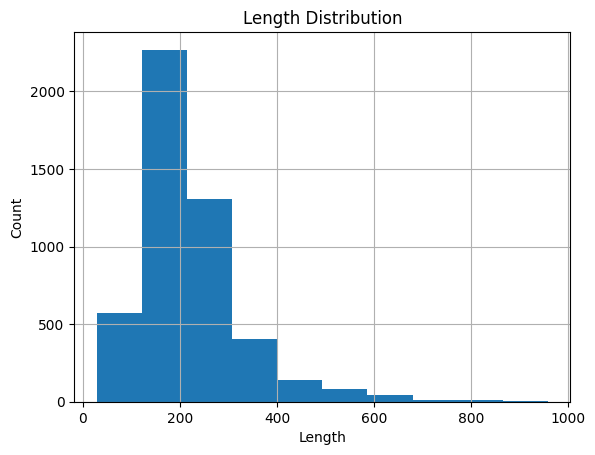

In [7]:
import matplotlib.pyplot as plt

# 길이 분포 히스토그램 시각화
final_train_df['conversation'].str.len().hist()
plt.title('Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

In [8]:
final_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4845 entries, 0 to 4844
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   idx           4845 non-null   object
 1   class         4845 non-null   object
 2   conversation  4845 non-null   object
dtypes: object(3)
memory usage: 113.7+ KB


In [6]:
final_train_df.head(1)

,idx,class,conversation
0,0,협박 대화,지금 너 스스로를 죽여달라고 애원하는 것인가?\n 아닙니다. 죄송합니다.\n 죽을 ...


In [7]:
max(final_train_df['conversation'].str.len())

958

## 데이터 전처리

- 필요없는 컬럼 삭제 `idx`
- 중복 데이터 확인 후 제거

- \n 줄바꿈 문자 공백 처리
  - 테스트 데이터의 예시를 보면 \n 문자열도 없음
  - 화자변경을 모델이 명시적인 기호 없이 텍스트의 흐름과 문맥으로 파악해야함
- 의미 없는 특수 기호 제거 (정규표현식 사용)
- 특수 기호 띄어쓰기 적용
- 다중 공백 하나로 압축

- 베이스라인 모델 실험 이후에 더 생각해볼 부분
  - 테스트 데이터 예시를 보면 구두점 등 특수 기호가 아예 없는데 이게 모든 테스트 데이터가 그런건지 불확실함
  - augmentation 진행할 때에 특수 기호 삭제하는 경우도 넣으면 좋을듯

In [24]:
# idx 컬럼 삭제
train_data.drop(['idx'], axis=1,inplace=True)

In [ ]:
# 특수 기호 처리
import re

def standard_preprocess(text):
    if not isinstance(text, str):
        return ""

    # 1. 줄바꿈, 탭 등 공백 문자 정규화
    text = re.sub(r'\s+', ' ', text)

    # 2. URL 및 이메일 제거 (선택 사항)
    text = re.sub(r'http\S+|www\S+|mailto:\S+', '', text)

    # 3. 특수문자 정제 (한글, 숫자, 기본 문장부호만 남기기)
    # KLUE 모델은 문장부호를 이해하므로 .?!,는 남겨두는 것이 좋습니다.
    text = re.sub(r'[^가-힣0-9a-zA-Zㄱ-ㅎㅏ-ㅣ\s.?!,]', '', text)

    return text.strip()

In [ ]:
# 중복 데이터 확인
train_data.info()

In [ ]:
# 중복 데이터 삭제


## 모델 선택

**후보**
- beomi/KcELECTRA-base-v2022  
네이버 뉴스 댓글, 커뮤니티 등 정제되지 않은 '날것의 한국어'로 학습된 모델  
  - 파괴된 문법과 신조어, 구어체 환경에서도 학습속도가 빠르고 문맥을 잘 알아차린다
  - 위키백과 같은 정제된 글로 학습된 모델에 비해 길고 복잡한 논리적 문맥을 파악하는 깊이가 얕을 수 있다

- klue/roberta-large  
위키, 뉴스, 웹 텍스트 등 엄청난 양의 한국어 데이터로 딥하게 학습된 모델
  - 파라미터가 커서 데이터의 숨겨진 패턴을 찾아내는 능력이 뛰어남. 최종 앙상블 시 무조건 한 자리를 차지하는 모델
  - 오타나 인터넷 말투에는 상대적으로 약해서 텍스트가 너무 깨져있으면 성능이 기대만큼 안나올 수 있고, 모델이 무거워 학습시간이 오래 걸린다

- team-lucide/deberta-v3-base-korean  
단어와 단어 사이의 '상대적인 거리'를 계산하는 기술이 적용된 최신 아키텍처
  - 최근 자연어 분류 대회에서 기존 BERT, RoBERTa를 누르고 SOTA를 자주 찍는 트렌디한 모델
  - KLUE나 KcELECTRA에 비해 국내 커뮤니티의 레퍼런스가 적은 편이라 에러가 났을 때 트러블슈팅이 까다로울 수 있다

**베이스라인 모델 선정기준**
- 준비된 데이터셋의 양, 성격을 고려했을 때 적당한가?
  - 총 데이터 개수: 약 5000개
  - 성격: 구어체
  - 데이터 비속어 포함 비율: 21.72%
- 어떤 능력이 가장 중요한가?
  - 화자 변환을 알려주지 않기 때문에 문맥 파악, 대화의 흐름 파악이 중요하다
  - 화자들의 관계를 파악할 수 있어야 한다
  - 미세한 클래스 간의 경계를 구분해야 한다
     - 협박과 갈취
     - 직장 내 괴롭힘과 기타 괴롭힘
- 학습 속도가 너무 느리면 여러 실험을 진행할 수 없다

**모델 선정**
- beomi/KcELECTRA-base-v2022  
- team-lucide/deberta-v3-base-korean  

In [ ]:
import pandas as pd
import re
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import EvalPrediction
import numpy as np
from torch.utils.data import Dataset

# 1. 전처리 함수 및 라벨 인코딩 (기존과 동일)
def clean_text(text):
    text = str(text).replace('\n', ' ')
    text = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9\s.,!?]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

final_train_df['clean_text'] = final_train_df['conversation'].apply(clean_text)

le = LabelEncoder()
final_train_df['label_encoded'] = le.fit_transform(final_train_df['class'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# 💡 2. Train / Validation 데이터 분리 (9:1 비율)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    final_train_df['clean_text'].values,
    final_train_df['label_encoded'].values,
    test_size=0.1,
    random_state=42,
    stratify=final_train_df['label_encoded'].values # 클래스 비율 유지
)

class DKTCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

from sklearn.metrics import f1_score, accuracy_score

# 1. 평가지표 계산 함수 수정 (F1-Score 추가)
def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    # 공식 평가지표인 Macro F1
    f1 = f1_score(labels, preds, average='macro')
    # 참고용 정확도
    acc = accuracy_score(labels, preds)

    return {
        "f1": f1,
        "accuracy": acc
    }

# 2. 모델 연속 학습 함수 수정
def run_experiment(model_name, exp_name):
    print(f"\n{'='*50}\n🚀 [{exp_name}] 모델 학습 시작!\n{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.truncation_side = 'left'

    train_dataset = DKTCDataset(train_texts, train_labels, tokenizer)
    val_dataset = DKTCDataset(val_texts, val_labels, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_mapping))

    training_args = TrainingArguments(
        output_dir=f'./results_{exp_name}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        learning_rate=2e-5,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        fp16=True,
        seed=42,
        load_best_model_at_end=True,
        metric_for_best_model="f1",  # 💡 F1 점수가 가장 높은 모델을 최종 선택
        greater_is_better=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics # 수정된 함수 적용
    )

    trainer.train()

    # 최종 검증 점수 출력
    eval_results = trainer.evaluate()
    print(f"🏆 [{exp_name}] 최종 검증 점수")
    print(f"   - Macro F1: {eval_results['eval_f1']:.4f}")
    print(f"   - Accuracy: {eval_results['eval_accuracy']:.4f}\n")

# 실행
run_experiment("beomi/KcELECTRA-base-v2022", "KcELECTRA")
run_experiment("team-lucid/deberta-v3-base-korean", "DeBERTa_V3")

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(p: EvalPrediction):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    # 공식 평가지표: Macro F1 Score
    f1 = f1_score(labels, preds, average='macro')
    # 참고용: Accuracy
    acc = accuracy_score(labels, preds)

    return {
        "f1": f1,
        "accuracy": acc
    }

# Trainer의 학습 인자(TrainingArguments)도 f1 기준으로 최고 모델을 저장하도록 수정
training_args = TrainingArguments(
    output_dir=f'./results_{exp_name}',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    fp16=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1", # 💡 Accuracy가 아니라 F1 점수가 가장 높은 모델을 선택!
    greater_is_better=True
)

## 4/23 10시반

In [9]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

# [주의] 이전에 생성한 final_train_df를 사용합니다.

# 1. idx 컬럼 삭제
final_train_df.drop(['idx'], axis=1, inplace=True)

# 2. 전처리 함수 정의
def standard_preprocess(text):
    if not isinstance(text, str):
        return ""

    # 1. 줄바꿈, 탭 등 공백 문자 정규화
    text = re.sub(r'\s+', ' ', text)

    # 2. URL 및 이메일 제거 (선택 사항)
    text = re.sub(r'http\S+|www\S+|mailto:\S+', '', text)

    # 3. 특수문자 정제 (한글, 숫자, 기본 문장부호만 남기기)
    # KLUE 모델은 문장부호를 이해하므로 .?!,는 남겨두는 것이 좋습니다.
    text = re.sub(r'[^가-힣0-9a-zA-Zㄱ-ㅎㅏ-ㅣ\s.?!,]', '', text)

    return text.strip()

# 3. 전처리 적용
final_train_df['conversation'] = final_train_df['conversation'].apply(standard_preprocess)

# 4. 중복 제거 및 결측치 처리
final_train_df = final_train_df.drop_duplicates(subset=['conversation']).dropna()

# 5. 라벨 맵핑 (팀 공통 가이드 준수)
# 현재 데이터의 'class' 내용에 맞춰 맵핑합니다.
label_dict = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일반 대화': 4
}

final_train_df['label'] = final_train_df['class'].map(label_dict)

# 맵핑이 잘 안 된 데이터(NaN)가 있는지 최종 확인
if final_train_df['label'].isnull().any():
    print("⚠️ 경고: 일부 데이터가 맵핑되지 않았습니다. class 명칭을 확인하세요.")
    final_train_df = final_train_df.dropna(subset=['label'])

final_train_df['label'] = final_train_df['label'].astype(int)

# 6. 학습/검증 데이터 분리 (8:2)
train_df, val_df = train_test_split(
    final_train_df,
    test_size=0.2,
    random_state=42,
    stratify=final_train_df['label']
)

print(f"✅ 최종 학습 데이터: {len(train_df)}개")
print(f"✅ 최종 검증 데이터: {len(val_df)}개")

✅ 최종 학습 데이터: 3792개
✅ 최종 검증 데이터: 948개


In [10]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.3 MB/s eta 0:00:00


In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import f1_score

model_name = "klue/roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 1. Dataset 클래스 수정 (RAM 폭사 방지)
# 핵심: __getitem__에서 토크나이징을 수행하여 RAM 점유율을 낮춥니다.
class DialogueDataset(torch.utils.data.Dataset):
    def __init__(self, conversations, labels, tokenizer, max_len=512): # 958 대신 512 추천
        self.conversations = conversations
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        # 호출될 때만 토크나이징 (RAM 보호)
        encoding = self.tokenizer(
            str(self.conversations[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# 2. 현실적인 길이 타협 (중요)
# 958을 다 살리면 Large 모델은 무조건 터집니다.
# RoBERTa의 절대 한계치는 512입니다. truncation_side='left'를 써서 뒷부분(위협)을 살리세요.
tokenizer.truncation_side = 'left'
MAX_LEN = 512

train_dataset = DialogueDataset(train_df['conversation'].tolist(), train_df['label'].tolist(), tokenizer, max_len=MAX_LEN)
val_dataset = DialogueDataset(val_df['conversation'].tolist(), val_df['label'].tolist(), tokenizer, max_len=MAX_LEN)

# 3. F1 Score 메트릭 추가 (공식 평가지표)
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    labels = p.label_ids
    f1 = f1_score(labels, preds, average='macro')
    return {"f1": f1}

# 4. 모델 로드 및 Gradient Checkpointing 활성화 (메모리 절약 끝판왕)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
model.gradient_checkpointing_enable() # 학습은 느려지지만 메모리를 엄청나게 아껴줍니다.

# 5. TrainingArguments 수정
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=2,      # 배치를 2로 더 줄입니다.
    gradient_accumulation_steps=4,      # 누적을 4로 늘려 실제 배치 8 효과 유지
    fp16=True,                          # 반드시 사용
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    # 아래 옵션들이 RAM 세션을 지켜줍니다.
    optim="adamw_bnb_8bit",             # (선택) 만약 bitsandbytes 설치 시 메모리 대폭 절감
    dataloader_pin_memory=False,        # RAM 점유 방지
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1422, training_loss=1.502570281426112, metrics={'train_runtime': 1686.0474, 'train_samples_per_second': 6.747, 'train_steps_per_second': 0.843, 'total_flos': 1.0601758651465728e+16, 'train_loss': 1.502570281426112, 'epoch': 3.0})

In [12]:
from sklearn.metrics import classification_report
import numpy as np

# 예측
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

# 결과 리포트 출력
print(classification_report(val_df['label'], preds, target_names=list(label_dict.keys())))

              precision    recall  f1-score   support

       협박 대화       0.90      0.84      0.87       178
       갈취 대화       0.86      0.91      0.88       195
 직장 내 괴롭힘 대화       0.95      0.94      0.95       194
   기타 괴롭힘 대화       0.87      0.88      0.87       202
       일반 대화       1.00      0.99      1.00       179

    accuracy                           0.91       948
   macro avg       0.91      0.91      0.91       948
weighted avg       0.91      0.91      0.91       948



In [17]:
from sklearn.metrics import classification_report, f1_score

# 1. 검증 데이터셋 예측 결과 가져오기
# preds: 모델이 예측한 값 [0, 4, 2, 1...]
# labels: 실제 정답 값 [0, 4, 3, 1...]

# 2. 상세 리포트 출력
target_names = ['협박', '갈취', '직장내괴롭힘', '기타괴롭힘', '일반']
print(classification_report(val_df['label'], preds, target_names=target_names))

# 3. Macro F1-score만 따로 추출 (베이스라인 수치 기록용)
macro_f1 = f1_score(val_df['label'], preds, average='macro')
print(f"🚀 최종 베이스라인 Macro F1-score: {macro_f1:.4f}")

              precision    recall  f1-score   support

          협박       0.90      0.84      0.87       178
          갈취       0.86      0.91      0.88       195
      직장내괴롭힘       0.95      0.94      0.95       194
       기타괴롭힘       0.87      0.88      0.87       202
          일반       1.00      0.99      1.00       179

    accuracy                           0.91       948
   macro avg       0.91      0.91      0.91       948
weighted avg       0.91      0.91      0.91       948

🚀 최종 베이스라인 Macro F1-score: 0.9134


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54801 (\N{HANGUL SYLLABLE HYEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52712 (\N{HANGUL SYLLABLE CWI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/

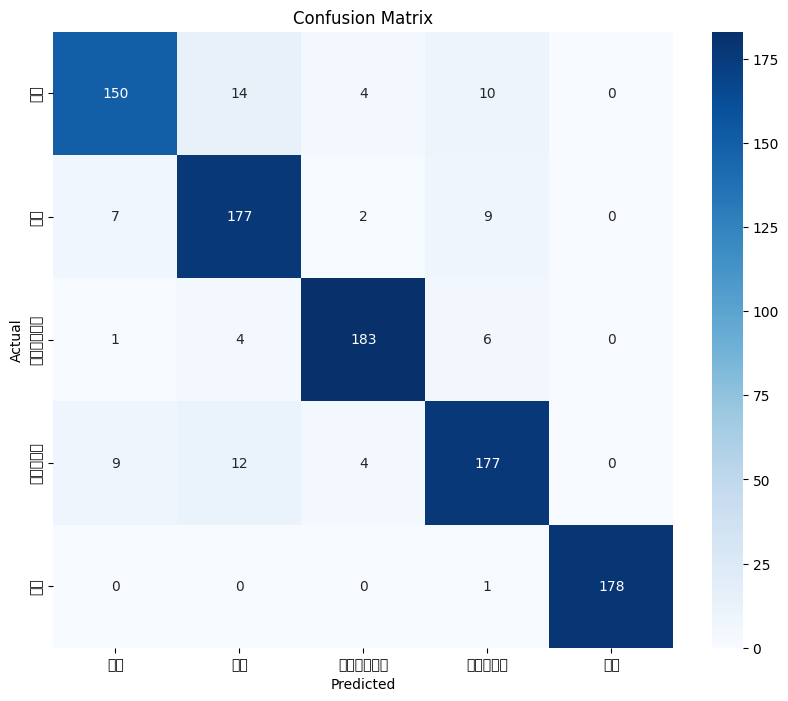

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 혼동 행렬 생성
cm = confusion_matrix(val_df['label'], preds)

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

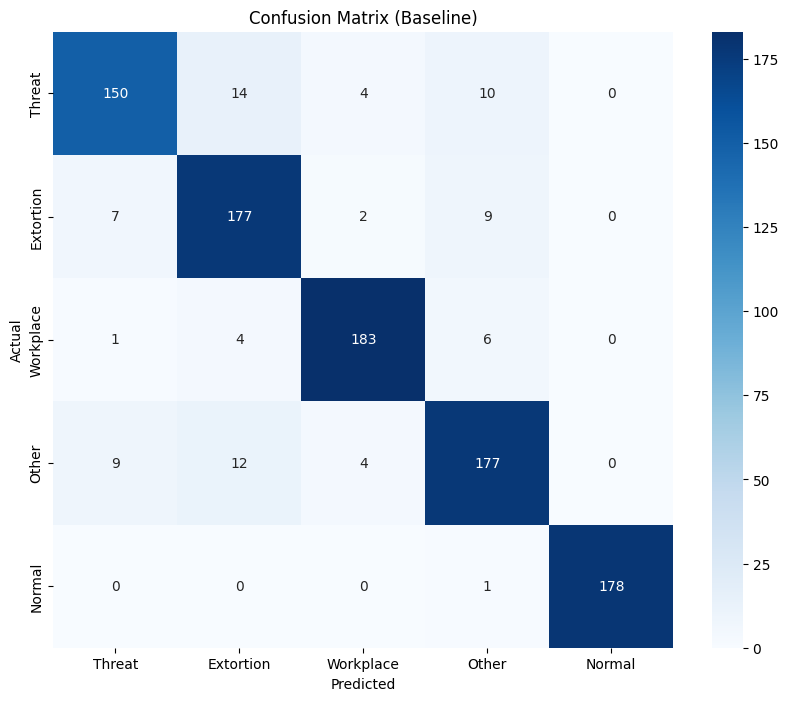

In [23]:
# 한글 대신 영어로 라벨링 (폰트 에러 방지용)
en_target_names = ['Threat', 'Extortion', 'Workplace', 'Other', 'Normal']

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=en_target_names, yticklabels=en_target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Baseline)')
plt.show()

## 리더보드 점수 확인

In [ ]:
test_df = pd.read_csv('test.csv') # 대회 제공 test 파일
# 학습 때 썼던 전처리를 똑같이 적용해야 합니다!
test_df['conversation'] = test_df['text'].apply(standard_preprocess)

In [ ]:
# 검증 데이터 때와 똑같이 예측을 뽑습니다.
test_dataset = DialogueDataset(test_df['conversation'].tolist(), [0]*len(test_df), tokenizer)
test_preds_raw = trainer.predict(test_dataset)
test_preds = np.argmax(test_preds_raw.predictions, axis=-1)

# 숫자를 다시 글자 라벨로 바꿉니다.
inverse_label_dict = {v: k for k, v in label_dict.items()}
test_results = [inverse_label_dict[p] for p in test_preds]

In [ ]:
submission = pd.read_csv('submission_sample.csv') # 샘플 양식 파일
submission['class'] = test_results
submission.to_csv('my_baseline_submission.csv', index=False)